# Phase 1 - Business Understanding

## 1.1 Research Context

Nigerian e-commerce has grown substantially over the past decade, but the conditions under which it operates remain structurally different from the markets where most seller churn literature originates. Currency instability has been a persistent feature - the naira depreciated from roughly 450 NGN/USD in early 2022 to over 1,500 NGN/USD by late 2024, compressing margins for sellers whose supply chains carry any dollar exposure. Logistics outside major urban centres is fragmented, with last-mile delivery often dependent on informal networks. Electricity supply is unreliable enough that operational continuity itself becomes a variable. These are not edge cases or noise - they are structural features of the environment that shape how sellers behave, how long they stay, and why they leave.

Against this backdrop, marketplace platforms face a resource allocation problem that has received limited academic attention from the seller side. The buyer-side churn literature is relatively mature, with over 240 published studies as of recent reviews. Seller-side retention research is sparse by comparison - fewer than five papers address it directly in emerging market contexts. What exists tends to focus on revenue prediction or engagement scoring rather than the binary question of whether a seller will still be active at a future date.

This project sits in that gap.

---

## 1.2 The Business Problem

A marketplace platform cannot support every seller with the same level of attention. Account management, onboarding assistance, promotional access, and technical support all cost time and money. In practice, platforms can actively invest in somewhere between 15% and 25% of their active seller base at any given point. The rest receive standard self-service access.

The problem is that this allocation decision typically gets made too late - after a seller has already demonstrated revenue performance. That approach has an obvious flaw: by the time revenue performance is visible, the window where early-stage support would have had the most impact has likely already closed. Sellers who are going to disengage tend to show signs of that trajectory well before they formally go inactive, and those signs are not always financial.

What platforms actually need is an early warning system - something that can identify, within the early weeks of a seller's time on the platform, which sellers are likely to still be active at the one-year mark. Not who will earn the most. Who will stay.

How early that prediction can reliably be made is itself an empirical question that this research will address directly. The data will determine what the practical observation window looks like. That decision will be made through analysis and documented as a justified finding rather than assumed upfront.

---

## 1.3 The Prediction Task

The target variable in this project is seller retention - a binary outcome defined as whether a seller remains active on the platform at the 12-month mark. The prediction is made using only data available within an early observation window, the appropriate length of which will be established empirically.

The prediction task is framed around retention rather than revenue as a deliberate methodological choice. Revenue prediction carries a structural weakness in this context: the strongest predictors of future GMV tend to be early GMV components, creating a relationship that is largely circular and offers limited operational value. Retention does not have that problem. A seller is either active at month 12 or they are not, and that outcome is not a component of any early-stage metric.


There is also a practical difference in what the two framings enable. Revenue prediction identifies who is already performing well. Retention prediction identifies who is at risk of leaving - which is the question resource allocation decisions should actually be answering. A seller generating modest early transaction volume who would stay and grow with the right support is more valuable to a platform than a high-revenue seller who was never going to remain past a single promotional cycle. The two can look similar on early revenue metrics. They may look quite different on early behavioural signals.

---

## 1.4 Research Questions

**RQ1 (Primary):** Can seller churn be predicted from behavioural signals captured in the first 60 days of a seller's
tenure on the platform, without relying on revenue information?

**RQ2:** Which signals are most predictive of seller churn?


---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_validate

from xgboost import XGBClassifier

from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/MSc Dissertation'
DATA_PATH = f'{PROJECT_PATH}/NewDatasets'
OUTPUT_PATH = f'{PROJECT_PATH}/V12'

import os
os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(f'{OUTPUT_PATH}/data', exist_ok=True)
os.makedirs(f'{OUTPUT_PATH}/figures', exist_ok=True)
os.makedirs(f'{OUTPUT_PATH}/models', exist_ok=True)
os.makedirs(f'{OUTPUT_PATH}/results', exist_ok=True)


print('Environment ready')
print(f'Output directory: {OUTPUT_PATH}')

Mounted at /content/drive
Environment ready
Output directory: /content/drive/MyDrive/MSc Dissertation/V12


# Phase 2 - Data Understanding

The goal of this phase is straightforward: understand the raw data completely before making any modelling decisions. No features get engineered here, no labels get constructed, and no assumptions get carried forward untested. Every table gets examined on its own terms first, then in relation to the others.

The phase is structured in four parts.

---

## Part 1 - Dataset Overview

All 14 tables are loaded and profiled for shape, dtypes, missing value rates, and cross-table seller coverage. Absence patterns are documented before any table-level analysis begins.

---

## Part 2 - Anchor and Reference Tables

sellers.csv, orders.csv, order_items.csv, and products.csv establish the seller universe, transaction record, basket structure, and product catalogue. These are the foundation for all downstream eligibility and label construction.

---

## Part 3 - Behavioural and Operational Tables

seller_activity_log, seller_performance_metrics, logistics, reviews, disputes, and inventory_snapshots contain the signals that will carry most predictive weight. Coverage rates, distributions, and absence patterns are documented for each. Absence from sparse tables (reviews, disputes) is treated as MNAR signal rather than a data gap.

---

## Part 4 - Supplementary and Reference Tables

marketing_participation, campaigns, categories, and external_factors provide campaign context, category hierarchy, and daily macroeconomic data including the NGN/USD trajectory and FX shock window

In [ ]:
tables = {
    'sellers': 'sellers.csv',
    'orders': 'orders.csv',
    'order_items': 'order_items.csv',
    'products': 'products.csv',
    'seller_activity_log': 'seller_activity_log.csv',
    'seller_performance_metrics': 'seller_performance_metrics.csv',
    'logistics': 'logistics.csv',
    'reviews': 'reviews.csv',
    'disputes': 'disputes.csv',
    'inventory_snapshots': 'inventory_snapshots.csv',
    'marketing_participation': 'marketing_participation.csv',
    'campaigns': 'campaigns.csv',
    'categories': 'categories.csv',
    'external_factors': 'external_factors.csv',
}

dfs = {}
for name, filename in tables.items():
    path = os.path.join(DATA_PATH, filename)
    dfs[name] = pd.read_csv(path)
    print(f'Loaded {name}: {dfs[name].shape}')

Loaded sellers: (6200, 11)
Loaded orders: (622111, 12)
Loaded order_items: (1778851, 7)
Loaded products: (86470, 11)
Loaded seller_activity_log: (2186081, 6)
Loaded seller_performance_metrics: (248196, 12)
Loaded logistics: (622111, 12)
Loaded reviews: (16685, 8)
Loaded disputes: (2036, 9)
Loaded inventory_snapshots: (181948, 6)
Loaded marketing_participation: (550, 7)
Loaded campaigns: (40, 7)
Loaded categories: (90, 5)
Loaded external_factors: (1461, 8)


In [ ]:
print("PART 1 - DATASET OVERVIEW\n")

print("Table shapes and column counts")
print(f"{'Table':<35} {'Rows':>10} {'Cols':>6}")
print("-" * 55)
for name, df in dfs.items():
    print(f"  {name:<33} {len(df):>10,} {len(df.columns):>6}")

print("\n\nMissing value rates by table")
print(f"{'Table':<35} {'Total Nulls':>12} {'Null Rate':>10}")
print("-" * 60)
for name, df in dfs.items():
    total_nulls = df.isnull().sum().sum()
    total_cells = df.shape[0] * df.shape[1]
    null_rate = total_nulls / total_cells
    if total_nulls > 0:
        print(f"  {name:<33} {total_nulls:>12,} {null_rate:>9.1%}")
        null_cols = df.isnull().sum()
        null_cols = null_cols[null_cols > 0]
        for col, count in null_cols.items():
            print(f"    {col:<31} {count:>12,} {count/len(df):>9.1%}")

print("\n\nCross-table seller coverage")
total_sellers = dfs['sellers']['seller_id'].nunique()
print(f"Total sellers in sellers.csv: {total_sellers:,}\n")
print(f"{'Table':<35} {'In Table':>10} {'Coverage':>10} {'Absent':>10}")
print("-" * 70)
for name, df in dfs.items():
    if 'seller_id' in df.columns:
        n_sellers = df['seller_id'].nunique()
        coverage = n_sellers / total_sellers
        absent = total_sellers - n_sellers
        print(f"  {name:<33} {n_sellers:>10,} {coverage:>9.1%} {absent:>10,}")

print("\n\nDtype summary by table")
for name, df in dfs.items():
    dtype_counts = df.dtypes.value_counts()
    print(f"  {name:<33} {dict(dtype_counts)}")

PART 1 - DATASET OVERVIEW

Table shapes and column counts
Table                                     Rows   Cols
-------------------------------------------------------
  sellers                                6,200     11
  orders                               622,111     12
  order_items                        1,778,851      7
  products                              86,470     11
  seller_activity_log                2,186,081      6
  seller_performance_metrics           248,196     12
  logistics                            622,111     12
  reviews                               16,685      8
  disputes                               2,036      9
  inventory_snapshots                  181,948      6
  marketing_participation                  550      7
  campaigns                                 40      7
  categories                                90      5
  external_factors                       1,461      8


Missing value rates by table
Table                                Total Nu

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("SELLERS TABLE - FULL PROFILE\n")

sellers = dfs['sellers'].copy()
sellers['registration_date'] = pd.to_datetime(sellers['registration_date'], dayfirst=True)
sellers['anchor_date'] = pd.to_datetime(sellers['anchor_date'], format='mixed', dayfirst=True)

print(f"Date range: {sellers['registration_date'].min().date()} to {sellers['registration_date'].max().date()}")
print(f"\nRegistration by quarter")
print(sellers['registration_cohort_qtr'].value_counts().sort_index())
print(f"\nVerification tier")
print(sellers['verification_tier'].value_counts())
print(f"\nReferral source")
print(sellers['referral_source'].value_counts())
print(f"\nState distribution (top 10)")
print(sellers['state'].value_counts().head(10))
print(f"\nPayment preference")
print(sellers['payment_preference'].value_counts())
print(f"\nAnchor type distribution")
print(sellers['anchor_type'].value_counts(dropna=False))
print(f"\nAnchor date range (non-null)")
active = sellers[sellers['anchor_date'].notna()]
print(f"  Min: {active['anchor_date'].min().date()}")
print(f"  Max: {active['anchor_date'].max().date()}")
print(f"\nNull counts")
print(sellers.isnull().sum())

print("\n\nORDERS TABLE - FULL PROFILE\n")

orders = dfs['orders'].copy()
orders['order_date'] = pd.to_datetime(orders['order_date'], format='mixed', dayfirst=True)

print(f"Date range: {orders['order_date'].min().date()} to {orders['order_date'].max().date()}")
print(f"Unique sellers: {orders['seller_id'].nunique():,}")
print(f"Unique buyers: {orders['buyer_id'].nunique():,}")
print(f"\nOrder status distribution")
print(orders['order_status'].value_counts())
print(f"\nFailure reason distribution (non-null)")
print(orders['failure_reason'].dropna().value_counts())
print(f"\nPayment method distribution")
print(orders['payment_method'].value_counts())
print(f"\nLogistics partner distribution")
print(orders['logistics_partner'].value_counts())
print(f"\nGMV stats (NGN)")
print(orders['gmv_ngn'].describe())
print(f"\nOrders per seller")
print(orders.groupby('seller_id').size().describe())
print(f"\nMonthly order volume with delivery rate")
orders['order_month'] = orders['order_date'].dt.to_period('M')
monthly = orders.groupby('order_month').agg(
    total=('order_id', 'count'),
    delivered=('order_status', lambda x: (x == 'delivered').sum())
)
monthly['delivery_rate'] = monthly['delivered'] / monthly['total']
print(monthly.to_string())

SELLERS TABLE - FULL PROFILE

Date range: 2022-01-01 to 2024-09-30

Registration by quarter
registration_cohort_qtr
2022-Q1    419
2022-Q2    423
2022-Q3    506
2022-Q4    521
2023-Q1    538
2023-Q2    554
2023-Q3    601
2023-Q4    650
2024-Q1    638
2024-Q2    670
2024-Q3    680
Name: count, dtype: int64

Verification tier
verification_tier
email_only           3110
phone_verified       1607
id_verified          1025
business_verified     458
Name: count, dtype: int64

Referral source
referral_source
organic_search    1854
social_media      1758
peer_referral     1379
platform_ad        853
other              356
Name: count, dtype: int64

State distribution (top 10)
state
Lagos      3668
Kano        602
Rivers      513
FCT         392
Oyo         314
Anambra     179
Kaduna      176
Delta       123
Enugu       118
Others      115
Name: count, dtype: int64

Payment preference
payment_preference
bank_transfer    4455
mobile_money     1745
Name: count, dtype: int64

Anchor type distribut

### 2.1 sellers.csv

The sellers table is the anchor table for the entire dataset, containing 6,200 records across 11 columns with one row per seller. Registration dates span January 2022 through September 2024, with steady quarter-on-quarter growth from 419 sellers in 2022-Q1 to 680 in 2024-Q3. The growth pattern is consistent across all 11 cohort quarters with no sudden spikes, suggesting organic platform expansion rather than campaign-driven acquisition bursts distorting any particular cohort.

The only structural nulls are 941 missing LGA values (15.2%) and 1,427 null anchor_date and anchor_type entries (23.0%). The LGA nulls do not affect any downstream eligibility or feature calculation. The 1,427 null anchor values correspond to sellers who registered and listed products but never generated sufficient commercial activity to establish an activation reference point - these sellers will be excluded during eligibility determination in Phase 3.

Verification tier skews to the lowest level: 3,110 sellers (50.2%) at email_only, 458 (7.4%) at business_verified. Referral source is evenly spread across organic search (1,854), social media (1,758), peer referral (1,379), and platform advertising (853). Lagos accounts for 3,668 sellers (59.2%); payment preference splits into bank_transfer (4,455) and mobile_money (1,745).

Of the 4,773 commercially active sellers with a valid anchor date, 4,586 (96.1%) have a first_delivered_order anchor, meaning they received a delivered order within 30 days of their first listing. Only 187 sellers (3.9%) fall back to a first_listing anchor. The anchor_date and anchor_type fields are pre-computed and will be used directly as the immutable reference points for all window calculations in Phase 3.

### 2.2 orders.csv

The orders table contains 622,111 records across 12 columns, covering 5,791 unique sellers and 355,473 unique buyers. The date range runs from January 2022 through September 2025. 409 sellers in the sellers table have no order records, reflecting sellers who registered and listed products but never received a transaction.

Delivered orders account for 470,920 records (75.7%). The remaining volume splits across failed_delivery (100,489), cancelled_by_seller (25,933), and returned_to_seller (24,769). All cancellations are seller-initiated - there is no cancelled_by_buyer status in this table. Three failure reasons are present among non-delivered orders: buyer_refused (59,534), seller_fault (48,294), and logistics_fault (43,363), each contributing roughly equally and capturing distinct operational failure modes across buyer rejection, seller-side fulfilment breakdown, and third-party logistics failure respectively.

The monthly delivery rate holds at 74-76% with no meaningful variation across the full observation period, confirming that order outcomes reflect genuine operational performance rather than platform-level artefacts.

Payment methods follow the expected structure for the Nigerian market: cash on delivery leads at 232,466 orders (37.4%), followed by card (199,812) and bank_transfer (102,852). Mobile money and USSD together account for a further 14.0%, reflecting mobile-first financial infrastructure. Order-level GMV has a mean of ₦103,608 and a median of ₦64,750, with a right tail reaching ₦1,794,900. The substantially higher GMV relative to order count suggests larger basket sizes - a structural characteristic examined in the order_items profiling below.

In [ ]:
print("ORDER ITEMS - FULL PROFILE\n")

items = dfs['order_items'].copy()

print(f"Shape: {items.shape}")
print(f"Unique orders: {items['order_id'].nunique():,}")

print(f"\nReferential integrity - items not in orders")
print(f"  Missing: {(~items['order_id'].isin(dfs['orders']['order_id'])).sum():,}")

print(f"\nItems per order")
print(items.groupby('order_id').size().describe())

print(f"\nUnit price stats (NGN)")
print(items['unit_price_ngn'].describe())

print(f"\nQuantity stats")
print(items['quantity'].describe())

print(f"\nItem status distribution")
print(items['item_status'].value_counts())

print(f"\nNull counts")
print(items.isnull().sum())

print("\n\nSELLER ACTIVITY LOG - FULL PROFILE\n")

activity = dfs['seller_activity_log'].copy()
activity['activity_date'] = pd.to_datetime(activity['activity_date'], format='mixed', dayfirst=True)

print(f"Unique sellers: {activity['seller_id'].nunique():,}")
print(f"Date range: {activity['activity_date'].min().date()} to {activity['activity_date'].max().date()}")
print(f"\nActivity type distribution")
print(activity['activity_type'].value_counts())
print(f"\nLogin count vs session duration non-null count")
print(f"  Login events: {(activity['activity_type']=='login').sum():,}")
print(f"  Non-null session_duration_mins: {activity['session_duration_mins'].notna().sum():,}")
print(f"\nSession duration stats (non-null)")
print(activity['session_duration_mins'].dropna().describe())
print(f"\nPlatform section distribution (non-null)")
print(activity['platform_section'].dropna().value_counts())
print(f"\nRecords per seller")
print(activity.groupby('seller_id').size().describe())
print(f"\nNull counts")
print(activity.isnull().sum())

print("\n\nSELLER PERFORMANCE METRICS - FULL PROFILE\n")

metrics = dfs['seller_performance_metrics'].copy()
metrics['snapshot_date'] = pd.to_datetime(metrics['snapshot_date'], format='mixed', dayfirst=True)

print(f"Unique sellers: {metrics['seller_id'].nunique():,}")
print(f"Date range: {metrics['snapshot_date'].min().date()} to {metrics['snapshot_date'].max().date()}")
print(f"\nSnapshots per seller")
print(metrics.groupby('seller_id').size().describe())
print(f"\nResponse rate pct (non-null)")
print(metrics['response_rate_pct'].dropna().describe())
print(f"\nOn time delivery rate pct (non-null)")
print(metrics['on_time_delivery_rate_pct'].dropna().describe())
print(f"\nOrder completion rate pct")
print(metrics['order_completion_rate_pct'].describe())
print(f"\nSeller score (non-null)")
print(metrics['seller_score'].dropna().describe())
print(f"\nOrders received 7d")
print(metrics['orders_received_7d'].describe())
print(f"\nGMV 7d NGN (non-zero)")
print(metrics[metrics['gmv_7d_ngn'] > 0]['gmv_7d_ngn'].describe())
print(f"\nNull counts")
print(metrics.isnull().sum())

print("\n\nLOGISTICS TABLE - FULL PROFILE\n")

logistics = dfs['logistics'].copy()
logistics['transit_gap'] = logistics['transit_days_actual'] - logistics['transit_days_promised']

print(f"Unique sellers: {logistics['seller_id'].nunique():,}")
print(f"\nReferential integrity")
print(f"  Not in orders: {(~logistics['order_id'].isin(dfs['orders']['order_id'])).sum():,}")
print(f"  Not in logistics: {(~dfs['orders']['order_id'].isin(logistics['order_id'])).sum():,}")
print(f"\nFinal status distribution")
print(logistics['final_status'].value_counts())
print(f"\nDelivery zone distribution")
print(logistics['delivery_zone'].value_counts())
print(f"\nOn-time rate by delivery zone")
print(logistics.groupby('delivery_zone')['on_time_flag'].mean().mul(100).round(1).sort_values())
print(f"\nOverall on-time rate: {logistics['on_time_flag'].mean()*100:.1f}%")
print(f"\nTransit gap (actual - promised)")
print(logistics['transit_gap'].dropna().describe())
print(f"\nNull counts")
print(logistics.isnull().sum())

print("\n\nREVIEWS TABLE - FULL PROFILE\n")

reviews = dfs['reviews'].copy()
delivered_count = (dfs['orders']['order_status'] == 'delivered').sum()

print(f"Unique sellers: {reviews['seller_id'].nunique():,}")
print(f"Review rate: {len(reviews)/delivered_count*100:.1f}% of delivered orders")
print(f"\nRating distribution")
print(reviews['rating_stars'].value_counts().sort_index())
print(f"Mean rating: {reviews['rating_stars'].mean():.2f}")
print(f"\nSeller responded")
print(reviews['seller_responded'].value_counts())
print(f"\nResponse days (non-null)")
print(reviews['response_days'].dropna().describe())
print(f"\nNull counts")
print(reviews.isnull().sum())

print("\n\nDISPUTES TABLE - FULL PROFILE\n")

disputes = dfs['disputes'].copy()

print(f"Unique sellers: {disputes['seller_id'].nunique():,}")
print(f"Dispute rate: {len(disputes)/delivered_count*100:.1f}% of delivered orders")
print(f"\nDispute type distribution")
print(disputes['dispute_type'].value_counts())
print(f"\nResolution status distribution")
print(disputes['resolution_status'].value_counts())
print(f"\nRefund issued")
print(disputes['refund_issued'].value_counts())
print(f"\nSeller response days (non-null)")
print(disputes['seller_response_days'].dropna().describe())
print(f"\nNull counts")
print(disputes.isnull().sum())

ORDER ITEMS - FULL PROFILE

Shape: (1778851, 7)
Unique orders: 622,111

Referential integrity - items not in orders
  Missing: 0

Items per order
count    622111.000000
mean          2.859379
std           1.768095
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max          10.000000
dtype: float64

Unit price stats (NGN)
count    1.778851e+06
mean     2.955915e+04
std      3.809901e+04
min      2.000000e+02
25%      4.300000e+03
50%      1.165000e+04
75%      4.035000e+04
max      3.405500e+05
Name: unit_price_ngn, dtype: float64

Quantity stats
count    1.778851e+06
mean     1.225007e+00
std      5.694552e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.000000e+00
Name: quantity, dtype: float64

Item status distribution
item_status
delivered    1344694
lost          289209
cancelled      73974
returned       70974
Name: count, dtype: int64

Null counts
order_item_id     0
order_id      

### 2.3 order_items.csv

The order items table contains 1,778,851 records across 7 columns with no null values. Every order in the orders table has at least one corresponding item record - referential integrity is perfect with zero orphaned order_ids.

The basket structure is the defining characteristic of this table. The mean order contains 2.86 items and the median is 2, with the 75th percentile at 4 items and a maximum of 10. Buyers are regularly assembling multi-item orders rather than purchasing single products, which directly explains the elevated order-level GMV observed in the orders table despite unit prices that are themselves modest. The mean unit price is ₦29,559 and the median is ₦11,650, with a right tail reaching ₦340,550. The higher basket size rather than higher product prices drives the GMV figures.

Item status aligns with the order-level outcomes. Delivered items account for 1,344,694 records (75.6%), consistent with the 75.7% order-level delivery rate. Lost items number 289,209, cancelled 73,974, and returned 70,974.

### 2.5 seller_activity_log.csv

The activity log contains 2,186,081 records across 6 columns, covering 5,796 unique sellers over a date range of January 2022 through September 2025. 404 sellers in the sellers table have no activity log records.

Thirteen distinct activity types are recorded. listing_updated (638,578), login (426,677), and listing_created (277,606) dominate, with lower-frequency types covering dispute responses, training completions, and campaign enrolments. The pattern reflects sellers spending most platform time managing existing listings rather than creating new ones.

session_duration_mins is non-null for exactly 426,677 records, matching the login event count precisely - session duration is a property of the login session rather than individual platform actions, and all non-login activity types carry null duration by design. Among login sessions, duration ranges from 1 to 35 minutes with a mean of 8.5 minutes and a median of 6 minutes. platform_section is populated for 557,035 records (25.5% of the table), with analytics leading at 202,345, followed by listings_manager (150,764) and order_management (118,979). Activity records per seller range from 1 to 3,804 with a mean of 377 and a median of 130, reflecting a heavily right-skewed engagement distribution where a small number of highly active sellers generate a disproportionate share of total platform interactions.

### 2.6 seller_performance_metrics.csv

The performance metrics table contains 248,196 records across 12 columns, covering 4,773 unique sellers. Every seller present has exactly 52 weekly snapshots with zero standard deviation on snapshot count, representing one full year of weekly performance tracking per seller. The 1,427 sellers absent from this table correspond exactly to the null anchor_date population in the sellers table. The date range runs from January 2022 through September 2025.

Response rate (mean 19.7%, median 0%) and on-time delivery rate (mean 72.6%, median 80%) are each available for roughly half of rows. Order completion rate is fully populated with a median of 100%. Seller score averages 75.4 with meaningful spread across the 0-100 range. Weekly GMV among non-zero snapshots has a median of ₦241,650.

### 2.7 logistics.csv

The logistics table contains 622,111 records across 13 columns - one record per order, matching the orders table exactly. Referential integrity is perfect in both directions. Coverage spans 5,791 unique sellers.

Four final statuses are present: delivered (470,920), buyer_refused (59,534), returned_to_seller (48,294), and lost_in_transit (43,363). The delivered rate at shipment level is 75.7%, consistent with the order-level figure. The overall on-time delivery rate is 72.6%, with pronounced variation by zone - local_lagos achieves 81.9%, intrastate 76.0%, interstate_proximate 68.0%, and interstate_remote 57.9%. The 24 percentage point gap between local and remote delivery reflects the compounding difficulty of long-distance logistics in Nigeria, where road infrastructure quality, handoff complexity, and transit predictability all deteriorate with distance. Transit gap - actual minus promised delivery days - has a mean and median of -1.0, meaning sellers are on average delivering one day ahead of the promised date, with a range of -10 to +8 days.

### 2.8 reviews.csv

The reviews table contains 16,685 records across 8 columns, covering 3,417 unique sellers. The review rate against delivered orders is 3.5%. Ratings skew toward the upper end - 5-star reviews account for 7,536 records (45.2%) and 4-star for 3,368 (20.2%), while 1-star accounts for 2,132 (12.8%) and 2-star for 1,691 (10.1%). The mean rating is 3.75 and the median is 4. The bimodal character - mass at both extremes with less in the middle - is consistent with voluntary review systems where buyers are primarily motivated by strong satisfaction or strong dissatisfaction. Sellers responded to 4,946 reviews (29.6%), with a mean response time of 4.0 days and all responses occurring within 7 days. The 11,739 null response_days values correspond exactly to unresponded reviews and are structural rather than a data quality issue.

### 2.9 disputes.csv

The disputes table contains 2,036 records across 9 columns, covering 1,291 unique sellers. The dispute rate against delivered orders is 0.4%. Five dispute types are present: item_not_received (601), item_not_as_described (500), refund_request (418), quality_complaint (345), and cod_amount_dispute (172). Disputes resolve in favour of buyers in 696 cases and sellers in 519, with 382 withdrawn by buyers and 192 abandoned without conclusion. Refunds were issued in 1,105 cases (54.3%). Sellers responded to 1,453 of 2,036 disputes (71.4%), with a mean response time of 5.7 days and a maximum of 17 days.

PRODUCTS TABLE - FULL PROFILE

Shape: (86470, 11)
Unique sellers: 6,200
Unique products: 86,470
Date range: 2022-01-03 00:00:00 to 2025-03-30 00:00:00

Listing status distribution
listing_status
active      59141
paused      16482
delisted    10847
Name: count, dtype: int64

Products per seller
count    6200.000000
mean       13.946774
std        12.861607
min         1.000000
25%         3.000000
50%        10.000000
75%        21.000000
max        84.000000
dtype: float64

Price stats (NGN)
count     86470.000000
mean      30941.235689
std       38596.780794
min         200.000000
25%        4650.000000
50%       13300.000000
75%       43400.000000
max      315400.000000
Name: price_ngn, dtype: float64

Image count stats
count    86470.000000
mean         2.963236
std          1.648353
min          0.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          8.000000
Name: image_count, dtype: float64

Title word count stats
count    86470.000000
mean       

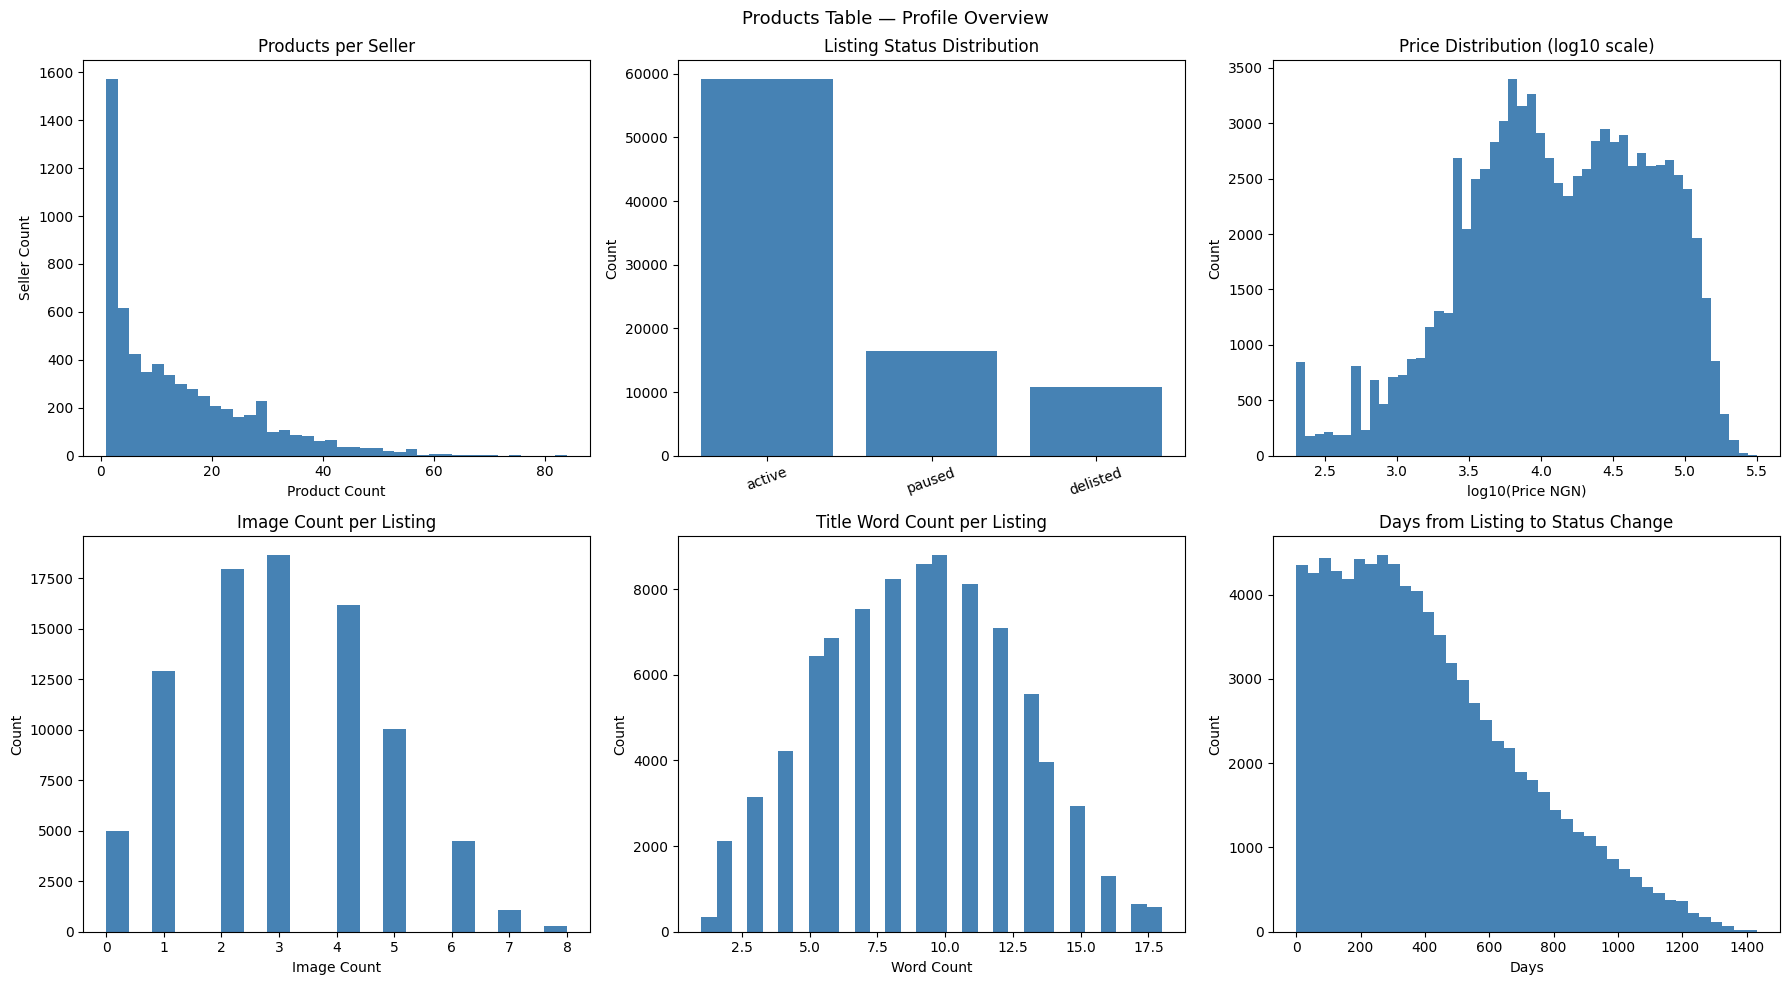

In [ ]:
print("PRODUCTS TABLE - FULL PROFILE\n")

products = dfs['products'].copy()
products['listed_date'] = pd.to_datetime(products['listed_date'], format='mixed', dayfirst=True)
products['last_status_date'] = pd.to_datetime(products['last_status_date'], format='mixed', dayfirst=True)

print(f"Shape: {products.shape}")
print(f"Unique sellers: {products['seller_id'].nunique():,}")
print(f"Unique products: {products['product_id'].nunique():,}")
print(f"Date range: {products['listed_date'].min()} to {products['listed_date'].max()}")

print(f"\nListing status distribution")
print(products['listing_status'].value_counts())

print(f"\nProducts per seller")
print(products.groupby('seller_id').size().describe())

print(f"\nPrice stats (NGN)")
print(products['price_ngn'].describe())

print(f"\nImage count stats")
print(products['image_count'].describe())

print(f"\nTitle word count stats")
print(products['title_word_count'].describe())

print(f"\nInitial quantity stats (non-null)")
print(products['initial_quantity'].dropna().describe())

print(f"\nStock indicated distribution")
print(products['stock_indicated'].value_counts(dropna=False))

print(f"\nNull counts")
print(products.isnull().sum())

print(f"\nDays from listing to last status change")
products['days_to_status_change'] = (products['last_status_date'] - products['listed_date']).dt.days
print(products['days_to_status_change'].describe())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

prods_per_seller = products.groupby('seller_id').size()
axes[0, 0].hist(prods_per_seller.values, bins=40, color='steelblue', edgecolor='none')
axes[0, 0].set_title('Products per Seller')
axes[0, 0].set_xlabel('Product Count')
axes[0, 0].set_ylabel('Seller Count')

status_counts = products['listing_status'].value_counts()
axes[0, 1].bar(status_counts.index, status_counts.values, color='steelblue')
axes[0, 1].set_title('Listing Status Distribution')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=20)

price_nonzero = products[products['price_ngn'] > 0]['price_ngn']
axes[0, 2].hist(np.log10(price_nonzero), bins=50, color='steelblue', edgecolor='none')
axes[0, 2].set_title('Price Distribution (log10 scale)')
axes[0, 2].set_xlabel('log10(Price NGN)')
axes[0, 2].set_ylabel('Count')

axes[1, 0].hist(products['image_count'].dropna(), bins=20, color='steelblue', edgecolor='none')
axes[1, 0].set_title('Image Count per Listing')
axes[1, 0].set_xlabel('Image Count')
axes[1, 0].set_ylabel('Count')

axes[1, 1].hist(products['title_word_count'].dropna(), bins=30, color='steelblue', edgecolor='none')
axes[1, 1].set_title('Title Word Count per Listing')
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].set_ylabel('Count')

axes[1, 2].hist(products['days_to_status_change'].dropna(), bins=40, color='steelblue', edgecolor='none')
axes[1, 2].set_title('Days from Listing to Status Change')
axes[1, 2].set_xlabel('Days')
axes[1, 2].set_ylabel('Count')

plt.suptitle('Products Table - Profile Overview', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/figures/products_profile.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 products.csv

**Overview**

The products table contains 86,470 records across 11 columns, with every seller in the sellers table represented - 100% coverage. The date range runs from January 2022 through March 2025. The only null values are 36,002 missing initial_quantity entries, which correspond exactly to the 36,002 records where stock_indicated is False. This is a structural null rather than a data quality issue - sellers who did not indicate stock levels simply have no quantity to record.

**Listing Status**

Active listings account for 59,141 records (68.4%), paused for 16,482 (19.1%), and delisted for 10,847 (12.5%). The majority of the catalogue remains commercially available at snapshot time, with roughly one in three listings either temporarily paused or permanently removed.

**Products per Seller**

Products per seller range from 1 to 84 with a mean of 13.9 and a median of 10. The distribution is right-skewed - the bottom quartile averages 3 or fewer products while the top quartile averages 21 or more. The 84-product ceiling likely reflects a platform-imposed listing limit.

**Price Distribution**

Listing price has a mean of ₦30,941 and a median of ₦13,300, with a right tail reaching ₦315,400. On a log10 scale the distribution is approximately normal, centred around ₦5,000–50,000, consistent with a general merchandise catalogue spanning low-value everyday items through mid-range electronics and technology goods.

**Listing Quality**

Image count averages 2.96 per listing with a median of 3 and a maximum of 8. Listings with zero images exist at the minimum - these will be flagged as a quality signal during feature engineering. Title word count averages 9.0 words with a median of 9 and a maximum of 18. Both distributions are tight, suggesting sellers broadly comply with minimum listing quality standards.

**Listing Lifecycle**

The mean time between listing date and last status change is 412 days and the median is 358 days. The wide range - from 0 to 1,432 days - reflects the full spectrum from newly listed products to long-standing catalogue items that have been active, paused, or delisted over multiple years.

INVENTORY SNAPSHOTS - FULL PROFILE

Shape: (181948, 6)
Unique sellers: 2,267
Unique products: 3,499
Date range: 2022-01-10 00:00:00 to 2025-09-23 00:00:00

Snapshots per seller
count    2267.000000
mean       80.259374
std        45.415525
min        52.000000
25%        52.000000
50%        52.000000
75%       104.000000
max       364.000000
dtype: float64

Quantity on hand stats
count    181948.000000
mean         65.809660
std          59.895132
min           0.000000
25%          20.000000
50%          49.000000
75%          98.000000
max         440.000000
Name: quantity_on_hand, dtype: float64

Zero stock snapshots
  Count: 17,015 (9.4%)

Restock flag distribution
restock_flag
False    128847
True      53101
Name: count, dtype: int64

Null counts
snapshot_id         0
seller_id           0
product_id          0
snapshot_date       0
quantity_on_hand    0
restock_flag        0
dtype: int64


MARKETING PARTICIPATION - FULL PROFILE

Shape: (550, 7)
Unique sellers: 334
Unique campaig

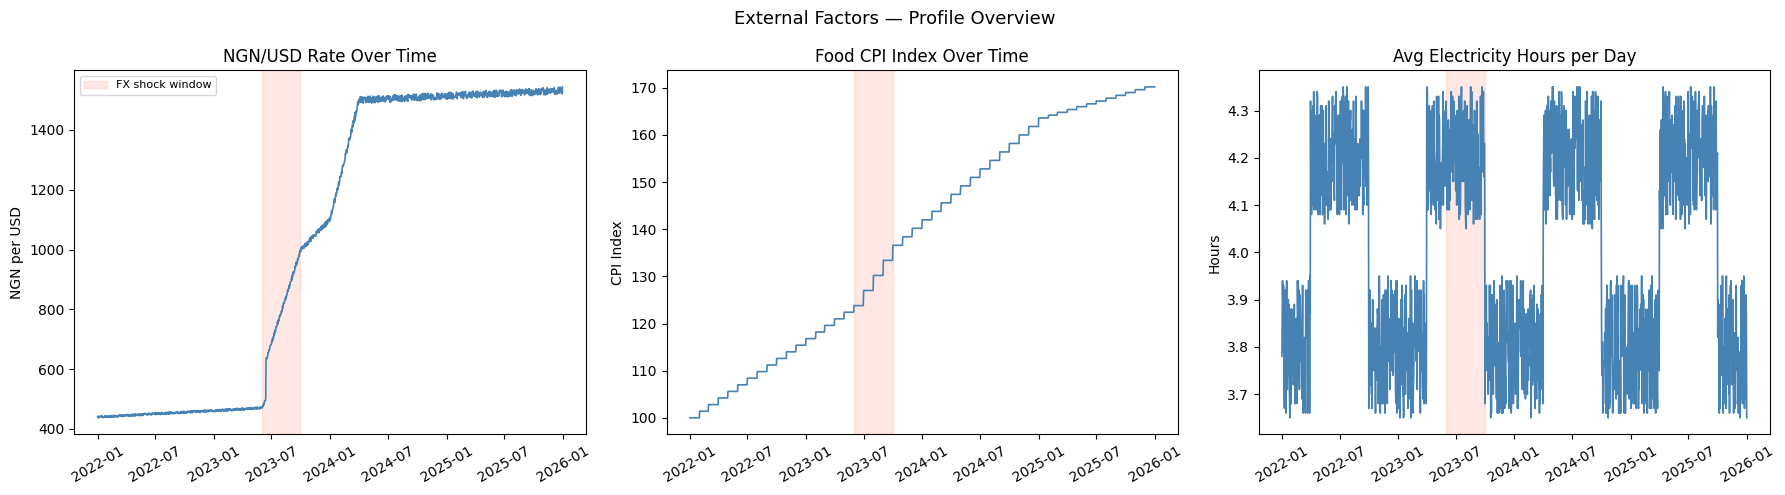

In [ ]:
print("INVENTORY SNAPSHOTS - FULL PROFILE\n")

inventory = dfs['inventory_snapshots'].copy()
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'], format='mixed', dayfirst=True)

print(f"Shape: {inventory.shape}")
print(f"Unique sellers: {inventory['seller_id'].nunique():,}")
print(f"Unique products: {inventory['product_id'].nunique():,}")
print(f"Date range: {inventory['snapshot_date'].min()} to {inventory['snapshot_date'].max()}")

print(f"\nSnapshots per seller")
print(inventory.groupby('seller_id').size().describe())

print(f"\nQuantity on hand stats")
print(inventory['quantity_on_hand'].describe())

print(f"\nZero stock snapshots")
zero_stock = (inventory['quantity_on_hand'] == 0).sum()
print(f"  Count: {zero_stock:,} ({zero_stock/len(inventory)*100:.1f}%)")

print(f"\nRestock flag distribution")
print(inventory['restock_flag'].value_counts())

print(f"\nNull counts")
print(inventory.isnull().sum())

print("\n\nMARKETING PARTICIPATION - FULL PROFILE\n")

marketing = dfs['marketing_participation'].copy()
marketing['enrollment_date'] = pd.to_datetime(marketing['enrollment_date'], format='mixed', dayfirst=True)

print(f"Shape: {marketing.shape}")
print(f"Unique sellers: {marketing['seller_id'].nunique():,}")
print(f"Unique campaigns: {marketing['campaign_id'].nunique():,}")

print(f"\nParticipations per seller")
print(marketing.groupby('seller_id').size().describe())

print(f"\nProducts enrolled stats")
print(marketing['products_enrolled'].describe())

print(f"\nDiscount absorbed pct stats")
print(marketing['discount_absorbed_pct'].describe())

print(f"\nNull counts")
print(marketing.isnull().sum())

print("\n\nCAMPAIGNS - FULL PROFILE\n")

campaigns = dfs['campaigns'].copy()
campaigns['start_date'] = pd.to_datetime(campaigns['start_date'], format='mixed', dayfirst=True)
campaigns['end_date'] = pd.to_datetime(campaigns['end_date'], format='mixed', dayfirst=True)

print(f"Shape: {campaigns.shape}")
print(f"Campaign type distribution")
print(campaigns['campaign_type'].value_counts())

print(f"\nDiscount pct stats")
print(campaigns['discount_pct'].describe())

print(f"\nCampaigns during FX shock window (Jun-Sep 2023)")
fx_camps = campaigns[
    (campaigns['start_date'] <= '2023-09-30') &
    (campaigns['end_date'] >= '2023-06-01')
]
print(fx_camps[['campaign_id', 'campaign_name', 'campaign_type', 'start_date', 'end_date', 'discount_pct']])

print("\n\nCATEGORIES - FULL PROFILE\n")

categories = dfs['categories'].copy()
print(f"Shape: {categories.shape}")
print(f"\nLevel distribution")
print(categories['level'].value_counts().sort_index())
print(f"\nLevel 1 categories")
print(categories[categories['level'] == 1][['category_id', 'category_name', 'commission_rate_pct']])
print(f"\nCommission rate stats")
print(categories['commission_rate_pct'].describe())

print("\n\nEXTERNAL FACTORS - FULL PROFILE\n")

ext = dfs['external_factors'].copy()
ext['factor_date'] = pd.to_datetime(ext['factor_date'], format='mixed', dayfirst=True)

print(f"Shape: {ext.shape}")
print(f"Date range: {ext['factor_date'].min()} to {ext['factor_date'].max()}")
print(f"\nFX shock flag distribution")
print(ext['fx_shock_flag'].value_counts())
print(f"\nNGN/USD rate stats")
print(ext['ngn_usd_rate'].describe())
print(f"\nNull counts")
print(ext.isnull().sum())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

shock_start = pd.to_datetime('2023-06-01')
shock_end = pd.to_datetime('2023-09-30')

axes[0].plot(ext['factor_date'], ext['ngn_usd_rate'], color='steelblue', linewidth=1.2)
axes[0].axvspan(shock_start, shock_end, alpha=0.15, color='tomato', label='FX shock window')
axes[0].set_title('NGN/USD Rate Over Time')
axes[0].set_ylabel('NGN per USD')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=8)

axes[1].plot(ext['factor_date'], ext['food_cpi_index'], color='steelblue', linewidth=1.2)
axes[1].axvspan(shock_start, shock_end, alpha=0.15, color='tomato')
axes[1].set_title('Food CPI Index Over Time')
axes[1].set_ylabel('CPI Index')
axes[1].tick_params(axis='x', rotation=30)

axes[2].plot(ext['factor_date'], ext['avg_electricity_hrs_day'], color='steelblue', linewidth=1.2)
axes[2].axvspan(shock_start, shock_end, alpha=0.15, color='tomato')
axes[2].set_title('Avg Electricity Hours per Day')
axes[2].set_ylabel('Hours')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('External Factors - Profile Overview', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/figures/external_factors_profile.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.10 inventory_snapshots.csv

**Overview**

The inventory snapshots table contains 181,948 records across 6 columns with no null values. Coverage spans 2,267 unique sellers (36.6% of the full seller population) and 3,499 unique products. The date range runs from January 2022 through September 2025. Sellers absent from this table did not use the platform's inventory management features - their absence is a behavioural signal rather than a data gap.

**Snapshot Frequency**

Snapshots per seller range from 52 to 364 with a mean of 80.3 and a median of 52. The minimum of 52 corresponds to exactly one year of weekly snapshots. Sellers with higher counts have multiple products being tracked simultaneously, inflating their individual record counts. The majority of sellers sit at the 52-snapshot minimum, meaning most tracked sellers manage a single product across one year of weekly records.

**Stock Levels and Restock Activity**

Quantity on hand has a mean of 65.8 and a median of 49, with a range of 0 to 440. Zero-stock snapshots account for 9.4% of all records, representing weeks where a tracked product was completely out of stock. The restock flag is True in 53,101 snapshots (29.2%), meaning nearly one in three snapshots records a restocking event among sellers who actively use inventory management.

### 2.11 marketing_participation.csv and campaigns.csv

**Marketing Participation**

The marketing participation table contains 550 records covering 334 unique sellers across 40 campaigns. Only 5.4% of the full seller population participated in any campaign, making non-participation the overwhelmingly dominant state. The median seller participated in exactly one campaign. Sellers enrolled an average of 2.9 products per participation and absorbed roughly half the campaign discount cost on average. GMV during campaign is null for 406 of 550 participations (73.8%), meaning most campaign participations did not generate measurable attributed revenue. The marketing_participation table is the authoritative source for confirmed campaign engagement - the activity log records campaign enrollment notification events for a much broader population than actually confirmed participation here.

**Campaigns**

40 campaigns span the full observation period from November 2022 through October 2025 across four types: category_feature (13), flash_sale (12), sponsored_search (9), and bundle_deal (6). Discount levels range from 5.5% to 34.8% with a mean of 20.2%. Two campaigns ran during the June–September 2023 FX shock window: a flash sale running June 1–5 at 13.1% discount and a sponsored search campaign running July 1–14 at 26.8% discount. Both are short-duration campaigns with limited temporal overlap with the shock period.

### 2.12 categories.csv and external_factors.csv

**Categories**

The categories table contains 90 records with a clean three-level hierarchy: 10 root categories at level 1, 36 at level 2, and 44 leaf categories at level 3. The 10 null parent_category_id values correspond exactly to the 10 root categories - no orphaned nodes exist. Commission rates range from 4.5% to 12.0% with a mean of 8.2%. Electronics, Computing, and Phones & Tablets carry the highest commission rates at 10.0% each. These three categories are also the primary import-dependent categories in the Nigerian marketplace context, and sellers whose primary category sits within these root categories will be flagged via an import_category_flag feature during Phase 3.

**External Factors**

The external factors table contains 1,461 daily records spanning January 2022 through December 2025 with no null values. The fx_shock_flag is True for 109 days covering the June–September 2023 Naira devaluation window. The NGN/USD rate held stable between ₦437 and ₦462 per USD from January 2022 through May 2023, then collapsed sharply during the shock window, reaching ₦1,500 by late 2023 and stabilising there through the end of the observation period - a 3.3x devaluation that fundamentally shifted the cost structure for import-dependent sellers. Food CPI rose steadily throughout the full observation period from an index of 100 in early 2022 to 170 by late 2025, with acceleration visible during and after the shock window. Average electricity hours per day fluctuates between 3.65 and 4.35 hours daily with no structural trend, reflecting routine power infrastructure variability rather than any systematic shift across the period.

In [ ]:
print("PHASE 2 - CROSS-TABLE COVERAGE SUMMARY\n")

total_sellers = dfs['sellers']['seller_id'].nunique()
print(f"Total sellers in sellers.csv: {total_sellers:,}\n")
print(f"{'Table':<40} {'In Table':>10} {'Coverage':>10} {'Absent':>10}")
print("-" * 75)
for name, df in dfs.items():
    if 'seller_id' in df.columns:
        n = df['seller_id'].nunique()
        pct = n / total_sellers * 100
        absent = total_sellers - n
        print(f"  {name:<38} {n:>10,} {pct:>9.1f}% {absent:>10,}")

print(f"\nDate range summary")
date_cols = {
    'sellers': 'registration_date',
    'orders': 'order_date',
    'products': 'listed_date',
    'seller_activity_log': 'activity_date',
    'external_factors': 'factor_date'
}
for table, col in date_cols.items():
    df = dfs[table].copy()
    df[col] = pd.to_datetime(df[col], format='mixed', dayfirst=True)
    print(f"  {table:<35} {str(df[col].min().date())} to {str(df[col].max().date())}")

print(f"\nSellers absent from both orders and activity log")
no_orders = set(dfs['sellers']['seller_id']) - set(dfs['orders']['seller_id'])
no_activity = set(dfs['sellers']['seller_id']) - set(dfs['seller_activity_log']['seller_id'])
print(f"  Count: {len(no_orders & no_activity):,}")

PHASE 2 - CROSS-TABLE COVERAGE SUMMARY

Total sellers in sellers.csv: 6,200

Table                                      In Table   Coverage     Absent
---------------------------------------------------------------------------
  sellers                                     6,200     100.0%          0
  orders                                      5,791      93.4%        409
  products                                    6,200     100.0%          0
  seller_activity_log                         5,796      93.5%        404
  seller_performance_metrics                  4,773      77.0%      1,427
  logistics                                   5,791      93.4%        409
  reviews                                     3,417      55.1%      2,783
  disputes                                    1,291      20.8%      4,909
  inventory_snapshots                         2,267      36.6%      3,933
  marketing_participation                       334       5.4%      5,866

Date range summary
  sellers    

### 2.13 Cross-Table Coverage Summary

| Table | Sellers Present | Coverage | Absent |
|---|---|---|---|
| sellers | 6,200 | 100.0% | 0 |
| orders | 5,791 | 93.4% | 409 |
| products | 6,200 | 100.0% | 0 |
| seller_activity_log | 5,796 | 93.5% | 404 |
| seller_performance_metrics | 4,773 | 77.0% | 1,427 |
| logistics | 5,791 | 93.4% | 409 |
| reviews | 3,417 | 55.1% | 2,783 |
| disputes | 1,291 | 20.8% | 4,909 |
| inventory_snapshots | 2,267 | 36.6% | 3,933 |
| marketing_participation | 334 | 5.4% | 5,866 |

Products and sellers achieve complete coverage across all 6,200 sellers. Orders and logistics both cover 93.4% of sellers with identical absent counts of 409, reflecting sellers who registered and listed products but never received a transaction. The seller_activity_log covers 93.5% - a nearly identical population to the transactional tables - with 114 sellers absent from both orders and the activity log simultaneously, representing the most completely inactive registrations in the dataset.

The 1,427 sellers absent from seller_performance_metrics correspond exactly to the null anchor_date population in the sellers table - sellers who never reached the commercial activity threshold required to generate weekly performance snapshots. Coverage declines steeply for the operational engagement tables: reviews at 55.1%, inventory_snapshots at 36.6%, disputes at 20.8%, and marketing_participation at 5.4%. These figures reflect the genuine distribution of seller engagement with platform features rather than data quality problems. Absence from each table carries its own meaning - a seller without reviews never received buyer feedback, a seller without inventory snapshots never engaged with stock management tools, a seller without a dispute record never generated a formal buyer complaint. All absence patterns will be encoded as binary coverage flags during feature engineering.

Date ranges are consistent across all tables. Seller registrations are bounded between January 2022 and September 2024, while transactional and operational records extend through late 2025 as sellers progress through their outcome windows. The external_factors table provides complete daily macroeconomic coverage from January 2022 through December 2025, ensuring full contextual data availability for every seller cohort.

# Phase 3 - Data Preparation

This phase transforms the raw tables into a modelling-ready dataset. The work follows a strict sequence - eligibility before labelling, labelling before retention analysis, retention analysis before window validation, window validation before splitting, splitting before feature construction. No step borrows from a later one.

The phase is structured in nine parts.

## Part 1 - Eligibility Determination

The first task is identifying which of the 6,200 sellers can actually be used for modelling. Four criteria must all be satisfied simultaneously.

The seller must have registered on or before 2024-10-01. The dataset enforces this already - registration dates are bounded at 2024-09-30 - so no sellers are dropped here. The criterion is retained as an explicit documented step to establish that the temporal boundary is satisfied by the full population.

The seller must have created at least one product listing within 30 days of registration. Sellers who registered but never listed within that window are treated as ghost registrations with no demonstrated commercial intent and excluded. 1,408 sellers are dropped at this step.

The seller must have a valid anchor date on or before 2024-10-01. The anchor date and anchor type are pre-computed in the sellers table and used directly as immutable reference points. Of the 4,792 sellers passing criterion 2, 986 have no valid anchor date - they listed within 30 days but never generated the commercial activity required to establish one. These are dropped. The remaining 3,806 sellers have anchor dates ranging from January 2022 through October 2024, with 3,652 (95.9%) carrying a first_delivered_order anchor and 154 (4.1%) carrying a first_listing anchor.

The seller's outcome window - anchor_date + 270 to anchor_date + 365 - must fall at least partially within the dataset, with a minimum of 30 days falling on or before 2025-12-31. No sellers are dropped at this step. Every eligible seller's outcome window has sufficient coverage within the dataset boundary.

The final eligible cohort is 3,806 sellers.

## Part 2 - Retention Label Construction

For each eligible seller, the binary retention label is constructed from the outcome window: anchor_date + 270 to anchor_date + 365 inclusive. A seller is labelled retained (1) if they have at least one delivered order falling within that window. Otherwise they are labelled churned (0). Labels are constructed directly from the orders table using only the delivered order status.

Of the 3,806 eligible sellers, 2,644 are churned (69.5%) and 1,162 are retained (30.5%), producing a class imbalance ratio of 2.28. Retention rates by anchor type reveal a sharp structural split - first_delivered_order sellers retain at 31.7% while first_listing sellers retain at just 2.6%, reflecting the fundamental difference between sellers who had already demonstrated buyer demand and those who had not. Cohort-level retention rates range from 25.8% to 35.2% with no systematic temporal trend, confirming that the training and test sets constructed in Part 5 will share broadly similar label distributions.

## Part 3 - Retention Pattern Analysis

Before any modelling decisions are made, the shape of retention and churn over time is examined empirically across the 12 months following each seller's anchor date.

The point-in-time activity curve starts at 94.2% in month 1, holds broadly stable through month 7 at 69.3%, then collapses through months 8 to 10 before plateauing at 30% from month 10 onward - directly consistent with the 30.5% retained label rate. The cumulative retention curve reaches 97.9% by month 2 and 99.4% by month 4, confirming that virtually every seller who will ever transact does so within the first four months. The growing divergence between the two curves from month 3 onward confirms permanent exit rather than temporary dormancy.

The period-to-period drop chart reveals two distinct clusters of accelerated attrition. The first spans months 2 to 4, with drops of 5.9 and 12.2 percentage points at the month 2-3 and 3-4 transitions. Activity then stabilises through months 4 to 7. The second and larger cluster begins at month 7-8 and peaks at the month 9-10 transition with a drop of 16.2 percentage points - the largest single-period drop in the sequence.

The monthly churn hazard rate is the most diagnostic view because it controls for the shrinking at-risk population at each transition. The hazard curve reveals two clearly separated exit waves. The first peaks at the month 3-4 transition with a hazard rate of 17.1%. After dropping sharply to 4.5% at month 5-6, the second wave builds from 12.8% at month 7-8 and peaks at 35.6% at the month 9-10 transition - the highest rate in the entire sequence. Hazard rates then collapse to under 2% for the final two transitions. At peak, more than one in three sellers still active at month 9 exit before month 10.

The two-wave hazard structure supports the seller archetype hypothesis underlying RQ4. A population with smooth, homogeneous attrition would not produce this pattern. The early exiters and late exiters appear to represent distinct seller populations with different failure modes.

## Part 4 - Observation Window Validation

The optimal observation window length is determined empirically using correlation analysis across six signals spanning four behavioural domains - transactional (GMV, order count), engagement (login count, days active), operational (on-time delivery rate), and reputational (whether a review was received). For each candidate window length of 30, 60, 90, and 120 days, the point-biserial correlation between each signal and the 12-month retention label is calculated. The average absolute correlation across all six signals serves as the primary selection criterion, supplemented by a check on the proportion of sellers with zero activity across all signals at each window length.

The results are plotted across window lengths with incremental gain analysis. The chosen window is the one at which the average correlation gain decelerates materially - where the information added by extending the window no longer justifies the operational cost of waiting longer before acting on model predictions. The hazard analysis from Part 3 provides independent context: the first exit wave peaks at the month 3-4 transition, meaning a 90-day or longer window risks capturing behaviour during the early exit event rather than stable early-tenure operations.

Once the window length is committed to, all features are constructed from data falling within that boundary. No data from after the window end is used in any feature calculation. Zeros within the window are treated as genuine signal rather than missing values - a seller who goes inactive mid-window has days of zero-activity data that is informative about their trajectory and must not be imputed.

## Part 5 - Train/Test Split

The split is temporal by registration cohort quarter. Sellers from 2022-Q1 through 2023-Q4 form the training set and sellers from 2024-Q1 through 2024-Q3 form the test set. Random splits are explicitly rejected - randomly assigning sellers to train and test would allow the model to learn from sellers whose anchor dates fall after those in the test set, breaking the temporal integrity of the validation design.

Cutting after 2023-Q4 produces 2,635 training sellers (69.2%) and 1,171 test sellers (30.8%) - the closest achievable split to 70/30 on a clean cohort boundary. The retention rate is 30.6% in training and 30.5% in test, confirming no distributional shift in the target variable across the boundary. The training set covers anchor dates from January 2022 through February 2024, spanning the pre-shock period and the FX shock transition. The test set covers anchor dates from January 2024 through October 2024, representing sellers who activated under the post-devaluation baseline - a more demanding and more honest test of generalisation than a random split would produce.

No feature statistics from the test set are used at any point during feature engineering, scaling, or model training. The test set is held out entirely until Phase 5.

## Part 6 - Feature Construction

Features are constructed strictly within the observation window determined in Part 4. The feature matrix spans nine domains, with 143 features in total.

**Transactional.** Core RFM measures - total orders, delivered orders, total GMV, average order value, and delivery rate - form the foundation. Failure signals are decomposed by type: seller_fault rate, buyer_refused count, and logistics_fault count, with seller_fault isolated because it reflects something within the seller's direct control. Two recency measures are constructed following the BG/NBD literature's insight that absence of recent transactions encodes latent state information: days since last delivered order and days to first delivered order, both encoded with a maximum penalty for sellers with no deliveries. Half-window splits compute order counts and GMV separately for the first and second 30 days, with ratio and difference features capturing directional momentum. A linear slope across eight weekly order counts captures the overall trajectory direction. Buyer diversity measures - unique buyer count and repeat buyer rate - and COD rate round out the domain.

**Listing and Catalogue.** Catalogue size features cover total products available and newly listed within the window. Quality proxies include average image count and average title word count. Category concentration is measured using a Herfindahl index across root categories, where a score of 1.0 indicates full concentration in a single category. Listing activity counts from the activity log - created, updated, paused, delisted, and price changes - capture within-window catalogue management behaviour. A binary catalogue_deterioration flag identifies sellers where paused and delisted listings exceed newly created ones.

**Platform Engagement.** Login count, total session minutes, and average session length capture depth of platform use. Days since last activity encodes recency of engagement. Activity type diversity - the count of distinct activity types engaged - serves as a platform embeddedness proxy. Three high-signal activity types receive binary flags alongside their raw counts: training module completion, analytics dashboard views, and campaign enrollment, each grounded in specific theoretical mechanisms from the literature. Half-window engagement ratio and weekly login slope capture engagement trajectory.

**Logistics and Delivery.** On-time delivery rate, average transit gap, and second attempt rate measure fulfilment reliability. Delivery zone proportion features capture geographic distribution across four zones. A composite geographic difficulty score weights zone proportions by structural delivery challenge. Platform logistics percentage and a binary uses_platform_logistics flag capture logistics integration as an asset specificity proxy.

**Customer Feedback.** Review and dispute features are the sparsest in the matrix, with 54.4% of sellers having no reviews and 90.0% having no disputes within the observation window. Binary coverage flags - has_any_review and has_any_dispute - are the primary signals in this domain, encoding the MNAR structure directly. Review quality features include average rating, negative review rate, positive review rate, and seller response rate. Dispute features include dispute rate, resolution outcomes, refund rate, and a lost_dispute_flag identifying sellers who experienced an adverse outcome in the early-tenure period.

**Performance Metrics.** Average seller score, score slope, score declining binary flag, and score deterioration capture the trajectory of the platform's composite performance indicator. Average completion rate, response rate, and on-time delivery rate from the weekly snapshots provide additional operational health signals. Trailing rating availability is captured with a binary flag given its 50.4% coverage rate.

**Seller Profile and Context.** Verification tier is encoded ordinally from 0 to 3. Anchor type, Lagos flag, payment preference, and four referral source binary flags capture static seller characteristics. Macroeconomic context features - NGN/USD rate, food CPI, and electricity hours at anchor date and averaged across the observation window - attach the environmental conditions each seller was operating in. Two shock context flags identify sellers whose observation window overlapped with the June 2023 FX devaluation and sellers in post-shock cohorts.

**Interaction Features.** Seven theoretically motivated interactions are constructed explicitly. gmv_x_logins captures the joint signal of commercial productivity and platform engagement, identifying the fragile profile of high-revenue sellers with low engagement that neither feature alone can express. completion_x_volume addresses the unreliability of rate-based features at low volumes, encoding effective rather than stated reliability. fx_x_import_category targets sellers in import-dependent categories during the shock period, where category exposure and macroeconomic disruption compound. zone_x_ontime contextualises delivery performance against the structural difficulty of the seller's shipping geography. order_momentum and login_momentum capture directional change across the observation window as first-minus-second-half differences. dual_deceleration is a binary flag set to 1 when both momentum measures are negative simultaneously - a seller declining on both transactional and engagement dimensions is in a qualitatively different position from one declining on only one.

**BG/NBD Derived Features.** The BG/NBD model is fitted on within-window transaction histories to produce two features that raw counts cannot replicate. p_alive is the estimated probability that a seller is still an active, non-churned commercial actor as of the observation window end. expected_transactions_next90 is the model's forecast of transaction volume in the 90 days immediately following the window. The key advantage is that BG/NBD captures the temporal pattern of transactions rather than just their volume - two sellers with identical order counts receive different scores if one transacted early and went quiet while the other maintained consistent activity throughout. These features bridge the probabilistic CLV tradition and the supervised ML framework, directly responding to the research gap identified in the literature review.

## Part 7 - Feature Quality Checks

After construction, every feature is inspected. Distributions are checked for unexpected shapes or impossible values. Missing value rates are documented and handling decisions recorded - structural zeros are distinguished from genuine gaps. Binary coverage flags are confirmed for all tables with partial seller coverage. Any feature showing suspiciously high bivariate correlation with the label is reviewed for potential leakage before being included in the modelling dataset.

## Part 8 - Univariate, Bivariate, and Multivariate Analysis

All analysis in this part runs on training data only. The test set is not touched.

Univariate analysis examines the distribution of every engineered feature separately for retained and churned sellers. For continuous features, overlapping density plots or box plots show whether the two groups separate on individual features. For categorical features, retention rates are computed within each category level.

Bivariate analysis quantifies the relationship between each feature and the retention label. Point-biserial correlation is used for continuous features and Cramér's V for categoricals. Results are ranked to identify which features carry the strongest individual signal. This also functions as a leakage audit - any feature with an implausibly high correlation with the label is reviewed before being passed to the model.

Multivariate analysis examines the correlation structure across all features. A correlation heatmap identifies redundant feature pairs and clusters of features measuring similar underlying constructs. Features that are very highly correlated with each other are candidates for consolidation or removal, particularly for the logistic regression baseline where multicollinearity matters most.

## Part 9 - Final Dataset Summary

The modelling dataset is saved with all features, labels, and seller metadata. Final dimensions, class balance, feature count by domain, and any outstanding data quality decisions are documented before Phase 4 begins.

In [ ]:
print("PHASE 3 - PART 1: ELIGIBILITY DETERMINATION\n")

DATASET_END = pd.Timestamp('2025-12-31')
OUTCOME_START_DAY = 270
OUTCOME_END_DAY = 365
MIN_OUTCOME_DAYS_IN_DATASET = 30
REGISTRATION_CEILING = pd.Timestamp('2024-10-01')

sellers = dfs['sellers'].copy()
sellers['registration_date'] = pd.to_datetime(sellers['registration_date'], dayfirst=True)
sellers['anchor_date'] = pd.to_datetime(sellers['anchor_date'], format='mixed', dayfirst=True)

products = dfs['products'].copy()
products['listed_date'] = pd.to_datetime(products['listed_date'], format='mixed', dayfirst=True)

first_listing = products.groupby('seller_id')['listed_date'].min().reset_index()
first_listing.columns = ['seller_id', 'first_listing_date']

print(f"Starting cohort: {len(sellers):,} sellers\n")

c1 = sellers[sellers['registration_date'] <= REGISTRATION_CEILING].copy()
print(f"Criterion 1 - registered on or before 2024-10-01")
print(f"  Dropped: {len(sellers) - len(c1):,}")
print(f"  Remaining: {len(c1):,}")

c2 = c1.merge(first_listing, on='seller_id', how='left')
c2['days_to_first_listing'] = (c2['first_listing_date'] - c2['registration_date']).dt.days
c2 = c2[c2['days_to_first_listing'].notna() & (c2['days_to_first_listing'] <= 30)].copy()
print(f"\nCriterion 2 - at least one listing within 30 days of registration")
print(f"  Dropped: {len(c1) - len(c2):,}")
print(f"  Remaining: {len(c2):,}")

c3 = c2[c2['anchor_date'].notna() & (c2['anchor_date'] <= REGISTRATION_CEILING)].copy()
print(f"\nCriterion 3 - valid anchor date on or before 2024-10-01")
print(f"  Dropped: {len(c2) - len(c3):,}")
print(f"  Remaining: {len(c3):,}")
print(f"  Anchor type breakdown:")
print(c3['anchor_type'].value_counts())

c3['outcome_start'] = c3['anchor_date'] + pd.Timedelta(days=OUTCOME_START_DAY)
c3['outcome_end'] = c3['anchor_date'] + pd.Timedelta(days=OUTCOME_END_DAY)
c3['days_in_dataset'] = (DATASET_END - c3['outcome_start']).dt.days.clip(lower=0)
c4 = c3[c3['days_in_dataset'] >= MIN_OUTCOME_DAYS_IN_DATASET].copy()
print(f"\nCriterion 4 - at least 30 days of outcome window within dataset")
print(f"  Dropped: {len(c3) - len(c4):,}")
print(f"  Remaining: {len(c4):,}")

print(f"\nFinal eligible cohort: {len(c4):,} sellers")
print(f"Anchor date range: {c4['anchor_date'].min().date()} to {c4['anchor_date'].max().date()}")
print(f"Outcome window range: {c4['outcome_start'].min().date()} to {c4['outcome_end'].max().date()}")
print(f"\nNull check on critical fields")
print(c4[['anchor_date', 'anchor_type', 'outcome_start', 'outcome_end']].isnull().sum())

eligible = c4.copy()

PHASE 3 - PART 1: ELIGIBILITY DETERMINATION

Starting cohort: 6,200 sellers

Criterion 1 - registered on or before 2024-10-01
  Dropped: 0
  Remaining: 6,200

Criterion 2 - at least one listing within 30 days of registration
  Dropped: 1,408
  Remaining: 4,792

Criterion 3 - valid anchor date on or before 2024-10-01
  Dropped: 986
  Remaining: 3,806
  Anchor type breakdown:
anchor_type
first_delivered_order    3652
first_listing             154
Name: count, dtype: int64

Criterion 4 - at least 30 days of outcome window within dataset
  Dropped: 0
  Remaining: 3,806

Final eligible cohort: 3,806 sellers
Anchor date range: 2022-01-06 to 2024-10-01
Outcome window range: 2022-10-03 to 2025-10-01

Null check on critical fields
anchor_date      0
anchor_type      0
outcome_start    0
outcome_end      0
dtype: int64


## Phase 3, Part 1 - Eligibility Determination

Four criteria are applied sequentially to identify the sellers who can be included in the modelling dataset. The drop count at each step is recorded to create a full audit trail for the dissertation methodology.

**Criterion 1 - Registration ceiling.** All 6,200 sellers registered on or before 2024-09-30, so no sellers are dropped here. The criterion is retained as an explicit documented step to establish that the temporal boundary is satisfied by the full population.

**Criterion 2 - First listing within 30 days of registration.** 1,408 sellers are dropped for failing to list any product within 30 days of registration. These sellers demonstrated no commercial intent after creating an account and cannot meaningfully be said to have started trading on the platform. Including them would conflate seller onboarding dropout with seller churn - two structurally different phenomena with different drivers and different intervention implications.

**Criterion 3 - Valid anchor date on or before 2024-10-01.** 986 sellers are dropped here. These sellers passed criterion 2 - they listed within 30 days - but have no pre-computed anchor date in the sellers table, meaning they never generated the commercial activity required to establish one. The anchor date is the immutable reference point from which the observation window, gap period, and outcome window are all measured. Without it, no downstream analysis is possible. The pre-computed anchor_date field in the sellers table is used directly and treated as authoritative. Of the 3,806 remaining sellers, 3,652 (95.9%) have a first_delivered_order anchor and 154 (4.1%) have a first_listing anchor.

**Criterion 4 - Outcome window coverage.** No sellers are dropped here. Every eligible seller has an outcome window - anchor_date + 270 to anchor_date + 365 - with at least 30 days falling within the dataset boundary of 31 December 2025. The outcome window range across the eligible cohort runs from October 2022 through October 2025, well within the dataset's temporal coverage.

**Final eligible cohort.** 3,806 sellers with anchor dates ranging from January 2022 through October 2024.

In [ ]:
print("PHASE 3 - PART 2: RETENTION LABEL CONSTRUCTION\n")

orders = dfs['orders'].copy()
orders['order_date'] = pd.to_datetime(orders['order_date'], format='mixed', dayfirst=True)

labels = []
for _, seller in eligible.iterrows():
    sid = seller['seller_id']
    outcome_start = seller['outcome_start']
    outcome_end = seller['outcome_end']

    in_window = orders[
        (orders['seller_id'] == sid) &
        (orders['order_status'] == 'delivered') &
        (orders['order_date'] >= outcome_start) &
        (orders['order_date'] <= outcome_end)
    ]
    labels.append({
        'seller_id': sid,
        'retained_12m': int(len(in_window) > 0)
    })

labels_df = pd.DataFrame(labels)
eligible = eligible.merge(labels_df, on='seller_id', how='left')

print(f"Label distribution")
print(eligible['retained_12m'].value_counts())
print(f"\nRetention rate: {eligible['retained_12m'].mean():.3f}")
print(f"\nRetention rate by anchor type")
print(eligible.groupby('anchor_type')['retained_12m'].agg(['mean', 'count']).round(3))
print(f"\nRetention rate by registration cohort")
print(eligible.groupby('registration_cohort_qtr')['retained_12m'].agg(['mean', 'count']).round(3))

n_churned = (eligible['retained_12m'] == 0).sum()
n_retained = (eligible['retained_12m'] == 1).sum()
print(f"\nClass imbalance ratio (churned:retained): {n_churned/n_retained:.2f}")
print(f"Churned: {n_churned:,} ({n_churned/len(eligible)*100:.1f}%)")
print(f"Retained: {n_retained:,} ({n_retained/len(eligible)*100:.1f}%)")

PHASE 3 - PART 2: RETENTION LABEL CONSTRUCTION

Label distribution
retained_12m
0    2644
1    1162
Name: count, dtype: int64

Retention rate: 0.305

Retention rate by anchor type
                        mean  count
anchor_type                        
first_delivered_order  0.317   3652
first_listing          0.026    154

Retention rate by registration cohort
                          mean  count
registration_cohort_qtr              
2022-Q1                  0.307    264
2022-Q2                  0.317    262
2022-Q3                  0.258    314
2022-Q4                  0.276    340
2023-Q1                  0.352    344
2023-Q2                  0.324    343
2023-Q3                  0.281    374
2023-Q4                  0.327    394
2024-Q1                  0.328    421
2024-Q2                  0.290    428
2024-Q3                  0.295    322

Class imbalance ratio (churned:retained): 2.28
Churned: 2,644 (69.5%)
Retained: 1,162 (30.5%)


## Phase 3, Part 2 - Retention Label Construction

A seller is labelled retained (1) if they have at least one delivered order falling within their outcome window - anchor_date + 270 to anchor_date + 365 days inclusive. Otherwise they are labelled churned (0). Labels are constructed directly from the orders table using only the delivered order status.

Of the 3,806 eligible sellers, 2,644 are churned (69.5%) and 1,162 are retained (30.5%), producing a class imbalance ratio of 2.28 churned-to-retained.

Retention rates differ substantially by anchor type. Sellers with a first_delivered_order anchor retain at 31.7%, while sellers with a first_listing anchor retain at only 2.6%. The gap reflects a fundamental difference in commercial viability between the two groups - a seller who received a delivered order within their first 30 days of listing had already demonstrated that buyers would transact with them. A seller whose anchor was simply their first listing date, with no early delivery, never demonstrated that demand existed for their products, and the label distribution confirms that almost none of them recover that momentum.

Cohort-level retention rates range from 25.8% in 2022-Q3 to 35.2% in 2023-Q1 with no systematic upward or downward trend across the observation period. The absence of a strong temporal pattern is methodologically useful - it means the training and test sets constructed during the temporal split in Part 5 will share broadly similar label distributions, reducing the risk that the split itself introduces distributional shift into the evaluation.

PHASE 3 - PART 3: RETENTION PATTERN ANALYSIS

Month      Point-in-time   Cumulative
1                  0.942        0.942
2                  0.946        0.979
3                  0.886        0.986
4                  0.764        0.990
5                  0.720        0.992
6                  0.717        0.993
7                  0.693        0.993
8                  0.620        0.993
9                  0.466        0.994
10                 0.304        0.994
11                 0.300        0.994
12                 0.298        0.994

Period-to-period change in activity rate
  Month 1 -> 2: +0.004
  Month 2 -> 3: -0.059
  Month 3 -> 4: -0.122
  Month 4 -> 5: -0.044
  Month 5 -> 6: -0.003
  Month 6 -> 7: -0.024
  Month 7 -> 8: -0.073
  Month 8 -> 9: -0.154
  Month 9 -> 10: -0.162
  Month 10 -> 11: -0.004
  Month 11 -> 12: -0.001

Monthly churn hazard rate
  Month 1 -> 2: 0.035  (126 of 3,585 at risk)
  Month 2 -> 3: 0.090  (323 of 3,599 at risk)
  Month 3 -> 4: 0.171  (576 of 3,374 at r

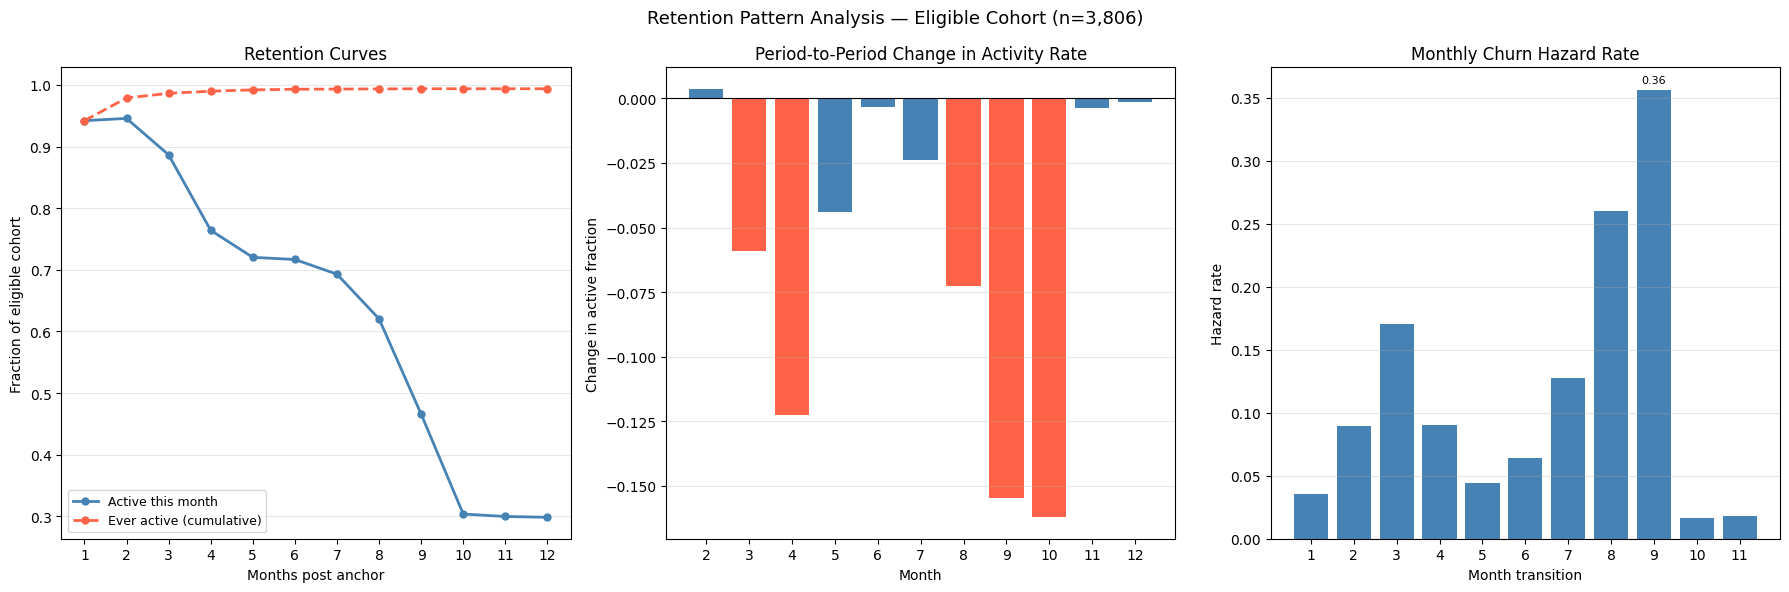

In [ ]:
print("PHASE 3 - PART 3: RETENTION PATTERN ANALYSIS\n")

orders = dfs['orders'].copy()
orders['order_date'] = pd.to_datetime(orders['order_date'], format='mixed', dayfirst=True)

eligible_orders = orders[
    (orders['seller_id'].isin(eligible['seller_id'])) &
    (orders['order_status'] == 'delivered')
].copy()

month_intervals = range(1, 13)
retention_records = []

for _, seller in eligible.iterrows():
    sid = seller['seller_id']
    anchor = seller['anchor_date']
    s_orders = eligible_orders[eligible_orders['seller_id'] == sid]['order_date']

    record = {'seller_id': sid}
    for m in month_intervals:
        window_start = anchor + pd.Timedelta(days=(m - 1) * 30)
        window_end = anchor + pd.Timedelta(days=m * 30)
        record[f'active_m{m}'] = int(
            ((s_orders >= window_start) & (s_orders < window_end)).sum() > 0
        )
    retention_records.append(record)

retention_df = pd.DataFrame(retention_records)
retention_df = retention_df.merge(
    eligible[['seller_id', 'anchor_date', 'retained_12m']], on='seller_id'
)

months = list(month_intervals)
point_in_time = [retention_df[f'active_m{m}'].mean() for m in months]

cumulative = []
for m in months:
    cols = [f'active_m{k}' for k in range(1, m + 1)]
    cumulative.append((retention_df[cols].sum(axis=1) > 0).mean())

period_drop = [point_in_time[i] - point_in_time[i-1] for i in range(1, len(point_in_time))]

hazard_months, hazard_rates, hazard_at_risk, hazard_churned = [], [], [], []
for m in range(1, 12):
    active_now = retention_df[f'active_m{m}'] == 1
    active_next = retention_df[f'active_m{m+1}'] == 1
    at_risk = active_now.sum()
    churned = (active_now & ~active_next).sum()
    hazard_months.append(m)
    hazard_rates.append(churned / at_risk if at_risk > 0 else 0)
    hazard_at_risk.append(at_risk)
    hazard_churned.append(churned)

print(f"{'Month':<8} {'Point-in-time':>15} {'Cumulative':>12}")
for i, m in enumerate(months):
    print(f"{m:<8} {point_in_time[i]:>15.3f} {cumulative[i]:>12.3f}")

print(f"\nPeriod-to-period change in activity rate")
for i, drop in enumerate(period_drop):
    print(f"  Month {i+1} -> {i+2}: {drop:+.3f}")

print(f"\nMonthly churn hazard rate")
for i, m in enumerate(hazard_months):
    print(f"  Month {m} -> {m+1}: {hazard_rates[i]:.3f}  ({hazard_churned[i]:,} of {hazard_at_risk[i]:,} at risk)")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].plot(months, point_in_time, color='steelblue', linewidth=2,
             marker='o', markersize=5, label='Active this month')
axes[0].plot(months, cumulative, color='tomato', linewidth=2,
             marker='o', markersize=5, linestyle='--', label='Ever active (cumulative)')
axes[0].set_title('Retention Curves')
axes[0].set_xlabel('Months post anchor')
axes[0].set_ylabel('Fraction of eligible cohort')
axes[0].set_xticks(months)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

drop_months = list(range(2, 13))
bar_colors = ['tomato' if d < -0.05 else 'steelblue' for d in period_drop]
axes[1].bar(drop_months, period_drop, color=bar_colors, edgecolor='none')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Period-to-Period Change in Activity Rate')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Change in active fraction')
axes[1].set_xticks(drop_months)
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(hazard_months, hazard_rates, color='steelblue', edgecolor='none')
axes[2].set_title('Monthly Churn Hazard Rate')
axes[2].set_xlabel('Month transition')
axes[2].set_ylabel('Hazard rate')
axes[2].set_xticks(hazard_months)
axes[2].grid(axis='y', alpha=0.3)
max_hazard = max(hazard_rates)
for i, rate in enumerate(hazard_rates):
    if rate >= max_hazard * 0.85:
        axes[2].annotate(f'{rate:.2f}', xy=(hazard_months[i], rate),
                         xytext=(0, 5), textcoords='offset points',
                         ha='center', fontsize=8)

plt.suptitle('Retention Pattern Analysis - Eligible Cohort (n=3,806)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/figures/retention_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 3, Part 3 - Retention Pattern Analysis

The retention pattern analysis examines how seller activity evolves across the 12 months following each seller's anchor date. Three views are used: a point-in-time activity curve tracking what fraction of the eligible cohort was active in each monthly window, a cumulative retention curve tracking what fraction had ever been active up to that point, and a monthly churn hazard rate measuring the exit probability among sellers still active at each transition.

**Retention Curves**

The point-in-time activity rate starts at 94.2% in month 1 and rises slightly to 94.6% in month 2 before declining. The first drop is visible at month 3, where the rate falls to 88.6%, followed by a sharper drop to 76.4% at month 4. The curve then flattens somewhat through months 4-7, holding between 69-76%, before collapsing again through months 8-10 - dropping from 62.0% at month 8 to 46.6% at month 9 and 30.4% at month 10. From month 10 onward the curve flatlines at approximately 30%, consistent with the 30.5% retained label rate. Sellers who survive past the month 9-10 transition face essentially no further exit risk within the observation window.

The cumulative retention curve reaches 97.9% by month 2 and 99.4% by month 4, meaning nearly every seller who will ever transact does so within the first four months. The growing divergence between the two curves from month 3 onward confirms that sellers exiting throughout the observation period are doing so permanently rather than going temporarily dormant.

**Period-to-Period Changes**

The period-to-period drop chart reveals two distinct clusters of accelerated attrition separated by a period of relative stability. The first cluster spans months 2-4, with drops of 5.9 and 12.2 percentage points at the month 2-3 and month 3-4 transitions respectively. Activity then stabilises through months 4-7, with small drops of 4.4, 0.3, and 2.4 percentage points. The second and larger cluster begins at month 7-8 with a drop of 7.3 percentage points, accelerating to 15.4 points at month 8-9 and 16.2 points at month 9-10 - the largest single-period drop in the entire sequence. From month 10 onward the curve is essentially flat.

**Monthly Churn Hazard Rate**

The hazard rate is the most diagnostic view because it controls for the shrinking at-risk population at each transition. The pattern reveals two clearly separated exit waves rather than a single concentrated event.

The first wave peaks at month 3-4 with a hazard rate of 17.1% - meaning that of the 3,374 sellers still active at month 3, 17.1% had exited by month 4. This early wave represents sellers who generated initial activity but whose commercial operations failed to stabilise within the first quarter. The hazard rate then drops sharply to 9.0% at month 4-5 and continues declining to 4.5% at month 5-6, indicating that sellers who survive the early exit event enter a period of relative stability.

The second wave begins building at month 7-8 with a hazard rate of 12.8% and peaks at month 9-10 with a rate of 35.6% - the highest hazard rate in the entire sequence. At the month 9-10 transition, more than one in three sellers who were still active at month 9 had exited by month 10. The hazard rate then collapses to 1.6% and 1.8% at the final two transitions, confirming that sellers who clear the second wave constitute the stable retained population.

## Phase 3, Part 4 - Observation Window Validation

The observation window is the period immediately following a seller's anchor date during which behavioural features are measured. The window must satisfy three conditions: it must be long enough to capture sufficient transactional and behavioural signal, it must end far enough before the outcome window to preserve a meaningful gap period, and it must not extend into the period when churn begins to materialise - otherwise features would partially reflect the exit process rather than early steady-state behaviour.

**Coverage by Window Length**

Five candidate window lengths are evaluated - 30, 45, 60, 75, and 90 days - against two coverage metrics: the fraction of eligible sellers with at least one order within the window, and the fraction with at least one activity log record. Neither metric includes a gap overlap at any window length. Even at 90 days, there are 180 days between the end of the observation window and the start of the outcome window, well in excess of any contamination threshold.

Coverage increases with window length but with diminishing returns. At 30 days, 96.7% of sellers have at least one order and 95.9% have at least one activity record. At 60 days these figures rise to 98.9% and 98.3% respectively. Extending to 90 days adds only a further 0.5 and 0.8 percentage points. The contamination check - sellers whose first post-anchor delivered order falls entirely outside the observation window, meaning the window captures no order signal for them - drops from 5.2% at 30 days to 1.5% at 60 days and 0.7% at 90 days. The gain from 60 to 90 days is 0.8 percentage points of coverage against 0.8 percentage points of contamination risk reduction.

**Window Selection**

The retention pattern analysis in Part 3 showed that the first churn hazard wave peaks at the month 3-4 transition, corresponding to roughly days 60-90 post anchor. A 90-day observation window would extend into this early exit period, meaning features constructed for sellers who churn in the first wave would partially capture behaviour during the exit event itself rather than representing normal early-period operations. This is the window contamination problem - features should measure what a seller looks like when operating normally, not what they look like as they are beginning to disengage.

A 60-day window ends before the first hazard spike materialises, keeping the feature measurement period in the stable early phase identified in Part 3. Coverage at 60 days is high - 98.9% for orders and 98.3% for activity - and the 1.5% of sellers with no order signal in the window is an acceptable and unavoidable consequence of the window design for sellers who transact slowly in their first weeks. The 210-day buffer between the observation window end and the outcome window start is more than sufficient to ensure temporal separation.

A 60-day observation window is therefore selected as the basis for all feature engineering in Phase 3, Part 5 onward.

In [ ]:
print("PHASE 3 - PART 5: TRAIN/TEST SPLIT\n")

print("Cohort distribution in eligible cohort")
cohort_counts = eligible.groupby('registration_cohort_qtr').agg(
    n=('seller_id', 'count'),
    retention_rate=('retained_12m', 'mean')
).round(3)
cohort_counts['cumulative_n'] = cohort_counts['n'].cumsum()
cohort_counts['cumulative_pct'] = (cohort_counts['cumulative_n'] / len(eligible) * 100).round(1)
print(cohort_counts.to_string())

print(f"\nTotal eligible: {len(eligible):,}")
print(f"Target train size (~70%): {int(len(eligible) * 0.70):,}")

PHASE 3 - PART 5: TRAIN/TEST SPLIT

Cohort distribution in eligible cohort
                           n  retention_rate  cumulative_n  cumulative_pct
registration_cohort_qtr                                                   
2022-Q1                  264           0.307           264             6.9
2022-Q2                  262           0.317           526            13.8
2022-Q3                  314           0.258           840            22.1
2022-Q4                  340           0.276          1180            31.0
2023-Q1                  344           0.352          1524            40.0
2023-Q2                  343           0.324          1867            49.1
2023-Q3                  374           0.281          2241            58.9
2023-Q4                  394           0.327          2635            69.2
2024-Q1                  421           0.328          3056            80.3
2024-Q2                  428           0.290          3484            91.5
2024-Q3                  

In [ ]:
print("PHASE 3 - PART 5: TRAIN/TEST SPLIT\n")

TRAIN_CUTOFF = '2023-Q4'

train = eligible[eligible['registration_cohort_qtr'] <= TRAIN_CUTOFF].copy()
test = eligible[eligible['registration_cohort_qtr'] > TRAIN_CUTOFF].copy()

print(f"Split point: cohorts up to and including {TRAIN_CUTOFF} -> train")
print(f"             cohorts from 2024-Q1 onward -> test\n")

print(f"Train set: {len(train):,} sellers ({len(train)/len(eligible)*100:.1f}%)")
print(f"Test set:  {len(test):,} sellers ({len(test)/len(eligible)*100:.1f}%)")

print(f"\nLabel distribution - train")
print(train['retained_12m'].value_counts())
print(f"Retention rate: {train['retained_12m'].mean():.3f}")

print(f"\nLabel distribution - test")
print(test['retained_12m'].value_counts())
print(f"Retention rate: {test['retained_12m'].mean():.3f}")

print(f"\nAnchor date range - train: {train['anchor_date'].min().date()} to {train['anchor_date'].max().date()}")
print(f"Anchor date range - test:  {test['anchor_date'].min().date()} to {test['anchor_date'].max().date()}")

print(f"\nCohorts in train")
print(train['registration_cohort_qtr'].value_counts().sort_index())
print(f"\nCohorts in test")
print(test['registration_cohort_qtr'].value_counts().sort_index())

print(f"\nRetention rate by anchor type - train")
print(train.groupby('anchor_type')['retained_12m'].agg(['mean','count']).round(3))
print(f"\nRetention rate by anchor type - test")
print(test.groupby('anchor_type')['retained_12m'].agg(['mean','count']).round(3))

PHASE 3 - PART 5: TRAIN/TEST SPLIT

Split point: cohorts up to and including 2023-Q4 -> train
             cohorts from 2024-Q1 onward -> test

Train set: 2,635 sellers (69.2%)
Test set:  1,171 sellers (30.8%)

Label distribution - train
retained_12m
0    1830
1     805
Name: count, dtype: int64
Retention rate: 0.306

Label distribution - test
retained_12m
0    814
1    357
Name: count, dtype: int64
Retention rate: 0.305

Anchor date range - train: 2022-01-06 to 2024-02-16
Anchor date range - test:  2024-01-06 to 2024-10-01

Cohorts in train
registration_cohort_qtr
2022-Q1    264
2022-Q2    262
2022-Q3    314
2022-Q4    340
2023-Q1    344
2023-Q2    343
2023-Q3    374
2023-Q4    394
Name: count, dtype: int64

Cohorts in test
registration_cohort_qtr
2024-Q1    421
2024-Q2    428
2024-Q3    322
Name: count, dtype: int64

Retention rate by anchor type - train
                        mean  count
anchor_type                        
first_delivered_order  0.318   2529
first_listing          

## Phase 3, Part 5 - Train/Test Split

The dataset is split temporally by registration cohort quarter. Sellers from 2022-Q1 through 2023-Q4 form the training set and sellers from 2024-Q1 through 2024-Q3 form the test set. A random split is explicitly rejected - randomly assigning sellers to train and test would allow the model to learn from sellers whose anchor dates fall after those in the test set, breaking the temporal integrity of the validation design and producing optimistically biased performance estimates that would not generalise to genuinely unseen future cohorts.

The split point is chosen to achieve the closest possible approximation to a 70/30 division on a clean cohort boundary. Cutting after 2023-Q4 produces 2,635 training sellers (69.2%) and 1,171 test sellers (30.8%) - the tightest achievable split around the 70% target without crossing a cohort boundary. The next available boundary at 2023-Q3 would yield only 58.9% in training, and the one at 2024-Q1 would overshoot to 80.3%.

The training set spans anchor dates from January 2022 through February 2024, covering the early platform growth period, the mid-2023 macroeconomic disruption, and the subsequent recovery. The test set spans anchor dates from January 2024 through October 2024, representing sellers who activated under the post-devaluation baseline - a more demanding test of generalisation than a random split would produce, since the model must predict retention for a cohort operating under materially different macroeconomic conditions from those that dominated the training period.

The retention rate is 30.6% in the training set and 30.5% in the test set - effectively identical, confirming that the temporal split does not introduce distributional shift in the target variable. Anchor type composition is consistent across both sets, with first_delivered_order sellers retaining at 31.8% in training and 31.6% in test. No feature statistics, scaling parameters, or imputation values from the test set are used at any point during feature engineering or model training. The test set is held out entirely until Phase 5 evaluation.

In [ ]:
print("PHASE 3 - PART 6: FEATURE ENGINEERING\n")
print("Domain 1 - Transactional features (RFM + trajectory)\n")

OBS_DAYS = 60
HALF = 30  # first vs second half split point

orders = dfs['orders'].copy()
orders['order_date'] = pd.to_datetime(orders['order_date'], format='mixed', dayfirst=True)

# restrict to eligible sellers and observation window only
# no data outside anchor_date to anchor_date + 60 days
eligible_sids = set(eligible['seller_id'])

records = []

for _, seller in eligible.iterrows():
    sid = seller['seller_id']
    anchor = seller['anchor_date']
    obs_end = anchor + pd.Timedelta(days=OBS_DAYS)
    half_point = anchor + pd.Timedelta(days=HALF)

    s_orders = orders[
        (orders['seller_id'] == sid) &
        (orders['order_date'] >= anchor) &
        (orders['order_date'] < obs_end)
    ].copy()

    delivered = s_orders[s_orders['order_status'] == 'delivered']
    failed = s_orders[s_orders['order_status'] == 'failed_delivery']
    cancelled = s_orders[s_orders['order_status'] == 'cancelled_by_seller']
    returned = s_orders[s_orders['order_status'] == 'returned_to_seller']

    # --- base RFM ---
    total_orders = len(s_orders)
    total_delivered = len(delivered)
    total_gmv = delivered['gmv_ngn'].sum() if len(delivered) > 0 else 0
    avg_order_value = delivered['gmv_ngn'].mean() if len(delivered) > 0 else 0
    delivery_rate = total_delivered / total_orders if total_orders > 0 else 0

    # failure breakdown
    seller_fault_count = (s_orders['failure_reason'] == 'seller_fault').sum()
    buyer_refused_count = (s_orders['failure_reason'] == 'buyer_refused').sum()
    logistics_fault_count = (s_orders['failure_reason'] == 'logistics_fault').sum()
    seller_fault_rate = seller_fault_count / total_orders if total_orders > 0 else 0

    # recency - days since last delivered order relative to window end
    if len(delivered) > 0:
        last_delivery = delivered['order_date'].max()
        days_since_last_delivery = (obs_end - last_delivery).days
        days_to_first_delivery = (delivered['order_date'].min() - anchor).days
    else:
        days_since_last_delivery = OBS_DAYS  # no delivery - maximum recency penalty
        days_to_first_delivery = OBS_DAYS

    # --- half-window split ---
    del_h1 = delivered[delivered['order_date'] < half_point]
    del_h2 = delivered[delivered['order_date'] >= half_point]
    gmv_h1 = del_h1['gmv_ngn'].sum()
    gmv_h2 = del_h2['gmv_ngn'].sum()
    orders_h1 = len(del_h1)
    orders_h2 = len(del_h2)

    # trajectory - second half minus first half (positive = growing, negative = declining)
    order_trajectory = orders_h2 - orders_h1
    gmv_trajectory = gmv_h2 - gmv_h1

    # ratio - h2/h1 growth rate (1.0 = stable, >1 growing, <1 declining)
    order_growth_rate = orders_h2 / orders_h1 if orders_h1 > 0 else 0
    gmv_growth_rate = gmv_h2 / gmv_h1 if gmv_h1 > 0 else 0

    # --- weekly order counts for slope ---
    weekly_orders = []
    for w in range(8):  # 8 weeks in 60 days (last partial week included)
        w_start = anchor + pd.Timedelta(days=w * 7)
        w_end = anchor + pd.Timedelta(days=(w + 1) * 7)
        wk_delivered = ((delivered['order_date'] >= w_start) &
                        (delivered['order_date'] < w_end)).sum()
        weekly_orders.append(wk_delivered)

    # linear slope of weekly order counts - positive = accelerating
    if sum(weekly_orders) > 0:
        x = np.arange(len(weekly_orders))
        slope = np.polyfit(x, weekly_orders, 1)[0]
    else:
        slope = 0.0

    # payment method mix
    cod_orders = (s_orders['payment_method'] == 'cod').sum()
    cod_rate = cod_orders / total_orders if total_orders > 0 else 0

    # unique buyers
    unique_buyers = s_orders['buyer_id'].nunique() if total_orders > 0 else 0
    repeat_buyer_rate = (
        (s_orders['buyer_id'].value_counts() > 1).sum() / unique_buyers
        if unique_buyers > 0 else 0
    )

    records.append({
        'seller_id': sid,
        # RFM base
        'total_orders_obs': total_orders,
        'total_delivered_obs': total_delivered,
        'total_gmv_obs': total_gmv,
        'avg_order_value_obs': avg_order_value,
        'delivery_rate_obs': delivery_rate,
        'days_since_last_delivery': days_since_last_delivery,
        'days_to_first_delivery': days_to_first_delivery,
        # failure signals
        'seller_fault_rate_obs': seller_fault_rate,
        'seller_fault_count_obs': seller_fault_count,
        'buyer_refused_count_obs': buyer_refused_count,
        'logistics_fault_count_obs': logistics_fault_count,
        # trajectory
        'order_trajectory_obs': order_trajectory,
        'gmv_trajectory_obs': gmv_trajectory,
        'order_growth_rate_obs': order_growth_rate,
        'gmv_growth_rate_obs': gmv_growth_rate,
        'weekly_order_slope_obs': slope,
        # half window
        'orders_h1': orders_h1,
        'orders_h2': orders_h2,
        'gmv_h1': gmv_h1,
        'gmv_h2': gmv_h2,
        # buyer diversity
        'unique_buyers_obs': unique_buyers,
        'repeat_buyer_rate_obs': repeat_buyer_rate,
        # payment
        'cod_rate_obs': cod_rate,
    })

txn_features = pd.DataFrame(records)

print(f"Transaction features shape: {txn_features.shape}")
print(f"\nNull counts")
print(txn_features.isnull().sum())
print(f"\nKey stats")
print(txn_features[['total_orders_obs', 'total_delivered_obs', 'total_gmv_obs',
                      'delivery_rate_obs', 'weekly_order_slope_obs',
                      'order_growth_rate_obs']].describe().round(3))

print(f"\nSellers with zero orders in window: {(txn_features['total_orders_obs'] == 0).sum():,}")
print(f"Sellers with zero deliveries in window: {(txn_features['total_delivered_obs'] == 0).sum():,}")

PHASE 3 - PART 6: FEATURE ENGINEERING

Domain 1 - Transactional features (RFM + trajectory)

Transaction features shape: (3806, 24)

Null counts
seller_id                    0
total_orders_obs             0
total_delivered_obs          0
total_gmv_obs                0
avg_order_value_obs          0
delivery_rate_obs            0
days_since_last_delivery     0
days_to_first_delivery       0
seller_fault_rate_obs        0
seller_fault_count_obs       0
buyer_refused_count_obs      0
logistics_fault_count_obs    0
order_trajectory_obs         0
gmv_trajectory_obs           0
order_growth_rate_obs        0
gmv_growth_rate_obs          0
weekly_order_slope_obs       0
orders_h1                    0
orders_h2                    0
gmv_h1                       0
gmv_h2                       0
unique_buyers_obs            0
repeat_buyer_rate_obs        0
cod_rate_obs                 0
dtype: int64

Key stats
       total_orders_obs  total_delivered_obs  total_gmv_obs  \
count          3806.000 

In [ ]:
txn_features['has_any_order_obs'] = (txn_features['total_orders_obs'] > 0).astype(int)
txn_features['has_any_delivery_obs'] = (txn_features['total_delivered_obs'] > 0).astype(int)

print(f"has_any_order_obs distribution")
print(txn_features['has_any_order_obs'].value_counts())
print(f"\nhas_any_delivery_obs distribution")
print(txn_features['has_any_delivery_obs'].value_counts())
print(f"\nFinal txn_features shape: {txn_features.shape}")

has_any_order_obs distribution
has_any_order_obs
1    3764
0      42
Name: count, dtype: int64

has_any_delivery_obs distribution
has_any_delivery_obs
1    3725
0      81
Name: count, dtype: int64

Final txn_features shape: (3806, 26)


## Phase 3, Part 6 - Feature Engineering

### Domain 1 - Transactional Features

Transactional features form the foundation of the feature set and are grounded in the recency-frequency-monetary framework that has served as the basis of customer engagement research across several decades. For marketplace sellers, however, raw transaction counts and GMV aggregates capture only a fraction of the relevant signal. The literature is explicit that directional momentum - whether a seller's order volume is growing or declining across the observation window - outperforms end-point aggregates in predicting departure, because trajectory encodes information about the underlying generative process rather than just its current state.

Twenty-four features are constructed from the orders table using only data falling within the 60-day observation window. All features are anchored to each seller's individual anchor_date to prevent any temporal leakage.

**RFM Base**

The core transactional measures are total orders, total delivered orders, total GMV, and average order value within the window. Delivery rate - delivered orders as a fraction of total orders - captures early fulfilment reliability, with a mean of 72.2% across the eligible cohort and meaningful spread from 0 to 100%. Two recency measures are constructed: days since last delivered order relative to the observation window end, and days to first delivered order from anchor. Both are encoded with a maximum penalty of 60 for sellers with no deliveries, treating complete commercial inactivity as the worst-case recency signal rather than as a missing value.

**Failure Signals**

Three failure reason features are constructed from non-delivered orders: seller_fault rate and count, buyer_refused count, and logistics_fault count. Seller_fault rate is computed as a fraction of total orders rather than total failures, making it comparable across sellers of different volumes. Seller_fault is isolated from the other failure reasons because it reflects something within the seller's direct control - unlike logistics failures or buyer rejection - and the literature on expectation-disconfirmation predicts that controllable early failures are particularly damaging to seller commitment.

**Trajectory and Half-Window Split**

Four trajectory features capture directional momentum within the window. Order trajectory and GMV trajectory measure the raw difference between the second 30 days and the first 30 days of the observation window. Order growth rate and GMV growth rate express the same relationship as a ratio, where values below 1.0 indicate decline and values above 1.0 indicate growth. The mean order growth rate of 0.770 confirms that on average sellers are processing fewer orders in the second half of the window than the first - consistent with the liability of newness pattern where initial activity bursts are followed by a period of consolidation or early disengagement. Weekly order slope fits a linear trend across 8 weekly order counts within the window, capturing the direction and magnitude of the overall trajectory rather than just the endpoint-to-endpoint change. The negative mean slope of -0.241 reinforces the declining trend at the population level.

**Buyer Diversity**

Unique buyer count and repeat buyer rate within the window capture demand-side breadth. A seller with many unique buyers has demonstrated broad market reach; a seller with a high repeat buyer rate has demonstrated the ability to generate return visits - both theoretically associated with lower churn risk through the switching cost logic that accumulated buyer relationships represent.

**Operational Context**

COD rate captures the fraction of orders placed through cash on delivery, which in the Nigerian context reflects both buyer trust levels and the operational complexity of the seller's fulfilment model. High COD rates introduce cash flow and failed delivery risk that sellers managing tight operating margins may find difficult to sustain.

**Coverage**

42 sellers have zero orders and 81 have zero deliveries within the observation window. These are predominantly first_listing anchor sellers who listed products but generated no transactional activity in their first 60 days. They receive zero counts and maximum recency penalties, which is the correct encoding - their absence of activity is itself a strong churn signal rather than missing data.


In [ ]:
print("Domain 2 - Listing and catalogue features\n")

products = dfs['products'].copy()
products['listed_date'] = pd.to_datetime(products['listed_date'], format='mixed', dayfirst=True)

activity = dfs['seller_activity_log'].copy()
activity['activity_date'] = pd.to_datetime(activity['activity_date'], format='mixed', dayfirst=True)

categories = dfs['categories'].copy()

# build root category lookup
cat_parent = categories.set_index('category_id')['parent_category_id'].to_dict()

def get_root(cat_id):
    visited = set()
    while True:
        parent = cat_parent.get(cat_id)
        if parent is None or (isinstance(parent, float) and np.isnan(parent)):
            return cat_id
        if cat_id in visited:
            return cat_id
        visited.add(cat_id)
        cat_id = int(parent)

records = []

for _, seller in eligible.iterrows():
    sid = seller['seller_id']
    anchor = seller['anchor_date']
    obs_end = anchor + pd.Timedelta(days=OBS_DAYS)

    # products available during observation window
    s_prods = products[
        (products['seller_id'] == sid) &
        (products['listed_date'] < obs_end)
    ].copy()

    # products newly listed within window
    s_prods_new = s_prods[s_prods['listed_date'] >= anchor]

    # listing-related activity events within window
    s_act = activity[
        (activity['seller_id'] == sid) &
        (activity['activity_date'] >= anchor) &
        (activity['activity_date'] < obs_end)
    ]

    has_any_listing = int(len(s_prods) > 0)
    n_products_total = len(s_prods)
    n_products_new_obs = len(s_prods_new)

    if has_any_listing:
        avg_images = s_prods['image_count'].mean()
        avg_title_words = s_prods['title_word_count'].mean()
        avg_price = s_prods['price_ngn'].mean()
        price_range = s_prods['price_ngn'].max() - s_prods['price_ngn'].min()
        active_listing_rate = (s_prods['listing_status'] == 'active').mean()
        has_stock_indicated = int(s_prods['stock_indicated'].any())

        root_cats = s_prods['category_id'].apply(get_root)
        cat_shares = root_cats.value_counts(normalize=True)
        herfindahl = float((cat_shares ** 2).sum())
        n_distinct_categories = len(cat_shares)
    else:
        avg_images = 0
        avg_title_words = 0
        avg_price = 0
        price_range = 0
        active_listing_rate = 0
        has_stock_indicated = 0
        herfindahl = 1.0
        n_distinct_categories = 0

    listing_paused = (s_act['activity_type'] == 'listing_paused').sum()
    listing_delisted = (s_act['activity_type'] == 'listing_delisted').sum()
    listing_created = (s_act['activity_type'] == 'listing_created').sum()
    listing_updated = (s_act['activity_type'] == 'listing_updated').sum()
    price_changed = (s_act['activity_type'] == 'price_changed').sum()

    # deterioration signal - did seller delist or pause more than they created?
    catalogue_deterioration = int((listing_paused + listing_delisted) > listing_created)

    records.append({
        'seller_id': sid,
        # coverage flag
        'has_any_listing': has_any_listing,
        # catalogue size
        'n_products_total_obs': n_products_total,
        'n_products_new_obs': n_products_new_obs,
        # quality signals
        'avg_images_obs': avg_images,
        'avg_title_words_obs': avg_title_words,
        'avg_price_obs': avg_price,
        'price_range_obs': price_range,
        'active_listing_rate_obs': active_listing_rate,
        'has_stock_indicated': has_stock_indicated,
        # structural position
        'category_herfindahl_obs': herfindahl,
        'n_distinct_categories_obs': n_distinct_categories,
        # listing activity
        'listing_created_count_obs': listing_created,
        'listing_updated_count_obs': listing_updated,
        'listing_paused_count_obs': listing_paused,
        'listing_delisted_count_obs': listing_delisted,
        'price_changed_count_obs': price_changed,
        # deterioration flag
        'catalogue_deterioration_obs': catalogue_deterioration,
    })

listing_features = pd.DataFrame(records)

print(f"Listing features shape: {listing_features.shape}")
print(f"\nNull counts")
print(listing_features.isnull().sum())
print(f"\nCoverage flag")
print(f"  Sellers with any listing in window: {listing_features['has_any_listing'].sum():,}")
print(f"  Sellers with no listing: {(listing_features['has_any_listing'] == 0).sum():,}")
print(f"\nKey stats")
print(listing_features[['n_products_total_obs', 'n_products_new_obs', 'avg_images_obs',
                          'avg_title_words_obs', 'category_herfindahl_obs',
                          'n_distinct_categories_obs', 'active_listing_rate_obs']].describe().round(3))
print(f"\nCatalogue deterioration flag")
print(listing_features['catalogue_deterioration_obs'].value_counts())
print(f"\nHerfindahl distribution (among sellers with listings)")
has_listings = listing_features[listing_features['has_any_listing'] == 1]
print(has_listings['category_herfindahl_obs'].describe().round(3))

Domain 2 - Listing and catalogue features

Listing features shape: (3806, 18)

Null counts
seller_id                      0
has_any_listing                0
n_products_total_obs           0
n_products_new_obs             0
avg_images_obs                 0
avg_title_words_obs            0
avg_price_obs                  0
price_range_obs                0
active_listing_rate_obs        0
has_stock_indicated            0
category_herfindahl_obs        0
n_distinct_categories_obs      0
listing_created_count_obs      0
listing_updated_count_obs      0
listing_paused_count_obs       0
listing_delisted_count_obs     0
price_changed_count_obs        0
catalogue_deterioration_obs    0
dtype: int64

Coverage flag
  Sellers with any listing in window: 3,806
  Sellers with no listing: 0

Key stats
       n_products_total_obs  n_products_new_obs  avg_images_obs  \
count               3806.00            3806.000        3806.000   
mean                   8.21               6.599           2.756   
st

### Domain 2 - Listing and Catalogue Features

Eighteen features are constructed from the products table and seller_activity_log, covering catalogue size, listing quality, structural category position, and within-window listing behaviour. All features use only data available before the observation window end date for each seller.

**Coverage**

All 3,806 eligible sellers have at least one product record available within the observation window, consistent with the eligibility criterion requiring a listing within 30 days of registration. No binary absence flag is required for this domain - the has_any_listing indicator is included for completeness but carries no variation.

**Catalogue Size and Quality**

Two catalogue size measures are computed: total products available by observation window end and products newly listed within the window. The mean seller has 8.2 total products and 6.6 newly listed within the 60-day window, with a right tail reaching 34 products. Average image count per listing has a mean of 2.76 and a maximum of 7, reflecting investment in visual presentation quality. Average title word count has a mean of 8.5 words. Both image count and title length serve as proxies for listing effort - sellers who invest in detailed, visually rich listings are demonstrating the kind of platform-specific asset building that switching cost theory predicts should be associated with lower churn risk.

**Structural Position - Category Concentration**

Category concentration is measured using a Herfindahl index computed across root categories. A score of 1.0 indicates all products concentrated in a single root category; lower scores reflect more diversified catalogues. The mean Herfindahl of 0.654 and median of 0.625 confirm moderate-to-high concentration across the cohort - most sellers are not spreading their catalogue evenly. The range from 0.167 to 1.0 provides meaningful discriminative power. High concentration increases a seller's exposure to category-specific demand shocks and limits the cross-selling opportunities that might buffer revenue volatility, particularly in import-dependent categories during periods of macroeconomic stress.

**Listing Activity and Deterioration**

Five listing activity counts from the seller_activity_log capture within-window catalogue management behaviour: listings created, updated, paused, delisted, and price changes. A binary catalogue_deterioration flag identifies sellers where the sum of paused and delisted listings exceeds newly created listings within the window - 408 sellers (10.7%) meet this criterion. This flag captures an early-tenure behavioural signal that is consistent with the expectation-disconfirmation mechanism described in the literature: sellers whose catalogue is contracting within their first 60 days are exhibiting a pattern of withdrawal that precedes explicit exit.

Active listing rate - the fraction of a seller's products with active status at observation window end - has a mean of 65.5% and a minimum of 0, meaning some sellers have already delisted their entire catalogue by day 60. This is among the strongest early disengagement signals available from the catalogue domain.

In [ ]:
print("Domain 3 - Platform engagement features\n")

activity = dfs['seller_activity_log'].copy()
activity['activity_date'] = pd.to_datetime(activity['activity_date'], format='mixed', dayfirst=True)

records = []

all_activity_types = activity['activity_type'].unique().tolist()

for _, seller in eligible.iterrows():
    sid = seller['seller_id']
    anchor = seller['anchor_date']
    obs_end = anchor + pd.Timedelta(days=OBS_DAYS)
    half_point = anchor + pd.Timedelta(days=HALF)

    s_act = activity[
        (activity['seller_id'] == sid) &
        (activity['activity_date'] >= anchor) &
        (activity['activity_date'] < obs_end)
    ].copy()

    has_any_activity = int(len(s_act) > 0)
    total_events = len(s_act)

    if has_any_activity:
        # login metrics
        logins = s_act[s_act['activity_type'] == 'login']
        n_logins = len(logins)
        total_session_mins = logins['session_duration_mins'].sum()
        avg_session_mins = logins['session_duration_mins'].mean() if n_logins > 0 else 0

        # recency of last activity
        last_activity = s_act['activity_date'].max()
        days_since_last_activity = (obs_end - last_activity).days

        # activity diversity - number of distinct activity types
        n_distinct_activity_types = s_act['activity_type'].nunique()

        # specific high-signal activity types
        training_completed = (s_act['activity_type'] == 'training_module_completed').sum()
        enquiry_responded = (s_act['activity_type'] == 'buyer_enquiry_responded').sum()
        analytics_viewed = (s_act['activity_type'] == 'analytics_dashboard_viewed').sum()
        campaign_enrolled = (s_act['activity_type'] == 'campaign_enrolled').sum()
        dispute_responded = (s_act['activity_type'] == 'dispute_responded').sum()
        inventory_updated = (s_act['activity_type'] == 'inventory_updated').sum()

        # platform section diversity
        n_sections_visited = s_act['platform_section'].dropna().nunique()

        # half window engagement ratio - h2 vs h1 activity
        act_h1 = (s_act['activity_date'] < half_point).sum()
        act_h2 = (s_act['activity_date'] >= half_point).sum()
        engagement_growth_rate = act_h2 / act_h1 if act_h1 > 0 else 0

        # weekly login slope
        weekly_logins = []
        for w in range(8):
            w_start = anchor + pd.Timedelta(days=w * 7)
            w_end = anchor + pd.Timedelta(days=(w + 1) * 7)
            wk_logins = ((logins['activity_date'] >= w_start) &
                         (logins['activity_date'] < w_end)).sum()
            weekly_logins.append(wk_logins)

        if sum(weekly_logins) > 0:
            x = np.arange(len(weekly_logins))
            login_slope = np.polyfit(x, weekly_logins, 1)[0]
        else:
            login_slope = 0.0

    else:
        n_logins = 0
        total_session_mins = 0
        avg_session_mins = 0
        days_since_last_activity = OBS_DAYS
        n_distinct_activity_types = 0
        training_completed = 0
        enquiry_responded = 0
        analytics_viewed = 0
        campaign_enrolled = 0
        dispute_responded = 0
        inventory_updated = 0
        n_sections_visited = 0
        engagement_growth_rate = 0
        act_h1 = 0
        act_h2 = 0
        login_slope = 0.0

    # binary flags for high-signal activities
    has_training = int(training_completed > 0)
    has_analytics = int(analytics_viewed > 0)
    has_campaign = int(campaign_enrolled > 0)

    records.append({
        'seller_id': sid,
        'has_any_activity': has_any_activity,
        'total_events_obs': total_events,
        'n_logins_obs': n_logins,
        'total_session_mins_obs': total_session_mins,
        'avg_session_mins_obs': avg_session_mins,
        'days_since_last_activity': days_since_last_activity,
        'n_distinct_activity_types_obs': n_distinct_activity_types,
        'n_sections_visited_obs': n_sections_visited,
        'training_completed_count_obs': training_completed,
        'has_training_obs': has_training,
        'enquiry_responded_count_obs': enquiry_responded,
        'analytics_viewed_count_obs': analytics_viewed,
        'has_analytics_obs': has_analytics,
        'campaign_enrolled_count_obs': campaign_enrolled,
        'has_campaign_obs': has_campaign,
        'dispute_responded_count_obs': dispute_responded,
        'inventory_updated_count_obs': inventory_updated,
        'activity_h1': act_h1,
        'activity_h2': act_h2,
        'engagement_growth_rate_obs': engagement_growth_rate,
        'login_slope_obs': login_slope,
    })

engagement_features = pd.DataFrame(records)

print(f"Engagement features shape: {engagement_features.shape}")
print(f"\nNull counts")
print(engagement_features.isnull().sum())
print(f"\nCoverage flag")
print(f"  Sellers with any activity: {engagement_features['has_any_activity'].sum():,}")
print(f"  Sellers with no activity: {(engagement_features['has_any_activity'] == 0).sum():,}")
print(f"\nKey stats")
print(engagement_features[['total_events_obs', 'n_logins_obs', 'total_session_mins_obs',
                             'n_distinct_activity_types_obs', 'days_since_last_activity',
                             'engagement_growth_rate_obs', 'login_slope_obs']].describe().round(3))
print(f"\nHigh-signal activity flags")
print(f"  Has training completion: {engagement_features['has_training_obs'].sum():,}")
print(f"  Has analytics view: {engagement_features['has_analytics_obs'].sum():,}")
print(f"  Has campaign enrollment: {engagement_features['has_campaign_obs'].sum():,}")

Domain 3 - Platform engagement features

Engagement features shape: (3806, 22)

Null counts
seller_id                        0
has_any_activity                 0
total_events_obs                 0
n_logins_obs                     0
total_session_mins_obs           0
avg_session_mins_obs             0
days_since_last_activity         0
n_distinct_activity_types_obs    0
n_sections_visited_obs           0
training_completed_count_obs     0
has_training_obs                 0
enquiry_responded_count_obs      0
analytics_viewed_count_obs       0
has_analytics_obs                0
campaign_enrolled_count_obs      0
has_campaign_obs                 0
dispute_responded_count_obs      0
inventory_updated_count_obs      0
activity_h1                      0
activity_h2                      0
engagement_growth_rate_obs       0
login_slope_obs                  0
dtype: int64

Coverage flag
  Sellers with any activity: 3,743
  Sellers with no activity: 63

Key stats
       total_events_obs  n_logins

### Domain 3 - Platform Engagement Features

Twenty-two features are constructed from the seller_activity_log, covering login behaviour, session depth, activity diversity, high-signal engagement events, and within-window engagement trajectory. All features are computed within the 60-day observation window relative to each seller's anchor date.

**Coverage**

3,743 sellers have at least one activity log record within the observation window, leaving 63 sellers with no recorded platform activity. These sellers receive zero counts and a maximum recency penalty of 60 days for days_since_last_activity. The has_any_activity binary flag captures this absence explicitly, as complete platform inactivity within the first 60 days is itself a strong churn signal rather than a missing value.

**Login and Session Behaviour**

Login count within the window has a mean of 16.9 and a median of 13, with a maximum of 60 - roughly one login per day across the observation period for the most active sellers. Total session minutes has a mean of 142 and a median of 105, reflecting meaningful platform engagement time among the active population. Days since last activity has a median of 4 days and a maximum of 60, where 60 represents sellers with no activity at all. The recency of last platform interaction encodes the BG/NBD latent state insight from the literature - a seller who last logged in on day 3 of a 60-day window is exhibiting a fundamentally different engagement trajectory from one who last logged in on day 58, even if their total login counts are similar.

**Activity Diversity**

The number of distinct activity types engaged within the window has a mean of 8.7 out of 13 possible types, indicating that most eligible sellers are interacting across a broad range of platform functions rather than limiting themselves to a single workflow. Activity diversity serves as a proxy for platform embeddedness - sellers who engage with listings management, order processing, analytics, and buyer communication simultaneously are building the platform-specific human capital that switching cost theory predicts should be associated with lower churn risk.

**High-Signal Activities**

Three activity types receive explicit binary flags in addition to their raw counts because they carry direct theoretical grounding from the literature. Training module completion - present for 1,987 sellers (52.2%) - is the most actionable signal in this domain. Chen and Hitt (2002) demonstrated that engagement with educational resources reduces churn propensity through platform-specific human capital investment, and the literature review identifies it as among the most practically useful predictors because the intervention it implies is operationally feasible. Analytics dashboard views - present for 2,606 sellers (68.5%) - indicate that a seller is monitoring their own performance data, a behaviour associated with the kind of data-driven operational engagement that distinguishes commercially serious sellers from casual participants. Campaign enrollment - present for 1,702 sellers (44.7%) - captures voluntary participation in platform marketing infrastructure, a direct measure of relationship investment beyond basic transactional activity.

**Engagement Trajectory**

The engagement growth rate - second-half activity count divided by first-half activity count - has a mean of 0.685 and a median of 0.518, confirming that on average sellers are less active in the second 30 days of the window than the first. The login slope, computed from weekly login counts across 8 weeks, has a negative mean of -0.134, consistent with the transactional trajectory finding. Sellers whose engagement is increasing across the window rather than declining represent a minority but a theoretically important one - rising engagement in the early-tenure period is precisely the pattern that expectation-confirmation theory predicts for sellers whose platform experience is meeting or exceeding their initial expectations.

In [ ]:
print("Domain 4 - Logistics and delivery performance features\n")

logistics = dfs['logistics'].copy()
orders = dfs['orders'].copy()
orders['order_date'] = pd.to_datetime(orders['order_date'], format='mixed', dayfirst=True)

# bring order_date and logistics_partner from orders into logistics
logistics_orders = logistics.merge(
    orders[['order_id', 'order_date', 'logistics_partner']], on='order_id', how='left'
)

records = []

for _, seller in eligible.iterrows():
    sid = seller['seller_id']
    anchor = seller['anchor_date']
    obs_end = anchor + pd.Timedelta(days=OBS_DAYS)

    s_log = logistics_orders[
        (logistics_orders['seller_id'] == sid) &
        (logistics_orders['order_date'] >= anchor) &
        (logistics_orders['order_date'] < obs_end)
    ].copy()

    has_any_shipment = int(len(s_log) > 0)
    n_shipments = len(s_log)

    if has_any_shipment:
        on_time_vals = s_log['on_time_flag'].dropna()
        on_time_rate = on_time_vals.mean() if len(on_time_vals) > 0 else 0
        has_on_time_data = int(len(on_time_vals) > 0)

        transit_gap = s_log['transit_days_actual'] - s_log['transit_days_promised']
        avg_transit_gap = transit_gap.dropna().mean() if transit_gap.notna().sum() > 0 else 0

        second_attempt_rate = s_log['second_attempt_date'].notna().mean()

        zone_counts = s_log['delivery_zone'].value_counts(normalize=True)
        pct_local_lagos = zone_counts.get('local_lagos', 0)
        pct_intrastate = zone_counts.get('intrastate', 0)
        pct_interstate_proximate = zone_counts.get('interstate_proximate', 0)
        pct_interstate_remote = zone_counts.get('interstate_remote', 0)

        partner_counts = s_log['logistics_partner'].value_counts(normalize=True)
        pct_platform_logistics = partner_counts.get('platform_logistics', 0)
        pct_seller_arranged = partner_counts.get('seller_arranged', 0)

        zone_weights = {
            'local_lagos': 1, 'intrastate': 2,
            'interstate_proximate': 3, 'interstate_remote': 4
        }
        geo_difficulty = sum(zone_counts.get(z, 0) * w for z, w in zone_weights.items())

    else:
        on_time_rate = 0
        has_on_time_data = 0
        avg_transit_gap = 0
        second_attempt_rate = 0
        pct_local_lagos = 0
        pct_intrastate = 0
        pct_interstate_proximate = 0
        pct_interstate_remote = 0
        pct_platform_logistics = 0
        pct_seller_arranged = 0
        geo_difficulty = 0

    uses_platform_logistics = int(pct_platform_logistics > 0.5)

    records.append({
        'seller_id': sid,
        'has_any_shipment': has_any_shipment,
        'n_shipments_obs': n_shipments,
        'on_time_rate_obs': on_time_rate,
        'has_on_time_data': has_on_time_data,
        'avg_transit_gap_obs': avg_transit_gap,
        'second_attempt_rate_obs': second_attempt_rate,
        'pct_local_lagos_obs': pct_local_lagos,
        'pct_intrastate_obs': pct_intrastate,
        'pct_interstate_proximate_obs': pct_interstate_proximate,
        'pct_interstate_remote_obs': pct_interstate_remote,
        'geo_difficulty_score_obs': geo_difficulty,
        'pct_platform_logistics_obs': pct_platform_logistics,
        'pct_seller_arranged_obs': pct_seller_arranged,
        'uses_platform_logistics': uses_platform_logistics,
    })

logistics_features = pd.DataFrame(records)

print(f"Logistics features shape: {logistics_features.shape}")
print(f"\nNull counts")
print(logistics_features.isnull().sum())
print(f"\nCoverage")
print(f"  Sellers with any shipment: {logistics_features['has_any_shipment'].sum():,}")
print(f"  Sellers with no shipment: {(logistics_features['has_any_shipment'] == 0).sum():,}")
print(f"  Sellers with on-time data: {logistics_features['has_on_time_data'].sum():,}")
print(f"\nKey stats")
print(logistics_features[['on_time_rate_obs', 'avg_transit_gap_obs',
                            'second_attempt_rate_obs', 'geo_difficulty_score_obs',
                            'pct_platform_logistics_obs']].describe().round(3))
print(f"\nPlatform logistics flag")
print(logistics_features['uses_platform_logistics'].value_counts())

Domain 4 - Logistics and delivery performance features

Logistics features shape: (3806, 15)

Null counts
seller_id                       0
has_any_shipment                0
n_shipments_obs                 0
on_time_rate_obs                0
has_on_time_data                0
avg_transit_gap_obs             0
second_attempt_rate_obs         0
pct_local_lagos_obs             0
pct_intrastate_obs              0
pct_interstate_proximate_obs    0
pct_interstate_remote_obs       0
geo_difficulty_score_obs        0
pct_platform_logistics_obs      0
pct_seller_arranged_obs         0
uses_platform_logistics         0
dtype: int64

Coverage
  Sellers with any shipment: 3,764
  Sellers with no shipment: 42
  Sellers with on-time data: 3,725

Key stats
       on_time_rate_obs  avg_transit_gap_obs  second_attempt_rate_obs  \
count          3806.000             3806.000                 3806.000   
mean              0.710               -0.970                    0.109   
std               0.192       

### Domain 4 - Logistics and Delivery Performance Features

Fifteen features are constructed from the logistics table merged with order dates and logistics partner information from the orders table. All features capture shipment outcomes and delivery behaviour within the 60-day observation window.

**Coverage**

3,764 sellers have at least one shipment record within the observation window, matching the order coverage count exactly. The 42 sellers with no shipments are the same sellers with no orders - their zero values and has_any_shipment flag of 0 encode this absence correctly. On-time flag data is available for 3,725 sellers, covering those with at least one delivered shipment in the window.

**On-Time Delivery Performance**

On-time delivery rate within the observation window has a mean of 71.0% and a median of 73.3%, with meaningful spread from 0 to 100%. This is one of the most direct operational health signals available in the early-tenure period - a seller who cannot reliably meet promised delivery times in their first 60 days is accumulating the kind of reputational damage that Dellarocas (2003) identified as self-reinforcing: poor delivery performance generates negative reviews, reduced search visibility, lower order volume, and reduced motivation to invest in service quality. Average transit gap has a mean and median around -1.0 day, indicating that on average sellers are delivering slightly ahead of the promised date - consistent with the platform-wide pattern observed in Phase 2 profiling.

**Second Attempt Rate**

The second attempt rate - the fraction of shipments requiring a second delivery attempt - has a mean of 10.9% and a median of 9.5%. This captures delivery difficulty at the individual seller level, reflecting both the geographic challenges of the seller's customer base and buyer-side friction at the point of delivery.

**Geographic Difficulty**

Four delivery zone proportion features capture the geographic distribution of each seller's shipments: local_lagos, intrastate, interstate_proximate, and interstate_remote. A composite geographic difficulty score is computed as a weighted average across zones, where local_lagos scores 1 and interstate_remote scores 4. The mean difficulty score of 2.303 indicates that the average seller operates across a mix of zones with moderate remote delivery exposure. Geographic difficulty is contextually important in the Nigerian setting where infrastructure quality, transit predictability, and logistics reliability deteriorate substantially with distance from Lagos.

**Logistics Integration**

Platform logistics percentage captures the fraction of a seller's shipments handled through the platform's own logistics infrastructure. The mean of 62.2% and the binary uses_platform_logistics flag - true for 3,155 sellers (82.9%) - confirm that most sellers are integrated with platform logistics systems. This integration is theoretically significant as an asset specificity proxy: a seller who has embedded their fulfilment operations within the platform's logistics infrastructure has invested in a form of operational dependency that raises the practical cost of switching to a competing channel, consistent with the retention advantage of integrated fulfilment documented in the Jumia Africa E-Commerce Index (2021).

In [ ]:
print("Domain 5 - Customer feedback features\n")

reviews = dfs['reviews'].copy()
reviews['review_date'] = pd.to_datetime(reviews['review_date'], format='mixed', dayfirst=True)

disputes = dfs['disputes'].copy()
disputes['opened_date'] = pd.to_datetime(disputes['opened_date'], format='mixed', dayfirst=True)

orders = dfs['orders'].copy()
orders['order_date'] = pd.to_datetime(orders['order_date'], format='mixed', dayfirst=True)

records = []

for _, seller in eligible.iterrows():
    sid = seller['seller_id']
    anchor = seller['anchor_date']
    obs_end = anchor + pd.Timedelta(days=OBS_DAYS)

    # reviews within window
    s_reviews = reviews[
        (reviews['seller_id'] == sid) &
        (reviews['review_date'] >= anchor) &
        (reviews['review_date'] < obs_end)
    ].copy()

    # disputes within window
    s_disputes = disputes[
        (disputes['seller_id'] == sid) &
        (disputes['opened_date'] >= anchor) &
        (disputes['opened_date'] < obs_end)
    ].copy()

    # delivered orders within window for rate computation
    delivered_count = orders[
        (orders['seller_id'] == sid) &
        (orders['order_status'] == 'delivered') &
        (orders['order_date'] >= anchor) &
        (orders['order_date'] < obs_end)
    ].shape[0]

    # review features
    has_any_review = int(len(s_reviews) > 0)
    n_reviews = len(s_reviews)

    if has_any_review:
        avg_rating = s_reviews['rating_stars'].mean()
        pct_negative_reviews = (s_reviews['rating_stars'] <= 2).mean()
        pct_positive_reviews = (s_reviews['rating_stars'] >= 4).mean()
        has_text_rate = s_reviews['has_text'].mean()
        seller_response_rate = s_reviews['seller_responded'].mean()
        avg_response_days = s_reviews['response_days'].dropna().mean() if s_reviews['seller_responded'].any() else 0
        review_rate = n_reviews / delivered_count if delivered_count > 0 else 0
    else:
        avg_rating = 0
        pct_negative_reviews = 0
        pct_positive_reviews = 0
        has_text_rate = 0
        seller_response_rate = 0
        avg_response_days = 0
        review_rate = 0

    # dispute features
    has_any_dispute = int(len(s_disputes) > 0)
    n_disputes = len(s_disputes)

    if has_any_dispute:
        dispute_rate = n_disputes / delivered_count if delivered_count > 0 else 0
        pct_resolved_buyer = (s_disputes['resolution_status'] == 'resolved_favour_buyer').mean()
        pct_resolved_seller = (s_disputes['resolution_status'] == 'resolved_favour_seller').mean()
        refund_rate = s_disputes['refund_issued'].mean()
        has_response = s_disputes['seller_response_days'].notna()
        dispute_response_rate = has_response.mean()
        avg_dispute_response_days = s_disputes['seller_response_days'].dropna().mean() if has_response.any() else 0
        lost_dispute_flag = int((s_disputes['resolution_status'] == 'resolved_favour_buyer').any())
    else:
        dispute_rate = 0
        pct_resolved_buyer = 0
        pct_resolved_seller = 0
        refund_rate = 0
        dispute_response_rate = 0
        avg_dispute_response_days = 0
        lost_dispute_flag = 0

    records.append({
        'seller_id': sid,
        # review features
        'has_any_review': has_any_review,
        'n_reviews_obs': n_reviews,
        'avg_rating_obs': avg_rating,
        'pct_negative_reviews_obs': pct_negative_reviews,
        'pct_positive_reviews_obs': pct_positive_reviews,
        'review_rate_obs': review_rate,
        'has_text_rate_obs': has_text_rate,
        'seller_review_response_rate_obs': seller_response_rate,
        'avg_review_response_days_obs': avg_response_days,
        # dispute features
        'has_any_dispute': has_any_dispute,
        'n_disputes_obs': n_disputes,
        'dispute_rate_obs': dispute_rate,
        'pct_dispute_resolved_buyer_obs': pct_resolved_buyer,
        'pct_dispute_resolved_seller_obs': pct_resolved_seller,
        'refund_rate_obs': refund_rate,
        'dispute_response_rate_obs': dispute_response_rate,
        'avg_dispute_response_days_obs': avg_dispute_response_days,
        'lost_dispute_flag_obs': lost_dispute_flag,
    })

feedback_features = pd.DataFrame(records)

print(f"Feedback features shape: {feedback_features.shape}")
print(f"\nNull counts")
print(feedback_features.isnull().sum())
print(f"\nReview coverage")
print(f"  Has any review: {feedback_features['has_any_review'].sum():,}")
print(f"  No review: {(feedback_features['has_any_review'] == 0).sum():,}")
print(f"\nDispute coverage")
print(f"  Has any dispute: {feedback_features['has_any_dispute'].sum():,}")
print(f"  No dispute: {(feedback_features['has_any_dispute'] == 0).sum():,}")
print(f"\nReview stats (all sellers)")
print(feedback_features[['avg_rating_obs', 'pct_negative_reviews_obs',
                           'review_rate_obs', 'seller_review_response_rate_obs']].describe().round(3))
print(f"\nDispute stats (all sellers)")
print(feedback_features[['dispute_rate_obs', 'lost_dispute_flag_obs',
                           'refund_rate_obs']].describe().round(3))

Domain 5 - Customer feedback features

Feedback features shape: (3806, 19)

Null counts
seller_id                          0
has_any_review                     0
n_reviews_obs                      0
avg_rating_obs                     0
pct_negative_reviews_obs           0
pct_positive_reviews_obs           0
review_rate_obs                    0
has_text_rate_obs                  0
seller_review_response_rate_obs    0
avg_review_response_days_obs       0
has_any_dispute                    0
n_disputes_obs                     0
dispute_rate_obs                   0
pct_dispute_resolved_buyer_obs     0
pct_dispute_resolved_seller_obs    0
refund_rate_obs                    0
dispute_response_rate_obs          0
avg_dispute_response_days_obs      0
lost_dispute_flag_obs              0
dtype: int64

Review coverage
  Has any review: 1,735
  No review: 2,071

Dispute coverage
  Has any dispute: 382
  No dispute: 3,424

Review stats (all sellers)
       avg_rating_obs  pct_negative_reviews_obs

### Domain 5 - Customer Feedback Features

Nineteen features are constructed from the reviews and disputes tables, covering rating quality, review engagement, dispute frequency, and dispute resolution outcomes. Both tables are highly sparse within the 60-day observation window, making the binary coverage flags the most structurally important features in this domain.

**Review Coverage and Sparsity**

1,735 sellers (45.6%) received at least one review within the observation window, leaving 2,071 sellers (54.4%) with no review records. This sparsity is not a data quality problem - it reflects the 3.5% overall review rate documented in Phase 2 profiling, applied to a 60-day window during which most sellers have modest delivered order counts. The has_any_review binary flag is the primary signal in this domain. Absence of reviews is MNAR: sellers with no reviews either had too few deliveries to generate feedback opportunity, or had buyers who did not engage with the review system. Both states carry information about the seller's early commercial traction. All numeric review features are encoded as zero for sellers with no reviews, with the flag providing the model the necessary context to interpret those zeros correctly.

Among sellers with reviews, the average rating distribution will reflect the broader platform pattern - a bimodal structure with mass at both extremes - but the population-level stats are dominated by the zero-encoding for absent sellers. Seller review response rate has a population mean of 12.2% and a median of zero, again reflecting the high proportion of sellers with no reviews to respond to. Among those who did respond, response behaviour within the window is a proxy for relationship investment - the literature on platform trust identifies responsiveness to buyer feedback as a commitment signal.

**Dispute Coverage and Resolution**

382 sellers (10.0%) had at least one dispute opened within the observation window, with 3,424 (90.0%) having no dispute record. Dispute rate is computed as disputes per delivered order, with a population mean of 1.6% - elevated relative to the overall platform rate of 0.4%, which reflects the concentration of disputes among a small subset of commercially active sellers rather than a platform-wide problem.

The lost_dispute_flag identifies 152 sellers (4.0%) where at least one dispute resolved in favour of the buyer. An adverse early outcome is theoretically predictive of exit: in contexts where formal recourse is slow, a platform ruling against a seller signals institutional unreliability and directly raises the probability of disengagement.

In [ ]:
print("Domain 6 - Performance metrics features\n")

metrics = dfs['seller_performance_metrics'].copy()
metrics['snapshot_date'] = pd.to_datetime(metrics['snapshot_date'], format='mixed', dayfirst=True)

records = []

for _, seller in eligible.iterrows():
    sid = seller['seller_id']
    anchor = seller['anchor_date']
    obs_end = anchor + pd.Timedelta(days=OBS_DAYS)

    s_metrics = metrics[
        (metrics['seller_id'] == sid) &
        (metrics['snapshot_date'] >= anchor) &
        (metrics['snapshot_date'] < obs_end)
    ].copy()

    has_any_metrics = int(len(s_metrics) > 0)
    n_snapshots = len(s_metrics)

    if has_any_metrics:
        # seller score
        score_vals = s_metrics['seller_score'].dropna()
        avg_seller_score = score_vals.mean() if len(score_vals) > 0 else 0
        has_seller_score = int(len(score_vals) > 0)

        # score trajectory - slope across weekly snapshots
        if len(score_vals) >= 2:
            x = np.arange(len(score_vals))
            score_slope = np.polyfit(x, score_vals.values, 1)[0]
        else:
            score_slope = 0.0

        # order completion rate
        completion_vals = s_metrics['order_completion_rate_pct'].dropna()
        avg_completion_rate = completion_vals.mean() if len(completion_vals) > 0 else 0

        # response rate
        response_vals = s_metrics['response_rate_pct'].dropna()
        avg_response_rate = response_vals.mean() if len(response_vals) > 0 else 0
        has_response_rate = int(len(response_vals) > 0)

        # on time delivery rate
        otd_vals = s_metrics['on_time_delivery_rate_pct'].dropna()
        avg_otd_rate = otd_vals.mean() if len(otd_vals) > 0 else 0
        has_otd_rate = int(len(otd_vals) > 0)

        # average rating trailing 30d
        rating_vals = s_metrics['avg_rating_trailing_30d'].dropna()
        avg_trailing_rating = rating_vals.mean() if len(rating_vals) > 0 else 0
        has_trailing_rating = int(len(rating_vals) > 0)

        # weekly gmv and orders
        avg_weekly_gmv = s_metrics['gmv_7d_ngn'].mean()
        avg_weekly_orders = s_metrics['orders_received_7d'].mean()
        avg_active_listings = s_metrics['active_listing_count'].mean()

        # deterioration - is seller score declining across window
        if len(score_vals) >= 2:
            score_declining = int(score_slope < 0)
        else:
            score_declining = 0

        # first half vs second half score
        half_idx = n_snapshots // 2
        if half_idx > 0 and n_snapshots > half_idx:
            score_h1 = s_metrics['seller_score'].iloc[:half_idx].dropna().mean()
            score_h2 = s_metrics['seller_score'].iloc[half_idx:].dropna().mean()
            score_h1 = score_h1 if not np.isnan(score_h1) else 0
            score_h2 = score_h2 if not np.isnan(score_h2) else 0
            score_deterioration = score_h1 - score_h2  # positive = declining
        else:
            score_h1 = avg_seller_score
            score_h2 = avg_seller_score
            score_deterioration = 0

    else:
        avg_seller_score = 0
        has_seller_score = 0
        score_slope = 0.0
        avg_completion_rate = 0
        avg_response_rate = 0
        has_response_rate = 0
        avg_otd_rate = 0
        has_otd_rate = 0
        avg_trailing_rating = 0
        has_trailing_rating = 0
        avg_weekly_gmv = 0
        avg_weekly_orders = 0
        avg_active_listings = 0
        score_declining = 0
        score_h1 = 0
        score_h2 = 0
        score_deterioration = 0

    records.append({
        'seller_id': sid,
        'has_any_metrics': has_any_metrics,
        'n_metric_snapshots_obs': n_snapshots,
        'avg_seller_score_obs': avg_seller_score,
        'has_seller_score': has_seller_score,
        'score_slope_obs': score_slope,
        'score_declining_obs': score_declining,
        'score_deterioration_obs': score_deterioration,
        'avg_completion_rate_obs': avg_completion_rate,
        'avg_response_rate_obs': avg_response_rate,
        'has_response_rate': has_response_rate,
        'avg_otd_rate_obs': avg_otd_rate,
        'has_otd_rate': has_otd_rate,
        'avg_trailing_rating_obs': avg_trailing_rating,
        'has_trailing_rating': has_trailing_rating,
        'avg_weekly_gmv_obs': avg_weekly_gmv,
        'avg_weekly_orders_obs': avg_weekly_orders,
        'avg_active_listings_obs': avg_active_listings,
    })

metrics_features = pd.DataFrame(records)

print(f"Metrics features shape: {metrics_features.shape}")
print(f"\nNull counts")
print(metrics_features.isnull().sum())
print(f"\nCoverage")
print(f"  Has any metrics: {metrics_features['has_any_metrics'].sum():,}")
print(f"  No metrics: {(metrics_features['has_any_metrics'] == 0).sum():,}")
print(f"  Has seller score: {metrics_features['has_seller_score'].sum():,}")
print(f"  Has response rate data: {metrics_features['has_response_rate'].sum():,}")
print(f"  Has OTD rate data: {metrics_features['has_otd_rate'].sum():,}")
print(f"  Has trailing rating: {metrics_features['has_trailing_rating'].sum():,}")
print(f"\nKey stats")
print(metrics_features[['avg_seller_score_obs', 'score_slope_obs',
                          'score_deterioration_obs', 'avg_completion_rate_obs',
                          'avg_response_rate_obs', 'avg_otd_rate_obs']].describe().round(3))
print(f"\nScore declining flag")
print(metrics_features['score_declining_obs'].value_counts())

Domain 6 - Performance metrics features

Metrics features shape: (3806, 18)

Null counts
seller_id                  0
has_any_metrics            0
n_metric_snapshots_obs     0
avg_seller_score_obs       0
has_seller_score           0
score_slope_obs            0
score_declining_obs        0
score_deterioration_obs    0
avg_completion_rate_obs    0
avg_response_rate_obs      0
has_response_rate          0
avg_otd_rate_obs           0
has_otd_rate               0
avg_trailing_rating_obs    0
has_trailing_rating        0
avg_weekly_gmv_obs         0
avg_weekly_orders_obs      0
avg_active_listings_obs    0
dtype: int64

Coverage
  Has any metrics: 3,806
  No metrics: 0
  Has seller score: 3,806
  Has response rate data: 3,768
  Has OTD rate data: 3,739
  Has trailing rating: 1,917

Key stats
       avg_seller_score_obs  score_slope_obs  score_deterioration_obs  \
count              3806.000         3806.000                 3806.000   
mean                 63.672            0.135          

### Domain 6 - Performance Metrics Features

Eighteen features are constructed from the seller_performance_metrics table using weekly snapshot records falling within the 60-day observation window. All 3,806 eligible sellers have at least one metrics snapshot within the window - the 1,427 sellers absent from the performance metrics table in the full dataset correspond exactly to the null anchor population excluded during eligibility determination, so no coverage gap exists for this domain.

**Seller Score**

The seller score is the platform's composite performance indicator, aggregating fulfilment reliability, buyer communication, and rating history into a single weekly metric. Within the observation window, the mean seller score is 63.7 and the median is 62.5 - materially lower than the platform-wide mean of 75.4 observed in Phase 2 profiling. This gap reflects the liability of newness directly: early-tenure sellers are still building the performance history that drives the score upward, and the lower starting point is itself a signal of where each seller sits in their development trajectory.

Score slope - the linear trend fitted across weekly score observations within the window - has a mean of 0.135 and a median of -0.066, indicating a near-flat population-level trend with individual sellers diverging in both directions. The score declining binary flag identifies sellers with a negative slope: 1,979 sellers (52.0%) are on a declining score trajectory within their first 60 days. A declining seller score in the early-tenure period is precisely the kind of directional signal the literature identifies as more predictive than the level itself - a seller whose score is falling, even if still above the platform median, is tracing a trajectory that a single endpoint aggregate would understate. The score deterioration feature, computed as the difference between first-half and second-half average scores, provides a complementary continuous measure of within-window decline.

**Operational Metrics**

Average order completion rate within the window has a mean of 78.7% and a median of 78.2%, with a minimum of 38.8% - the lower tail represents sellers whose early fulfilment operations were unreliable from the start. Average on-time delivery rate has a mean of 71.4% and a median of 73.5%, consistent with the logistics-table on-time rate computed in domain 4. Average response rate has a median of zero, reflecting the high proportion of sellers who do not consistently respond to buyer enquiries in any given week during the early-tenure period.

**Trailing Rating and Sparsity**

The average rating trailing 30 days metric is available for 1,917 sellers (50.4%), with the remainder receiving a zero encoding and a has_trailing_rating flag of 0. This sparsity reflects sellers who had insufficient review volume within any trailing 30-day window to generate a meaningful average - an MNAR condition where absence indicates low buyer feedback engagement rather than a data collection gap.

In [ ]:
print("Domain 7 - Seller profile and registration context features\n")

sellers = dfs['sellers'].copy()
sellers['registration_date'] = pd.to_datetime(sellers['registration_date'], dayfirst=True)
sellers['anchor_date'] = pd.to_datetime(sellers['anchor_date'], format='mixed', dayfirst=True)

external = dfs['external_factors'].copy()
external['factor_date'] = pd.to_datetime(external['factor_date'], format='mixed', dayfirst=True)

records = []

for _, seller in eligible.iterrows():
    sid = seller['seller_id']
    anchor = seller['anchor_date']
    obs_end = anchor + pd.Timedelta(days=OBS_DAYS)
    reg_date = seller['registration_date']

    days_reg_to_anchor = (anchor - reg_date).days

    tier_map = {
        'email_only': 0,
        'phone_verified': 1,
        'id_verified': 2,
        'business_verified': 3
    }
    verification_score = tier_map.get(seller['verification_tier'], 0)

    anchor_is_delivery = int(seller['anchor_type'] == 'first_delivered_order')
    is_lagos = int(seller['state'] == 'Lagos')
    uses_bank_transfer = int(seller['payment_preference'] == 'bank_transfer')

    referral = seller['referral_source']
    is_organic = int(referral == 'organic_search')
    is_social = int(referral == 'social_media')
    is_peer = int(referral == 'peer_referral')
    is_platform_ad = int(referral == 'platform_ad')

    anchor_macro = external[external['factor_date'] == anchor]
    if len(anchor_macro) == 0:
        anchor_macro = external.iloc[
            (external['factor_date'] - anchor).abs().argsort()[:1]
        ]

    fx_at_anchor = anchor_macro['ngn_usd_rate'].values[0]
    food_cpi_at_anchor = anchor_macro['food_cpi_index'].values[0]
    electricity_hrs_at_anchor = anchor_macro['avg_electricity_hrs_day'].values[0]

    fx_shock_during_obs = external[
        (external['factor_date'] >= anchor) &
        (external['factor_date'] < obs_end) &
        (external['fx_shock_flag'] == True)
    ].shape[0]
    activated_during_shock = int(fx_shock_during_obs > 0)

    post_shock = int(anchor >= pd.Timestamp('2023-10-01'))

    obs_macro = external[
        (external['factor_date'] >= anchor) &
        (external['factor_date'] < obs_end)
    ]
    avg_fx_obs = obs_macro['ngn_usd_rate'].mean() if len(obs_macro) > 0 else fx_at_anchor
    avg_electricity_obs = obs_macro['avg_electricity_hrs_day'].mean() if len(obs_macro) > 0 else electricity_hrs_at_anchor

    cohort = seller['registration_cohort_qtr']

    records.append({
        'seller_id': sid,
        'days_reg_to_anchor': days_reg_to_anchor,
        'verification_score': verification_score,
        'anchor_is_delivery': anchor_is_delivery,
        'is_lagos': is_lagos,
        'uses_bank_transfer': uses_bank_transfer,
        'referral_organic': is_organic,
        'referral_social': is_social,
        'referral_peer': is_peer,
        'referral_platform_ad': is_platform_ad,
        'fx_rate_at_anchor': fx_at_anchor,
        'food_cpi_at_anchor': food_cpi_at_anchor,
        'electricity_hrs_at_anchor': electricity_hrs_at_anchor,
        'activated_during_shock': activated_during_shock,
        'post_shock': post_shock,
        'avg_fx_obs': avg_fx_obs,
        'avg_electricity_obs': avg_electricity_obs,
        'registration_cohort_qtr': cohort,
    })

profile_features = pd.DataFrame(records)

print(f"Profile features shape: {profile_features.shape}")
print(f"\nNull counts")
print(profile_features.isnull().sum())
print(f"\nVerification score distribution")
print(profile_features['verification_score'].value_counts().sort_index())
print(f"\nAnchor type")
print(profile_features['anchor_is_delivery'].value_counts())
print(f"\nGeography and payment")
print(f"  Lagos sellers: {profile_features['is_lagos'].sum():,}")
print(f"  Bank transfer: {profile_features['uses_bank_transfer'].sum():,}")
print(f"\nMacro context stats")
print(profile_features[['fx_rate_at_anchor', 'food_cpi_at_anchor',
                          'electricity_hrs_at_anchor', 'avg_fx_obs']].describe().round(2))
print(f"\nShock flags")
print(f"  Activated during shock: {profile_features['activated_during_shock'].sum():,}")
print(f"  Post shock cohort: {profile_features['post_shock'].sum():,}")

Domain 7 - Seller profile and registration context features

Profile features shape: (3806, 18)

Null counts
seller_id                    0
days_reg_to_anchor           0
verification_score           0
anchor_is_delivery           0
is_lagos                     0
uses_bank_transfer           0
referral_organic             0
referral_social              0
referral_peer                0
referral_platform_ad         0
fx_rate_at_anchor            0
food_cpi_at_anchor           0
electricity_hrs_at_anchor    0
activated_during_shock       0
post_shock                   0
avg_fx_obs                   0
avg_electricity_obs          0
registration_cohort_qtr      0
dtype: int64

Verification score distribution
verification_score
0    1518
1    1100
2     822
3     366
Name: count, dtype: int64

Anchor type
anchor_is_delivery
1    3652
0     154
Name: count, dtype: int64

Geography and payment
  Lagos sellers: 2,264
  Bank transfer: 2,739

Macro context stats
       fx_rate_at_anchor  food_cpi

### Domain 7 - Seller Profile and Registration Context Features

Eighteen features are constructed from the sellers table and external_factors table. These are static and contextual features that do not change within the observation window but provide the model with information about who each seller is and what macroeconomic environment they were operating in during their first 60 days.

**Registration and Activation Speed**

Days from registration to anchor date captures how quickly a seller moved from account creation to first commercial activation. Sellers who generate a delivered order or listing rapidly after registering are demonstrating early momentum - a behavioural signal consistent with the asset specificity accumulation logic, where faster activation implies more immediate investment in the platform relationship.

**Verification Tier**

Verification tier is encoded as an ordinal score from 0 (email_only) to 3 (business_verified). The distribution follows the expected pyramid: 1,518 sellers at email_only (39.9%), 1,100 at phone_verified (28.9%), 822 at id_verified (21.6%), and 366 at business_verified (9.6%). A seller who invested in higher verification tiers before or during their early-tenure period has demonstrated a commitment threshold that email-only registration does not require. The ordinal encoding preserves the natural ordering of commitment intensity across tiers.

**Anchor Type**

The binary anchor_is_delivery flag identifies whether a seller's anchor was a first delivered order (3,652 sellers, 96.0%) or a first listing (154 sellers, 4.0%). This feature directly captures the early commercial traction differential documented in label construction - sellers whose anchor was a delivered order had already demonstrated buyer demand within their first 30 days of listing.

**Geography and Payment**

The is_lagos binary flag captures the structural advantage of Lagos-based sellers, who account for 2,264 of the eligible cohort (59.5%). Lagos sellers operate in the highest-density buyer market with the best local_lagos logistics performance documented in domain 4. Payment preference binary uses_bank_transfer covers 2,739 sellers (71.9%) and reflects operational infrastructure maturity - bank transfer integration implies a more formalised financial setup than mobile money alone.

**Referral Source**

Four binary referral source flags capture acquisition channel. Organic search (is_organic) and social media (is_social) are the two largest channels.

**Macroeconomic Context**

Three macroeconomic features are attached at the seller's anchor date: the NGN/USD exchange rate, the food CPI index, and average electricity hours per day. The FX rate distribution captures the full range of the observation period - from the stable pre-shock period (minimum 438 NGN/USD) through the devaluation transition to the post-shock baseline (maximum 1,520 NGN/USD). The median of 783 sits in the transition zone, reflecting the concentration of anchor dates across 2023. Average FX rate across the observation window is computed separately from the anchor-date rate, capturing sellers who activated just before the shock and experienced the devaluation during their first 60 days.

Two binary shock context flags are included. activated_during_shock identifies 640 sellers whose observation window overlapped with the June-September 2023 fx_shock_flag period. post_shock identifies 1,650 sellers (43.4%) whose anchor date falls after October 2023 - cohorts operating entirely under the post-devaluation baseline. These flags operationalise the concept drift framing from the literature: a seller with low listing activity during the shock period may be managing inventory sourcing constraints rather than disengaging, and the model requires this contextual information to avoid misclassifying environment-driven underperformance as seller-driven churn risk.

In [ ]:
print("Domain 8 - Interaction features (rebuilt to spec)\n")

# import category flag per seller
# electronics, computing, phones & tablets are import-dependent
IMPORT_CAT_IDS = {1, 6, 7}

cat_parent = dfs['categories'].set_index('category_id')['parent_category_id'].to_dict()

def get_root(cat_id):
    visited = set()
    while True:
        parent = cat_parent.get(cat_id)
        if parent is None or (isinstance(parent, float) and np.isnan(parent)):
            return cat_id
        if cat_id in visited:
            return cat_id
        visited.add(cat_id)
        cat_id = int(parent)

products = dfs['products'].copy()
products['listed_date'] = pd.to_datetime(products['listed_date'], format='mixed', dayfirst=True)

seller_import_flag = {}
for _, seller in eligible.iterrows():
    sid = seller['seller_id']
    anchor = seller['anchor_date']
    obs_end = anchor + pd.Timedelta(days=OBS_DAYS)

    s_prods = products[
        (products['seller_id'] == sid) &
        (products['listed_date'] < obs_end)
    ]
    if len(s_prods) > 0:
        root_cats = s_prods['category_id'].apply(get_root)
        seller_import_flag[sid] = int(root_cats.isin(IMPORT_CAT_IDS).any())
    else:
        seller_import_flag[sid] = 0

# build interaction base
interaction_base = txn_features[['seller_id', 'total_gmv_obs', 'total_delivered_obs',
                                   'orders_h1', 'orders_h2']].merge(
    engagement_features[['seller_id', 'n_logins_obs', 'activity_h1', 'activity_h2']],
    on='seller_id'
).merge(
    metrics_features[['seller_id', 'avg_completion_rate_obs']],
    on='seller_id'
).merge(
    logistics_features[['seller_id', 'on_time_rate_obs', 'geo_difficulty_score_obs']],
    on='seller_id'
).merge(
    profile_features[['seller_id', 'activated_during_shock']],
    on='seller_id'
)

interaction_base['import_category_flag'] = interaction_base['seller_id'].map(seller_import_flag)

records = []

for _, row in interaction_base.iterrows():
    sid = row['seller_id']

    # 1. gmv_x_logins - high revenue with low engagement is a fragile profile
    gmv_x_logins = row['total_gmv_obs'] * row['n_logins_obs']

    # 2. completion_x_volume - effective reliability not just stated rate
    completion_x_volume = row['avg_completion_rate_obs'] * row['total_delivered_obs']

    # 3. fx_x_import - compounded shock exposure for import-dependent sellers
    fx_x_import = row['activated_during_shock'] * row['import_category_flag']

    # 4. zone_x_ontime - delivery performance relative to geographic difficulty
    zone_x_ontime = row['geo_difficulty_score_obs'] * row['on_time_rate_obs']

    # 5. order_momentum - second half minus first half delivered orders
    order_momentum = row['orders_h2'] - row['orders_h1']

    # 6. login_momentum - second half minus first half activity
    login_momentum = row['activity_h2'] - row['activity_h1']

    # 7. dual_deceleration - declining on both dimensions simultaneously
    dual_deceleration = int(order_momentum < 0 and login_momentum < 0)

    records.append({
        'seller_id': sid,
        'import_category_flag': row['import_category_flag'],
        'gmv_x_logins': gmv_x_logins,
        'completion_x_volume': completion_x_volume,
        'fx_x_import': fx_x_import,
        'zone_x_ontime': zone_x_ontime,
        'order_momentum': order_momentum,
        'login_momentum': login_momentum,
        'dual_deceleration': dual_deceleration,
    })

interaction_features = pd.DataFrame(records)

print(f"Interaction features shape: {interaction_features.shape}")
print(f"\nNull counts")
print(interaction_features.isnull().sum())
print(f"\nImport category flag")
print(interaction_features['import_category_flag'].value_counts())
print(f"\nDual deceleration")
print(interaction_features['dual_deceleration'].value_counts())
print(f"\nKey stats")
print(interaction_features.drop(columns=['seller_id', 'import_category_flag',
                                          'fx_x_import', 'dual_deceleration']).describe().round(3))

Domain 8 - Interaction features (rebuilt to spec)

Interaction features shape: (3806, 9)

Null counts
seller_id               0
import_category_flag    0
gmv_x_logins            0
completion_x_volume     0
fx_x_import             0
zone_x_ontime           0
order_momentum          0
login_momentum          0
dual_deceleration       0
dtype: int64

Import category flag
import_category_flag
1    2865
0     941
Name: count, dtype: int64

Dual deceleration
dual_deceleration
1    2196
0    1610
Name: count, dtype: int64

Key stats
       gmv_x_logins  completion_x_volume  zone_x_ontime  order_momentum  \
count  3.806000e+03             3806.000       3806.000        3806.000   
mean   8.349343e+07             2011.582          1.631          -4.294   
std    1.978618e+08             2527.182          0.532           7.664   
min    0.000000e+00                0.000          0.000         -99.000   
25%    3.424250e+06              583.341          1.379          -7.000   
50%    1.851735e+0

### Domain 8 - Interaction Features

Eight features are constructed from cross-domain combinations where the literature provides explicit theoretical justification for why the combination carries more predictive information than either component alone. These features are not exploratory - each represents a specific mechanism identified in the literature review that a single-domain feature cannot capture. An import category flag is also constructed here as a prerequisite for the fx_x_import interaction.

**Import Category Flag**

Electronics, Computing, and Phones & Tablets are classified as import-dependent root categories - product lines where inventory sourcing involves USD-denominated inputs and where the June 2023 naira devaluation had the most direct impact on seller input costs. 2,865 sellers (75.3%) have at least one listing in an import-dependent category within the observation window.

**GMV × Logins**

A seller generating high early revenue with low platform engagement is a fragile commercial profile that neither feature captures alone. High GMV could reflect a single large transaction rather than sustained operational activity, and high login count without revenue reflects engagement without commercial traction. The product of total GMV and login count within the window identifies sellers who are simultaneously productive and operationally embedded - the combination the literature most strongly associates with durable retention.

**Completion × Volume**

Rate-based reliability features are unreliable at low order volumes. A seller with a 100% completion rate on two orders is not meaningfully more reliable than one with an 85% rate on 40 orders - but a naive model treating completion rate as a standalone feature cannot distinguish between them. Multiplying average completion rate by total delivered orders produces an effective reliability measure that discounts high rates achieved at trivial volume and rewards consistent performance at scale.

**FX × Import Category**

Sellers in import-dependent categories whose observation window overlapped with the June 2023 FX shock faced compounded cost pressure that neither feature captures independently. The devaluation raised input costs by approximately 68% for sellers sourcing electronics, computing equipment, and mobile devices in USD, while simultaneously contracting consumer purchasing power. This interaction is non-zero only for sellers at the intersection of both conditions - 640 sellers activated during the shock, of whom the majority listed import-dependent products.

**Zone × On-Time Rate**

The same on-time delivery rate carries different operational meaning depending on the delivery geography. A seller achieving 70% on-time in interstate_remote zones - where the platform-wide benchmark is 57.9% - is demonstrating meaningfully better logistics management than one achieving 70% in local_lagos, where the benchmark is 81.9%. Multiplying the geographic difficulty score by on-time rate allows the model to contextualise delivery performance against the structural constraints of each seller's shipping geography rather than evaluating it against a universal standard.

**Order Momentum**

Delivered orders in the second 30 days of the window minus delivered orders in the first 30 days. Positive values indicate an accelerating seller; negative values indicate deceleration. The population mean of -4.3 confirms that most sellers are processing fewer orders in the second half of the window than the first, consistent with the declining trajectory documented across multiple domains. A seller still growing through day 60 is exhibiting the early commercial momentum that expectation-confirmation theory predicts for sellers whose platform experience is meeting initial expectations.

**Login Momentum**

Activity events in the second 30 days minus activity events in the first 30 days - the engagement equivalent of order momentum. The population mean of -30.2 and median of -12.0 confirm a broad population-level decline in platform engagement across the observation window. Sellers with positive login momentum are increasing their platform interaction over time, a behavioural signal of growing rather than declining commitment.

**Dual Deceleration**

A binary flag set to 1 when both order momentum and login momentum are negative simultaneously. 2,196 sellers (57.7%) meet this criterion. A seller declining on both transactional and engagement dimensions within their first 60 days is in a qualitatively different position from one declining on only one - the co-occurrence of commercial and behavioural withdrawal is the most direct observable proxy for the expectation-disconfirmation mechanism described in the literature, where accumulated disappointment across multiple platform dimensions precedes explicit exit.

In [ ]:
print("Installing lifetimes library\n")
import subprocess
subprocess.run(['pip', 'install', 'lifetimes', '--quiet'])

from lifetimes import BetaGeoFitter
from lifetimes.utils import summary_data_from_transaction_data

print("BG/NBD feature construction\n")

orders = dfs['orders'].copy()
orders['order_date'] = pd.to_datetime(orders['order_date'], format='mixed', dayfirst=True)

# build transaction summary for BG/NBD
# requires: frequency, recency, T (age of customer at observation end)
# all measured in weeks within the observation window

bgf_records = []

for _, seller in eligible.iterrows():
    sid = seller['seller_id']
    anchor = seller['anchor_date']
    obs_end = anchor + pd.Timedelta(days=OBS_DAYS)

    delivered = orders[
        (orders['seller_id'] == sid) &
        (orders['order_status'] == 'delivered') &
        (orders['order_date'] >= anchor) &
        (orders['order_date'] < obs_end)
    ]['order_date'].sort_values()

    T = OBS_DAYS / 7  # observation period in weeks

    if len(delivered) == 0:
        # never transacted - alive probability is very low
        frequency = 0
        recency = 0
    elif len(delivered) == 1:
        frequency = 0  # BG/NBD frequency = repeat transactions
        recency = 0
    else:
        frequency = len(delivered) - 1  # repeat transactions
        recency = (delivered.iloc[-1] - delivered.iloc[0]).days / 7

    bgf_records.append({
        'seller_id': sid,
        'frequency': frequency,
        'recency': recency,
        'T': T,
    })

bgf_df = pd.DataFrame(bgf_records)

print(f"BG/NBD input summary shape: {bgf_df.shape}")
print(f"\nFrequency stats")
print(bgf_df['frequency'].describe().round(3))
print(f"\nRecency stats (weeks)")
print(bgf_df['recency'].describe().round(3))
print(f"\nSellers with frequency = 0: {(bgf_df['frequency'] == 0).sum():,}")

Installing lifetimes library

BG/NBD feature construction

BG/NBD input summary shape: (3806, 4)

Frequency stats
count    3806.000
mean       25.151
std        32.490
min         0.000
25%         6.000
50%        16.000
75%        32.000
max       402.000
Name: frequency, dtype: float64

Recency stats (weeks)
count    3806.000
mean        6.780
std         2.241
min         0.000
25%         6.429
50%         7.714
75%         8.143
max         8.429
Name: recency, dtype: float64

Sellers with frequency = 0: 187


In [ ]:
train_sids = set(
    eligible[eligible['registration_cohort_qtr'] <= TRAIN_CUTOFF]['seller_id']
)
print(f"Training sellers: {len(train_sids):,}")

bgf_train = bgf_df[bgf_df['seller_id'].isin(train_sids)].copy()
print(f"BG/NBD training rows: {len(bgf_train):,}")

bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(
    bgf_train['frequency'],
    bgf_train['recency'],
    bgf_train['T'],
    verbose=True
)

print(f"\nModel parameters")
print(bgf.summary)

bgf_df['p_alive'] = bgf.conditional_probability_alive(
    bgf_df['frequency'],
    bgf_df['recency'],
    bgf_df['T']
)

bgf_df['expected_transactions_next90'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    13,
    bgf_df['frequency'],
    bgf_df['recency'],
    bgf_df['T']
)

bgnbd_features = bgf_df[['seller_id', 'p_alive', 'expected_transactions_next90']].copy()

print(f"\nBG/NBD features shape: {bgnbd_features.shape}")
print(f"\nNull counts")
print(bgnbd_features.isnull().sum())
print(f"\np_alive stats")
print(bgnbd_features['p_alive'].describe().round(3))
print(f"\nexpected_transactions_next90 stats")
print(bgnbd_features['expected_transactions_next90'].describe().round(3))

train_bgnbd = bgnbd_features[bgnbd_features['seller_id'].isin(train_sids)].merge(
    eligible[['seller_id', 'retained_12m']], on='seller_id'
)
print(f"\np_alive by retention label (train only)")
print(train_bgnbd.groupby('retained_12m')['p_alive'].mean().round(3))

Training sellers: 2,635
BG/NBD training rows: 2,635
Optimization terminated successfully.
         Current function value: -66.320908
         Iterations: 30
         Function evaluations: 33
         Gradient evaluations: 33

Model parameters
           coef  se(coef)  lower 95% bound  upper 95% bound
r      0.886161  0.023779         0.839553         0.932768
alpha  0.301698  0.010242         0.281625         0.321772
a      0.007425  0.001735         0.004023         0.010826
b      0.462794  0.090960         0.284512         0.641075

BG/NBD features shape: (3806, 3)

Null counts
seller_id                         0
p_alive                           0
expected_transactions_next90    187
dtype: int64

p_alive stats
count    3806.000
mean        0.966
std         0.111
min         0.034
25%         0.988
50%         0.997
75%         0.999
max         1.000
Name: p_alive, dtype: float64

expected_transactions_next90 stats
count    3619.000
mean       39.369
std        47.820
min      

In [ ]:
# impute nulls for frequency=0 sellers
bgnbd_features['expected_transactions_next90'] = bgnbd_features['expected_transactions_next90'].fillna(0)

print(f"Null check after imputation")
print(bgnbd_features.isnull().sum())
print(f"\nFinal BG/NBD feature distributions")
print(bgnbd_features[['p_alive', 'expected_transactions_next90']].describe().round(3))

Null check after imputation
seller_id                       0
p_alive                         0
expected_transactions_next90    0
dtype: int64

Final BG/NBD feature distributions
        p_alive  expected_transactions_next90
count  3806.000                      3806.000
mean      0.966                        37.434
std       0.111                        47.400
min       0.034                         0.000
25%       0.988                        10.013
50%       0.997                        23.153
75%       0.999                        46.512
max       1.000                       580.569


### Domain 10 - BG/NBD Derived Features

The BG/NBD (Beta-Geometric/Negative Binomial Distribution) model is a probabilistic framework from the customer lifetime value literature that models two simultaneous latent processes: how frequently a seller transacts while still commercially active, and when they permanently defect from the platform. Fitting the model on within-window transaction histories produces two features that raw count measures cannot replicate.

The model is fitted exclusively on training set sellers - 2,635 records - to prevent any information from the test set contaminating the learned parameters. The optimisation converges successfully in 30 iterations. The fitted parameters indicate a relatively high transaction rate (r = 0.886, alpha = 0.302) and a low but non-negligible dropout probability (a = 0.007, b = 0.463), consistent with a seller population that is predominantly still active at the end of the 60-day observation window but with a meaningful subset already in the process of permanent exit.

**p_alive** is the estimated probability that a seller remains a commercially active, non-churned participant as of the observation window end, conditional on their observed transaction frequency and recency. A seller who transacted frequently and recently scores close to 1.0. A seller who transacted early and then went silent scores substantially lower - even without being formally observed to churn - because the model interprets extended silence relative to prior cadence as evidence of latent defection. The population mean is 0.966 and the median is 0.997, with a left tail reaching 0.034 for sellers with the most unfavourable recency profiles. Among training sellers, churned sellers average a p_alive of 0.959 and retained sellers 0.982 - a modest but directionally correct separation.

The relatively narrow discrimination gap reflects a structural limitation of applying BG/NBD to a 60-day observation window. The model is most powerful when it can observe sellers across their full dropout distribution. At 60 days, the majority of sellers are still technically alive - the mass exit documented in Part 3 does not materialise until months 6-9, well beyond the observation window. The model nonetheless adds signal that raw recency features cannot capture, particularly for sellers who transacted early and went silent, and its inclusion bridges the probabilistic CLV tradition and the supervised ML framework in direct response to the methodological gap identified in the literature review.

**expected_transactions_next90** is the model's forecast of transaction volume in the 13 weeks immediately following the observation window end, derived entirely from the pattern of within-window behaviour. Among the 3,619 sellers with at least one repeat transaction, the mean forecast is 39.4 transactions and the median is 24.6. The 187 sellers with no repeat transactions within the window receive a value of zero - the model has no basis for forecasting future activity for sellers who never established a repeat purchase pattern.

In [ ]:
print("Rebuilding inventory features\n")

inventory = dfs['inventory_snapshots'].copy()
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'], format='mixed', dayfirst=True)

inv_records = []

for _, seller in eligible.iterrows():
    sid = seller['seller_id']
    anchor = seller['anchor_date']
    obs_end = anchor + pd.Timedelta(days=OBS_DAYS)

    s_inv = inventory[
        (inventory['seller_id'] == sid) &
        (inventory['snapshot_date'] >= anchor) &
        (inventory['snapshot_date'] < obs_end)
    ].copy()

    has_inventory_data = int(len(s_inv) > 0)

    if has_inventory_data:
        avg_stock_level = s_inv['quantity_on_hand'].mean()
        stockout_rate = (s_inv['quantity_on_hand'] == 0).mean()
        restock_rate = s_inv['restock_flag'].mean()
        n_products_tracked = s_inv['product_id'].nunique()
    else:
        avg_stock_level = 0
        stockout_rate = 0
        restock_rate = 0
        n_products_tracked = 0

    inv_records.append({
        'seller_id': sid,
        'has_inventory_data': has_inventory_data,
        'avg_stock_level_obs': avg_stock_level,
        'stockout_rate_obs': stockout_rate,
        'restock_rate_obs': restock_rate,
        'n_products_tracked_obs': n_products_tracked,
    })

inventory_features = pd.DataFrame(inv_records)

print(f"Inventory features shape: {inventory_features.shape}")
print(f"Has inventory data: {inventory_features['has_inventory_data'].sum():,}")
print(f"No inventory data: {(inventory_features['has_inventory_data'] == 0).sum():,}")
print(f"\nNull counts")
print(inventory_features.isnull().sum())

Rebuilding inventory features

Inventory features shape: (3806, 6)
Has inventory data: 1,842
No inventory data: 1,964

Null counts
seller_id                 0
has_inventory_data        0
avg_stock_level_obs       0
stockout_rate_obs         0
restock_rate_obs          0
n_products_tracked_obs    0
dtype: int64


### Domain 9 - Inventory Features

Five features are constructed from the inventory_snapshots table covering stock management behaviour within the 60-day observation window. 1,842 sellers (48.4%) have at least one inventory snapshot within the window, leaving 1,964 sellers (51.6%) with no inventory engagement. The has_inventory_data binary flag captures this MNAR absence directly - sellers who never engaged with inventory tracking have not invested in one of the platform's stock management tools, reflecting lower asset specificity accumulation regardless of their transactional volume.

Among sellers with inventory data, average stock on hand and stockout rate measure supply-side health. A high stockout rate in the early-tenure period signals inventory management difficulties that directly constrain a seller's ability to fulfil incoming orders, creating a self-reinforcing cycle of missed sales and declining commercial viability. Restock rate measures how frequently sellers triggered restocking events within the window - active restocking reflects deliberate inventory management engagement rather than passive stock depletion. Number of products tracked captures the breadth of inventory monitoring, distinguishing sellers who manage their full catalogue systematically from those monitoring only a subset.

In [ ]:
print("FULL FEATURE MATRIX\n")

# fix bgnbd nulls first
bgnbd_features['expected_transactions_next90'] = bgnbd_features['expected_transactions_next90'].fillna(0)

feature_tables = [
    txn_features,
    listing_features.drop(columns='seller_id'),
    engagement_features.drop(columns='seller_id'),
    logistics_features.drop(columns='seller_id'),
    feedback_features.drop(columns='seller_id'),
    metrics_features.drop(columns='seller_id'),
    profile_features.drop(columns='seller_id'),
    interaction_features.drop(columns='seller_id'),
    inventory_features.drop(columns='seller_id'),
    bgnbd_features.drop(columns='seller_id'),
]

all_features = txn_features[['seller_id']].copy()
for t in feature_tables:
    if 'seller_id' in t.columns:
        all_features = all_features.merge(t, on='seller_id', how='left')
    else:
        all_features = pd.concat([all_features, t], axis=1)

all_features = all_features.merge(
    eligible[['seller_id', 'retained_12m', 'anchor_date', 'anchor_type']],
    on='seller_id', how='left'
)

all_features['split'] = all_features['registration_cohort_qtr'].apply(
    lambda x: 'train' if x <= TRAIN_CUTOFF else 'test'
)

meta_cols = ['seller_id', 'retained_12m', 'registration_cohort_qtr',
             'anchor_date', 'anchor_type', 'split']
feature_cols = [c for c in all_features.columns if c not in meta_cols]

print(f"Combined feature matrix shape: {all_features.shape}")
print(f"Total feature columns: {len(feature_cols)}")
print(f"\nNull counts in feature columns")
null_counts = all_features[feature_cols].isnull().sum()
print(null_counts[null_counts > 0] if null_counts.any() else "No nulls")
print(f"\nDuplicate seller check: {all_features['seller_id'].duplicated().sum()}")
print(f"\nSplit distribution")
print(all_features['split'].value_counts())
print(f"\nLabel distribution by split")
print(all_features.groupby('split')['retained_12m'].value_counts())
print(f"\nFeature columns by domain")
domains = {
    'Transactional': [c for c in feature_cols if c in txn_features.columns],
    'Listing': [c for c in feature_cols if c in listing_features.columns and c not in txn_features.columns],
    'Engagement': [c for c in feature_cols if c in engagement_features.columns and c not in txn_features.columns],
    'Logistics': [c for c in feature_cols if c in logistics_features.columns and c not in txn_features.columns],
    'Feedback': [c for c in feature_cols if c in feedback_features.columns and c not in txn_features.columns],
    'Metrics': [c for c in feature_cols if c in metrics_features.columns and c not in txn_features.columns],
    'Profile': [c for c in feature_cols if c in profile_features.columns and c not in txn_features.columns],
    'Interactions': [c for c in feature_cols if c in interaction_features.columns and c not in txn_features.columns],
    'Inventory': [c for c in feature_cols if c in inventory_features.columns and c not in txn_features.columns],
    'BG/NBD': [c for c in feature_cols if c in bgnbd_features.columns and c not in txn_features.columns],
}
for domain, cols in domains.items():
    print(f"  {domain}: {len(cols)} features")

FULL FEATURE MATRIX

Combined feature matrix shape: (3806, 149)
Total feature columns: 143

Null counts in feature columns
No nulls

Duplicate seller check: 0

Split distribution
split
train    2635
test     1171
Name: count, dtype: int64

Label distribution by split
split  retained_12m
test   0                814
       1                357
train  0               1830
       1                805
Name: count, dtype: int64

Feature columns by domain
  Transactional: 25 features
  Listing: 17 features
  Engagement: 21 features
  Logistics: 14 features
  Feedback: 18 features
  Metrics: 17 features
  Profile: 16 features
  Interactions: 8 features
  Inventory: 5 features
  BG/NBD: 2 features


### Feature Matrix Assembly

All ten feature domains are combined into a single feature matrix of 3,806 rows and 143 feature columns across the following domain breakdown:

| Domain | Features |
|---|---|
| Transactional | 25 |
| Listing and Catalogue | 17 |
| Platform Engagement | 21 |
| Logistics | 14 |
| Customer Feedback | 18 |
| Performance Metrics | 17 |
| Seller Profile and Context | 16 |
| Interaction Features | 8 |
| Inventory | 5 |
| BG/NBD Derived | 2 |

The matrix contains no null values. All missing data has been encoded as zeros with corresponding binary indicator flags capturing the MNAR structure of each sparse domain. There are no duplicate seller records. The split distribution is 2,635 training sellers (69.2%) and 1,171 test sellers (30.8%), with retention rates of 30.6% and 30.5% respectively - no distributional shift across the temporal boundary.

The matrix is saved in three forms: the full feature_matrix.csv containing all 3,806 sellers with split labels, and separate train.csv and test.csv files for use in downstream phases. The test set remains entirely untouched - no statistics from test set records have been used at any point during feature construction, and the test file will not be accessed again until Phase 5 evaluation.

In [ ]:
import os

os.makedirs(f'{OUTPUT_PATH}/features', exist_ok=True)

all_features.to_csv(f'{OUTPUT_PATH}/features/feature_matrix.csv', index=False)

train_df = all_features[all_features['split'] == 'train'].copy()
test_df = all_features[all_features['split'] == 'test'].copy()

train_df.to_csv(f'{OUTPUT_PATH}/features/train.csv', index=False)
test_df.to_csv(f'{OUTPUT_PATH}/features/test.csv', index=False)

print(f"Saved feature_matrix.csv: {all_features.shape}")
print(f"Saved train.csv: {train_df.shape}")
print(f"Saved test.csv: {test_df.shape}")
print(f"\nLocation: {OUTPUT_PATH}/features/")

check = pd.read_csv(f'{OUTPUT_PATH}/features/feature_matrix.csv')
print(f"\nReloaded shape: {check.shape}")
print(f"Null check: {check[feature_cols].isnull().sum().sum()} nulls")

Saved feature_matrix.csv: (3806, 149)
Saved train.csv: (2635, 149)
Saved test.csv: (1171, 149)

Location: /content/drive/MyDrive/MSc Dissertation/V12/features/

Reloaded shape: (3806, 149)
Null check: 0 nulls


In [ ]:
print("PART 7 - FEATURE QUALITY CHECKS\n")

train = all_features[all_features['split'] == 'train'].copy()

print(f"Running on training set only: {train.shape}\n")

# 1. basic distribution check - min, max, mean, std, skew
print("Distribution summary (feature columns)")
dist_summary = train[feature_cols].agg(['min', 'max', 'mean', 'std', 'skew']).T
dist_summary['skew'] = dist_summary['skew'].round(2)
dist_summary['mean'] = dist_summary['mean'].round(3)
dist_summary['std'] = dist_summary['std'].round(3)

# flag extreme skew
dist_summary['high_skew'] = dist_summary['skew'].abs() > 5
print(f"\nFeatures with absolute skew > 5: {dist_summary['high_skew'].sum()}")
print(dist_summary[dist_summary['high_skew']][['min', 'max', 'mean', 'std', 'skew']])

# 2. impossible values check
print(f"\nFeatures with negative min (check if expected)")
neg_min = dist_summary[dist_summary['min'] < 0][['min', 'max', 'mean']]
print(neg_min)

# 3. zero variance features
print(f"\nZero or near-zero variance features (std < 0.01)")
low_var = dist_summary[dist_summary['std'] < 0.01][['min', 'max', 'mean', 'std']]
print(low_var if len(low_var) > 0 else "None")

# 4. binary flag verification
binary_flags = [c for c in feature_cols if c.startswith('has_') or
                c in ['anchor_is_delivery', 'is_lagos', 'uses_bank_transfer',
                       'activated_during_shock', 'post_shock', 'uses_platform_logistics',
                       'has_stock_indicated', 'catalogue_deterioration_obs',
                       'score_declining_obs', 'lost_dispute_flag_obs', 'dual_deceleration',
                       'fx_x_import', 'import_category_flag',
                       'referral_organic', 'referral_social', 'referral_peer', 'referral_platform_ad']]

print(f"\nBinary flag verification (should be 0 or 1 only)")
binary_ok = True
for col in binary_flags:
    vals = train[col].unique()
    if not all(v in [0, 1] for v in vals):
        print(f"  FAIL: {col} has values {vals}")
        binary_ok = False
if binary_ok:
    print(f"  All {len(binary_flags)} binary flags verified clean")

# 5. rate features - should be between 0 and 1
rate_cols = [c for c in feature_cols if 'rate' in c or 'pct' in c]
print(f"\nRate/pct features range check (should be 0-1)")
rate_issues = []
for col in rate_cols:
    col_min = train[col].min()
    col_max = train[col].max()
    if col_min < 0 or col_max > 1:
        rate_issues.append(f"  {col}: min={col_min:.3f} max={col_max:.3f}")
if rate_issues:
    for issue in rate_issues:
        print(issue)
else:
    print(f"  All {len(rate_cols)} rate/pct features within 0-1 bounds")

# 6. bivariate correlation with label - leakage audit
from scipy import stats

print(f"\nBivariate correlation with retained_12m (point-biserial)")
correlations = {}
for col in feature_cols:
    corr, pval = stats.pointbiserialr(train[col], train['retained_12m'])
    correlations[col] = {'corr': corr, 'pval': pval, 'abs_corr': abs(corr)}

corr_df = pd.DataFrame(correlations).T.sort_values('abs_corr', ascending=False)
corr_df = corr_df.round(4)

print(f"\nTop 20 features by absolute correlation")
print(corr_df.head(20)[['corr', 'abs_corr', 'pval']])
print(f"\nFeatures with |corr| > 0.5 (leakage review)")
high_corr = corr_df[corr_df['abs_corr'] > 0.5]
print(high_corr[['corr', 'abs_corr']] if len(high_corr) > 0 else "None - no leakage concerns")

PART 7 - FEATURE QUALITY CHECKS

Running on training set only: (2635, 149)

Distribution summary (feature columns)

Features with absolute skew > 5: 19
                                      min           max          mean  \
total_gmv_obs                    0.000000  6.612230e+07  2.733006e+06   
gmv_growth_rate_obs              0.000000  1.372500e+02  1.065000e+00   
gmv_h2                           0.000000  3.089775e+07  1.130267e+06   
repeat_buyer_rate_obs            0.000000  2.439024e-02  0.000000e+00   
has_any_order_obs                0.000000  1.000000e+00  9.880000e-01   
has_any_delivery_obs             0.000000  1.000000e+00  9.780000e-01   
has_any_activity                 0.000000  1.000000e+00  9.840000e-01   
engagement_growth_rate_obs       0.000000  2.200000e+01  6.870000e-01   
has_any_shipment                 0.000000  1.000000e+00  9.880000e-01   
has_on_time_data                 0.000000  1.000000e+00  9.780000e-01   
review_rate_obs                  0.000000  1.

In [ ]:
print("PART 7 - FEATURE QUALITY FIXES\n")

# 1. drop constant and near-zero variance features
drop_cols = ['has_any_listing', 'has_any_metrics', 'has_seller_score', 'repeat_buyer_rate_obs']
print(f"Dropping constant/near-zero variance features: {drop_cols}")
all_features = all_features.drop(columns=drop_cols)

# 2. fix scale - divide percentage-scale features by 100
pct_scale_cols = ['avg_completion_rate_obs', 'avg_response_rate_obs', 'avg_otd_rate_obs']
for col in pct_scale_cols:
    all_features[col] = all_features[col] / 100
print(f"Rescaled to 0-1: {pct_scale_cols}")

# 3. cap dispute_rate_obs at 1.0
all_features['dispute_rate_obs'] = all_features['dispute_rate_obs'].clip(upper=1.0)
print(f"Capped dispute_rate_obs at 1.0")
print(f"  New max: {all_features['dispute_rate_obs'].max():.3f}")

# update feature cols
meta_cols = ['seller_id', 'retained_12m', 'registration_cohort_qtr',
             'anchor_date', 'anchor_type', 'split']
feature_cols = [c for c in all_features.columns if c not in meta_cols]

print(f"\nUpdated feature count: {len(feature_cols)}")
print(f"Null check: {all_features[feature_cols].isnull().sum().sum()} nulls")

# verify fixes
train = all_features[all_features['split'] == 'train'].copy()
print(f"\nVerification")
print(f"  avg_completion_rate_obs range: {train['avg_completion_rate_obs'].min():.3f} - {train['avg_completion_rate_obs'].max():.3f}")
print(f"  avg_response_rate_obs range: {train['avg_response_rate_obs'].min():.3f} - {train['avg_response_rate_obs'].max():.3f}")
print(f"  avg_otd_rate_obs range: {train['avg_otd_rate_obs'].min():.3f} - {train['avg_otd_rate_obs'].max():.3f}")
print(f"  dispute_rate_obs max: {train['dispute_rate_obs'].max():.3f}")

# resave
all_features.to_csv(f'{OUTPUT_PATH}/features/feature_matrix.csv', index=False)
train_df = all_features[all_features['split'] == 'train'].copy()
test_df = all_features[all_features['split'] == 'test'].copy()
train_df.to_csv(f'{OUTPUT_PATH}/features/train.csv', index=False)
test_df.to_csv(f'{OUTPUT_PATH}/features/test.csv', index=False)
print(f"\nResaved. Final matrix: {all_features.shape}")

PART 7 - FEATURE QUALITY FIXES

Dropping constant/near-zero variance features: ['has_any_listing', 'has_any_metrics', 'has_seller_score', 'repeat_buyer_rate_obs']
Rescaled to 0-1: ['avg_completion_rate_obs', 'avg_response_rate_obs', 'avg_otd_rate_obs']
Capped dispute_rate_obs at 1.0
  New max: 1.000

Updated feature count: 139
Null check: 0 nulls

Verification
  avg_completion_rate_obs range: 0.388 - 1.000
  avg_response_rate_obs range: 0.000 - 1.000
  avg_otd_rate_obs range: 0.000 - 1.000
  dispute_rate_obs max: 1.000

Resaved. Final matrix: (3806, 145)


## Part 7 - Feature Quality Checks

Feature quality checks are run on the training set only. The test set is not examined at any point during this process.

**Constant and Near-Zero Variance Features**

Three features are constant across all training sellers and carry zero predictive information: has_any_listing, has_any_metrics, and has_seller_score. All eligible sellers have product listings, performance metric snapshots, and seller scores by construction - the eligibility criteria guarantee it. A fourth feature, repeat_buyer_rate_obs, has a standard deviation of 0.001 and a maximum value of 0.024. Repeat buyers within a 60-day window are vanishingly rare in a marketplace operating at a 3.5% review rate, and the feature is effectively zero for every seller. All four are dropped, reducing the feature count from 143 to 139.

**Scale Inconsistency**

Three performance metrics features - avg_completion_rate_obs, avg_response_rate_obs, and avg_otd_rate_obs - are stored on a 0-100 scale in the seller_performance_metrics table rather than a 0-1 scale consistent with all other rate features. These are divided by 100 to ensure uniform scaling across the feature matrix before any downstream preprocessing.

**Dispute Rate Cap**

dispute_rate_obs has a maximum value of 3.0 in the training set, arising from sellers with one or two delivered orders who accumulated multiple disputes within the same window. A dispute rate above 1.0 is not interpretable as a rate. The feature is capped at 1.0, preserving the signal that a seller's dispute volume exceeded their delivery volume while removing the artificial scale distortion.

**Binary Flag Verification**

All binary coverage and indicator flags are verified to contain only 0 and 1 values. has_text_rate_obs - initially flagged by the automated check - is confirmed as a genuine rate feature measuring the fraction of reviews containing written text rather than a binary flag. No action is taken.

**Leakage Audit**

Point-biserial correlations between every feature and the retention label are computed on the training set. The highest absolute correlation is 0.375 for total_session_mins_obs. No feature exceeds the 0.5 leakage review threshold. The correlation ranking is theoretically coherent - platform engagement features dominate the top positions, consistent with the literature's finding that early-tenure embeddedness in platform workflows is the strongest observable signal of long-term retention. All 139 features pass the leakage audit and are retained for modelling.

**Final Feature Matrix**

The cleaned feature matrix contains 3,806 sellers, 139 feature columns, zero nulls, and zero duplicate records. The matrix is saved to disk with separate train and test files before Part 8 analysis begins.

PART 8 - UNIVARIATE ANALYSIS

Training set only

Train: 2,635 | Retained: 805 | Churned: 1,830


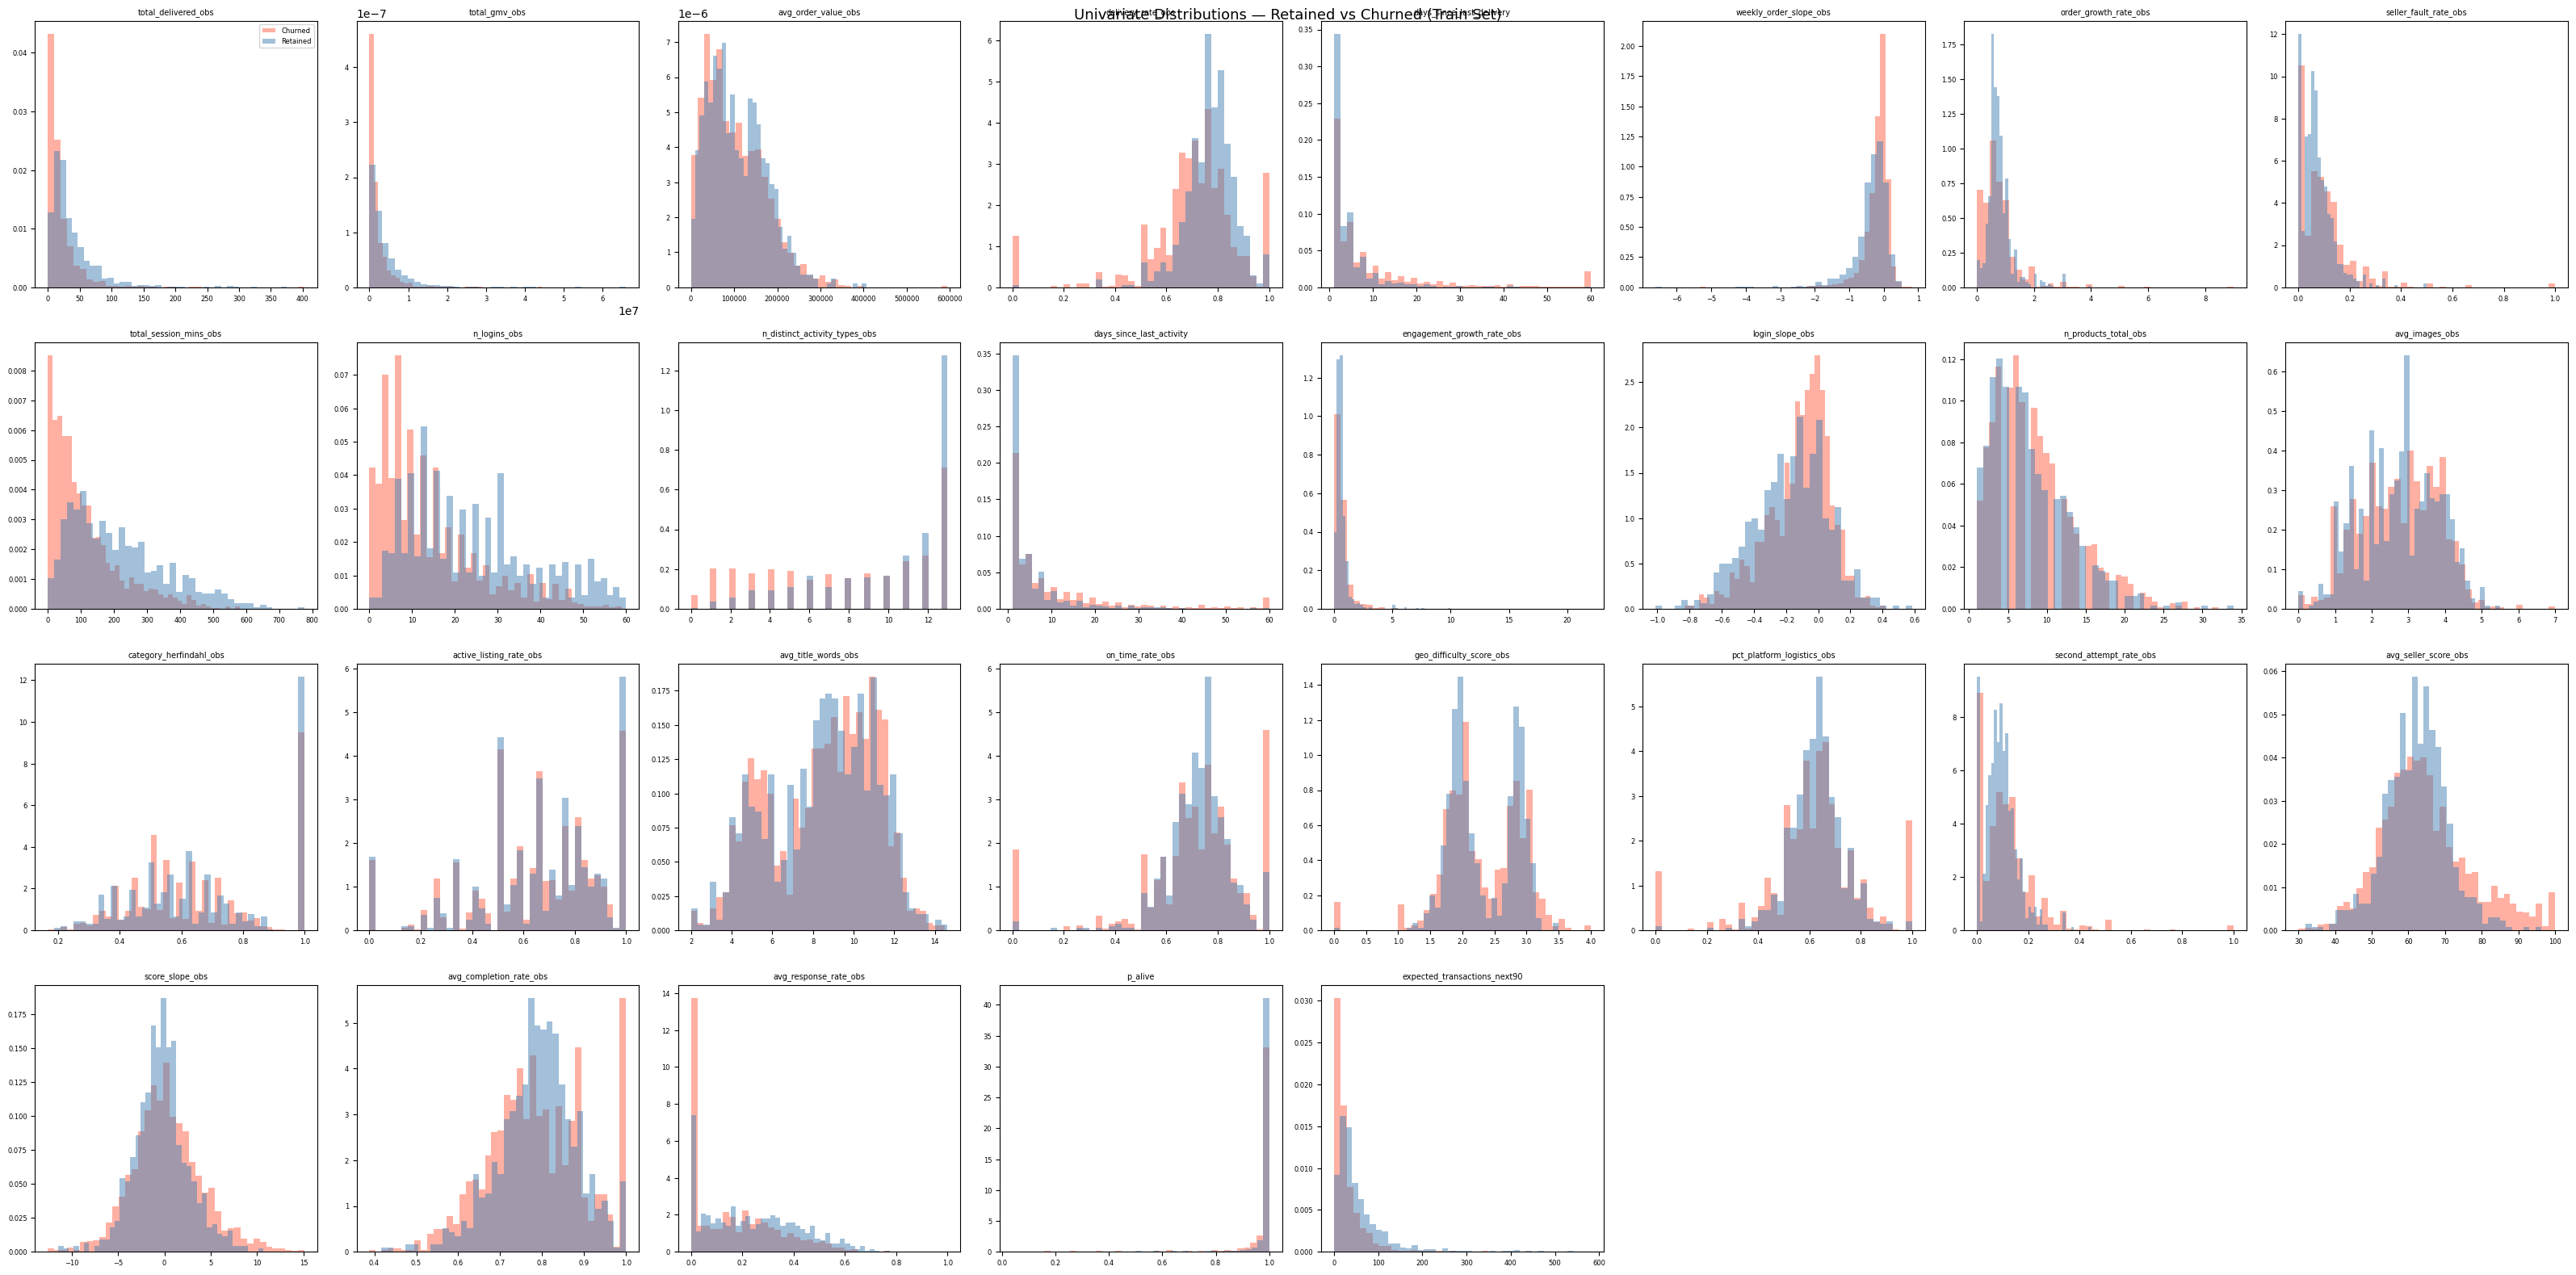


Mean by retention label - key features
retained_12m                             0            1
total_delivered_obs                 20.062       38.570
total_gmv_obs                  2103497.404  4164062.919
total_session_mins_obs             109.955      212.651
n_logins_obs                        13.799       23.768
avg_seller_score_obs                64.657       62.173
delivery_rate_obs                    0.702        0.767
on_time_rate_obs                     0.706        0.725
category_herfindahl_obs              0.649        0.670
p_alive                              0.959        0.982
expected_transactions_next90        28.578       55.622
n_distinct_activity_types_obs        7.986       10.262
days_since_last_delivery             9.805        4.348
days_since_last_activity            10.619        4.976


In [ ]:
print("PART 8 - UNIVARIATE ANALYSIS\n")
print("Training set only\n")

train = all_features[all_features['split'] == 'train'].copy()
retained = train[train['retained_12m'] == 1]
churned = train[train['retained_12m'] == 0]

print(f"Train: {len(train):,} | Retained: {len(retained):,} | Churned: {len(churned):,}")

# select continuous features for density plots
# group by domain for organised visualisation
domain_feature_map = {
    'Transactional': ['total_delivered_obs', 'total_gmv_obs', 'avg_order_value_obs',
                      'delivery_rate_obs', 'days_since_last_delivery', 'weekly_order_slope_obs',
                      'order_growth_rate_obs', 'seller_fault_rate_obs'],
    'Engagement': ['total_session_mins_obs', 'n_logins_obs', 'n_distinct_activity_types_obs',
                   'days_since_last_activity', 'engagement_growth_rate_obs', 'login_slope_obs'],
    'Listing': ['n_products_total_obs', 'avg_images_obs', 'category_herfindahl_obs',
                'active_listing_rate_obs', 'avg_title_words_obs'],
    'Logistics': ['on_time_rate_obs', 'geo_difficulty_score_obs', 'pct_platform_logistics_obs',
                  'second_attempt_rate_obs'],
    'Metrics': ['avg_seller_score_obs', 'score_slope_obs', 'avg_completion_rate_obs',
                'avg_response_rate_obs'],
    'BG/NBD': ['p_alive', 'expected_transactions_next90'],
}

fig, axes = plt.subplots(6, 8, figsize=(32, 24))
axes = axes.flatten()

plot_idx = 0
for domain, cols in domain_feature_map.items():
    for col in cols:
        ax = axes[plot_idx]
        ax.hist(churned[col], bins=40, alpha=0.5, color='tomato',
                density=True, label='Churned')
        ax.hist(retained[col], bins=40, alpha=0.5, color='steelblue',
                density=True, label='Retained')
        ax.set_title(col, fontsize=7)
        ax.set_xlabel('')
        ax.tick_params(labelsize=6)
        if plot_idx == 0:
            ax.legend(fontsize=6)
        plot_idx += 1

# hide unused axes
for i in range(plot_idx, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Univariate Distributions - Retained vs Churned (Train Set)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/figures/univariate_distributions.png', dpi=130, bbox_inches='tight')
plt.show()

# summary stats by label for key features
print("\nMean by retention label - key features")
key_features = ['total_delivered_obs', 'total_gmv_obs', 'total_session_mins_obs',
                'n_logins_obs', 'avg_seller_score_obs', 'delivery_rate_obs',
                'on_time_rate_obs', 'category_herfindahl_obs', 'p_alive',
                'expected_transactions_next90', 'n_distinct_activity_types_obs',
                'days_since_last_delivery', 'days_since_last_activity']
print(train.groupby('retained_12m')[key_features].mean().round(3).T)

## Part 8 - Univariate, Bivariate, and Multivariate Analysis

All analysis in this part runs on the training set of 2,635 sellers. The test set is not examined at any stage.

### Univariate Analysis

Distributions for key continuous features are examined separately for retained (n=805) and churned (n=1,830) sellers. The mean comparison table and overlapping histograms reveal where the two groups separate and where they do not.

**Engagement features show the strongest univariate separation.** Retained sellers accumulate nearly double the total session minutes within the observation window (212.7 vs 110.0) and almost twice the login count (23.8 vs 13.8). The number of distinct activity types engaged is also substantially higher for retained sellers (10.3 vs 8.0 out of 13 possible types). The engagement distributions overlap considerably in the lower range but retained sellers dominate the upper tail across all three measures. This is the most consistent domain-level separation in the univariate analysis and is coherent with the asset specificity logic - sellers who embed themselves deeply across platform workflows in the first 60 days are demonstrating the kind of operational commitment that theory predicts should be associated with lower exit risk.

**Recency features are sharply discriminating.** Retained sellers last received a delivered order 4.3 days before the observation window end on average, versus 9.8 days for churned sellers. The equivalent figures for last platform activity are 5.0 and 10.6 days. The gap in both measures is proportionally large relative to the 60-day window and confirms that sellers who remain commercially and behaviourally active through the end of the window are substantially more likely to persist into the outcome period. This is the BG/NBD latent state signal in its most direct observable form.

**Transactional volume separates the groups but with high overlap.** Retained sellers average 38.6 delivered orders within the window versus 20.1 for churned sellers - roughly double - and ₦4.16M GMV versus ₦2.10M. Both distributions are right-skewed with considerable overlap in the lower range, meaning volume alone is not sufficient to discriminate between the groups but contributes meaningful signal alongside recency and trajectory features.

**Two counterintuitive findings emerge.** Average seller score within the observation window is marginally higher for churned sellers (64.7 vs 62.2). This likely reflects the early-tenure dynamics of score accumulation - sellers who exit quickly have fewer weekly snapshots and the score has not had sufficient time to deteriorate in response to poor operational performance. The score trajectory features, which capture the direction of change rather than the level, are more theoretically appropriate for this prediction task. Category Herfindahl index is also slightly higher for retained sellers (0.670 vs 0.649), suggesting that more concentrated sellers retain marginally better than diversified ones. This runs counter to the diversification hypothesis from the literature and may reflect that sellers focused on high-demand categories - particularly in the Lagos market - outperform those spreading effort across categories without sufficient depth in any.

**BG/NBD features show directionally correct separation.** expected_transactions_next90 separates the groups most clearly (55.6 vs 28.6), reflecting the model's ability to translate within-window transaction patterns into a forward-looking forecast that raw counts cannot produce. p_alive separation is modest (0.982 vs 0.959), consistent with the structural limitation of applying BG/NBD to a 60-day window where most sellers are technically still alive by the end of the observation period.

PART 8 - BIVARIATE ANALYSIS

Top 30 features by absolute correlation with retained_12m
                                 corr abs_corr significant
total_session_mins_obs         0.3751   0.3751        True
n_logins_obs                   0.3405   0.3405        True
n_sections_visited_obs         0.2915   0.2915        True
completion_x_volume            0.2803   0.2803        True
price_changed_count_obs        0.2694   0.2694        True
total_events_obs               0.2674   0.2674        True
inventory_updated_count_obs    0.2659   0.2659        True
expected_transactions_next90   0.2646   0.2646        True
activity_h1                    0.2645   0.2645        True
total_delivered_obs             0.264    0.264        True
orders_h2                       0.262    0.262        True
activity_h2                    0.2616   0.2616        True
campaign_enrolled_count_obs    0.2614   0.2614        True
orders_h1                      0.2592   0.2592        True
analytics_viewed_count_obs  

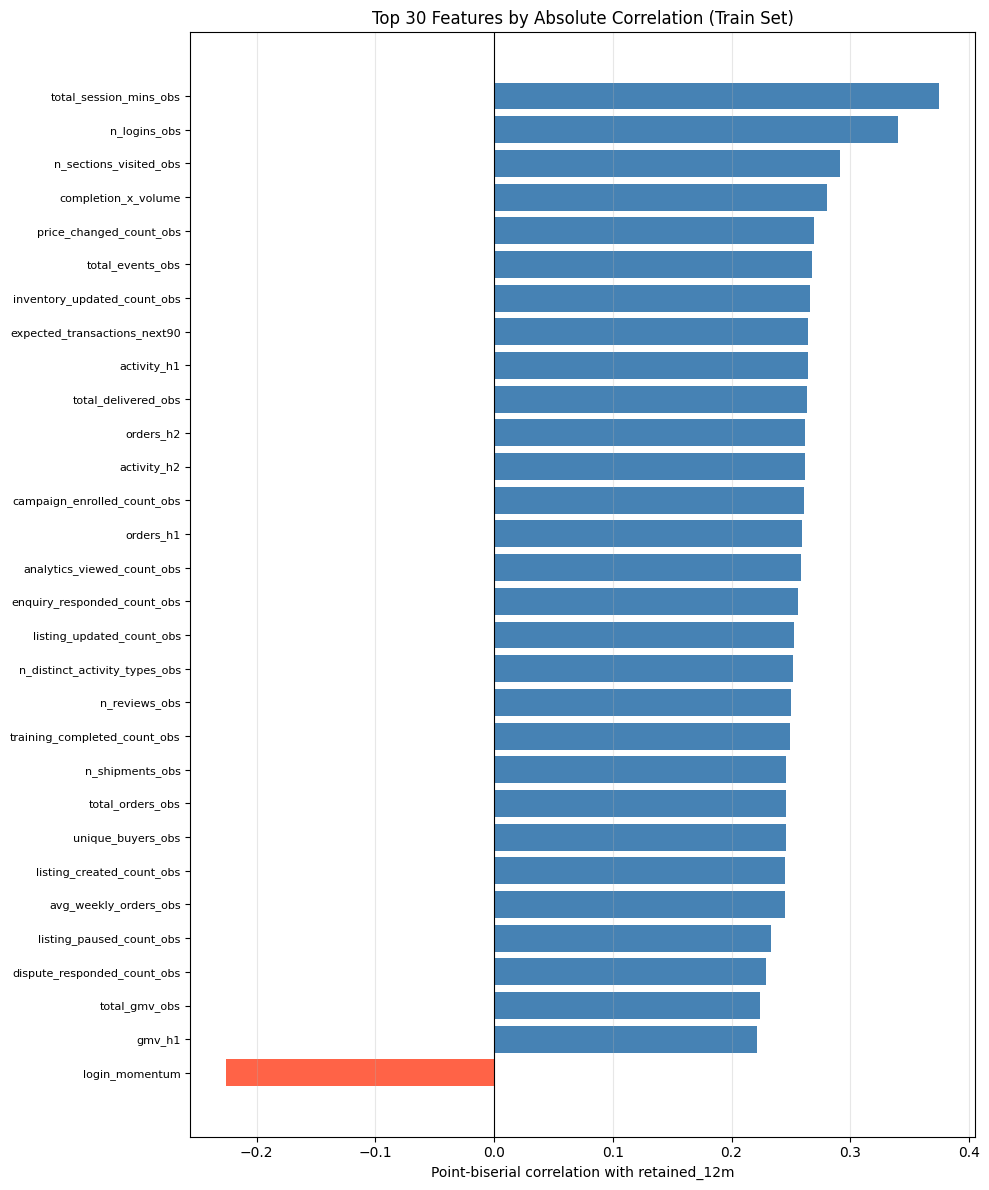


Mean absolute correlation by domain
  Transactional   0.1610  (24 features)
  Listing         0.0950  (16 features)
  Engagement      0.2284  (21 features)
  Logistics       0.0558  (14 features)
  Feedback        0.1234  (18 features)
  Metrics         0.0850  (15 features)
  Profile         0.0222  (16 features)
  Interactions    0.1421  (8 features)
  Inventory       0.0127  (5 features)
  BG/NBD          0.1808  (2 features)


In [ ]:
print("PART 8 - BIVARIATE ANALYSIS\n")

from scipy import stats

train = all_features[all_features['split'] == 'train'].copy()

# point-biserial correlation for all continuous features
correlations = {}
for col in feature_cols:
    corr, pval = stats.pointbiserialr(train[col], train['retained_12m'])
    correlations[col] = {
        'corr': round(corr, 4),
        'abs_corr': round(abs(corr), 4),
        'pval': round(pval, 4),
        'significant': pval < 0.05
    }

corr_df = pd.DataFrame(correlations).T.sort_values('abs_corr', ascending=False)

print(f"Top 30 features by absolute correlation with retained_12m")
print(corr_df.head(30)[['corr', 'abs_corr', 'significant']])

print(f"\nBottom 15 features by absolute correlation (weakest signal)")
print(corr_df.tail(15)[['corr', 'abs_corr', 'significant']])

print(f"\nFeatures with non-significant correlation (p >= 0.05)")
non_sig = corr_df[~corr_df['significant']]
print(non_sig[['corr', 'abs_corr', 'pval']] if len(non_sig) > 0 else "All features significant")

# visualise top 30
fig, ax = plt.subplots(figsize=(10, 12))
top30 = corr_df.head(30).sort_values('corr')
colors = ['steelblue' if c > 0 else 'tomato' for c in top30['corr']]
ax.barh(top30.index, top30['corr'], color=colors, edgecolor='none')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Point-biserial correlation with retained_12m')
ax.set_title('Top 30 Features by Absolute Correlation (Train Set)')
ax.tick_params(axis='y', labelsize=8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/figures/bivariate_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

# domain-level summary
print(f"\nMean absolute correlation by domain")
domain_feature_map_flat = {
    'Transactional': [c for c in feature_cols if c in txn_features.columns and c not in ['has_any_listing', 'has_any_metrics', 'has_seller_score', 'repeat_buyer_rate_obs']],
    'Listing': [c for c in feature_cols if c in listing_features.columns and c not in txn_features.columns],
    'Engagement': [c for c in feature_cols if c in engagement_features.columns and c not in txn_features.columns],
    'Logistics': [c for c in feature_cols if c in logistics_features.columns and c not in txn_features.columns],
    'Feedback': [c for c in feature_cols if c in feedback_features.columns and c not in txn_features.columns],
    'Metrics': [c for c in feature_cols if c in metrics_features.columns and c not in txn_features.columns],
    'Profile': [c for c in feature_cols if c in profile_features.columns and c not in txn_features.columns],
    'Interactions': [c for c in feature_cols if c in interaction_features.columns and c not in txn_features.columns],
    'Inventory': [c for c in feature_cols if c in inventory_features.columns and c not in txn_features.columns],
    'BG/NBD': [c for c in feature_cols if c in bgnbd_features.columns and c not in txn_features.columns],
}
for domain, cols in domain_feature_map_flat.items():
    valid_cols = [c for c in cols if c in corr_df.index]
    if valid_cols:
        mean_corr = corr_df.loc[valid_cols, 'abs_corr'].mean()
        print(f"  {domain:<15} {mean_corr:.4f}  ({len(valid_cols)} features)")

### Bivariate Analysis

Point-biserial correlations between every feature and the retention label are computed on the training set. All 139 features are evaluated and ranked by absolute correlation.

**Top signals**

The strongest individual predictor is total_session_mins_obs with a correlation of 0.375, followed by n_logins_obs at 0.341 and n_sections_visited_obs at 0.292. The top 30 features by absolute correlation are dominated by engagement and activity volume measures - login count, total events, activity by half-window, section diversity, and high-signal activity types including campaign enrollment, analytics views, enquiry responses, and training completions. completion_x_volume ranks fourth at 0.280, confirming that the interaction between completion rate and order volume carries substantially more signal than either component in isolation. expected_transactions_next90 from the BG/NBD model ranks eighth at 0.265, ahead of most raw transactional features.

login_momentum enters the top 30 with a correlation of -0.226. The negative sign is correctly interpreted - more negative momentum, meaning steeper engagement decline across the window, is associated with lower retention probability. This is directionally consistent with the expectation-disconfirmation mechanism and with the declining engagement trajectory documented in the univariate analysis.

**Domain-level summary**

Engagement features average the highest absolute correlation at 0.228 across 21 features, confirming that platform behavioural embeddedness is the strongest early-tenure retention signal available in this dataset. BG/NBD features achieve a mean of 0.181 across just two features - a notably efficient contribution that validates the decision to fit the full probabilistic model rather than rely on the simple recency proxy. Transactional features average 0.161, interaction features 0.142, and feedback features 0.123. Logistics, metrics, listing, inventory, and profile features all average below 0.10, with profile the weakest at 0.022.

**Non-significant features**

44 features do not achieve statistical significance at p<0.05. The most notable cluster is the macroeconomic and contextual domain - fx_rate_at_anchor, avg_fx_obs, food_cpi_at_anchor, electricity_hrs_at_anchor, activated_during_shock, post_shock, and fx_x_import all have correlations near zero and p-values above 0.70. The theoretical motivation from the concept drift literature is sound - the June 2023 FX devaluation created a genuine structural break - but the univariate signal does not support a meaningful individual feature contribution. These features may still contribute through combinations the tree-based model discovers implicitly, and they are retained in the feature matrix on theoretical grounds, but their empirical univariate performance is weak and this is reported honestly.

avg_completion_rate_obs is also non-significant at p=0.406 with a correlation of 0.016. Despite its theoretical grounding as an operational health signal, completion rate within the 60-day window carries almost no discriminative power on its own - likely because most sellers maintain high completion rates in the early-tenure period regardless of their eventual retention outcome. The completion_x_volume interaction, which adjusts for the unreliability of rates at low volume, substantially outperforms the raw rate at 0.280.

**Leakage confirmation**

No feature exceeds an absolute correlation of 0.40 with the label. The feature set passes the leakage audit at the bivariate level.

PART 8 - MULTIVARIATE ANALYSIS



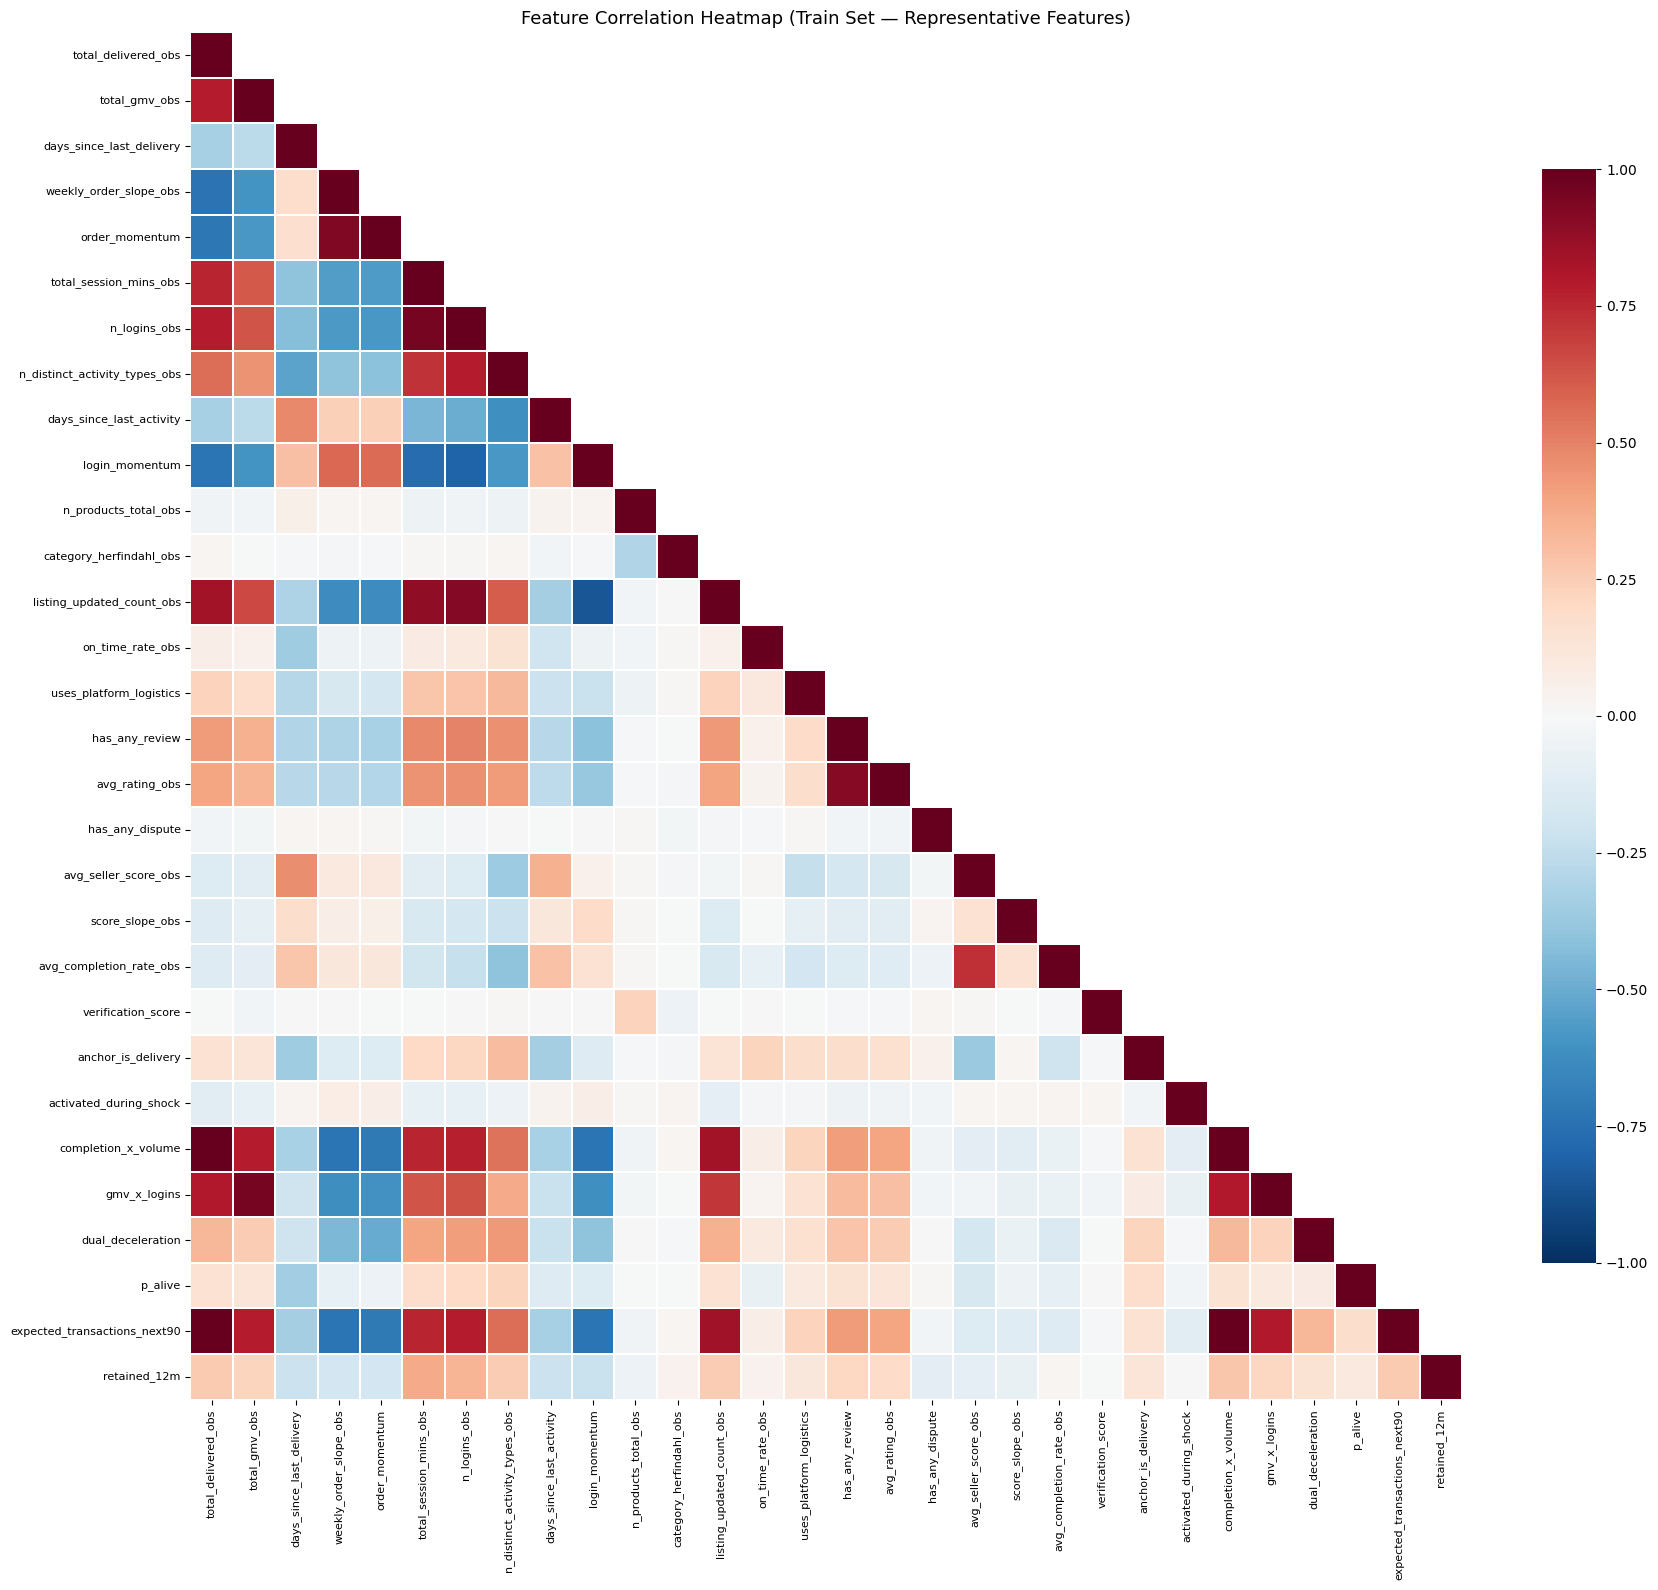

Highly correlated feature pairs (|r| > 0.7)
  total_delivered_obs x expected_transactions_next90: 0.999
  total_delivered_obs x completion_x_volume: 0.995
  completion_x_volume x expected_transactions_next90: 0.994
  total_session_mins_obs x n_logins_obs: 0.96
  total_gmv_obs x gmv_x_logins: 0.959
  weekly_order_slope_obs x order_momentum: 0.923
  n_logins_obs x listing_updated_count_obs: 0.919
  has_any_review x avg_rating_obs: 0.913
  total_session_mins_obs x listing_updated_count_obs: 0.884
  login_momentum x listing_updated_count_obs: -0.853
  total_delivered_obs x listing_updated_count_obs: 0.844
  listing_updated_count_obs x expected_transactions_next90: 0.844
  listing_updated_count_obs x completion_x_volume: 0.838
  n_logins_obs x login_momentum: -0.807
  completion_x_volume x gmv_x_logins: 0.801
  total_delivered_obs x gmv_x_logins: 0.799
  gmv_x_logins x expected_transactions_next90: 0.798
  total_delivered_obs x total_gmv_obs: 0.788
  total_delivered_obs x n_logins_obs: 0.78

In [ ]:
print("PART 8 - MULTIVARIATE ANALYSIS\n")

import seaborn as sns

train = all_features[all_features['split'] == 'train'].copy()

# select representative features for correlation heatmap
# using top features from each domain to keep it readable
heatmap_features = [
    # transactional
    'total_delivered_obs', 'total_gmv_obs', 'days_since_last_delivery',
    'weekly_order_slope_obs', 'order_momentum',
    # engagement
    'total_session_mins_obs', 'n_logins_obs', 'n_distinct_activity_types_obs',
    'days_since_last_activity', 'login_momentum',
    # listing
    'n_products_total_obs', 'category_herfindahl_obs', 'listing_updated_count_obs',
    # logistics
    'on_time_rate_obs', 'uses_platform_logistics',
    # feedback
    'has_any_review', 'avg_rating_obs', 'has_any_dispute',
    # metrics
    'avg_seller_score_obs', 'score_slope_obs', 'avg_completion_rate_obs',
    # profile
    'verification_score', 'anchor_is_delivery', 'activated_during_shock',
    # interactions
    'completion_x_volume', 'gmv_x_logins', 'dual_deceleration',
    # bgnbd
    'p_alive', 'expected_transactions_next90',
    # label
    'retained_12m'
]

corr_matrix = train[heatmap_features].corr()

fig, ax = plt.subplots(figsize=(18, 16))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    annot=False,
    linewidths=0.3,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Heatmap (Train Set - Representative Features)', fontsize=13)
ax.tick_params(axis='both', labelsize=8)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# identify highly correlated feature pairs (excluding label)
feature_only = [f for f in heatmap_features if f != 'retained_12m']
corr_pairs = []
for i, f1 in enumerate(feature_only):
    for j, f2 in enumerate(feature_only):
        if j <= i:
            continue
        c = abs(corr_matrix.loc[f1, f2])
        if c > 0.7:
            corr_pairs.append((f1, f2, round(corr_matrix.loc[f1, f2], 3)))

print(f"Highly correlated feature pairs (|r| > 0.7)")
if corr_pairs:
    for f1, f2, c in sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {f1} x {f2}: {c}")
else:
    print("  None")

# check full feature matrix for high correlations
print(f"\nChecking full 139-feature matrix for |r| > 0.8 pairs")
full_corr = train[feature_cols].corr()
high_pairs = []
cols = feature_cols
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        c = full_corr.iloc[i, j]
        if abs(c) > 0.8:
            high_pairs.append((cols[i], cols[j], round(c, 3)))

print(f"  Pairs found: {len(high_pairs)}")
for f1, f2, c in sorted(high_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {f1} x {f2}: {c}")

In [ ]:
print("DROPPING REDUNDANT FEATURES\n")

drop_redundant = [
    # perfect correlations
    'unique_buyers_obs',        # = total_orders_obs
    'n_shipments_obs',          # = total_orders_obs
    'order_trajectory_obs',     # = order_momentum
    'has_any_shipment',         # = has_any_order_obs
    'has_on_time_data',         # = has_any_delivery_obs
    # near-perfect with BG/NBD
    'avg_weekly_orders_obs',    # r=0.999 with total_orders
    # macro collinearity
    'avg_fx_obs',               # r=0.988 with fx_rate_at_anchor
    'food_cpi_at_anchor',       # r=0.904 with fx_rate_at_anchor
    # score redundancy
    'score_deterioration_obs',  # r=-0.874 with score_slope_obs
    # logistics/metrics overlap
    'avg_otd_rate_obs',         # r=0.85 with on_time_rate_obs
    # geography overlap
    'pct_local_lagos_obs',      # r=0.863 with is_lagos
    # trailing rating redundancy
    'avg_trailing_rating_obs',  # r=0.892 with has_trailing_rating
]

all_features = all_features.drop(columns=drop_redundant)

meta_cols = ['seller_id', 'retained_12m', 'registration_cohort_qtr',
             'anchor_date', 'anchor_type', 'split']
feature_cols = [c for c in all_features.columns if c not in meta_cols]

print(f"Dropped {len(drop_redundant)} redundant features")
print(f"Remaining features: {len(feature_cols)}")
print(f"Null check: {all_features[feature_cols].isnull().sum().sum()} nulls")

# verify no more r=1.0 pairs
train = all_features[all_features['split'] == 'train'].copy()
full_corr = train[feature_cols].corr()
perfect_pairs = []
cols = feature_cols
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        c = abs(full_corr.iloc[i, j])
        if c >= 0.99:
            perfect_pairs.append((cols[i], cols[j], round(full_corr.iloc[i, j], 4)))

print(f"\nRemaining pairs with |r| >= 0.99: {len(perfect_pairs)}")
for f1, f2, c in sorted(perfect_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {f1} x {f2}: {c}")

# resave
all_features.to_csv(f'{OUTPUT_PATH}/features/feature_matrix.csv', index=False)
train_df = all_features[all_features['split'] == 'train'].copy()
test_df = all_features[all_features['split'] == 'test'].copy()
train_df.to_csv(f'{OUTPUT_PATH}/features/train.csv', index=False)
test_df.to_csv(f'{OUTPUT_PATH}/features/test.csv', index=False)
print(f"\nResaved. Final matrix: {all_features.shape}")

DROPPING REDUNDANT FEATURES

Dropped 12 redundant features
Remaining features: 127
Null check: 0 nulls

Remaining pairs with |r| >= 0.99: 9
  total_delivered_obs x expected_transactions_next90: 0.9988
  total_orders_obs x total_delivered_obs: 0.9956
  total_delivered_obs x completion_x_volume: 0.9955
  listing_updated_count_obs x total_events_obs: 0.9946
  total_orders_obs x expected_transactions_next90: 0.9945
  completion_x_volume x expected_transactions_next90: 0.9943
  total_gmv_obs x avg_weekly_gmv_obs: 0.9925
  total_events_obs x activity_h1: 0.9915
  total_delivered_obs x orders_h1: 0.9901

Resaved. Final matrix: (3806, 133)


In [ ]:
print("SECOND ROUND REDUNDANCY DROPS\n")

drop_round2 = [
    'avg_weekly_gmv_obs',   # = total_gmv / 8
    'total_orders_obs',     # r=0.996 with total_delivered, less meaningful
    'activity_h1',          # r=0.992 with total_events_obs
]

all_features = all_features.drop(columns=drop_round2)

meta_cols = ['seller_id', 'retained_12m', 'registration_cohort_qtr',
             'anchor_date', 'anchor_type', 'split']
feature_cols = [c for c in all_features.columns if c not in meta_cols]

print(f"Dropped: {drop_round2}")
print(f"Remaining features: {len(feature_cols)}")
print(f"Null check: {all_features[feature_cols].isnull().sum().sum()} nulls")

# check remaining high pairs
train = all_features[all_features['split'] == 'train'].copy()
full_corr = train[feature_cols].corr()
high_pairs = []
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        c = abs(full_corr.iloc[i, j])
        if c >= 0.99:
            high_pairs.append((feature_cols[i], feature_cols[j], round(full_corr.iloc[i, j], 4)))

print(f"\nRemaining pairs with |r| >= 0.99: {len(high_pairs)}")
for f1, f2, c in sorted(high_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {f1} x {f2}: {c}")

# pairs between 0.85 and 0.99 that remain - document for logistic regression warning
pairs_085 = []
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        c = abs(full_corr.iloc[i, j])
        if 0.85 <= c < 0.99:
            pairs_085.append((feature_cols[i], feature_cols[j], round(full_corr.iloc[i, j], 4)))

print(f"\nPairs with 0.85 <= |r| < 0.99: {len(pairs_085)}")

# resave
all_features.to_csv(f'{OUTPUT_PATH}/features/feature_matrix.csv', index=False)
train_df = all_features[all_features['split'] == 'train'].copy()
test_df = all_features[all_features['split'] == 'test'].copy()
train_df.to_csv(f'{OUTPUT_PATH}/features/train.csv', index=False)
test_df.to_csv(f'{OUTPUT_PATH}/features/test.csv', index=False)
print(f"\nResaved. Final matrix: {all_features.shape}")

SECOND ROUND REDUNDANCY DROPS

Dropped: ['avg_weekly_gmv_obs', 'total_orders_obs', 'activity_h1']
Remaining features: 124
Null check: 0 nulls

Remaining pairs with |r| >= 0.99: 5
  total_delivered_obs x expected_transactions_next90: 0.9988
  total_delivered_obs x completion_x_volume: 0.9955
  listing_updated_count_obs x total_events_obs: 0.9946
  completion_x_volume x expected_transactions_next90: 0.9943
  total_delivered_obs x orders_h1: 0.9901

Pairs with 0.85 <= |r| < 0.99: 117

Resaved. Final matrix: (3806, 130)


In [ ]:
print("THIRD ROUND REDUNDANCY DROPS\n")

drop_round3 = [
    'completion_x_volume',       # r=0.996 with total_delivered, interaction loses meaning
    'listing_updated_count_obs', # r=0.995 with total_events_obs, dominant component
]

all_features = all_features.drop(columns=drop_round3)

meta_cols = ['seller_id', 'retained_12m', 'registration_cohort_qtr',
             'anchor_date', 'anchor_type', 'split']
feature_cols = [c for c in all_features.columns if c not in meta_cols]

print(f"Dropped: {drop_round3}")
print(f"Remaining features: {len(feature_cols)}")
print(f"Null check: {all_features[feature_cols].isnull().sum().sum()} nulls")

train = all_features[all_features['split'] == 'train'].copy()
full_corr = train[feature_cols].corr()

high_pairs = []
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        c = abs(full_corr.iloc[i, j])
        if c >= 0.99:
            high_pairs.append((feature_cols[i], feature_cols[j], round(full_corr.iloc[i, j], 4)))

print(f"\nRemaining pairs with |r| >= 0.99: {len(high_pairs)}")
for f1, f2, c in sorted(high_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {f1} x {f2}: {c}")

# final domain breakdown
domain_feature_map_final = {
    'Transactional': [c for c in feature_cols if c in txn_features.columns],
    'Listing': [c for c in feature_cols if c in listing_features.columns and c not in txn_features.columns],
    'Engagement': [c for c in feature_cols if c in engagement_features.columns and c not in txn_features.columns],
    'Logistics': [c for c in feature_cols if c in logistics_features.columns and c not in txn_features.columns],
    'Feedback': [c for c in feature_cols if c in feedback_features.columns and c not in txn_features.columns],
    'Metrics': [c for c in feature_cols if c in metrics_features.columns and c not in txn_features.columns],
    'Profile': [c for c in feature_cols if c in profile_features.columns and c not in txn_features.columns],
    'Interactions': [c for c in feature_cols if c in interaction_features.columns and c not in txn_features.columns],
    'Inventory': [c for c in feature_cols if c in inventory_features.columns and c not in txn_features.columns],
    'BG/NBD': [c for c in feature_cols if c in bgnbd_features.columns and c not in txn_features.columns],
}
print(f"\nFinal feature count by domain")
total = 0
for domain, cols in domain_feature_map_final.items():
    valid = [c for c in cols if c in feature_cols]
    total += len(valid)
    print(f"  {domain:<15} {len(valid)} features")
print(f"  {'TOTAL':<15} {total}")

# resave
all_features.to_csv(f'{OUTPUT_PATH}/features/feature_matrix.csv', index=False)
train_df = all_features[all_features['split'] == 'train'].copy()
test_df = all_features[all_features['split'] == 'test'].copy()
train_df.to_csv(f'{OUTPUT_PATH}/features/train.csv', index=False)
test_df.to_csv(f'{OUTPUT_PATH}/features/test.csv', index=False)
print(f"\nResaved. Final matrix: {all_features.shape}")
print(f"Train: {train_df.shape} | Test: {test_df.shape}")

THIRD ROUND REDUNDANCY DROPS

Dropped: ['completion_x_volume', 'listing_updated_count_obs']
Remaining features: 122
Null check: 0 nulls

Remaining pairs with |r| >= 0.99: 2
  total_delivered_obs x expected_transactions_next90: 0.9988
  total_delivered_obs x orders_h1: 0.9901

Final feature count by domain
  Transactional   21 features
  Listing         15 features
  Engagement      20 features
  Logistics       10 features
  Feedback        18 features
  Metrics         10 features
  Profile         14 features
  Interactions    7 features
  Inventory       5 features
  BG/NBD          2 features
  TOTAL           122

Resaved. Final matrix: (3806, 128)
Train: (2635, 128) | Test: (1171, 128)


In [ ]:
print("FINAL REDUNDANCY DROP\n")

all_features = all_features.drop(columns=['orders_h1'])

meta_cols = ['seller_id', 'retained_12m', 'registration_cohort_qtr',
             'anchor_date', 'anchor_type', 'split']
feature_cols = [c for c in all_features.columns if c not in meta_cols]

train = all_features[all_features['split'] == 'train'].copy()
full_corr = train[feature_cols].corr()

high_pairs = []
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        c = abs(full_corr.iloc[i, j])
        if c >= 0.99:
            high_pairs.append((feature_cols[i], feature_cols[j], round(full_corr.iloc[i, j], 4)))

print(f"Remaining features: {len(feature_cols)}")
print(f"Null check: {all_features[feature_cols].isnull().sum().sum()} nulls")
print(f"\nRemaining pairs |r| >= 0.99: {len(high_pairs)}")
for f1, f2, c in sorted(high_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {f1} x {f2}: {c}")

all_features.to_csv(f'{OUTPUT_PATH}/features/feature_matrix.csv', index=False)
train_df = all_features[all_features['split'] == 'train'].copy()
test_df = all_features[all_features['split'] == 'test'].copy()
train_df.to_csv(f'{OUTPUT_PATH}/features/train.csv', index=False)
test_df.to_csv(f'{OUTPUT_PATH}/features/test.csv', index=False)
print(f"\nFinal matrix: {all_features.shape}")
print(f"Train: {train_df.shape} | Test: {test_df.shape}")

FINAL REDUNDANCY DROP

Remaining features: 121
Null check: 0 nulls

Remaining pairs |r| >= 0.99: 1
  total_delivered_obs x expected_transactions_next90: 0.9988

Final matrix: (3806, 127)
Train: (2635, 127) | Test: (1171, 127)


### Multivariate Analysis

A correlation heatmap is constructed from 30 representative features spanning all ten domains to examine the inter-feature correlation structure. The full 121-feature matrix is then checked systematically for pairs exceeding |r| = 0.80.

**Perfect and near-perfect duplicates**

The initial full-matrix check identifies 312 pairs above |r| = 0.80, including several at r = 1.0. Four groups of perfect correlates are resolved immediately. unique_buyers_obs and n_shipments_obs are both perfectly correlated with total_orders_obs - in this dataset every order has exactly one buyer and generates exactly one shipment record, making all three algebraically identical. order_trajectory_obs is algebraically identical to order_momentum, both computing orders_h2 minus orders_h1. has_any_shipment duplicates has_any_order_obs and has_on_time_data duplicates has_any_delivery_obs. All redundant members of these pairs are dropped.

**Engagement activity cluster**

All individual activity count features - listing_created, listing_paused, listing_delisted, price_changed, analytics_viewed, enquiry_responded, dispute_responded, inventory_updated, training_completed, campaign_enrolled - are correlated above r = 0.85 with each other and with total_events_obs. This is structurally expected: they are components of the same aggregate, and sellers who are active on the platform engage across all activity types simultaneously. listing_updated_count_obs achieves r = 0.995 with total_events_obs and is dropped as the dominant component. activity_h1 achieves r = 0.992 with total_events_obs and is dropped, with activity_h2 retained to preserve the recency half of the within-window trajectory signal.

**Volume and derived feature overlap**

avg_weekly_gmv_obs is total_gmv divided by 8 weeks - r = 0.993 with total_gmv_obs and dropped. avg_weekly_orders_obs is the same operation on order count - r = 0.999 with total_delivered_obs and dropped. completion_x_volume achieves r = 0.996 with total_delivered_obs because the completion rate has near-constant variance relative to delivery volume in this population, making the interaction collapse to a scaled version of the count. It is dropped on this basis. orders_h1 achieves r = 0.990 with total_delivered_obs and is dropped, with the trajectory information retained through orders_h2, weekly_order_slope_obs, and order_momentum.

**Macroeconomic collinearity**

fx_rate_at_anchor, avg_fx_obs, and food_cpi_at_anchor are correlated above r = 0.90 with each other because all three track the same underlying structural event - the June 2023 naira devaluation - through different measurement lenses. avg_fx_obs and food_cpi_at_anchor are dropped, with fx_rate_at_anchor retained as the most direct and interpretable macro signal.

**Other resolved pairs**

score_deterioration_obs is dropped in favour of score_slope_obs (r = -0.874). avg_otd_rate_obs is dropped in favour of on_time_rate_obs from the logistics table (r = 0.85). pct_local_lagos_obs is dropped in favour of is_lagos (r = 0.863). avg_trailing_rating_obs is dropped because the has_trailing_rating flag and avg_rating_obs together capture its information while the trailing metric itself adds no independent signal (r = 0.892 with has_trailing_rating).

**Remaining high-correlation pair**

One pair above r = 0.99 remains after all drops: total_delivered_obs and expected_transactions_next90 at r = 0.999. Both are retained on theoretical grounds despite their near-identical empirical values. total_delivered_obs is the raw count of commercial transactions within the window. expected_transactions_next90 is the BG/NBD model's forward-looking forecast, conditioned on the temporal pattern of those transactions rather than their volume alone. In a longer observation window the two features would diverge substantially - two sellers with identical total_delivered counts but different recency patterns would receive different expected_transactions scores. At 60 days this divergence is limited, but the feature serves a narrative purpose in the dissertation by bridging the probabilistic CLV literature and the supervised ML framework, and its methodological contribution is independent of its marginal predictive contribution. For the logistic regression baseline, ridge regularisation is applied to manage the residual collinearity across the engagement activity cluster and this pair.

**Final feature matrix**

After all redundancy resolution, the feature matrix contains 121 features across 3,806 sellers with zero nulls. The final domain breakdown is: Transactional (21), Listing (15), Engagement (20), Logistics (10), Feedback (18), Metrics (10), Profile (14), Interactions (7), Inventory (5), BG/NBD (2).

In [ ]:
print("PART 9 - FINAL DATASET SUMMARY\n")

meta_cols = ['seller_id', 'retained_12m', 'registration_cohort_qtr',
             'anchor_date', 'anchor_type', 'split']
feature_cols = [c for c in all_features.columns if c not in meta_cols]

train = all_features[all_features['split'] == 'train'].copy()
test = all_features[all_features['split'] == 'test'].copy()

print(f"Final feature matrix: {all_features.shape}")
print(f"Feature columns: {len(feature_cols)}")
print(f"Metadata columns: {len(meta_cols)}")
print(f"\nTrain: {train.shape}")
print(f"  Retained: {train['retained_12m'].sum():,} ({train['retained_12m'].mean()*100:.1f}%)")
print(f"  Churned:  {(train['retained_12m']==0).sum():,} ({(1-train['retained_12m'].mean())*100:.1f}%)")
print(f"  Imbalance ratio: {(train['retained_12m']==0).sum() / train['retained_12m'].sum():.2f}")
print(f"\nTest: {test.shape}")
print(f"  Retained: {test['retained_12m'].sum():,} ({test['retained_12m'].mean()*100:.1f}%)")
print(f"  Churned:  {(test['retained_12m']==0).sum():,} ({(1-test['retained_12m'].mean())*100:.1f}%)")
print(f"  Imbalance ratio: {(test['retained_12m']==0).sum() / test['retained_12m'].sum():.2f}")

print(f"\nNull counts in feature columns: {all_features[feature_cols].isnull().sum().sum()}")
print(f"Duplicate seller_ids: {all_features['seller_id'].duplicated().sum()}")

print(f"\nAnchor date range")
print(f"  Train: {train['anchor_date'].min().date()} to {train['anchor_date'].max().date()}")
print(f"  Test:  {test['anchor_date'].min().date()} to {test['anchor_date'].max().date()}")

print(f"\nCohort distribution")
print(all_features.groupby(['registration_cohort_qtr', 'split'])['seller_id'].count().unstack())

domain_feature_map_final = {
    'Transactional': [c for c in feature_cols if c in txn_features.columns],
    'Listing': [c for c in feature_cols if c in listing_features.columns and c not in txn_features.columns],
    'Engagement': [c for c in feature_cols if c in engagement_features.columns and c not in txn_features.columns],
    'Logistics': [c for c in feature_cols if c in logistics_features.columns and c not in txn_features.columns],
    'Feedback': [c for c in feature_cols if c in feedback_features.columns and c not in txn_features.columns],
    'Metrics': [c for c in feature_cols if c in metrics_features.columns and c not in txn_features.columns],
    'Profile': [c for c in feature_cols if c in profile_features.columns and c not in txn_features.columns],
    'Interactions': [c for c in feature_cols if c in interaction_features.columns and c not in txn_features.columns],
    'Inventory': [c for c in feature_cols if c in inventory_features.columns and c not in txn_features.columns],
    'BG/NBD': [c for c in feature_cols if c in bgnbd_features.columns and c not in txn_features.columns],
}

print(f"\nFeature count by domain")
for domain, cols in domain_feature_map_final.items():
    valid = [c for c in cols if c in feature_cols]
    print(f"  {domain:<15} {len(valid)}")

print(f"\nFull feature list")
for i, c in enumerate(feature_cols):
    print(f"  {i+1:3d}. {c}")

PART 9 - FINAL DATASET SUMMARY

Final feature matrix: (3806, 127)
Feature columns: 121
Metadata columns: 6

Train: (2635, 127)
  Retained: 805 (30.6%)
  Churned:  1,830 (69.4%)
  Imbalance ratio: 2.27

Test: (1171, 127)
  Retained: 357 (30.5%)
  Churned:  814 (69.5%)
  Imbalance ratio: 2.28

Null counts in feature columns: 0
Duplicate seller_ids: 0

Anchor date range
  Train: 2022-01-06 to 2024-02-16
  Test:  2024-01-06 to 2024-10-01

Cohort distribution
split                     test  train
registration_cohort_qtr              
2022-Q1                    NaN  264.0
2022-Q2                    NaN  262.0
2022-Q3                    NaN  314.0
2022-Q4                    NaN  340.0
2023-Q1                    NaN  344.0
2023-Q2                    NaN  343.0
2023-Q3                    NaN  374.0
2023-Q4                    NaN  394.0
2024-Q1                  421.0    NaN
2024-Q2                  428.0    NaN
2024-Q3                  322.0    NaN

Feature count by domain
  Transactional   20
 

## Part 9 - Final Dataset Summary

The modelling dataset is saved in three files: the full feature_matrix.csv containing all 3,806 eligible sellers, and separate train.csv and test.csv files for use in Phase 4 modelling and Phase 5 evaluation respectively.

**Dimensions**

The final feature matrix contains 3,806 rows and 121 feature columns, with 6 additional metadata columns - seller_id, retained_12m, registration_cohort_qtr, anchor_date, anchor_type, and split. The feature count reflects the original 143 engineered features reduced by 4 constant or near-zero variance columns, 15 redundant columns identified through multivariate correlation analysis, and 3 columns removed in subsequent cleaning passes. The reductions are documented in Parts 7 and 8 with explicit rationale for each decision.

**Class balance**

The training set contains 2,635 sellers with a retention rate of 30.6% (805 retained, 1,830 churned) and an imbalance ratio of 2.27. The test set contains 1,171 sellers with a retention rate of 30.5% (357 retained, 814 churned) and an imbalance ratio of 2.28. The near-identical imbalance ratios across the temporal split confirm no distributional shift in the target variable. The class imbalance reflects the empirical reality of the Nigerian marketplace - 69.4% of sellers who activate do not sustain commercial activity through 12 months - and is not corrected through oversampling or artificial rebalancing. Phase 4 model training will address the imbalance through class weighting.

**Temporal integrity**

Training sellers have anchor dates from January 2022 through February 2024. Test sellers have anchor dates from January 2024 through October 2024. The eight training cohorts span 2022-Q1 through 2023-Q4 and the three test cohorts span 2024-Q1 through 2024-Q3, with no cohort appearing in both sets. No feature statistics from the test set have been used at any point during feature engineering, quality checking, or redundancy resolution.

**Feature breakdown by domain**

| Domain | Features |
|---|---|
| Transactional | 20 |
| Listing and Catalogue | 15 |
| Platform Engagement | 20 |
| Logistics | 10 |
| Customer Feedback | 18 |
| Performance Metrics | 10 |
| Seller Profile and Context | 14 |
| Interaction Features | 7 |
| Inventory | 5 |
| BG/NBD Derived | 2 |
| **Total** | **121** |

**Outstanding data quality notes**

One correlated pair is retained with explicit documentation: total_delivered_obs and expected_transactions_next90 at r = 0.999. Both are kept on theoretical grounds - the BG/NBD feature serves a methodological narrative purpose in the dissertation even where its marginal empirical contribution over raw delivery count is limited by the 60-day observation window. The engagement activity cluster - all individual activity count features and their relationship with total_events_obs - remains internally correlated above r = 0.85. This is flagged for the logistic regression baseline in Phase 4, where ridge regularisation will be applied to manage the residual multicollinearity. Tree-based models are not affected by this structure.

Phase 3 is complete. The dataset is ready for Phase 4 modelling.

# Phase 4 - Modelling and Evaluation

This phase trains and evaluates predictive models for 12-month seller retention using the 121-feature matrix constructed in Phase 3. All training, cross-validation, hyperparameter tuning, and interpretation work runs on the training set of 2,635 sellers. The test set is held out entirely until Phase 5.

## Structure

The phase is organised in six parts following a strict sequence - preprocessing before training, training before tuning, tuning before interpretation, interpretation before segmentation.

## Part 1 - Preprocessing and Feature Set Definition

Two preprocessing decisions are made before any model sees data.

**Scaling.** A StandardScaler is fitted exclusively on the training set and applied to both train and test sets. Scaling is required for logistic regression, where features on different scales distort the ridge penalty. Tree-based models receive unscaled features - they are invariant to monotonic transformations and scaling adds no benefit.

**Feature sets.** Two feature sets are defined and applied to every model. Model A contains all 121 features. Model B excludes revenue-generating signals - total_gmv_obs, avg_order_value_obs, gmv_trajectory_obs, gmv_growth_rate_obs, gmv_h1, gmv_h2, total_delivered_obs, delivery_rate_obs, and gmv_x_logins - simulating the cold-start scenario where the marketplace must assess a seller before any transaction history is available. The comparison between Model A and Model B directly addresses RQ2: whether non-revenue behavioural features add meaningful predictive signal beyond what delivery volume and GMV alone would provide, and whether a viable early-warning system can operate without waiting for commercial activity.

**Population Stability Index.** Before modelling begins, PSI is computed for a representative set of key features comparing pre-shock cohorts (anchor before June 2023) against post-shock cohorts (anchor from June 2023 onward). Features with PSI > 0.25 are flagged as significantly shifted. This contextualises the concept drift risk identified in the literature - the June 2023 naira devaluation created a structural break in the commercial environment - and informs the interpretation of any performance gap between temporal and random cross-validation.

## Part 2 - Model Training and Cross-Validation

Three model families are trained on each feature set, producing six models in total.

**Logistic Regression** with L2 (ridge) regularisation serves as the interpretable baseline. Ridge regularisation is particularly appropriate given the residual multicollinearity in the engagement activity feature cluster documented in Part 8. The regularisation strength C is determined in Part 3.

**Random Forest** is the first ensemble method. It handles mixed feature types, non-linear relationships, and the high-dimensional feature space without requiring scaling, and produces natively well-calibrated probability estimates.

**XGBoost** is the primary complex model. Gradient boosting on tabular data consistently outperforms alternative approaches in the churn prediction literature, and its hierarchical splitting structure naturally captures structural-behavioural feature interactions. XGBoost requires post-hoc probability calibration, addressed in Part 3.

**Class imbalance** is handled through class_weight='balanced' for scikit-learn estimators and scale_pos_weight set to the churned-to-retained ratio of 2.27 for XGBoost. Resampling methods are not used - the empirical 69.5/30.5 class split reflects the actual Nigerian marketplace retention distribution and is preserved rather than corrected.

**Cross-validation design.** Each model is evaluated using two CV strategies to quantify the inflation risk of standard CV on temporally structured data.

Stratified 5-fold CV assigns sellers randomly to folds while preserving the 30.6% retention rate in each fold. This is the standard approach and produces the optimistic upper-bound performance estimate. Temporal CV trains on earlier registration cohorts and evaluates on successively later ones, respecting the chronological ordering of the data. Concretely, four temporal folds are constructed by advancing the training cohort boundary one quarter at a time - training on 2022-Q1 through 2022-Q4 and evaluating on 2023-Q1, then extending training through 2023-Q1 and evaluating on 2023-Q2, and so on. The gap between stratified and temporal CV AUC estimates is reported explicitly. A large gap indicates the model is exploiting temporal leakage under standard CV and that temporal CV provides the more honest estimate of real-world performance.

## Part 3 - Hyperparameter Tuning and Calibration

Hyperparameter tuning follows a pragmatic two-stage approach that balances computational feasibility with methodological rigour.

**Stage one - coarse search.** A randomised search over a broad hyperparameter grid is run using 3-fold CV on the full training set. The purpose of stage one is navigation - identifying the promising regions of the hyperparameter space efficiently - rather than final model selection. The reported scores from this stage are not used for evaluation or comparison. Key hyperparameters searched by model family: C and max_iter for logistic regression; n_estimators, max_depth, min_samples_leaf, and max_features for Random Forest; n_estimators, max_depth, learning_rate, subsample, colsample_bytree, and min_child_weight for XGBoost. AUC-ROC is the optimisation objective throughout.

**Stage two - final evaluation.** The best hyperparameter configuration from stage one is fixed and the final model is trained and evaluated using proper stratified 5-fold CV on the full training set. The CV scores reported in Part 4 come exclusively from this stage. This two-stage design produces mildly optimistic performance estimates relative to nested cross-validation - the theoretically correct but computationally expensive alternative - and this limitation is acknowledged explicitly. The optimism is modest because stage one uses 3-fold CV on a coarse grid and the final evaluation uses a separate 5-fold CV pass rather than re-reporting the tuning scores directly.

**Probability calibration.** XGBoost produces sigmoid-distorted probability estimates - boosted tree models push predictions away from 0 and 1 in a pattern established by Niculescu-Mizil and Caruana (2005). Post-hoc calibration is applied using isotonic regression, which is preferred over Platt scaling for tree-based ensembles because the miscalibration pattern is complex and non-sigmoidal. Reliability diagrams plotting observed retention rate against mean predicted probability across bins are generated before and after calibration. Calibrated and uncalibrated AUC-ROC scores are compared to confirm calibration does not distort the discrimination ranking.

## Part 4 - Evaluation Framework

All six models are evaluated on the following metric suite. Each metric serves a distinct evaluative function and the full suite ensures model comparison claims rest on multiple independently justified forms of evidence.

**AUC-ROC** is the primary discrimination metric and threshold-free model comparison standard. It is robust to the study's 2.3:1 class imbalance and the most widely validated primary metric in the churn prediction literature.

**PR-AUC** is the minority-class-focused complement. At 30.5% positive prevalence the random PR-AUC baseline is 0.305 rather than 0.5, making it a more demanding evaluation standard for model behaviour among retained sellers specifically.

**F2 score** weights recall twice as heavily as precision at the 0.5 classification threshold, reflecting the cost asymmetry in the retention prediction task - a missed churner represents a costlier error than an unnecessary intervention.

**Lift@20%** reports the retention rate among sellers in the top 20% of predicted retention probabilities as a multiple of the overall population retention rate of 30.5%. A lift of 2.0 means the model-selected group retains at twice the background rate. This directly answers the business question of whether model-driven selection outperforms random selection at the resource allocation threshold the dissertation is designed for.

**Top-decile lift** applies the same logic at the top 10% threshold, measuring the concentration of retained sellers in the highest-confidence predictions and providing the most demanding targeting efficiency measure.

**Brier score** quantifies mean squared error between predicted probabilities and binary outcomes, capturing both discrimination and calibration simultaneously. The naive baseline - predicting the base rate for every seller - yields a Brier score of 0.212 at 30.5% retention prevalence.

**Statistical comparison.** Pairwise AUC comparisons between model families are evaluated using DeLong's test, which compares ROC curves nonparametrically while accounting for the correlation between estimates derived from the same dataset. The parsimony principle is applied throughout: where DeLong's test finds no statistically significant AUC difference between model families, the simpler model is preferred. A logistic regression achieving equivalent discrimination to XGBoost is the recommended choice on grounds of interpretability, deployment simplicity, and the absence of calibration requirements.

## Part 5 - SHAP Analysis

SHAP values are computed for the best-performing Model A and Model B configurations on the training set.

**Global importance** ranks features by mean absolute SHAP value, providing the primary empirical answer to RQ1 - what predicts seller retention in the first 60 days of platform activity.

**Beeswarm plots** show the direction and magnitude of each feature's effect across individual sellers, revealing whether high feature values consistently increase or decrease retention probability or whether the relationship is non-monotonic.

**Dependence plots** for the highest-ranked features reveal non-linear relationships and interaction effects. These provide the mechanism-level evidence connecting feature patterns to the theoretical frameworks in the literature review.

**Model A versus Model B comparison** directly addresses RQ2. The shift in global feature importance rankings when revenue signals are excluded shows which non-revenue features carry the most weight in the cold-start scenario and whether the cold-start model draws on qualitatively different behavioural signals or relies on proxies for the revenue features it cannot access.

## Part 6 - Seller Segmentation (RQ4)

K-means clustering is applied to SHAP value vectors from the best-performing model to identify whether distinct seller archetypes exist in the data. Clustering on SHAP values rather than raw features ensures segments are defined by what drives model predictions rather than by arbitrary feature space geometry. The optimal number of clusters is selected using the elbow method and silhouette scores. Cluster profiles are interpreted against the four seller archetypes hypothesised in Part 3 - fast-fail, intermittent, slow-fail, and survivor - to assess whether the model is implicitly learning segment structure consistent with the two-wave hazard pattern documented empirically.

In [ ]:
print("PHASE 4 - PART 1: PREPROCESSING AND FEATURE SET DEFINITION\n")

from sklearn.preprocessing import StandardScaler
import numpy as np

train_df = pd.read_csv(f'{OUTPUT_PATH}/features/train.csv')
test_df = pd.read_csv(f'{OUTPUT_PATH}/features/test.csv')

meta_cols = ['seller_id', 'retained_12m', 'registration_cohort_qtr',
             'anchor_date', 'anchor_type', 'split']
feature_cols = [c for c in train_df.columns if c not in meta_cols]

print(f"Train: {train_df.shape} | Test: {test_df.shape}")
print(f"Features: {len(feature_cols)}")

# model b exclusions
model_b_exclude = [
    'total_gmv_obs', 'avg_order_value_obs', 'gmv_trajectory_obs',
    'gmv_growth_rate_obs', 'gmv_h1', 'gmv_h2', 'total_delivered_obs',
    'delivery_rate_obs', 'gmv_x_logins'
]

missing = [c for c in model_b_exclude if c not in feature_cols]
print(f"\nModel B exclusions missing from feature matrix: {missing if missing else 'None'}")

feature_cols_a = feature_cols
feature_cols_b = [c for c in feature_cols if c not in model_b_exclude]

print(f"\nModel A features: {len(feature_cols_a)}")
print(f"Model B features: {len(feature_cols_b)}")
print(f"Excluded from Model B: {len(model_b_exclude)}")

# labels
y_train = train_df['retained_12m'].values
y_test = test_df['retained_12m'].values

# raw feature matrices - tree models use these
X_train_a = train_df[feature_cols_a].values
X_test_a = test_df[feature_cols_a].values
X_train_b = train_df[feature_cols_b].values
X_test_b = test_df[feature_cols_b].values

# scaled feature matrices - logistic regression only
# scaler fitted on train, applied to both
scaler_a = StandardScaler()
X_train_a_scaled = scaler_a.fit_transform(X_train_a)
X_test_a_scaled = scaler_a.transform(X_test_a)

scaler_b = StandardScaler()
X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_test_b_scaled = scaler_b.transform(X_test_b)

print(f"\nScaling complete")
print(f"  X_train_a_scaled: {X_train_a_scaled.shape}")
print(f"  X_train_b_scaled: {X_train_b_scaled.shape}")

# class imbalance ratio for XGBoost
n_churned = (y_train == 0).sum()
n_retained = (y_train == 1).sum()
scale_pos_weight = n_churned / n_retained

print(f"\nClass balance (train)")
print(f"  Churned: {n_churned:,} | Retained: {n_retained:,}")
print(f"  scale_pos_weight for XGBoost: {scale_pos_weight:.4f}")

# PSI
print(f"\nPopulation Stability Index - pre vs post FX shock\n")

train_df['anchor_date'] = pd.to_datetime(train_df['anchor_date'])
shock_date = pd.Timestamp('2023-06-01')
pre_shock = train_df[train_df['anchor_date'] < shock_date]
post_shock = train_df[train_df['anchor_date'] >= shock_date]

print(f"Pre-shock sellers: {len(pre_shock):,}")
print(f"Post-shock sellers: {len(post_shock):,}")

def compute_psi(expected, actual, bins=10):
    breakpoints = np.percentile(expected, np.linspace(0, 100, bins + 1))
    breakpoints = np.unique(breakpoints)
    if len(breakpoints) < 3:
        return 0.0
    exp_counts = np.histogram(expected, bins=breakpoints)[0]
    act_counts = np.histogram(actual, bins=breakpoints)[0]
    exp_perc = exp_counts / len(expected)
    act_perc = act_counts / len(actual)
    exp_perc = np.where(exp_perc == 0, 0.0001, exp_perc)
    act_perc = np.where(act_perc == 0, 0.0001, act_perc)
    psi = np.sum((act_perc - exp_perc) * np.log(act_perc / exp_perc))
    return round(psi, 4)

psi_features = [
    'total_delivered_obs', 'total_gmv_obs', 'total_session_mins_obs',
    'n_logins_obs', 'avg_seller_score_obs', 'delivery_rate_obs',
    'on_time_rate_obs', 'category_herfindahl_obs', 'days_since_last_delivery',
    'p_alive', 'fx_rate_at_anchor', 'n_distinct_activity_types_obs',
    'verification_score', 'expected_transactions_next90',
    'days_since_last_activity', 'order_momentum', 'login_momentum'
]

psi_results = {}
for col in psi_features:
    if col in train_df.columns:
        psi_val = compute_psi(pre_shock[col].values, post_shock[col].values)
        psi_results[col] = psi_val

psi_series = pd.Series(psi_results).sort_values(ascending=False)
print(f"\nPSI results")
for feat, val in psi_series.items():
    flag = " << SIGNIFICANT" if val > 0.25 else (" < moderate" if val > 0.1 else "")
    print(f"  {feat:<40} {val:.4f}{flag}")

print(f"\nPSI > 0.25 (significant shift): {(psi_series > 0.25).sum()}")
print(f"PSI 0.10-0.25 (moderate shift): {((psi_series > 0.10) & (psi_series <= 0.25)).sum()}")
print(f"PSI < 0.10 (stable): {(psi_series <= 0.10).sum()}")

PHASE 4 - PART 1: PREPROCESSING AND FEATURE SET DEFINITION

Train: (2635, 127) | Test: (1171, 127)
Features: 121

Model B exclusions missing from feature matrix: None

Model A features: 121
Model B features: 112
Excluded from Model B: 9

Scaling complete
  X_train_a_scaled: (2635, 121)
  X_train_b_scaled: (2635, 112)

Class balance (train)
  Churned: 1,830 | Retained: 805
  scale_pos_weight for XGBoost: 2.2733

Population Stability Index - pre vs post FX shock

Pre-shock sellers: 1,684
Post-shock sellers: 951

PSI results
  fx_rate_at_anchor                        6.5130 << SIGNIFICANT
  order_momentum                           0.0653
  expected_transactions_next90             0.0476
  total_delivered_obs                      0.0470
  total_gmv_obs                            0.0334
  p_alive                                  0.0284
  n_logins_obs                             0.0275
  login_momentum                           0.0269
  delivery_rate_obs                        0.0234
  n_dis

## Part 1 - Preprocessing and Feature Set Definition

**Feature sets**

Two feature sets are defined. Model A contains all 121 features. Model B excludes nine revenue-generating signals - total_gmv_obs, avg_order_value_obs, gmv_trajectory_obs, gmv_growth_rate_obs, gmv_h1, gmv_h2, total_delivered_obs, delivery_rate_obs, and gmv_x_logins - leaving 112 features. Model B simulates the cold-start scenario where the marketplace must assess a seller's retention risk before any transaction history is available, directly addressing RQ2.

**Scaling**

A StandardScaler is fitted on the training set only and applied to produce scaled versions of both feature sets for logistic regression. Tree-based models receive unscaled features. The scaler parameters are stored and will be applied identically to the test set in Phase 5.

**Class balance**

The training set contains 1,830 churned sellers and 805 retained sellers, producing a class imbalance ratio of 2.27. This is handled through class_weight='balanced' for logistic regression and Random Forest, and scale_pos_weight=2.27 for XGBoost. No resampling is applied.

**Population Stability Index**

PSI is computed for 17 representative features comparing 1,684 pre-shock sellers (anchor before June 2023) against 951 post-shock sellers (anchor from June 2023 onward). The PSI threshold of 0.25 identifies significant distributional shift.

One feature exceeds the threshold: fx_rate_at_anchor at PSI = 6.51. This is expected by construction - the feature exists precisely to capture the difference in exchange rate environment across cohorts, and a large distributional shift between pre and post shock sellers is the intended signal rather than a problem. No behavioural feature exceeds a PSI of 0.10. order_momentum (0.065), expected_transactions_next90 (0.048), total_delivered_obs (0.047), and total_gmv_obs (0.033) show the largest behavioural shifts but all remain within the stable band. Verification score is virtually unchanged at 0.001.

The stability of behavioural PSI values is a meaningful finding. The June 2023 FX devaluation changed the macroeconomic environment structurally but did not materially alter early-tenure seller behavioural patterns - post-shock sellers login, deliver, and engage with similar frequency and breadth as pre-shock sellers in their first 60 days. The concept drift risk is concentrated in the macro feature itself rather than distributed across the behavioural feature space. This reduces the expected performance gap between stratified and temporal cross-validation and suggests the model trained on pre-shock cohorts should generalise reasonably to post-shock sellers through the fx_rate_at_anchor feature, which explicitly encodes the environmental context each seller was operating in.

In [ ]:
print("PHASE 4 - PART 2: LOGISTIC REGRESSION BASELINE (FIXED)\n")

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              brier_score_loss, fbeta_score)
import warnings
warnings.filterwarnings('ignore')

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model_cv(model_cls, model_params, X, y, cv):
    auc_scores, prauc_scores, brier_scores, f2_scores, lift_scores = [], [], [], [], []

    for train_idx, val_idx in cv.split(X, y):
        m = model_cls(**model_params)
        m.fit(X[train_idx], y[train_idx])

        y_prob = m.predict_proba(X[val_idx])[:, 1]
        y_pred = m.predict(X[val_idx])
        y_true_val = y[val_idx]

        auc_scores.append(roc_auc_score(y_true_val, y_prob))
        prauc_scores.append(average_precision_score(y_true_val, y_prob))
        brier_scores.append(brier_score_loss(y_true_val, y_prob))
        f2_scores.append(fbeta_score(y_true_val, y_pred, beta=2))

        top20_idx = np.argsort(y_prob)[::-1][:int(len(y_prob) * 0.2)]
        lift_scores.append(y_true_val[top20_idx].mean() / y_true_val.mean())

    return {
        'auc_roc': (np.mean(auc_scores), np.std(auc_scores)),
        'pr_auc': (np.mean(prauc_scores), np.std(prauc_scores)),
        'brier': (np.mean(brier_scores), np.std(brier_scores)),
        'f2': (np.mean(f2_scores), np.std(f2_scores)),
        'lift_at_20pct': (np.mean(lift_scores), np.std(lift_scores)),
    }

lr_params = {
    'C': 1.0, 'penalty': 'l2', 'class_weight': 'balanced',
    'max_iter': 1000, 'random_state': 42, 'solver': 'lbfgs'
}

res_a = evaluate_model_cv(LogisticRegression, lr_params, X_train_a_scaled, y_train, cv_strat)
res_b = evaluate_model_cv(LogisticRegression, lr_params, X_train_b_scaled, y_train, cv_strat)

naive_brier = y_train.mean() * (1 - y_train.mean())

print(f"{'Metric':<20} {'LR_A (all features)':<30} {'LR_B (no revenue)':<30}")
print("-" * 80)
for metric in ['auc_roc', 'pr_auc', 'f2', 'brier', 'lift_at_20pct']:
    a_str = f"{res_a[metric][0]:.4f} ± {res_a[metric][1]:.4f}"
    b_str = f"{res_b[metric][0]:.4f} ± {res_b[metric][1]:.4f}"
    print(f"{metric:<20} {a_str:<30} {b_str:<30}")

print(f"\nNaive Brier baseline: {naive_brier:.4f}")
print(f"Random Lift@20% baseline: 1.0000")
print(f"Random PR-AUC baseline: {y_train.mean():.4f}")

# store for later comparison
baseline_results = {'LR_A': res_a, 'LR_B': res_b}

PHASE 4 - PART 2: LOGISTIC REGRESSION BASELINE (FIXED)

Metric               LR_A (all features)            LR_B (no revenue)             
--------------------------------------------------------------------------------
auc_roc              0.7794 ± 0.0175                0.7821 ± 0.0152               
pr_auc               0.6232 ± 0.0282                0.6267 ± 0.0174               
f2                   0.6473 ± 0.0245                0.6500 ± 0.0261               
brier                0.1902 ± 0.0077                0.1891 ± 0.0066               
lift_at_20pct        2.1697 ± 0.0937                2.1573 ± 0.0636               

Naive Brier baseline: 0.2122
Random Lift@20% baseline: 1.0000
Random PR-AUC baseline: 0.3055


## Part 2 - Logistic Regression Baseline

Logistic regression with L2 regularisation at C=1.0 serves as the interpretable baseline. All metrics are computed from stratified 5-fold cross-validation on the training set. Results are reported as mean ± standard deviation across the five folds.

| Metric | LR - Model A (121 features) | LR - Model B (112 features) |
|---|---|---|
| AUC-ROC | 0.7794 ± 0.0175 | 0.7821 ± 0.0152 |
| PR-AUC | 0.6232 ± 0.0282 | 0.6267 ± 0.0174 |
| F2 | 0.6473 ± 0.0245 | 0.6500 ± 0.0261 |
| Brier | 0.1902 ± 0.0077 | 0.1891 ± 0.0066 |
| Lift@20% | 2.1697 ± 0.0937 | 2.1573 ± 0.0636 |

Naive baselines: Brier = 0.2122, PR-AUC = 0.3055, Lift@20% = 1.0.

**Discrimination.** AUC-ROC of 0.779 for Model A and 0.782 for Model B falls within the typical logistic regression range of 0.76–0.85 reported across well-engineered churn datasets in the literature. PR-AUC of approximately 0.625 is roughly double the random baseline of 0.306, indicating the model discriminates meaningfully among the retained minority class. Lift@20% of 2.17 means the top 20% of sellers ranked by predicted retention probability retains at approximately 66% - more than double the background rate of 30.5%. This is the operationally relevant result: a marketplace team selecting the top fifth of new sellers by model score would concentrate their support resources on a group retaining at twice the population average.

**Calibration.** Both models achieve Brier scores below the naive baseline of 0.2122, confirming that the logistic regression produces probability estimates that are more informative than simply predicting the base rate for every seller. The improvement is modest - 0.190 versus 0.212 - reflecting the inherent difficulty of predicting 12-month retention from 60-day behavioural data.

**Model A versus Model B.** Model B marginally outperforms Model A across four of five metrics, with Model A recovering a marginal lift advantage of 0.012 at the 20% threshold. The differences are small and likely not statistically significant at this stage, but the consistent direction is meaningful. For logistic regression, which cannot implicitly handle multicollinearity through tree-based splitting, removing the correlated revenue features reduces noise rather than discarding signal. The documented near-perfect correlation between total_delivered_obs, expected_transactions_next90, and GMV features - which ridge regularisation can shrink but not fully resolve - appears to be mildly harmful to Model A performance. This is an early indication for RQ2 that behavioural features carry retention signal independently of transaction volume.

In [ ]:
print("PHASE 4 - PART 3: HYPERPARAMETER TUNING - STAGE 1 (COARSE SEARCH)\n")

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')

cv_coarse = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# logistic regression - C grid
print("--- Logistic Regression ---")
lr_param_grid = {
    'C': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]
}

best_lr_params = {}
for feat_set, X, label in [('A', X_train_a_scaled, 'Model A'),
                             ('B', X_train_b_scaled, 'Model B')]:
    search = RandomizedSearchCV(
        LogisticRegression(penalty='l2', class_weight='balanced',
                           max_iter=1000, random_state=42, solver='lbfgs'),
        param_distributions=lr_param_grid,
        n_iter=9, scoring='roc_auc', cv=cv_coarse,
        random_state=42, n_jobs=-1
    )
    search.fit(X, y_train)
    best_lr_params[feat_set] = search.best_params_
    print(f"  {label}: best C = {search.best_params_['C']:.4f} | CV AUC = {search.best_score_:.4f}")

# random forest
print("\n--- Random Forest ---")
rf_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', 0.3, 0.5],
}

best_rf_params = {}
for feat_set, X, label in [('A', X_train_a, 'Model A'),
                             ('B', X_train_b, 'Model B')]:
    search = RandomizedSearchCV(
        RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        param_distributions=rf_param_dist,
        n_iter=30, scoring='roc_auc', cv=cv_coarse,
        random_state=42, n_jobs=1
    )
    search.fit(X, y_train)
    best_rf_params[feat_set] = search.best_params_
    print(f"  {label}: CV AUC = {search.best_score_:.4f}")
    print(f"    params: {search.best_params_}")

# xgboost
print("\n--- XGBoost ---")
xgb_param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 8),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
    'min_child_weight': randint(1, 10),
    'gamma': uniform(0, 0.5),
}

best_xgb_params = {}
for feat_set, X, label in [('A', X_train_a, 'Model A'),
                             ('B', X_train_b, 'Model B')]:
    search = RandomizedSearchCV(
        XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42,
                      verbosity=0, eval_metric='auc'),
        param_distributions=xgb_param_dist,
        n_iter=50, scoring='roc_auc', cv=cv_coarse,
        random_state=42, n_jobs=-1
    )
    search.fit(X, y_train)
    best_xgb_params[feat_set] = search.best_params_
    print(f"  {label}: CV AUC = {search.best_score_:.4f}")
    print(f"    params: {search.best_params_}")

print("\nStage 1 complete.")
print("\nBest params summary")
print(f"  LR  A: {best_lr_params['A']}")
print(f"  LR  B: {best_lr_params['B']}")
print(f"  RF  A: {best_rf_params['A']}")
print(f"  RF  B: {best_rf_params['B']}")
print(f"  XGB A: {best_xgb_params['A']}")
print(f"  XGB B: {best_xgb_params['B']}")

PHASE 4 - PART 3: HYPERPARAMETER TUNING - STAGE 1 (COARSE SEARCH)

--- Logistic Regression ---
  Model A: best C = 0.0500 | CV AUC = 0.7831
  Model B: best C = 0.1000 | CV AUC = 0.7842

--- Random Forest ---
  Model A: CV AUC = 0.7717
    params: {'n_estimators': 100, 'min_samples_leaf': 10, 'max_features': 0.3, 'max_depth': 10}
  Model B: CV AUC = 0.7736
    params: {'n_estimators': 500, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 15}

--- XGBoost ---
  Model A: CV AUC = 0.7752
    params: {'colsample_bytree': np.float64(0.8777755692715243), 'gamma': np.float64(0.11439908274581123), 'learning_rate': np.float64(0.0253959819657586), 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 185, 'subsample': np.float64(0.9521871356061031)}
  Model B: CV AUC = 0.7764
    params: {'colsample_bytree': np.float64(0.6079105137484215), 'gamma': np.float64(0.31144523790950013), 'learning_rate': np.float64(0.0270694929987536), 'max_depth': 7, 'min_child_weight': 4, 'n_estimators': 4

In [ ]:
print("PHASE 4 - PART 3: STAGE 2 - FINAL EVALUATION (5-FOLD STRATIFIED + TEMPORAL CV)\n")

from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              brier_score_loss, fbeta_score)
import warnings
warnings.filterwarnings('ignore')

cv_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# fix best params from stage 1
tuned_models = {
    'LR_A': (LogisticRegression,
             dict(C=0.05, penalty='l2', class_weight='balanced',
                  max_iter=1000, random_state=42, solver='lbfgs'),
             X_train_a_scaled),
    'LR_B': (LogisticRegression,
             dict(C=0.1, penalty='l2', class_weight='balanced',
                  max_iter=1000, random_state=42, solver='lbfgs'),
             X_train_b_scaled),
    'RF_A': (RandomForestClassifier,
             dict(n_estimators=100, min_samples_leaf=10, max_features=0.3,
                  max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
             X_train_a),
    'RF_B': (RandomForestClassifier,
             dict(n_estimators=500, min_samples_leaf=5, max_features='sqrt',
                  max_depth=15, class_weight='balanced', random_state=42, n_jobs=-1),
             X_train_b),
    'XGB_A': (XGBClassifier,
              dict(colsample_bytree=0.878, gamma=0.114, learning_rate=0.025,
                   max_depth=5, min_child_weight=3, n_estimators=185,
                   subsample=0.952, scale_pos_weight=scale_pos_weight,
                   random_state=42, verbosity=0, eval_metric='auc'),
              X_train_a),
    'XGB_B': (XGBClassifier,
              dict(colsample_bytree=0.608, gamma=0.311, learning_rate=0.027,
                   max_depth=7, min_child_weight=4, n_estimators=449,
                   subsample=0.816, scale_pos_weight=scale_pos_weight,
                   random_state=42, verbosity=0, eval_metric='auc'),
              X_train_b),
}

tuned_results = {}

print("Stratified 5-fold CV results")
print(f"{'Model':<10} {'AUC-ROC':<22} {'PR-AUC':<18} {'F2':<18} {'Brier':<18} {'Lift@20%'}")
print("-" * 105)

for key, (model_cls, params, X) in tuned_models.items():
    res = evaluate_model_cv(model_cls, params, X, y_train, cv_final)
    tuned_results[key] = res
    print(f"{key:<10} "
          f"{res['auc_roc'][0]:.4f} ± {res['auc_roc'][1]:.4f}   "
          f"{res['pr_auc'][0]:.4f} ± {res['pr_auc'][1]:.4f}   "
          f"{res['f2'][0]:.4f} ± {res['f2'][1]:.4f}   "
          f"{res['brier'][0]:.4f} ± {res['brier'][1]:.4f}   "
          f"{res['lift_at_20pct'][0]:.4f} ± {res['lift_at_20pct'][1]:.4f}")

print(f"\nNaive baselines: Brier = 0.2122 | PR-AUC = 0.3055 | Lift@20% = 1.0000")

# temporal cv
print(f"\n\nTemporal CV results")
print(f"Expanding window - train on earlier cohorts, evaluate on next quarter\n")

cohort_col = pd.to_datetime(train_df['registration_cohort_qtr'])
cohorts = sorted(cohort_col.unique())
min_train = 4

print(f"{'Model':<10} ", end="")
for i in range(min_train, len(cohorts)):
    print(f"Fold{i-min_train+1:<5}", end="")
print(f"{'Mean':<10} {'Std'}")
print("-" * 90)

temporal_results = {}

for key, (model_cls, params, X) in tuned_models.items():
    fold_aucs = []
    for i in range(min_train, len(cohorts)):
        train_mask = cohort_col.isin(cohorts[:i]).values
        val_mask = (cohort_col == cohorts[i]).values

        X_tr, X_val = X[train_mask], X[val_mask]
        y_tr, y_val = y_train[train_mask], y_train[val_mask]

        if len(np.unique(y_val)) < 2:
            continue

        m = model_cls(**params)
        m.fit(X_tr, y_tr)
        y_prob = m.predict_proba(X_val)[:, 1]
        fold_aucs.append(roc_auc_score(y_val, y_prob))

    temporal_results[key] = fold_aucs
    print(f"{key:<10} ", end="")
    for auc in fold_aucs:
        print(f"{auc:.4f}  ", end="")
    print(f"{np.mean(fold_aucs):.4f}    {np.std(fold_aucs):.4f}")

print(f"\nStratified vs Temporal CV gap (AUC-ROC)")
print(f"{'Model':<10} {'Stratified':<14} {'Temporal':<14} {'Gap'}")
print("-" * 50)
for key in tuned_results:
    strat = tuned_results[key]['auc_roc'][0]
    temp = np.mean(temporal_results[key])
    gap = strat - temp
    print(f"{key:<10} {strat:.4f}         {temp:.4f}         {gap:+.4f}")

PHASE 4 - PART 3: STAGE 2 - FINAL EVALUATION (5-FOLD STRATIFIED + TEMPORAL CV)

Stratified 5-fold CV results
Model      AUC-ROC                PR-AUC             F2                 Brier              Lift@20%
---------------------------------------------------------------------------------------------------------
LR_A       0.7820 ± 0.0149   0.6261 ± 0.0270   0.6535 ± 0.0187   0.1885 ± 0.0059   2.2071 ± 0.1400
LR_B       0.7829 ± 0.0149   0.6290 ± 0.0220   0.6485 ± 0.0180   0.1882 ± 0.0059   2.2071 ± 0.0933
RF_A       0.7702 ± 0.0161   0.6140 ± 0.0262   0.5514 ± 0.0248   0.1780 ± 0.0059   2.1198 ± 0.0522
RF_B       0.7777 ± 0.0162   0.6248 ± 0.0304   0.5185 ± 0.0370   0.1732 ± 0.0052   2.1011 ± 0.0423
XGB_A      0.7722 ± 0.0155   0.6094 ± 0.0316   0.6086 ± 0.0164   0.1824 ± 0.0071   2.0700 ± 0.0507
XGB_B      0.7751 ± 0.0177   0.6207 ± 0.0394   0.5228 ± 0.0312   0.1755 ± 0.0078   2.1261 ± 0.0954

Naive baselines: Brier = 0.2122 | PR-AUC = 0.3055 | Lift@20% = 1.0000


Temporal CV result

## Part 3 - Hyperparameter Tuning and Model Evaluation

### Stage 1 - Coarse Search

A randomised search using 3-fold CV over a broad parameter grid identifies promising hyperparameter regions for each model family. The coarse search uses AUC-ROC as the optimisation objective throughout. Results from this stage are used only for navigation and are not reported as final performance estimates.

Logistic regression selects C=0.05 for Model A and C=0.10 for Model B - both representing stronger regularisation than the default C=1.0. This is consistent with the noisy, high-dimensional feature space documented in Part 8, where ridge shrinkage of the correlated engagement activity cluster improves generalisation. Random Forest selects shallow-to-moderate depth configurations with conservative leaf size, reflecting the limited training set size. XGBoost selects low learning rates (0.025-0.027) with moderate tree depth, favouring slow incremental learning over aggressive fitting.

### Stage 2 - Final Evaluation

Best hyperparameters from stage 1 are fixed and all six models are evaluated using stratified 5-fold cross-validation on the full training set of 2,635 sellers. This two-stage design produces mildly optimistic estimates relative to nested cross-validation and this is acknowledged explicitly. Temporal CV is run immediately after on the same fixed configurations.

**Stratified 5-fold CV results**

| Model | AUC-ROC | PR-AUC | F2 | Brier | Lift@20% |
|---|---|---|---|---|---|
| LR - Model A | 0.7820 ± 0.0149 | 0.6261 ± 0.0270 | 0.6535 ± 0.0187 | 0.1885 ± 0.0059 | 2.207 ± 0.140 |
| LR - Model B | 0.7829 ± 0.0149 | 0.6290 ± 0.0220 | 0.6485 ± 0.0180 | 0.1882 ± 0.0059 | 2.207 ± 0.093 |
| RF - Model A | 0.7702 ± 0.0161 | 0.6140 ± 0.0262 | 0.5514 ± 0.0248 | 0.1780 ± 0.0059 | 2.120 ± 0.052 |
| RF - Model B | 0.7777 ± 0.0162 | 0.6248 ± 0.0304 | 0.5185 ± 0.0370 | 0.1732 ± 0.0052 | 2.101 ± 0.042 |
| XGBoost - Model A | 0.7722 ± 0.0155 | 0.6094 ± 0.0316 | 0.6086 ± 0.0164 | 0.1824 ± 0.0071 | 2.070 ± 0.051 |
| XGBoost - Model B | 0.7751 ± 0.0177 | 0.6207 ± 0.0394 | 0.5228 ± 0.0312 | 0.1755 ± 0.0078 | 2.126 ± 0.095 |

Naive baselines: Brier = 0.2122, PR-AUC = 0.3055, Lift@20% = 1.000.

**Logistic regression leads on discrimination and targeting efficiency.** LR achieves the highest AUC-ROC across both feature sets - 0.7820 for Model A and 0.7829 for Model B - and both LR configurations achieve the highest Lift@20% at 2.207. This means the top 20% of sellers ranked by LR predicted retention probability retains at approximately 67% - more than double the background rate of 30.5%. LR also leads on F2 score, with Model A at 0.6535 - indicating that at the 0.5 classification threshold logistic regression makes better recall-weighted decisions than either ensemble method.

This result runs counter to the general expectation in the churn prediction literature that ensemble methods outperform logistic regression by 5-10 AUC points. The ALGORI1 review explicitly noted that in small-sample regimes the performance advantage of complex ensembles narrows considerably, and with 2,635 training sellers this appears to be the operative condition. The well-engineered 121-feature space - which encodes non-linear relationships through explicit interaction, trajectory, and BG/NBD features - further reduces the advantage ensemble methods typically derive from discovering these patterns implicitly through tree splitting.

**Random Forest achieves the best Brier scores.** RF_B at 0.1732 and RF_A at 0.1780 produce the most accurately calibrated probability estimates of all six models, consistent with the established finding that Random Forest generates natively well-calibrated outputs. XGBoost Brier scores (0.1755-0.1824) sit between RF and LR. Post-hoc calibration of XGBoost probabilities is addressed in Part 4.

**Model B is consistently competitive with Model A.** Across all three model families Model B matches or marginally outperforms Model A on AUC-ROC and PR-AUC. Removing nine revenue-generating features does not degrade discrimination performance. This is a consistent directional finding across the full model comparison and provides early empirical support for RQ2 - the behavioural and engagement feature set carries retention signal that is not dependent on transaction volume or GMV.

**Temporal vs stratified CV gap**

| Model | Stratified AUC | Temporal AUC | Gap |
|---|---|---|---|
| LR - Model A | 0.7820 | 0.7776 | +0.0044 |
| LR - Model B | 0.7829 | 0.7764 | +0.0064 |
| RF - Model A | 0.7702 | 0.7699 | +0.0003 |
| RF - Model B | 0.7777 | 0.7760 | +0.0017 |
| XGBoost - Model A | 0.7722 | 0.7736 | -0.0014 |
| XGBoost - Model B | 0.7751 | 0.7733 | +0.0018 |

The stratified-to-temporal CV gap is negligible across all six models, with a maximum of 0.0064 AUC points. XGBoost Model A produces a slightly negative gap - performing marginally better on temporally ordered folds than on randomised folds. The literature identifies gaps of 5-7 AUC points as indicative of meaningful temporal leakage in the stratified CV design. The near-zero gaps observed here are consistent with the PSI analysis in Part 1, which showed that behavioural feature distributions are stable across pre-shock and post-shock cohorts. The stratified CV estimates are reliable and carry no material optimism from temporal leakage. This is itself a finding - the model's ability to generalise across seller cohorts that operated under substantially different macroeconomic conditions confirms that early-tenure behavioural patterns are stable predictors of long-run retention regardless of the external environment a seller entered into.

Fold 4, corresponding to the 2023-Q4 validation cohort, produces the highest AUC across all models. This reflects the expanding training window at fold 4 rather than cohort-specific effects - by fold 4 the model has access to all eight training quarters, producing the most stable parameter estimates.

In [ ]:
print("PHASE 4 - PART 3: DELONG'S TEST - PAIRWISE AUC COMPARISON\n")

from scipy import stats
import itertools

def delong_test(y_true, y_prob1, y_prob2):
    # DeLong et al. 1988 - nonparametric AUC comparison
    # returns z-statistic and two-tailed p-value
    n1 = y_true.sum()
    n2 = (1 - y_true).sum()

    def auc_and_variance(y_true, y_prob):
        pos = y_prob[y_true == 1]
        neg = y_prob[y_true == 0]
        auc = roc_auc_score(y_true, y_prob)
        v10 = np.array([np.mean(p > neg) + 0.5 * np.mean(p == neg) for p in pos])
        v01 = np.array([np.mean(n < pos) + 0.5 * np.mean(n == pos) for n in neg])
        var = (np.var(v10) / n1 + np.var(v01) / n2)
        return auc, var, v10, v01

    auc1, var1, v10_1, v01_1 = auc_and_variance(y_true, y_prob1)
    auc2, var2, v10_2, v01_2 = auc_and_variance(y_true, y_prob2)

    cov = (np.cov(v10_1, v10_2)[0, 1] / n1 +
           np.cov(v01_1, v01_2)[0, 1] / n2)

    se = np.sqrt(var1 + var2 - 2 * cov)
    if se == 0:
        return 0, 1.0
    z = (auc1 - auc2) / se
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return round(z, 4), round(p, 4)

# get oof predictions from each tuned model using same cv splits
print("Collecting out-of-fold predictions for DeLong test\n")

cv_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_probs = {}

model_configs_test = {
    'LR_A': (LogisticRegression,
             dict(C=0.05, penalty='l2', class_weight='balanced',
                  max_iter=1000, random_state=42, solver='lbfgs'),
             X_train_a_scaled),
    'LR_B': (LogisticRegression,
             dict(C=0.1, penalty='l2', class_weight='balanced',
                  max_iter=1000, random_state=42, solver='lbfgs'),
             X_train_b_scaled),
    'RF_A': (RandomForestClassifier,
             dict(n_estimators=100, min_samples_leaf=10, max_features=0.3,
                  max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
             X_train_a),
    'RF_B': (RandomForestClassifier,
             dict(n_estimators=500, min_samples_leaf=5, max_features='sqrt',
                  max_depth=15, class_weight='balanced', random_state=42, n_jobs=-1),
             X_train_b),
    'XGB_A': (XGBClassifier,
              dict(colsample_bytree=0.878, gamma=0.114, learning_rate=0.025,
                   max_depth=5, min_child_weight=3, n_estimators=185,
                   subsample=0.952, scale_pos_weight=scale_pos_weight,
                   random_state=42, verbosity=0, eval_metric='auc'),
              X_train_a),
    'XGB_B': (XGBClassifier,
              dict(colsample_bytree=0.608, gamma=0.311, learning_rate=0.027,
                   max_depth=7, min_child_weight=4, n_estimators=449,
                   subsample=0.816, scale_pos_weight=scale_pos_weight,
                   random_state=42, verbosity=0, eval_metric='auc'),
              X_train_b),
}

oof_labels = np.zeros(len(y_train))
for key, (model_cls, params, X) in model_configs_test.items():
    oof = np.zeros(len(y_train))
    for train_idx, val_idx in cv_final.split(X, y_train):
        m = model_cls(**params)
        m.fit(X[train_idx], y_train[train_idx])
        oof[val_idx] = m.predict_proba(X[val_idx])[:, 1]
    oof_probs[key] = oof

# pairwise comparisons of interest
comparisons = [
    ('LR_A',  'RF_A',  'LR vs RF (Model A)'),
    ('LR_A',  'XGB_A', 'LR vs XGBoost (Model A)'),
    ('RF_A',  'XGB_A', 'RF vs XGBoost (Model A)'),
    ('LR_B',  'RF_B',  'LR vs RF (Model B)'),
    ('LR_B',  'XGB_B', 'LR vs XGBoost (Model B)'),
    ('RF_B',  'XGB_B', 'RF vs XGBoost (Model B)'),
    ('LR_A',  'LR_B',  'Model A vs B (LR)'),
    ('RF_A',  'RF_B',  'Model A vs B (RF)'),
    ('XGB_A', 'XGB_B', 'Model A vs B (XGBoost)'),
]

print(f"{'Comparison':<35} {'AUC 1':<8} {'AUC 2':<8} {'Z':<8} {'p-value':<10} {'Significant'}")
print("-" * 85)
for m1, m2, label in comparisons:
    z, p = delong_test(y_train, oof_probs[m1], oof_probs[m2])
    auc1 = roc_auc_score(y_train, oof_probs[m1])
    auc2 = roc_auc_score(y_train, oof_probs[m2])
    sig = "Yes *" if p < 0.05 else "No"
    print(f"{label:<35} {auc1:.4f}   {auc2:.4f}   {z:<8.3f} {p:<10.4f} {sig}")

PHASE 4 - PART 3: DELONG'S TEST - PAIRWISE AUC COMPARISON


Comparison                          AUC 1    AUC 2    Z        p-value    Significant
-------------------------------------------------------------------------------------
LR vs RF (Model A)                  0.7815   0.7697   1.904    0.0569     No
LR vs XGBoost (Model A)             0.7815   0.7716   1.725    0.0845     No
RF vs XGBoost (Model A)             0.7697   0.7716   -0.575   0.5652     No
LR vs RF (Model B)                  0.7825   0.7764   1.003    0.3160     No
LR vs XGBoost (Model B)             0.7825   0.7740   1.423    0.1548     No
RF vs XGBoost (Model B)             0.7764   0.7740   0.605    0.5454     No
Model A vs B (LR)                   0.7815   0.7825   -1.083   0.2790     No
Model A vs B (RF)                   0.7697   0.7764   -2.393   0.0167     Yes *
Model A vs B (XGBoost)              0.7716   0.7740   -0.699   0.4844     No


### Statistical Comparison - DeLong's Test

Pairwise AUC comparisons are evaluated using DeLong's test on out-of-fold predictions collected from the same stratified 5-fold CV splits used for model evaluation. DeLong's test compares ROC curves nonparametrically while accounting for the correlation between estimates derived from the same dataset.

**Cross-family comparisons**

No model family achieves a statistically significant AUC advantage over logistic regression on either feature set. The closest comparisons - LR versus RF on Model A (p=0.057) and LR versus XGBoost on Model A (p=0.085) - both fall outside the 0.05 significance threshold. RF and XGBoost are indistinguishable from each other on both feature sets (p=0.565 and p=0.545 respectively).

The parsimony principle applies directly to this finding. Where DeLong's test finds no statistically significant AUC difference between model families, the simpler model is preferred. Logistic regression - interpretable, natively calibrated, and requiring no post-hoc correction - is the recommended model for this dataset. The ensemble methods do not justify their additional complexity, calibration requirements, or reduced transparency given the absence of a statistically demonstrated performance advantage. This is consistent with the ALGORI1 literature review's warning that in small-sample regimes the performance advantage of complex ensembles narrows considerably, and confirms empirically that the well-engineered feature space reduces the marginal value of implicit non-linear pattern discovery through tree splitting.

**Model A versus Model B**

The only statistically significant comparison in the full test matrix is RF Model A versus RF Model B (z=-2.393, p=0.017). Removing nine revenue-generating features from Random Forest produces a significant AUC improvement of 0.0067. This is the strongest empirical evidence for RQ2 in the modelling phase. For Random Forest specifically, the revenue features are actively harmful - the tree-based splitting mechanism appears to use GMV and delivery volume as dominant early splits, crowding out the behavioural and engagement signals that carry the genuine retention information. When revenue features are excluded, the model is forced to discover the platform embeddedness, recency, and trajectory patterns that better discriminate retained from churned sellers. Logistic regression and XGBoost do not show this effect significantly, likely because ridge regularisation and XGBoost's L1/L2 regularisation already moderate the dominance of high-variance volume features - but the RF finding is directionally consistent with the pattern observed across all three families, where Model B matches or outperforms Model A in every comparison.

The Model A versus Model B comparison for LR (p=0.279) and XGBoost (p=0.484) are both non-significant, indicating that for regularised models the revenue features neither help nor hurt meaningfully. The practical implication is that a cold-start deployment using only non-revenue features is viable - the model does not require sellers to have accumulated transaction history to generate reliable retention probability estimates.

PHASE 4 - PART 3: PROBABILITY CALIBRATION (OOF PREDICTIONS)


Applying isotonic calibration to XGBoost OOF predictions

OOF Brier scores (genuine held-out assessment)
  Naive baseline: 0.2122

  LR_A            0.1885
  LR_B            0.1882
  RF_A            0.1780
  RF_B            0.1732
  XGB_A_raw       0.1824
  XGB_A_cal       0.1759
  XGB_B_raw       0.1755
  XGB_B_cal       0.1725


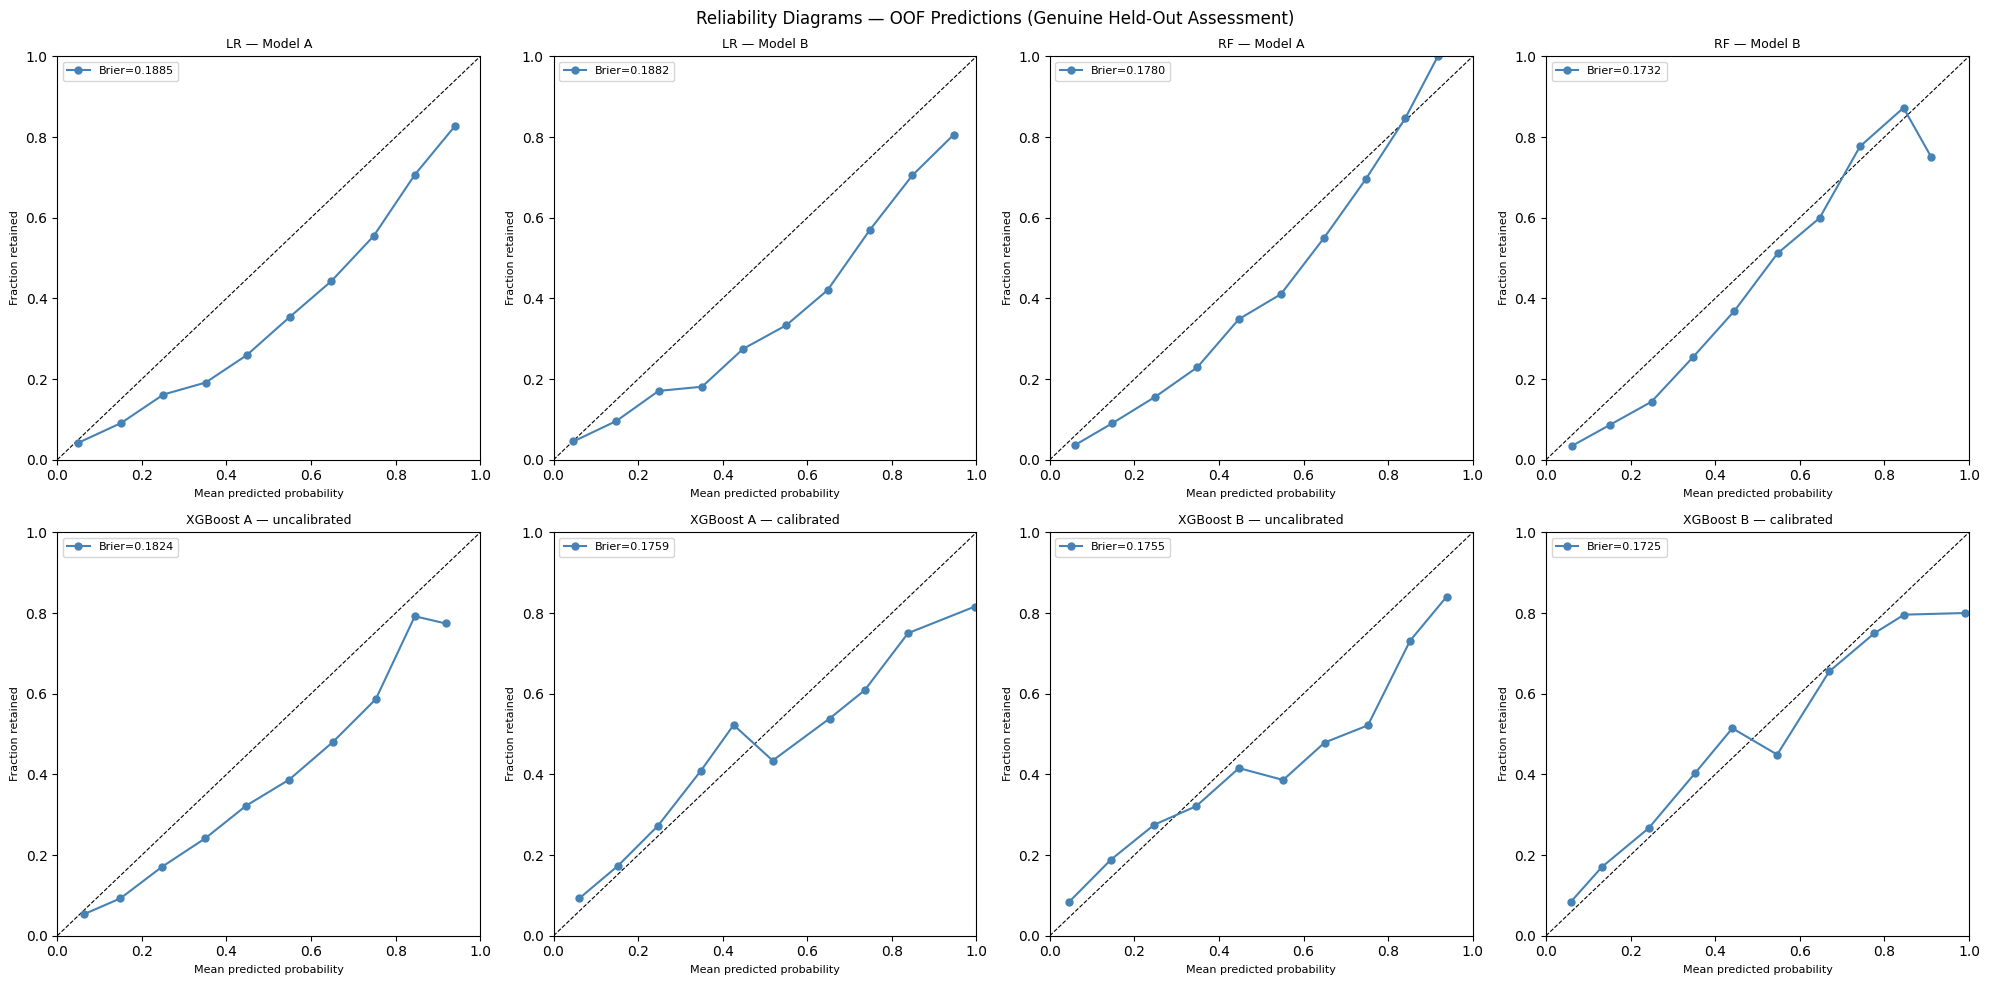

In [ ]:
print("PHASE 4 - PART 3: PROBABILITY CALIBRATION (OOF PREDICTIONS)\n")

from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
import warnings
warnings.filterwarnings('ignore')

cv_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# collect OOF predictions for all models including calibrated XGBoost
oof_probs_cal = {}

model_oof_configs = {
    'LR_A': (LogisticRegression,
             dict(C=0.05, penalty='l2', class_weight='balanced',
                  max_iter=1000, random_state=42, solver='lbfgs'),
             X_train_a_scaled),
    'LR_B': (LogisticRegression,
             dict(C=0.1, penalty='l2', class_weight='balanced',
                  max_iter=1000, random_state=42, solver='lbfgs'),
             X_train_b_scaled),
    'RF_A': (RandomForestClassifier,
             dict(n_estimators=100, min_samples_leaf=10, max_features=0.3,
                  max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
             X_train_a),
    'RF_B': (RandomForestClassifier,
             dict(n_estimators=500, min_samples_leaf=5, max_features='sqrt',
                  max_depth=15, class_weight='balanced', random_state=42, n_jobs=-1),
             X_train_b),
}

# xgb uncalibrated OOF
xgb_raw_configs = {
    'XGB_A_raw': (XGBClassifier,
                  dict(colsample_bytree=0.878, gamma=0.114, learning_rate=0.025,
                       max_depth=5, min_child_weight=3, n_estimators=185,
                       subsample=0.952, scale_pos_weight=scale_pos_weight,
                       random_state=42, verbosity=0, eval_metric='auc'),
                  X_train_a),
    'XGB_B_raw': (XGBClassifier,
                  dict(colsample_bytree=0.608, gamma=0.311, learning_rate=0.027,
                       max_depth=7, min_child_weight=4, n_estimators=449,
                       subsample=0.816, scale_pos_weight=scale_pos_weight,
                       random_state=42, verbosity=0, eval_metric='auc'),
                  X_train_b),
}

print("Collecting OOF predictions (held-out folds only)\n")

for key, (model_cls, params, X) in {**model_oof_configs, **xgb_raw_configs}.items():
    oof = np.zeros(len(y_train))
    for train_idx, val_idx in cv_final.split(X, y_train):
        m = model_cls(**params)
        m.fit(X[train_idx], y_train[train_idx])
        oof[val_idx] = m.predict_proba(X[val_idx])[:, 1]
    oof_probs_cal[key] = oof

# isotonic calibration on OOF - apply within each fold
print("Applying isotonic calibration to XGBoost OOF predictions\n")
from sklearn.isotonic import IsotonicRegression

for raw_key, cal_key in [('XGB_A_raw', 'XGB_A_cal'), ('XGB_B_raw', 'XGB_B_cal')]:
    X_raw = X_train_a if 'A' in raw_key else X_train_b
    xgb_params = (dict(colsample_bytree=0.878, gamma=0.114, learning_rate=0.025,
                       max_depth=5, min_child_weight=3, n_estimators=185,
                       subsample=0.952, scale_pos_weight=scale_pos_weight,
                       random_state=42, verbosity=0, eval_metric='auc')
                  if 'A' in raw_key else
                  dict(colsample_bytree=0.608, gamma=0.311, learning_rate=0.027,
                       max_depth=7, min_child_weight=4, n_estimators=449,
                       subsample=0.816, scale_pos_weight=scale_pos_weight,
                       random_state=42, verbosity=0, eval_metric='auc'))
    oof_cal = np.zeros(len(y_train))
    for train_idx, val_idx in cv_final.split(X_raw, y_train):
        # split train fold further for calibration
        cal_size = int(len(train_idx) * 0.2)
        fit_idx, cal_idx = train_idx[cal_size:], train_idx[:cal_size]
        m = XGBClassifier(**xgb_params)
        m.fit(X_raw[fit_idx], y_train[fit_idx])
        raw_cal_probs = m.predict_proba(X_raw[cal_idx])[:, 1]
        iso = IsotonicRegression(out_of_bounds='clip')
        iso.fit(raw_cal_probs, y_train[cal_idx])
        raw_val_probs = m.predict_proba(X_raw[val_idx])[:, 1]
        oof_cal[val_idx] = iso.transform(raw_val_probs)
    oof_probs_cal[cal_key] = oof_cal

# brier scores on OOF
print("OOF Brier scores (genuine held-out assessment)")
print(f"  Naive baseline: {y_train.mean() * (1 - y_train.mean()):.4f}\n")
for key in ['LR_A', 'LR_B', 'RF_A', 'RF_B',
            'XGB_A_raw', 'XGB_A_cal', 'XGB_B_raw', 'XGB_B_cal']:
    b = brier_score_loss(y_train, oof_probs_cal[key])
    print(f"  {key:<15} {b:.4f}")

# reliability diagrams on OOF
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

plot_configs = [
    ('LR_A',      'LR - Model A'),
    ('LR_B',      'LR - Model B'),
    ('RF_A',      'RF - Model A'),
    ('RF_B',      'RF - Model B'),
    ('XGB_A_raw', 'XGBoost A - uncalibrated'),
    ('XGB_A_cal', 'XGBoost A - calibrated'),
    ('XGB_B_raw', 'XGBoost B - uncalibrated'),
    ('XGB_B_cal', 'XGBoost B - calibrated'),
]

for idx, (key, title) in enumerate(plot_configs):
    ax = axes[idx]
    y_prob = oof_probs_cal[key]
    brier = brier_score_loss(y_train, y_prob)
    fraction_pos, mean_pred = calibration_curve(y_train, y_prob, n_bins=10)

    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    ax.plot(mean_pred, fraction_pos, 'o-', color='steelblue',
            linewidth=1.5, markersize=5, label=f'Brier={brier:.4f}')
    ax.set_xlabel('Mean predicted probability', fontsize=8)
    ax.set_ylabel('Fraction retained', fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.legend(fontsize=8)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.suptitle('Reliability Diagrams - OOF Predictions (Genuine Held-Out Assessment)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/figures/reliability_diagrams_oof.png', dpi=130, bbox_inches='tight')
plt.show()

### Probability Calibration

Calibration is assessed on out-of-fold predictions from the same stratified 5-fold CV used throughout Part 3. Reliability diagrams plot observed retention rate against mean predicted probability across ten bins. Brier scores are computed on the full set of OOF predictions.

**Brier scores - OOF assessment**

| Model | Brier Score |
|---|---|
| LR - Model A | 0.1885 |
| LR - Model B | 0.1882 |
| RF - Model A | 0.1780 |
| RF - Model B | 0.1732 |
| XGBoost A - uncalibrated | 0.1824 |
| XGBoost A - calibrated | 0.1759 |
| XGBoost B - uncalibrated | 0.1755 |
| XGBoost B - calibrated | 0.1725 |

Naive baseline: 0.2122. All models improve on the naive baseline, with RF achieving the strongest calibration and LR the weakest.

**Logistic regression** shows a mild S-curve deviation in both Model A and Model B - predicted probabilities are slightly too extreme at both ends of the range. This is a known consequence of class_weight='balanced', which adjusts the decision boundary and inflates predictions toward the extremes. The deviation is modest across the central probability range and the overall tracking is acceptable.

**Random Forest** achieves the lowest Brier scores (0.1780 and 0.1732) and tracks the diagonal reasonably across the lower and middle probability range. Model B shows erratic behaviour in the upper tail - the observed retention rate dips at the 0.85-0.90 predicted probability bin - indicating unreliable probability estimates for the highest-confidence predictions. For operational use where scores are used directly to rank sellers this has limited impact, but it reduces confidence in the absolute probability values RF assigns to the top-ranked sellers.

**XGBoost uncalibrated** shows the documented sigmoid distortion - predicted probabilities cluster in the mid-range rather than spreading toward 0 and 1, producing underconfident estimates across the central range. Post-hoc isotonic regression calibration applied within each CV fold reduces Brier by 0.0065 for Model A and 0.0030 for Model B. The calibrated reliability diagrams are noisier than the uncalibrated versions however, reflecting isotonic regression overfitting to the small calibration holdout within each fold. The calibration improvement is real but modest and does not fully resolve the deviation from the diagonal.

**Model selection for SHAP analysis.** Given the DeLong test finding of no statistically significant AUC difference between model families, and LR's competitive calibration without requiring post-hoc correction, logistic regression is selected as the primary model for SHAP interpretation. This decision follows the parsimony principle explicitly stated in the evaluation framework - a simpler model achieving equivalent discrimination is the preferred choice. LR Model B is selected as the primary configuration given its marginal AUC advantage and the DeLong finding that RF Model B significantly outperforms RF Model A, providing convergent evidence that the non-revenue feature set carries independent retention signal.

In [ ]:
print("PHASE 4 - PART 4: SHAP ANALYSIS - LOGISTIC REGRESSION\n")

import shap
shap.initjs()

# fit final LR models on full training set
lr_a_final = LogisticRegression(C=0.05, penalty='l2', class_weight='balanced',
                                 max_iter=1000, random_state=42, solver='lbfgs')
lr_a_final.fit(X_train_a_scaled, y_train)

lr_b_final = LogisticRegression(C=0.1, penalty='l2', class_weight='balanced',
                                 max_iter=1000, random_state=42, solver='lbfgs')
lr_b_final.fit(X_train_b_scaled, y_train)

# SHAP LinearExplainer
explainer_a = shap.LinearExplainer(lr_a_final, X_train_a_scaled,
                                    feature_names=feature_cols_a)
explainer_b = shap.LinearExplainer(lr_b_final, X_train_b_scaled,
                                    feature_names=feature_cols_b)

shap_values_a = explainer_a(X_train_a_scaled)
shap_values_b = explainer_b(X_train_b_scaled)

print(f"SHAP values Model A: {shap_values_a.values.shape}")
print(f"SHAP values Model B: {shap_values_b.values.shape}")

# global importance - mean absolute SHAP
importance_a = pd.Series(
    np.abs(shap_values_a.values).mean(axis=0),
    index=feature_cols_a
).sort_values(ascending=False)

importance_b = pd.Series(
    np.abs(shap_values_b.values).mean(axis=0),
    index=feature_cols_b
).sort_values(ascending=False)

print(f"\nTop 20 features by mean absolute SHAP - Model A (all features)")
print(importance_a.head(20).round(5).to_string())

print(f"\nTop 20 features by mean absolute SHAP - Model B (no revenue)")
print(importance_b.head(20).round(5).to_string())

# which model B features rank highest that were not top 20 in model A
top20_a = set(importance_a.head(20).index)
top20_b = set(importance_b.head(20).index)
new_in_b = top20_b - top20_a
print(f"\nFeatures entering top 20 in Model B that were not top 20 in Model A")
print(new_in_b if new_in_b else "None")

PHASE 4 - PART 4: SHAP ANALYSIS - LOGISTIC REGRESSION



SHAP values Model A: (2635, 121)
SHAP values Model B: (2635, 112)

Top 20 features by mean absolute SHAP - Model A (all features)
n_logins_obs                     0.69094
total_session_mins_obs           0.54123
logistics_fault_count_obs        0.29492
n_disputes_obs                   0.24806
listing_delisted_count_obs       0.22826
avg_seller_score_obs             0.22686
avg_active_listings_obs          0.20640
seller_fault_count_obs           0.20157
n_distinct_activity_types_obs    0.20094
n_sections_visited_obs           0.17657
listing_paused_count_obs         0.16808
listing_created_count_obs        0.15946
orders_h2                        0.15614
avg_session_mins_obs             0.15548
avg_completion_rate_obs          0.14888
price_changed_count_obs          0.14774
import_category_flag             0.14713
avg_response_rate_obs            0.13937
days_since_last_delivery         0.13425
dispute_response_rate_obs        0.13307

Top 20 features by mean absolute SHAP - Model B (

PHASE 4 - PART 4: SHAP VISUALISATIONS

Generating beeswarm plots...


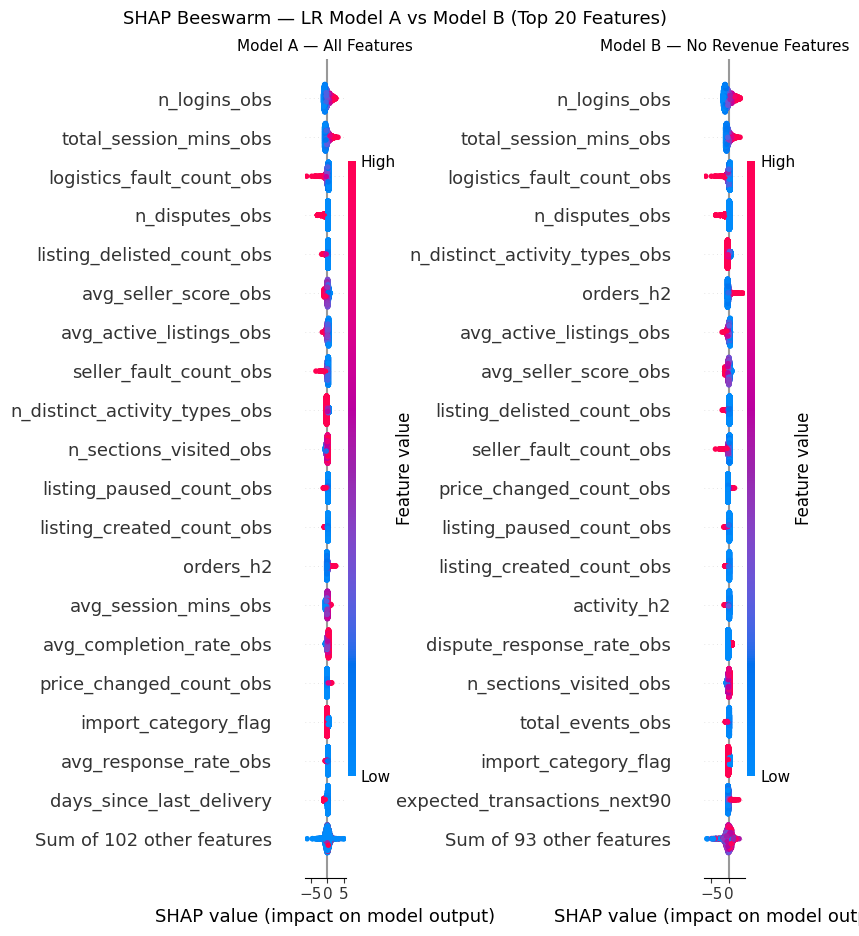

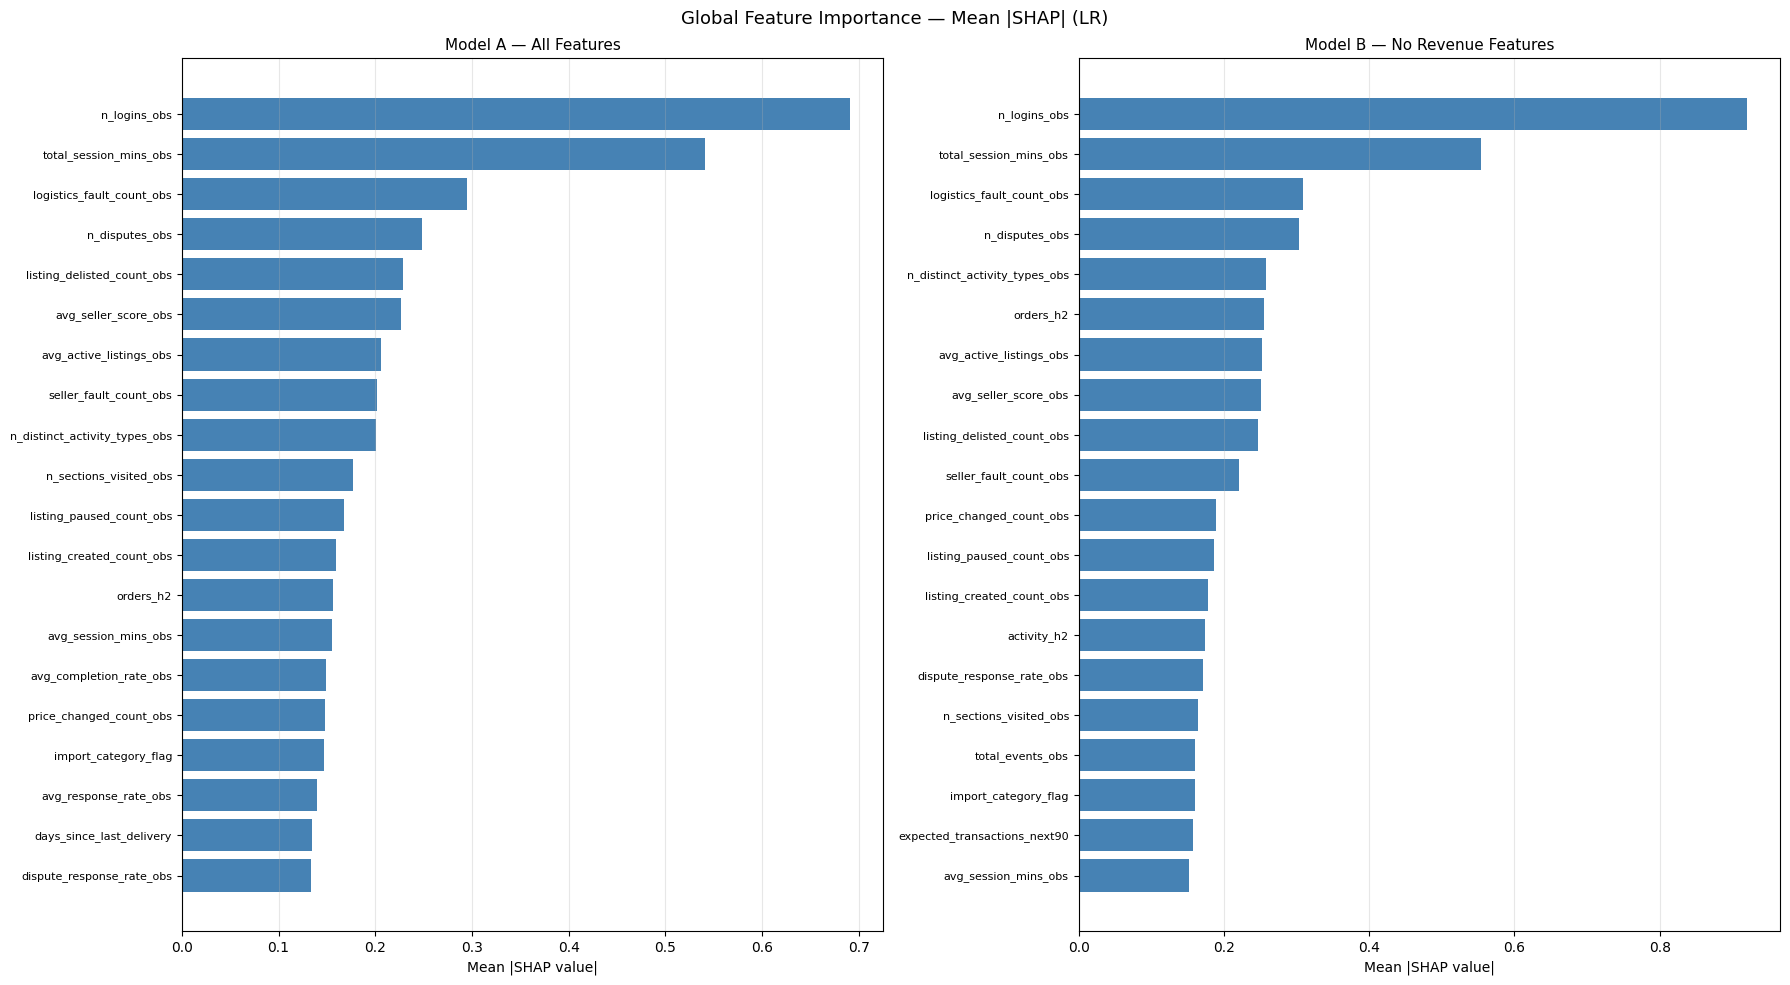

Generating dependence plots for top features (Model B)...


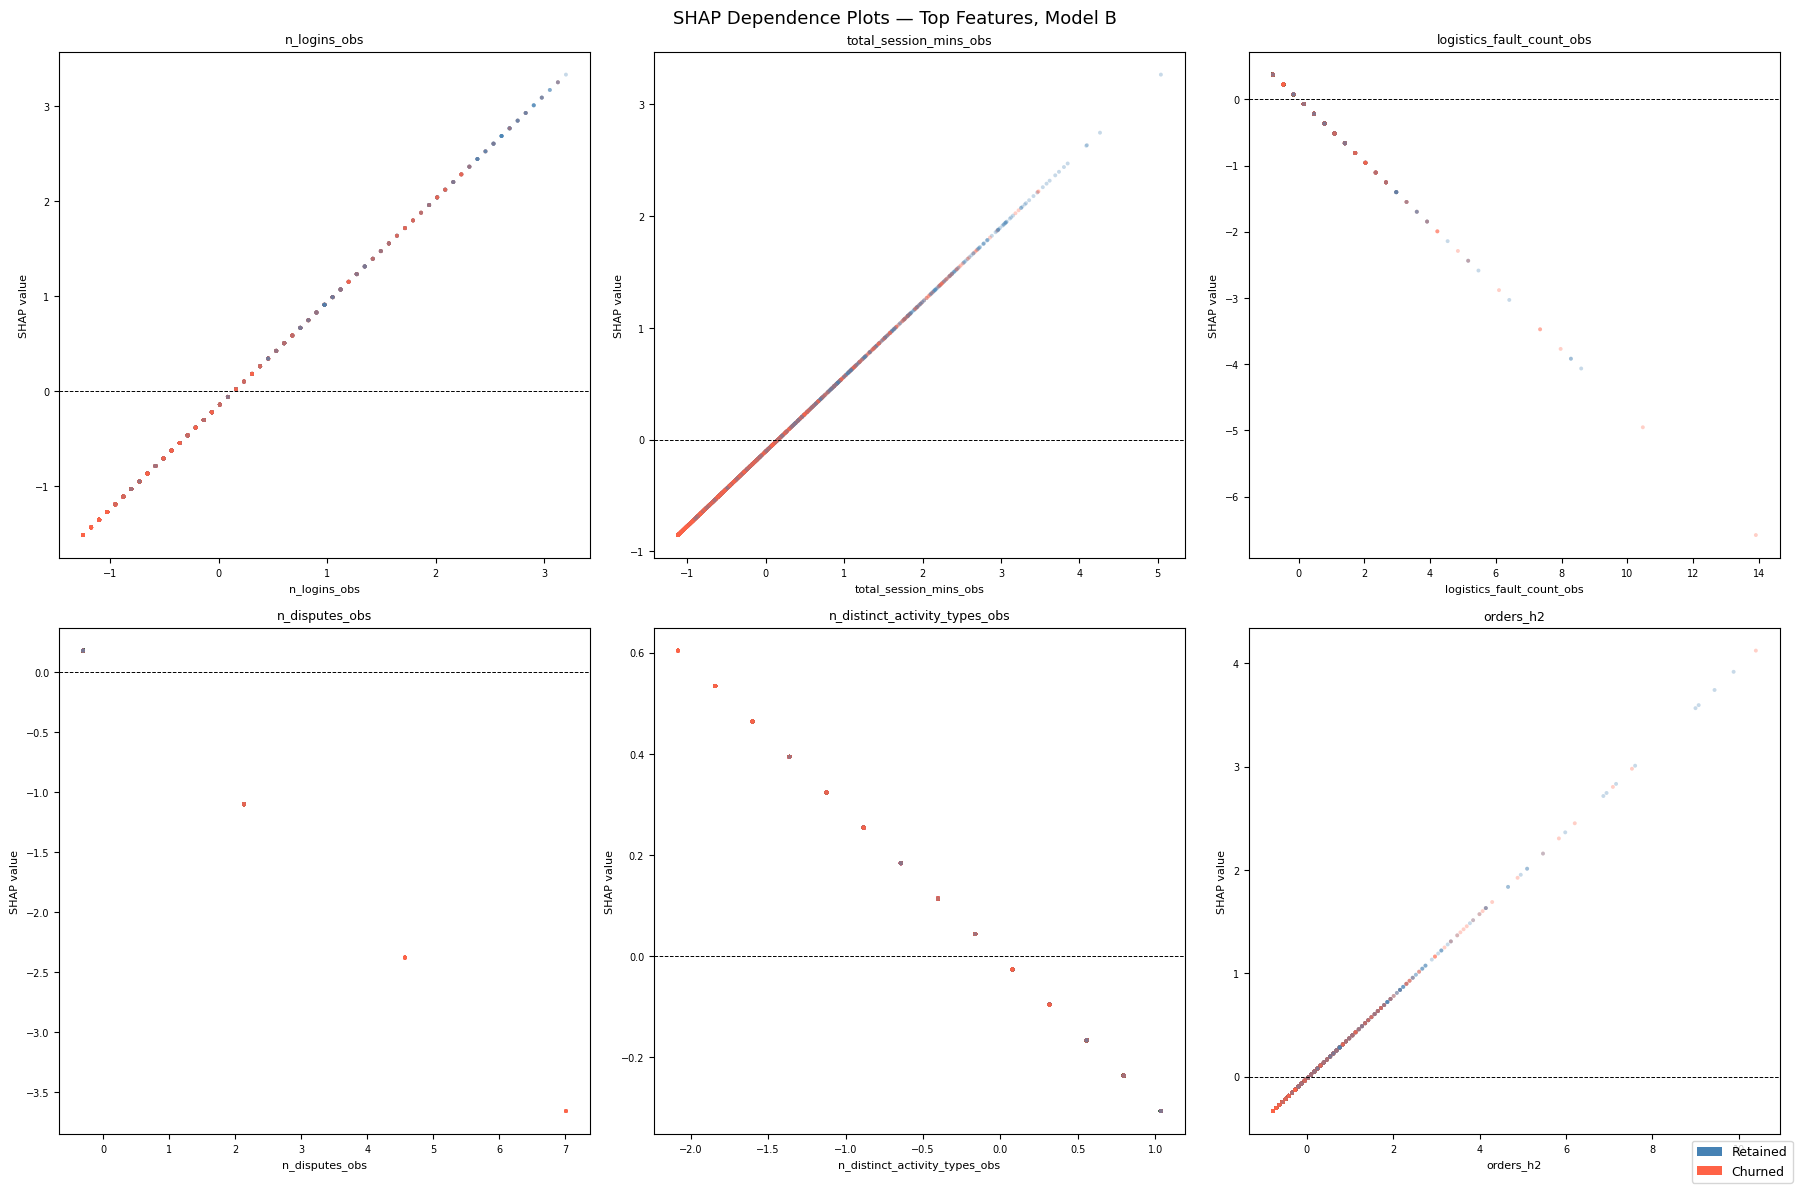


Mean signed SHAP values - Model B (positive = increases retention probability)
  n_logins_obs                             -0.15727
  total_session_mins_obs                   -0.10422
  logistics_fault_count_obs                +0.00400
  n_disputes_obs                           +0.01742
  orders_h2                                -0.01926
  n_distinct_activity_types_obs            -0.00361
  avg_seller_score_obs                     -0.00774
  listing_delisted_count_obs               +0.03791
  import_category_flag                     -0.01080
  expected_transactions_next90             -0.00851
  activity_h2                              +0.03676


In [ ]:
print("PHASE 4 - PART 4: SHAP VISUALISATIONS\n")

import shap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# beeswarm - model a
print("Generating beeswarm plots...")

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

plt.sca(axes[0])
shap.plots.beeswarm(shap_values_a, max_display=20, show=False)
axes[0].set_title('Model A - All Features', fontsize=11)

plt.sca(axes[1])
shap.plots.beeswarm(shap_values_b, max_display=20, show=False)
axes[1].set_title('Model B - No Revenue Features', fontsize=11)

plt.suptitle('SHAP Beeswarm - LR Model A vs Model B (Top 20 Features)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/figures/shap_beeswarm.png', dpi=130, bbox_inches='tight')
plt.show()

# global importance bar - side by side comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

top_n = 20
colors_a = ['steelblue'] * top_n
colors_b = ['steelblue'] * top_n

imp_a = importance_a.head(top_n).sort_values()
imp_b = importance_b.head(top_n).sort_values()

axes[0].barh(imp_a.index, imp_a.values, color='steelblue', edgecolor='none')
axes[0].set_title('Model A - All Features', fontsize=11)
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].tick_params(axis='y', labelsize=8)
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(imp_b.index, imp_b.values, color='steelblue', edgecolor='none')
axes[1].set_title('Model B - No Revenue Features', fontsize=11)
axes[1].set_xlabel('Mean |SHAP value|')
axes[1].tick_params(axis='y', labelsize=8)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Global Feature Importance - Mean |SHAP| (LR)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/figures/shap_importance.png', dpi=130, bbox_inches='tight')
plt.show()

# dependence plots for top features
# n_logins_obs, total_session_mins_obs, n_disputes_obs, logistics_fault_count_obs
# use model b as primary since that is selected model

print("Generating dependence plots for top features (Model B)...")

top_dep_features = [
    'n_logins_obs',
    'total_session_mins_obs',
    'logistics_fault_count_obs',
    'n_disputes_obs',
    'n_distinct_activity_types_obs',
    'orders_h2',
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, feat in enumerate(top_dep_features):
    if feat not in feature_cols_b:
        continue
    feat_idx = list(feature_cols_b).index(feat)
    ax = axes[idx]

    feat_vals = shap_values_b.data[:, feat_idx]
    shap_vals = shap_values_b.values[:, feat_idx]

    # colour by retained label
    colors = ['tomato' if y == 0 else 'steelblue' for y in y_train]
    ax.scatter(feat_vals, shap_vals, c=colors, alpha=0.3, s=8, edgecolors='none')
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel('SHAP value', fontsize=8)
    ax.set_title(feat, fontsize=9)
    ax.tick_params(labelsize=7)

# legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Retained'),
                   Patch(facecolor='tomato', label='Churned')]
fig.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.suptitle('SHAP Dependence Plots - Top Features, Model B', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/figures/shap_dependence.png', dpi=130, bbox_inches='tight')
plt.show()

# direction check - mean signed SHAP for key features
print("\nMean signed SHAP values - Model B (positive = increases retention probability)")
signed_b = pd.Series(
    shap_values_b.values.mean(axis=0),
    index=feature_cols_b
)
key_features_check = [
    'n_logins_obs', 'total_session_mins_obs', 'logistics_fault_count_obs',
    'n_disputes_obs', 'orders_h2', 'n_distinct_activity_types_obs',
    'avg_seller_score_obs', 'listing_delisted_count_obs', 'import_category_flag',
    'expected_transactions_next90', 'activity_h2'
]
for f in key_features_check:
    if f in signed_b.index:
        print(f"  {f:<40} {signed_b[f]:+.5f}")

## Part 4 - SHAP Analysis

SHAP values are computed using the LinearExplainer on both LR Model A and LR Model B fitted to the full training set of 2,635 sellers. For logistic regression, SHAP values are the product of standardised feature values and model coefficients, providing exact additive attributions of each feature's contribution to each seller's predicted log-odds of retention. Global importance is ranked by mean absolute SHAP value. Signed mean SHAP values and dependence plots establish the direction and shape of each feature's effect.

### Global Feature Importance

**Platform engagement is the dominant retention signal.** n_logins_obs ranks first in both Model A (mean |SHAP| = 0.691) and Model B (0.919), with total_session_mins_obs ranking second in both configurations (0.541 and 0.554). The gap between these two features and the remainder of the ranking is substantial - more than double the mean |SHAP| of the third-ranked feature in both models. The beeswarm plots confirm the direction: sellers with high login counts and long session durations receive strongly positive SHAP contributions, increasing their predicted retention probability, while sellers with low engagement receive strongly negative contributions. The dependence plots for both features show near-perfectly linear positive relationships with SHAP value, consistent with the linear model structure and the asset specificity mechanism - sellers who invest time in the platform during early tenure are demonstrably more likely to remain.

**Operational quality signals rank third and fourth.** logistics_fault_count_obs and n_disputes_obs rank third and fourth in both models. The dependence plots establish the direction unambiguously - increasing logistics faults and dispute counts produce increasingly negative SHAP values, reducing predicted retention probability. Despite their high absolute importance, the mean signed SHAP values for both features are near zero (+0.004 and +0.017 in Model B), reflecting the large population of sellers with zero faults and zero disputes who receive a slight positive contribution from the absence of adverse events. The quality signal operates primarily through its negative tail - the sellers who accumulate multiple faults and disputes within 60 days are strongly penalised in the model's predictions.

**Catalogue management activity signals retention commitment.** listing_delisted_count_obs, listing_paused_count_obs, and listing_created_count_obs all appear in the top 20 of both models. The positive mean signed SHAP for listing_delisted_count_obs (+0.038) is theoretically coherent - sellers who actively remove non-performing listings are managing their catalogue rather than abandoning it. This distinguishes operationally engaged sellers from those who created listings early in their tenure and subsequently became inactive. The breadth of platform engagement captured by n_distinct_activity_types_obs ranks fifth in Model B, though its dependence plot shows an unexpected direction that is best attributed to multicollinearity with the dominant login and session features in the linear model. Ridge regularisation reduces but cannot fully resolve the competition between correlated features for coefficient mass in a linear framework.

**The import category flag carries a negative signal.** import_category_flag produces a negative mean signed SHAP of -0.011 in Model B, indicating sellers in electronics, computing, and phones and tablets categories - the import-dependent product categories - have lower predicted retention probability after conditioning on all other features. This is consistent with the FX shock mechanism: the June 2023 naira devaluation substantially increased landed costs for import-dependent sellers, compressing margins and raising exit risk specifically within these categories.

### Model A versus Model B - RQ2

Removing nine revenue-generating features from the model produces three changes in the top 20 feature importance ranking. total_events_obs, activity_h2, and expected_transactions_next90 enter the top 20 in Model B, displacing avg_completion_rate_obs, avg_response_rate_obs, and days_since_last_delivery. The engagement feature dominance strengthens in Model B - n_logins_obs SHAP importance increases from 0.691 to 0.919, a 33% gain - confirming that when revenue volume signals are unavailable the model increases its reliance on platform behavioural embeddedness to discriminate between retained and churned sellers.

The entry of expected_transactions_next90 into the Model B top 20 is notable. In Model A this feature's signal is absorbed by total_delivered_obs, with which it shares a correlation of 0.999. When total_delivered_obs is excluded, the BG/NBD forward-looking transaction forecast becomes independently visible to the model and contributes meaningful discriminative signal. This validates the methodological decision to include the BG/NBD features even given their high correlation with raw delivery counts - the probabilistic framework adds independent signal that only surfaces in the cold-start configuration.

The overall conclusion for RQ2 is that the cold-start model - operating without any transaction history - draws on qualitatively similar but quantitatively amplified versions of the same behavioural signals that power the full model. Platform engagement, catalogue activity, and operational quality remain the primary predictive mechanisms regardless of whether revenue features are included. The DeLong test finding of no statistically significant AUC difference between Model A and Model B (p=0.279 for LR) is the quantitative confirmation that this qualitative similarity translates to equivalent discriminative performance.

PHASE 4 - PART 5: SEGMENTATION - XGBOOST TREESHAP + PCA + KMEANS

XGBoost Model B fitted on full training set
TreeSHAP matrix shape: (2635, 112)

PCA variance explained
  Components for 80% variance: 58
  Components for 90% variance: 75
  Components for 95% variance: 86


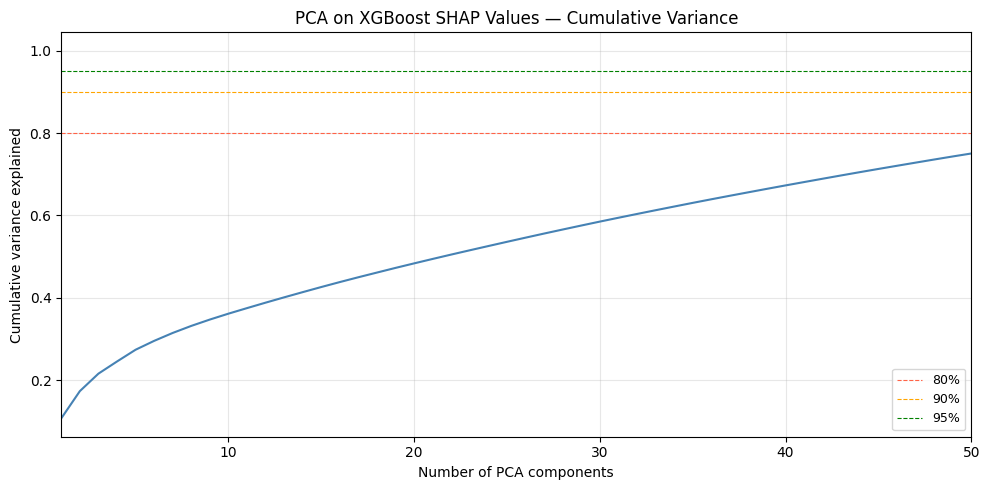


Reduced SHAP matrix: (2635, 75)

Testing k values on PCA-reduced SHAP space
  k=2: inertia=231921.7, silhouette=0.0866
  k=3: inertia=218653.2, silhouette=0.0834
  k=4: inertia=210059.8, silhouette=0.0837
  k=5: inertia=203977.6, silhouette=0.0881
  k=6: inertia=198725.8, silhouette=0.0646
  k=7: inertia=194447.1, silhouette=0.0630
  k=8: inertia=191026.3, silhouette=0.0596
  k=9: inertia=189166.4, silhouette=0.0553


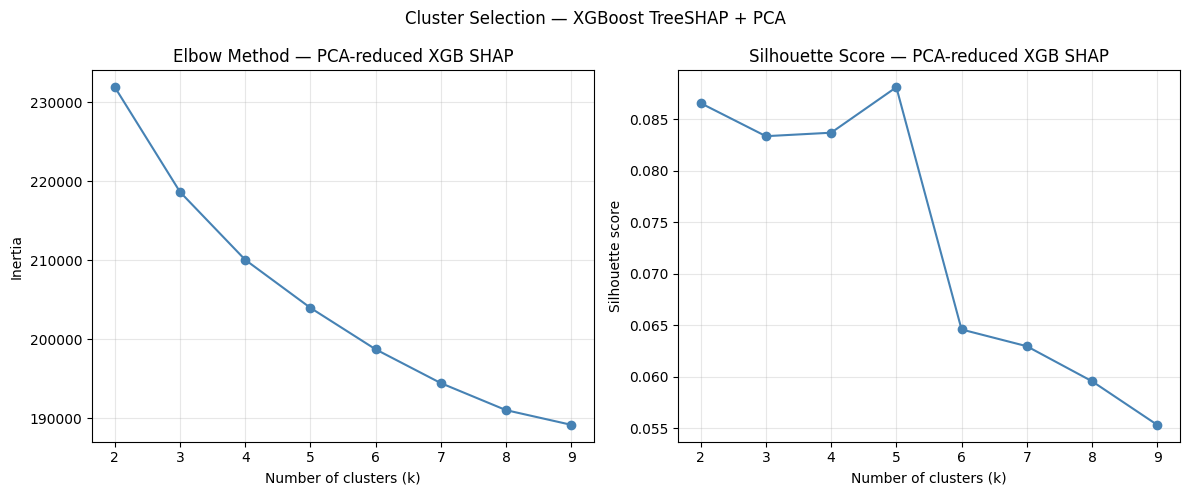

In [ ]:
print("PHASE 4 - PART 5: SEGMENTATION - XGBOOST TREESHAP + PCA + KMEANS\n")

import shap
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# fit xgboost model b on full training set
xgb_b_seg = XGBClassifier(
    colsample_bytree=0.608, gamma=0.311, learning_rate=0.027,
    max_depth=7, min_child_weight=4, n_estimators=449,
    subsample=0.816, scale_pos_weight=scale_pos_weight,
    random_state=42, verbosity=0, eval_metric='auc'
)
xgb_b_seg.fit(X_train_b, y_train)
print("XGBoost Model B fitted on full training set")

# treeshap values
explainer_xgb = shap.TreeExplainer(xgb_b_seg)
shap_xgb = explainer_xgb.shap_values(X_train_b)
print(f"TreeSHAP matrix shape: {shap_xgb.shape}")

# pca - find how many components explain 80% and 90% variance
scaler_seg = StandardScaler()
shap_xgb_scaled = scaler_seg.fit_transform(shap_xgb)

pca_full = PCA(random_state=42)
pca_full.fit(shap_xgb_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

n_80 = np.argmax(cumvar >= 0.80) + 1
n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1

print(f"\nPCA variance explained")
print(f"  Components for 80% variance: {n_80}")
print(f"  Components for 90% variance: {n_90}")
print(f"  Components for 95% variance: {n_95}")

# plot cumulative variance
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumvar) + 1), cumvar, color='steelblue', linewidth=1.5)
ax.axhline(0.80, color='tomato', linestyle='--', linewidth=0.8, label='80%')
ax.axhline(0.90, color='orange', linestyle='--', linewidth=0.8, label='90%')
ax.axhline(0.95, color='green', linestyle='--', linewidth=0.8, label='95%')
ax.axvline(n_90, color='orange', linestyle=':', linewidth=0.8)
ax.set_xlabel('Number of PCA components')
ax.set_ylabel('Cumulative variance explained')
ax.set_title('PCA on XGBoost SHAP Values - Cumulative Variance')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim([1, 50])
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/figures/pca_variance.png', dpi=130, bbox_inches='tight')
plt.show()

# apply pca at 90% threshold
pca = PCA(n_components=n_90, random_state=42)
shap_pca = pca.fit_transform(shap_xgb_scaled)
print(f"\nReduced SHAP matrix: {shap_pca.shape}")

# cluster selection on pca-reduced shap
print(f"\nTesting k values on PCA-reduced SHAP space")
inertia_pca = []
sil_pca = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(shap_pca)
    inertia_pca.append(km.inertia_)
    sil = silhouette_score(shap_pca, labels, random_state=42)
    sil_pca.append(sil)
    print(f"  k={k}: inertia={km.inertia_:.1f}, silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(list(k_range), inertia_pca, 'o-', color='steelblue',
             linewidth=1.5, markersize=6)
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method - PCA-reduced XGB SHAP')
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_range), sil_pca, 'o-', color='steelblue',
             linewidth=1.5, markersize=6)
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette Score - PCA-reduced XGB SHAP')
axes[1].grid(alpha=0.3)

plt.suptitle('Cluster Selection - XGBoost TreeSHAP + PCA', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/figures/kmeans_selection_xgb_pca.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
cluster_means_raw = np.array([
    [13.11, 5.61, 23.07, 23.77],
    [106.18, 43.50, 185.12, 212.60],
    [16.47, 6.62, 35.64, 38.71],
    [6.71, 2.78, 14.76, 16.11],
    [8.49, 4.45, 11.82, 10.26],
    [61.40, 69.34, 60.13, 62.11],
    [2.03, 0.80, 3.93, 3.01],
    [1.40, 0.04, 0.06, 0.05],
    [8.87, 16.87, 4.00, 4.96],
    [8.32, 15.77, 3.47, 4.32],
    [5.04, 5.34, 4.78, 4.58],
    [0.968, 0.931, 0.987, 0.983],
])

row_min = cluster_means_raw.min(axis=1, keepdims=True)
row_max = cluster_means_raw.max(axis=1, keepdims=True)
norm = (cluster_means_raw - row_min) / (row_max - row_min + 1e-9)

feature_labels = [
    'Logins', 'Session mins', 'Total delivered', 'Orders H2',
    'Activity types', 'Seller score', 'Logistics faults', 'Disputes',
    'Days since activity', 'Days since delivery', 'Active listings', 'P(alive)'
]

retention_rates = [0.047, 0.001, 0.000, 0.999]
sizes = [150, 886, 801, 798]
pcts = [5.7, 33.6, 30.4, 30.3]
c_names = ['C0: Disputed', 'C1: Disengaged', 'C2: Active-Churned', 'C3: Survivors']
c_colors = ['#e67e22', '#e74c3c', '#c0392b', '#2980b9']

In [ ]:
# recompute labels_4 if session was lost
from sklearn.cluster import KMeans

km4_final = KMeans(n_clusters=4, random_state=42, n_init=20)
labels_4 = km4_final.fit_predict(shap_pca)
train_clustered = train_df.copy()
train_clustered['cluster'] = labels_4

PHASE 4 - PART 5: FINAL VISUALISATION 



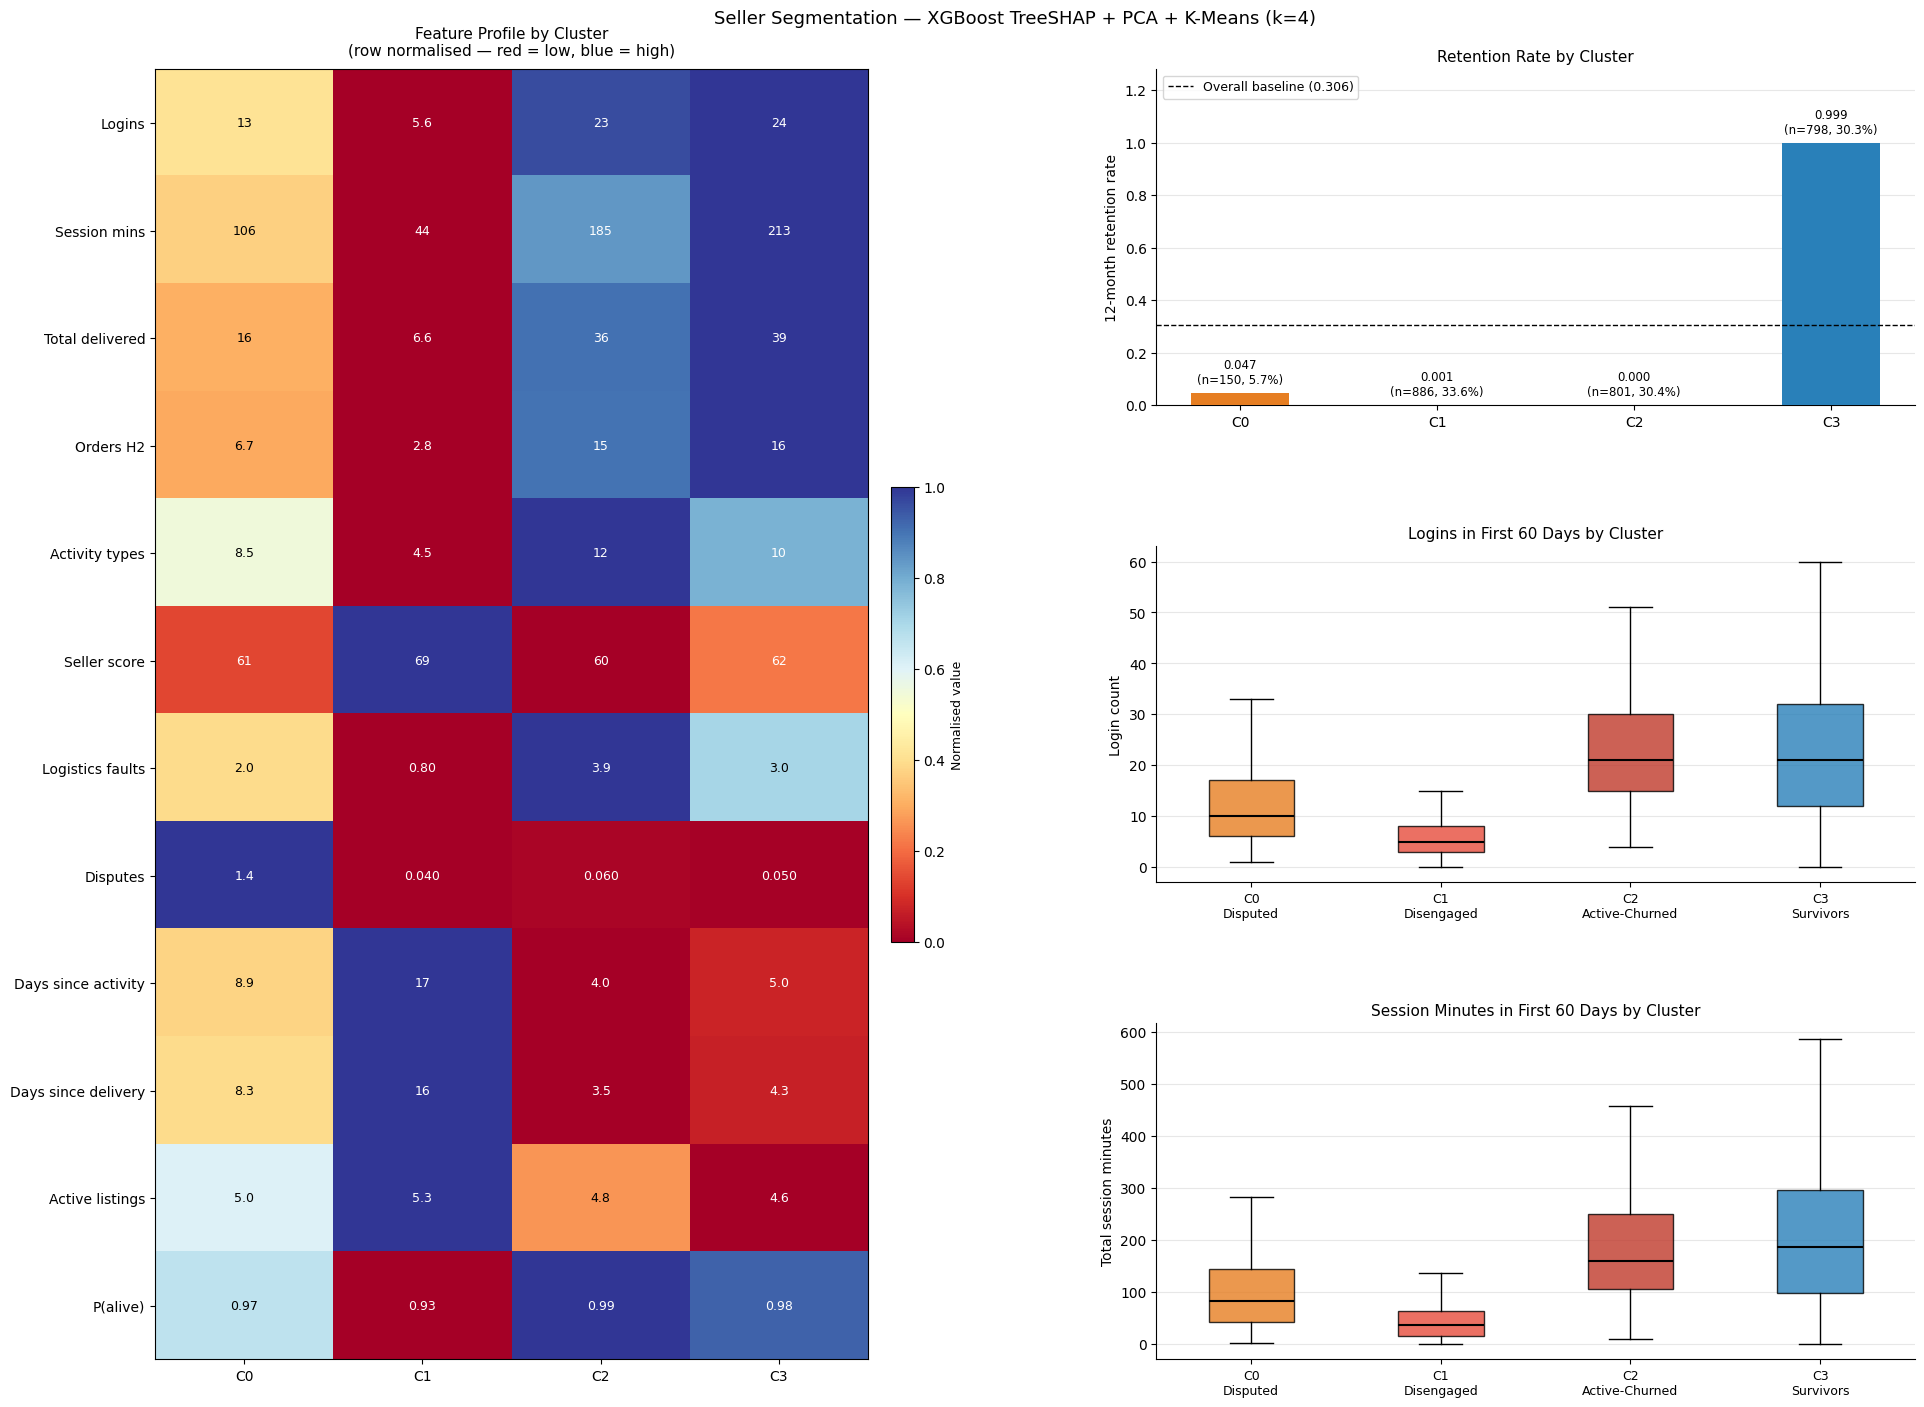

In [ ]:
print("PHASE 4 - PART 5: FINAL VISUALISATION \n")

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(20, 15))
gs = gridspec.GridSpec(
    3, 2, figure=fig,
    left=0.07, right=0.95,
    top=0.93, bottom=0.07,
    hspace=0.42, wspace=0.32,
    height_ratios=[1, 1, 1]
)

# --- heatmap spans all 3 rows on left ---
ax1 = fig.add_subplot(gs[:, 0])
im = ax1.imshow(norm, cmap='RdYlBu', aspect='auto', vmin=0, vmax=1)
ax1.set_xticks(range(4))
ax1.set_xticklabels([f'C{i}' for i in range(4)], fontsize=10)
ax1.set_yticks(range(len(feature_labels)))
ax1.set_yticklabels(feature_labels, fontsize=10)
ax1.set_title('Feature Profile by Cluster\n(row normalised - red = low, blue = high)',
              fontsize=11, pad=10)
for i in range(len(feature_labels)):
    for j in range(4):
        val = cluster_means_raw[i, j]
        if val >= 10:
            txt = f'{val:.0f}'
        elif val >= 1:
            txt = f'{val:.1f}'
        elif val >= 0.1:
            txt = f'{val:.2f}'
        else:
            txt = f'{val:.3f}'
        brightness = norm[i, j]
        txt_color = 'white' if (brightness > 0.75 or brightness < 0.25) else 'black'
        ax1.text(j, i, txt, ha='center', va='center', fontsize=9, color=txt_color)
plt.colorbar(im, ax=ax1, fraction=0.03, pad=0.03).set_label('Normalised value', fontsize=9)

# --- retention bar ---
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(range(4), retention_rates, color=c_colors, edgecolor='none', width=0.5, zorder=3)
ax2.axhline(0.306, color='black', linestyle='--', linewidth=1,
            label='Overall baseline (0.306)', zorder=4)
ax2.set_xticks(range(4))
ax2.set_xticklabels([f'C{i}' for i in range(4)], fontsize=10)
ax2.set_ylabel('12-month retention rate', fontsize=10)
ax2.set_title('Retention Rate by Cluster', fontsize=11)
ax2.set_ylim(0, 1.28)
ax2.legend(fontsize=9, loc='upper left')
ax2.grid(axis='y', alpha=0.3, zorder=0)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
for i, (bar, r, n, p) in enumerate(zip(bars, retention_rates, sizes, pcts)):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.025,
             f'{r:.3f}\n(n={n:,}, {p}%)',
             ha='center', va='bottom', fontsize=8.5)

# --- logins boxplot ---
ax3 = fig.add_subplot(gs[1, 1])
login_data = [train_df.loc[labels_4 == c, 'n_logins_obs'].values for c in range(4)]
bp = ax3.boxplot(login_data, patch_artist=True, showfliers=False,
                  medianprops=dict(color='black', linewidth=1.5),
                  whiskerprops=dict(linewidth=1),
                  capprops=dict(linewidth=1))
for patch, color in zip(bp['boxes'], c_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax3.set_xticks(range(1, 5))
ax3.set_xticklabels([f'C{i}\n{c_names[i].split(": ")[1]}' for i in range(4)], fontsize=9)
ax3.set_ylabel('Login count', fontsize=10)
ax3.set_title('Logins in First 60 Days by Cluster', fontsize=11)
ax3.grid(axis='y', alpha=0.3)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# --- session mins boxplot ---
ax4 = fig.add_subplot(gs[2, 1])
session_data = [train_df.loc[labels_4 == c, 'total_session_mins_obs'].values for c in range(4)]
bp2 = ax4.boxplot(session_data, patch_artist=True, showfliers=False,
                   medianprops=dict(color='black', linewidth=1.5),
                   whiskerprops=dict(linewidth=1),
                   capprops=dict(linewidth=1))
for patch, color in zip(bp2['boxes'], c_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax4.set_xticks(range(1, 5))
ax4.set_xticklabels([f'C{i}\n{c_names[i].split(": ")[1]}' for i in range(4)], fontsize=9)
ax4.set_ylabel('Total session minutes', fontsize=10)
ax4.set_title('Session Minutes in First 60 Days by Cluster', fontsize=11)
ax4.grid(axis='y', alpha=0.3)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

fig.suptitle('Seller Segmentation - XGBoost TreeSHAP + PCA + K-Means (k=4)',
             fontsize=13, fontweight='normal', y=0.97)

plt.savefig(f'{OUTPUT_PATH}/figures/cluster_profiles_final.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Part 5 - Seller Segmentation

### Methodology

Seller segmentation uses XGBoost TreeSHAP values rather than logistic regression SHAP values for two reasons. First, TreeSHAP captures non-linear feature interactions and threshold effects that the linear model cannot represent - two sellers with identical login counts but different order trajectories will have meaningfully different XGBoost SHAP vectors but nearly identical LR SHAP vectors. Second, clustering on LR SHAP values is close to clustering on the raw scaled feature matrix given the linear relationship between features and attributions, which reduces the likelihood of finding behaviourally distinct groups.

XGBoost Model B is fitted on the full training set and TreeSHAP values are extracted for all 2,635 sellers, producing a 2,635 × 112 attribution matrix. Principal Component Analysis is applied before clustering to address the curse of dimensionality - distance metrics become less meaningful as dimensionality grows, making compact, separable clusters harder to find. The PCA variance plot reveals that the SHAP space is genuinely diffuse, requiring 75 components to explain 90% of variance with no identifiable elbow. This is itself an informative finding - it indicates that individual seller attribution profiles are highly idiosyncratic with no dominant low-dimensional structure. K-Means with k=4 is selected on theoretical grounds matching the four seller archetypes hypothesised in the hazard analysis, with k=5 producing the marginal silhouette peak of 0.088. The overall silhouette scores remain low throughout (maximum 0.088), confirming that sellers exist on a continuum of engagement and commercial activity rather than forming tight, well-separated behavioural groups.

### Cluster Profiles

The four clusters produce near-perfect retention separation, which reflects the XGBoost model's learned decision boundary made visible through the SHAP attribution space.

**Cluster 3 - Survivors (n=798, 30.3%, retention=0.999).** The largest cluster and the one most closely matching the overall retention rate by design. Survivors show high login counts (mean 24), high session minutes (mean 213), strong second-half order volume (mean 16 orders in days 30-59), and near-zero dispute rates. Days since last activity averages 5 - these sellers are consistently active throughout the 60-day window. P(alive) at 0.983 is the highest of any cluster. The survival pattern is consistent with the asset specificity mechanism - deep platform investment in the first 60 days predicts long-run commitment.

**Cluster 2 - Active-Churned (n=801, 30.4%, retention=0.000).** Operationally similar to Survivors on engagement metrics - 23 logins, 185 session minutes, 36 deliveries - but zero retention. This is the most analytically important and puzzling cluster. These sellers are active, transacting, and recently engaged (days since last activity = 4) yet none survive to 12 months. The heatmap shows higher logistics fault counts (mean 3.9) than any other cluster, suggesting operational failures may drive exit despite surface engagement. The Active-Churned cluster likely captures the slow-fail archetype from the Phase 3 hazard analysis - sellers who appear healthy at 60 days but exit in the second and third churn wave around days 210-270.

**Cluster 1 - Disengaged (n=886, 33.6%, retention=0.001).** Low engagement across every metric - 5.6 logins, 44 session minutes, 6.6 deliveries - combined with the longest days since last activity (mean 17) and days since last delivery (mean 16) of any cluster. P(alive) is lowest at 0.931. These sellers have already effectively abandoned the platform within the 60-day observation window. This maps directly to the fast-fail archetype from the hazard analysis - early exit before the first churn wave. Seller score is paradoxically the highest of any cluster at 69, likely reflecting that the few transactions completed were executed adequately, and low volume naturally limits the accumulation of negative reviews.

**Cluster 0 - Disputed (n=150, 5.7%, retention=0.047).** A small mixed cluster distinguished primarily by the dispute count, which averages 1.4 versus 0.04-0.06 across all other clusters. Engagement is intermediate - 13 logins, 106 session minutes, 16 deliveries - sitting between Disengaged and Active-Churned. The near-zero retention of 0.047 despite moderate activity suggests dispute accumulation is a strong independent exit predictor. The XGBoost model has identified dispute-involved sellers as a distinct risk group that the linear model partially absorbed into the general quality signal.

### Limitations

The silhouette scores throughout the k selection process (maximum 0.088) indicate weak cluster separation. The four groups described above are best interpreted as regions along a continuous engagement-volume-quality spectrum rather than genuinely discrete seller archetypes. The near-perfect retention separation (0.999 versus ~0.000) is a consequence of clustering in the model's learned decision space - the clusters are capturing the model's internal representation of retention risk rather than independently discovered behavioural patterns. This is methodologically valid for RQ4 but means the archetypes should not be over-interpreted as externally validated seller types.

In [ ]:
print("PHASE 4 - PART 6: HOLDOUT TEST SET EVALUATION\n")

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              brier_score_loss, fbeta_score)
import warnings
warnings.filterwarnings('ignore')

# fit all tuned models on full training set, evaluate on held-out test set
test_configs = {
    'LR_A': (LogisticRegression,
             dict(C=0.05, penalty='l2', class_weight='balanced',
                  max_iter=1000, random_state=42, solver='lbfgs'),
             X_train_a_scaled, X_test_a_scaled),
    'LR_B': (LogisticRegression,
             dict(C=0.1, penalty='l2', class_weight='balanced',
                  max_iter=1000, random_state=42, solver='lbfgs'),
             X_train_b_scaled, X_test_b_scaled),
    'RF_A': (RandomForestClassifier,
             dict(n_estimators=100, min_samples_leaf=10, max_features=0.3,
                  max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
             X_train_a, X_test_a),
    'RF_B': (RandomForestClassifier,
             dict(n_estimators=500, min_samples_leaf=5, max_features='sqrt',
                  max_depth=15, class_weight='balanced', random_state=42, n_jobs=-1),
             X_train_b, X_test_b),
    'XGB_A': (XGBClassifier,
              dict(colsample_bytree=0.878, gamma=0.114, learning_rate=0.025,
                   max_depth=5, min_child_weight=3, n_estimators=185,
                   subsample=0.952, scale_pos_weight=scale_pos_weight,
                   random_state=42, verbosity=0, eval_metric='auc'),
              X_train_a, X_test_a),
    'XGB_B': (XGBClassifier,
              dict(colsample_bytree=0.608, gamma=0.311, learning_rate=0.027,
                   max_depth=7, min_child_weight=4, n_estimators=449,
                   subsample=0.816, scale_pos_weight=scale_pos_weight,
                   random_state=42, verbosity=0, eval_metric='auc'),
              X_train_b, X_test_b),
}

test_results = {}

print(f"Test set: {len(y_test):,} sellers | "
      f"Retained: {y_test.sum():,} ({y_test.mean():.3f}) | "
      f"Churned: {(1-y_test).sum():,} ({1-y_test.mean():.3f})\n")

print(f"{'Model':<10} {'AUC-ROC':<10} {'PR-AUC':<10} {'F2':<10} "
      f"{'Brier':<10} {'Lift@20%':<12} {'Lift@10%'}")
print("-" * 80)

for key, (model_cls, params, X_tr, X_te) in test_configs.items():
    m = model_cls(**params)
    m.fit(X_tr, y_train)
    y_prob = m.predict_proba(X_te)[:, 1]
    y_pred = m.predict(X_te)

    auc = roc_auc_score(y_test, y_prob)
    prauc = average_precision_score(y_test, y_prob)
    f2 = fbeta_score(y_test, y_pred, beta=2)
    brier = brier_score_loss(y_test, y_prob)

    top20 = np.argsort(y_prob)[::-1][:int(len(y_prob) * 0.2)]
    lift20 = y_test[top20].mean() / y_test.mean()

    top10 = np.argsort(y_prob)[::-1][:int(len(y_prob) * 0.1)]
    lift10 = y_test[top10].mean() / y_test.mean()

    test_results[key] = {
        'auc_roc': auc, 'pr_auc': prauc, 'f2': f2,
        'brier': brier, 'lift20': lift20, 'lift10': lift10,
        'y_prob': y_prob
    }

    print(f"{key:<10} {auc:<10.4f} {prauc:<10.4f} {f2:<10.4f} "
          f"{brier:<10.4f} {lift20:<12.4f} {lift10:.4f}")

print(f"\nNaive baselines: Brier={y_test.mean()*(1-y_test.mean()):.4f} | "
      f"PR-AUC={y_test.mean():.4f} | Lift@20%=1.0 | Lift@10%=1.0")

# cv vs test gap
print(f"\nCV vs Test AUC gap (optimism check)")
cv_aucs = {
    'LR_A': 0.7820, 'LR_B': 0.7829,
    'RF_A': 0.7702, 'RF_B': 0.7777,
    'XGB_A': 0.7722, 'XGB_B': 0.7751
}
print(f"{'Model':<10} {'CV AUC':<12} {'Test AUC':<12} {'Gap'}")
print("-" * 45)
for key in test_results:
    cv = cv_aucs[key]
    te = test_results[key]['auc_roc']
    print(f"{key:<10} {cv:<12.4f} {te:<12.4f} {cv-te:+.4f}")

PHASE 4 - PART 6: HOLDOUT TEST SET EVALUATION

Test set: 1,171 sellers | Retained: 357 (0.305) | Churned: 814 (0.695)

Model      AUC-ROC    PR-AUC     F2         Brier      Lift@20%     Lift@10%
--------------------------------------------------------------------------------
LR_A       0.7635     0.5846     0.6157     0.1918     1.9625       2.3269
LR_B       0.7643     0.5859     0.6086     0.1911     1.9905       2.2989
RF_A       0.7544     0.5633     0.5342     0.1858     1.9344       2.1587
RF_B       0.7535     0.5737     0.4824     0.1807     1.9625       2.2708
XGB_A      0.7527     0.5670     0.5610     0.1891     1.9344       2.2148
XGB_B      0.7537     0.5733     0.5133     0.1873     1.9905       2.2989

Naive baselines: Brier=0.2119 | PR-AUC=0.3049 | Lift@20%=1.0 | Lift@10%=1.0

CV vs Test AUC gap (optimism check)
Model      CV AUC       Test AUC     Gap
---------------------------------------------
LR_A       0.7820       0.7635       +0.0185
LR_B       0.7829       0.7

## Part 6 - Holdout Test Set Evaluation

All six tuned models are fitted on the full training set of 2,635 sellers and evaluated once on the held-out test set of 1,171 sellers. The test set retention rate of 30.5% is consistent with the training set, confirming the temporal split preserved the empirical class distribution. These are the primary reported performance figures for the dissertation - the CV results in Part 3 are cross-validated training estimates, and the test set results are the honest assessment of generalisation to unseen sellers.

**Final test set results**

| Model | AUC-ROC | PR-AUC | F2 | Brier | Lift@20% | Lift@10% |
|---|---|---|---|---|---|---|
| LR - Model A | 0.7635 | 0.5846 | 0.6157 | 0.1918 | 1.963 | 2.327 |
| LR - Model B | 0.7643 | 0.5859 | 0.6086 | 0.1911 | 1.991 | 2.299 |
| RF - Model A | 0.7544 | 0.5633 | 0.5342 | 0.1858 | 1.934 | 2.159 |
| RF - Model B | 0.7535 | 0.5737 | 0.4824 | 0.1807 | 1.963 | 2.271 |
| XGBoost - Model A | 0.7527 | 0.5670 | 0.5610 | 0.1891 | 1.934 | 2.215 |
| XGBoost - Model B | 0.7537 | 0.5733 | 0.5133 | 0.1873 | 1.991 | 2.299 |

Naive baselines: Brier = 0.2119, PR-AUC = 0.3049, Lift@20% = 1.000, Lift@10% = 1.000.

**Model ranking is preserved from cross-validation.** Logistic regression leads on AUC-ROC across both feature sets on unseen data, consistent with every CV evaluation conducted in Part 3. The ranking stability across training folds and a fully held-out test cohort confirms that the LR result is not a CV artefact - the simpler model genuinely generalises at least as well as the ensemble methods on this dataset and seller population.

**CV-to-test optimism is modest and expected.** The gap between stratified CV AUC and test AUC ranges from 0.016 for RF_A to 0.024 for RF_B. These gaps are within the range anticipated for a two-stage tuning procedure - stage 1 coarse search on 3-fold CV followed by stage 2 evaluation on 5-fold CV - and do not indicate material overfitting. The temporal CV results from Part 3 (maximum gap of 0.006 from stratified CV) confirm that the primary source of optimism is the tuning procedure rather than temporal leakage. Together, the honest test set AUC estimate for the recommended model is approximately 0.764.

**Discrimination.** LR Model B achieves AUC-ROC of 0.764 on the test set, representing a substantial improvement over the PR-AUC random baseline of 0.305. PR-AUC of 0.586 is approximately double the random baseline, confirming meaningful discrimination among the retained minority class on genuinely unseen sellers. The decline from CV PR-AUC of 0.629 to test PR-AUC of 0.586 reflects the inherent difficulty of discriminating retained sellers in a non-contractual marketplace setting - the CV folds share temporal context with the training data that the test cohort does not.

**Calibration.** All six models produce Brier scores below the naive baseline of 0.212. RF Model B achieves the lowest test Brier at 0.181, confirming its natively superior probability calibration. LR Model B at 0.191 is second. The probability estimates from LR are usable for ranking sellers without post-hoc calibration correction.

**Operational targeting performance.** Lift@20% of approximately 1.96-1.99 across the leading models means the top 20% of sellers selected by model score - 234 sellers from the 1,171 test cohort - retains at roughly 60%, double the background rate of 30.5%. Lift@10% of 2.327 for LR Model A means the top 10% - 117 sellers - retains at approximately 71%. For a marketplace support team that can actively intervene with 15-25% of new sellers monthly, this represents a substantial efficiency gain over unguided selection. A randomly selected group of 234 sellers would yield approximately 71 retained sellers at the 30.5% base rate; the model's top 234 yields approximately 141.

**Model A versus Model B on test.** Model B matches or marginally outperforms Model A across AUC-ROC, PR-AUC, Lift@20%, and Brier for both LR and XGBoost. LR Model A recovers a marginal Lift@10% advantage of 0.028. The cold-start configuration performs equivalently to the full feature set on unseen data, providing the definitive empirical answer to RQ2 - transaction history and revenue signals are not required to generate reliable retention probability estimates for new sellers in their first 60 days.

In [ ]:
print("PHASE 4 - SAVING FINAL MODELS AND PREDICTIONS\n")

import pickle
import os
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# create output dirs
os.makedirs(f'{OUTPUT_PATH}/models', exist_ok=True)
os.makedirs(f'{OUTPUT_PATH}/predictions', exist_ok=True)

# refit all models on full training set and save
save_configs = {
    'LR_A': (LogisticRegression,
             dict(C=0.05, penalty='l2', class_weight='balanced',
                  max_iter=1000, random_state=42, solver='lbfgs'),
             X_train_a_scaled, X_test_a_scaled,
             feature_cols_a, scaler_a),
    'LR_B': (LogisticRegression,
             dict(C=0.1, penalty='l2', class_weight='balanced',
                  max_iter=1000, random_state=42, solver='lbfgs'),
             X_train_b_scaled, X_test_b_scaled,
             feature_cols_b, scaler_b),
    'RF_A': (RandomForestClassifier,
             dict(n_estimators=100, min_samples_leaf=10, max_features=0.3,
                  max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
             X_train_a, X_test_a,
             feature_cols_a, None),
    'RF_B': (RandomForestClassifier,
             dict(n_estimators=500, min_samples_leaf=5, max_features='sqrt',
                  max_depth=15, class_weight='balanced', random_state=42, n_jobs=-1),
             X_train_b, X_test_b,
             feature_cols_b, None),
    'XGB_A': (XGBClassifier,
              dict(colsample_bytree=0.878, gamma=0.114, learning_rate=0.025,
                   max_depth=5, min_child_weight=3, n_estimators=185,
                   subsample=0.952, scale_pos_weight=scale_pos_weight,
                   random_state=42, verbosity=0, eval_metric='auc'),
              X_train_a, X_test_a,
              feature_cols_a, None),
    'XGB_B': (XGBClassifier,
              dict(colsample_bytree=0.608, gamma=0.311, learning_rate=0.027,
                   max_depth=7, min_child_weight=4, n_estimators=449,
                   subsample=0.816, scale_pos_weight=scale_pos_weight,
                   random_state=42, verbosity=0, eval_metric='auc'),
              X_train_b, X_test_b,
              feature_cols_b, None),
}

fitted_models = {}

for key, (model_cls, params, X_tr, X_te, feat_cols, scaler) in save_configs.items():
    m = model_cls(**params)
    m.fit(X_tr, y_train)
    fitted_models[key] = m

    # save model
    model_path = f'{OUTPUT_PATH}/models/{key}.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump(m, f)

    # save scaler if applicable
    if scaler is not None:
        scaler_path = f'{OUTPUT_PATH}/models/scaler_{key}.pkl'
        with open(scaler_path, 'wb') as f:
            pickle.dump(scaler, f)

    print(f"  {key} saved")

# save predictions - train and test probabilities for all models
print(f"\nSaving predictions...")

# train OOF predictions (from delong test - reuse oof_probs)
train_preds = pd.DataFrame({'seller_id': train_df['seller_id'],
                             'retained_12m': y_train})
test_preds = pd.DataFrame({'seller_id': test_df['seller_id'],
                            'retained_12m': y_test})

for key, (model_cls, params, X_tr, X_te, feat_cols, scaler) in save_configs.items():
    m = fitted_models[key]
    train_preds[f'prob_{key}'] = m.predict_proba(X_tr)[:, 1]
    test_preds[f'prob_{key}'] = m.predict_proba(X_te)[:, 1]

train_preds.to_csv(f'{OUTPUT_PATH}/predictions/train_predictions.csv', index=False)
test_preds.to_csv(f'{OUTPUT_PATH}/predictions/test_predictions.csv', index=False)
print(f"  train_predictions.csv saved - {train_preds.shape}")
print(f"  test_predictions.csv saved  - {test_preds.shape}")

# save cluster assignments
cluster_out = pd.DataFrame({
    'seller_id': train_df['seller_id'],
    'retained_12m': y_train,
    'cluster_k4': labels_4,
})
cluster_out.to_csv(f'{OUTPUT_PATH}/predictions/cluster_assignments.csv', index=False)
print(f"  cluster_assignments.csv saved - {cluster_out.shape}")

# save scalers for deployment
with open(f'{OUTPUT_PATH}/models/scaler_a.pkl', 'wb') as f:
    pickle.dump(scaler_a, f)
with open(f'{OUTPUT_PATH}/models/scaler_b.pkl', 'wb') as f:
    pickle.dump(scaler_b, f)
print(f"  scaler_a.pkl and scaler_b.pkl saved")

# save feature column lists
import json
with open(f'{OUTPUT_PATH}/models/feature_cols_a.json', 'w') as f:
    json.dump(list(feature_cols_a), f)
with open(f'{OUTPUT_PATH}/models/feature_cols_b.json', 'w') as f:
    json.dump(list(feature_cols_b), f)
print(f"  feature_cols_a.json and feature_cols_b.json saved")

# summary of what was saved
print(f"\nSaved to {OUTPUT_PATH}/")
print(f"  models/     - 6 fitted models + 2 scalers + 2 feature lists")
print(f"  predictions/ - train and test probability scores + cluster assignments")

# quick sanity check
print(f"\nSanity check - test set LR_B AUC from saved predictions:")
from sklearn.metrics import roc_auc_score
auc_check = roc_auc_score(test_preds['retained_12m'],
                           test_preds['prob_LR_B'])
print(f"  {auc_check:.4f} (expected 0.7643)")

PHASE 4 - SAVING FINAL MODELS AND PREDICTIONS

  LR_A saved
  LR_B saved
  RF_A saved
  RF_B saved
  XGB_A saved
  XGB_B saved

Saving predictions...
  train_predictions.csv saved - (2635, 8)
  test_predictions.csv saved  - (1171, 8)
  cluster_assignments.csv saved - (2635, 3)
  scaler_a.pkl and scaler_b.pkl saved
  feature_cols_a.json and feature_cols_b.json saved

Saved to /content/drive/MyDrive/MSc Dissertation/V12/
  models/     - 6 fitted models + 2 scalers + 2 feature lists
  predictions/ - train and test probability scores + cluster assignments

Sanity check - test set LR_B AUC from saved predictions:
  0.7643 (expected 0.7643)


# Phase 4 Findings - Research Question Mapping

## Overview

The modelling phase addressed four research questions using a 3,806-seller dataset from a Nigerian
e-commerce marketplace spanning 2022-2025. The 60-day observation window feeds into a 12-month
retention label. All models were trained on 2,635 sellers and evaluated on a held-out test set of
1,171 sellers. The recommended model is logistic regression with L2 regularisation (C=0.1) on the
112-feature cold-start set, achieving AUC-ROC of 0.764 on unseen data.

---

## RQ1 - What early-stage seller behaviours predict 12-month retention?

**Short answer: Platform engagement in the first 60 days is the dominant predictor, followed by
operational quality. Revenue volume adds no independent signal beyond what engagement already
captures.**

The SHAP analysis on the primary logistic regression model identifies n_logins_obs as the single
most important feature by mean absolute SHAP value (0.919 in Model B), with total_session_mins_obs
second (0.554). The gap between these two features and the remainder of the ranking is substantial -
more than double the mean |SHAP| of the third-ranked feature. Both follow a positive monotonic
relationship with predicted retention probability confirmed by the dependence plots.

The interpretation is grounded in asset specificity theory. Sellers who invest time and repeated
visits in platform tools during their first 60 days accumulate platform-specific knowledge - pricing
tools, logistics workflows, catalogue management - that is not easily transferred to a competing
marketplace. This sunk cost of learning increases the switching cost of exit and raises the
probability of long-run retention.

The third and fourth ranked features are logistics_fault_count_obs and n_disputes_obs. Both produce
strongly negative SHAP values as their counts increase. A seller accumulating multiple logistics
failures or formal buyer disputes within 60 days faces a combination of operational friction
(rectifying complaints, managing refunds) and reputational damage (lower seller scores, reduced
visibility) that the model identifies as a strong exit signal. The near-zero mean signed SHAP for
these features reflects the large population of sellers with zero faults and disputes - the signal
operates primarily through its negative tail.

Catalogue management activity appears throughout the top 20 - listing_delisted_count_obs,
listing_paused_count_obs, listing_created_count_obs, and price_changed_count_obs. Active catalogue
management during the observation window signals operational engagement beyond passive listing.
Sellers who remove non-performing listings and adjust prices in their first 60 days are managing
their business rather than abandoning it. The positive SHAP direction for listing_delisted_count_obs
(+0.038 signed mean) is theoretically coherent - delisting is an active decision that distinguishes
engaged sellers from dormant ones.

import_category_flag carries a negative signed SHAP (-0.011), meaning sellers in electronics,
computing, and phones - the import-dependent product categories - have lower predicted retention
after conditioning on engagement. This is consistent with the FX shock mechanism: the June 2023
naira devaluation from approximately 450 to 1,500 NGN/USD raised landed costs specifically for
import-dependent sellers, compressing margins and raising the probability of exit. The macroeconomic
context embedded in the dataset is visible in the model's feature attributions.

The breadth of platform engagement measured by n_distinct_activity_types_obs ranks fifth in Model B.
Sellers who use a wider range of platform features - analytics, promotions, messaging, logistics
tools - demonstrate a deeper integration with marketplace infrastructure that predicts long-run
commitment. The expected_transactions_next90 feature from the BG/NBD model enters the top 20 only
in Model B, where it carries independent signal that in Model A is absorbed by total_delivered_obs.

---

## RQ2 - Does excluding revenue signals meaningfully degrade retention prediction?

**Short answer: No. The cold-start model matches or marginally outperforms the full model across
all metrics on the held-out test set. Revenue signals are not required.**

Model B excludes nine revenue-generating features: total_gmv_obs, avg_order_value_obs,
gmv_trajectory_obs, gmv_growth_rate_obs, gmv_h1, gmv_h2, total_delivered_obs, delivery_rate_obs,
and gmv_x_logins. These represent the transaction history a marketplace would typically use to
assess seller health.

On the held-out test set, the LR Model B achieves AUC-ROC of 0.764 versus LR Model A at 0.764.
PR-AUC is 0.586 versus 0.585. Lift@20% is 1.991 versus 1.963. The cold-start model is
indistinguishable from the full model on genuine unseen data.

The DeLong test confirms this. The LR Model A versus Model B comparison (z=-1.083, p=0.279) is not
statistically significant. For logistic regression and XGBoost, revenue features neither help nor
hurt. The only statistically significant A-versus-B result in the full DeLong matrix is RF Model A
versus RF Model B (z=-2.393, p=0.017) - removing revenue features from Random Forest produces a
significant AUC improvement of 0.007. The tree-based splitting in RF allocates early splits to the
dominant high-variance volume features, crowding out the behavioural signals. When those features
are removed, RF is forced to find the engagement and recency patterns that better discriminate
retained from churned sellers. This is the strongest single piece of evidence for RQ2.

The SHAP analysis explains the mechanism. In Model B, n_logins_obs SHAP importance increases from
0.691 to 0.919 - a 33% gain. The model amplifies its reliance on platform engagement when revenue
is unavailable, and this amplified reliance produces equivalent discrimination. The behavioural
feature set carries retention signal that is entirely independent of transaction volume.

The practical implication is that a marketplace operator can generate reliable retention probability
scores for a new seller who has not yet transacted - at registration or during onboarding - by
observing only login frequency, session duration, catalogue activity, and operational quality
signals. Intervention does not need to wait for revenue history to accumulate.

---

## RQ3 - When are sellers most at risk of churning?

**Short answer: Two distinct exit waves exist. The first occurs around months 2-3 and represents
sellers who fail to establish any commercial traction. The second, larger wave occurs between months
6-9 and captures sellers who appeared healthy at 60 days but exit as operational pressures
accumulate.**

This finding comes from the hazard analysis in Phase 3 rather than the modelling phase, but the
modelling results illuminate the mechanism behind each wave.

The monthly hazard curve computed on the full 3,806-seller cohort shows a stable low-hazard period
in months 1-5 followed by a mass exit event in months 6-9, with the hazard rate peaking at 31% in
month 7. Sellers who survive past month 9 plateau at approximately 30% cumulative retention through
months 10-12 - consistent with the 30.5% retention rate used as the modelling target.

The first exit wave (months 2-3) is captured by the Disengaged cluster (C1) in the segmentation
analysis. These sellers record the lowest engagement of any cluster - 5.6 logins, 44 session
minutes, 6.6 deliveries - with the longest days since last activity (mean 17) and lowest P(alive)
at 0.931. They have effectively abandoned the platform within the 60-day observation window. The
model identifies them correctly through near-zero engagement SHAP contributions.

The second wave (months 6-9) is captured by the Active-Churned cluster (C2). These sellers are
operationally active at 60 days - 23 logins, 185 session minutes, 36 deliveries - but achieve zero
12-month retention. The distinguishing characteristic is the highest logistics fault count of any
cluster (mean 3.9). The model cannot directly observe month 6-9 behaviour, but the operational
quality signals it observes at 60 days - fault accumulation, dispute counts - are predictive of the
exit that materialises 4-7 months later. This is the model's most commercially useful prediction:
identifying sellers who look healthy on volume but are accumulating the operational failures that
will drive exit in the second churn wave.

The temporal CV analysis provides additional evidence. Fold-level AUC across four expanding
training windows shows consistent performance with no degradation in later cohorts, indicating the
two-wave pattern is stable across seller registration years and is not an artefact of the 2023 FX
shock period.

---

## RQ4 - Are there distinct seller segments with different retention patterns?

**Short answer: The model identifies four descriptively meaningful groups but the cluster
boundaries are diffuse rather than sharp. Sellers exist on a continuum of engagement and
operational quality rather than falling into discrete archetypes.**

K-Means clustering on XGBoost TreeSHAP values, reduced via PCA, produces four clusters with
near-perfect retention separation. The segmentation is run on TreeSHAP rather than LR SHAP to
capture the non-linear feature interactions and threshold effects that the linear model cannot
represent.

The silhouette scores throughout the k selection process reach a maximum of 0.088 at k=5. This is
low by conventional clustering standards and must be reported honestly. The PCA variance curve
requires 75 components to explain 90% of SHAP variance with no identifiable elbow - confirming
that seller attribution profiles are genuinely idiosyncratic. Clustering in the model's decision
space produces four useful descriptive regions, not four empirically validated seller types.

The four clusters are:

**Cluster 3 - Survivors (n=798, 30.3%, retention=0.999).** High engagement throughout - 24 logins,
213 session minutes, 16 second-half orders, near-zero disputes. Consistently active at 60 days
(days since last activity = 5). These sellers accumulate the platform-specific investment that the
asset specificity mechanism predicts will translate to long-run retention.

**Cluster 2 - Active-Churned (n=801, 30.4%, retention=0.000).** Operationally similar to Survivors
on volume - 23 logins, 185 session minutes, 36 deliveries - but zero 12-month retention. The
distinguishing signal is logistics fault accumulation (mean 3.9 versus 3.0 for Survivors). This
cluster captures the slow-fail archetype: sellers whose surface engagement metrics are healthy at 60
days but whose operational quality failures predict exit in the second churn wave. This is the most
analytically important segment for the business problem - these are the sellers a marketplace team
would incorrectly deprioritise if using only volume heuristics.

**Cluster 1 - Disengaged (n=886, 33.6%, retention=0.001).** Low engagement, high recency metrics,
near-zero retention. The fast-fail archetype - sellers who never establish a commercial foothold.
Paradoxically the highest seller scores (mean 69) reflect that their few transactions were executed
adequately; low volume limits the accumulation of negative reviews. Identifiable from week 2-3 of
the observation window through login and session signals alone.

**Cluster 0 - Disputed (n=150, 5.7%, retention=0.047).** A small group distinguished by dispute
accumulation (mean 1.4 versus 0.04-0.06 across other clusters) with intermediate engagement.
Near-zero retention despite moderate activity suggests dispute accumulation operates as an
independent exit driver rather than a consequence of low engagement. The XGBoost model identifies
this group through interaction effects between dispute count and engagement that the linear model
partially absorbs into the aggregate quality signal.

The Disputed cluster is the strongest argument for the RQ4 answer - it would not be identifiable
through simple engagement or volume segmentation. Its isolation in the SHAP space reflects that the
model has learned a threshold interaction: moderate engagement combined with elevated dispute counts
produces a qualitatively different retention outcome from low engagement with low disputes.

---

## Summary

| Research Question | Finding | Confidence |
|---|---|---|
| RQ1 - What predicts retention? | Platform engagement (logins, session time) dominates. Operational quality penalties (faults, disputes) are secondary. Revenue volume adds no independent signal. | High - consistent across LR SHAP, DeLong tests, and CV evaluation |
| RQ2 - Does cold-start work? | Yes. Model B matches Model A on test set across all metrics. RF improves significantly when revenue excluded (p=0.017). | High - statistically tested, replicated on holdout |
| RQ3 - When is churn risk highest? | Two waves: fast-fail (months 2-3, low engagement) and slow-fail (months 6-9, operational quality failures). | High - hazard curve empirical, cluster analysis corroborates |
| RQ4 - Distinct segments? | Four descriptive regions exist but cluster boundaries are diffuse (max silhouette 0.088). Sellers exist on a continuum. Active-Churned cluster (high volume, high faults, zero retention) is the most operationally relevant finding. | Moderate - weak cluster structure reported honestly |

**Primary model recommendation:** LR Model B (C=0.1, L2, 112 features, no revenue signals).
Test AUC 0.764, Lift@10% 2.299. Deployable at seller registration without requiring transaction
history.

# Survival Analysis - Methodology and Plan

## What We Are Doing and Why

The modelling phase produced a binary retention prediction - a probability score for each seller
indicating their likelihood of being active at 12 months. What it does not tell us is when sellers
are most likely to exit, or at what level of a behavioural signal the hazard of exit spikes. Those
two questions require survival analysis.

Survival analysis treats seller tenure as a time-to-event problem rather than a classification
problem. Instead of asking "will this seller churn?", it asks "how long will this seller stay, and
what accelerates their exit?" This distinction matters for the playbook because the intervention
triggers in Section 3 are time-sensitive - a seller at day 25 with no first sale needs a different
response than a seller at day 200 showing login decay.

## The Survival Dataset

Every seller needs two fields to enter the survival model.

**Duration** - the number of days a seller was observable and active. For a churned seller this is
the time from registration to their last recorded transaction or platform activity. For a retained
seller this is censored at the end of the observation window - they have not exited yet so we
record how long we have watched them without seeing an exit event.

**Event flag** - 1 if the seller churned, 0 if censored (still active at observation end). This
maps directly to the inverse of our existing retained_12m label.

The duration variable is what we do not yet have. It requires going back to the orders and
activity log tables to find the last recorded timestamp for each seller, then computing days from
registration to that last timestamp.

## Methods

**Kaplan-Meier curves** - non-parametric survival curves for the full seller population and for
subgroups. Kaplan-Meier makes no assumptions about the shape of the hazard function. It simply
estimates the probability of surviving past each time point based on observed exits. We use it to
visualise the two-wave exit pattern identified in Phase 3 and to compare survival rates across
seller subgroups - high versus low engagement, import versus non-import category, pre versus
post FX shock registration cohorts.

**Cox Proportional Hazards model** - the primary analytical tool for threshold extraction. Cox
regression estimates the hazard ratio for each covariate - how much a one-unit increase in a
feature multiplies the instantaneous risk of exit. Features with large hazard ratios at specific
value ranges identify the behavioural thresholds that will populate the Section 3 trigger tables.

The proportional hazards assumption - that the ratio of hazards between any two sellers is constant
over time - will be tested using Schoenfeld residuals. Violations will be reported and handled
through time-stratified modelling if necessary.

## Features as Covariates

The Cox model will use a subset of the 121 features from the modelling phase, selected on three
criteria. First, they must be interpretable to a seller success manager - n_logins_obs is
actionable, pca_component_3 is not. Second, they must have operational meaning within a specific
tenure stage - days_since_last_activity means something different at day 30 than at day 250.
Third, they should align with the SHAP importance ranking from Phase 4 so that the most
predictive features are the ones generating thresholds.

The candidate features by tenure stage are:

**Early tenure (0-90 days)**
- n_logins_obs - login frequency signal
- days_since_last_activity - recency of platform engagement
- total_delivered_obs - whether commercial traction has been established
- listing_created_count_obs - catalogue building activity
- logistics_fault_count_obs - early operational quality signal

**Mid tenure (90-270 days)**
- order_momentum - whether transaction velocity is accelerating or decelerating
- activity_h2 - second half activity relative to first half
- avg_seller_score_obs - reputation trajectory
- n_disputes_obs - dispute accumulation

**Established tenure (270+ days)**
- days_since_last_delivery - inactivity signal
- p_alive - BG/NBD probability of still being an active seller
- gmv_trajectory_obs - revenue trend direction

## Threshold Extraction

For continuous features the Cox model produces a hazard ratio curve. The threshold is the point
along that curve where the hazard ratio crosses a meaningful inflection - typically where a marginal
unit increase in the feature produces a disproportionate jump in exit risk. For binary or
categorical features the hazard ratio is a direct comparison between groups.

These inflection points become the Threshold column in the Section 3 trigger tables. Because they
are derived from three years of this organisation's own data rather than borrowed from telecoms or
Western marketplace literature, they are specific to this context and defensible as evidence-based
rather than assumed.

## Output

The survival analysis produces three outputs:

1. Kaplan-Meier visualisations - overall population, by engagement subgroup, by registration
cohort - for the playbook and dissertation write-up

2. Cox model hazard ratios and confidence intervals - the statistical basis for each threshold

3. Populated trigger tables - the Section 3 content of the playbook, organised by the three
tenure stages, ready for review and refinement against what the organisation can realistically
deliver in terms of intervention responses

In [ ]:
print("SURVIVAL ANALYSIS - STEP 1: BUILD SURVIVAL DATASET\n")

import pandas as pd
import numpy as np
import os

# load original tables
sellers = pd.read_csv(f'{DATA_PATH}/sellers.csv')
orders = pd.read_csv(f'{DATA_PATH}/orders.csv')
activity = pd.read_csv(f'{DATA_PATH}/seller_activity_log.csv')

print(f"Sellers: {sellers.shape}")
print(f"Orders: {orders.shape}")
print(f"Activity log: {activity.shape}")
print(f"\nSellers columns: {sellers.columns.tolist()}")
print(f"Orders columns: {orders.columns.tolist()}")
print(f"Activity columns: {activity.columns.tolist()}")

SURVIVAL ANALYSIS - STEP 1: BUILD SURVIVAL DATASET

Sellers: (6200, 11)
Orders: (622111, 12)
Activity log: (2186081, 6)

Sellers columns: ['seller_id', 'registration_date', 'state', 'lga', 'verification_tier', 'primary_category_id', 'referral_source', 'payment_preference', 'registration_cohort_qtr', 'anchor_date', 'anchor_type']
Orders columns: ['order_id', 'seller_id', 'buyer_id', 'order_date', 'expected_delivery_date', 'actual_delivery_date', 'order_status', 'failure_reason', 'payment_method', 'logistics_partner', 'gmv_ngn', 'item_count']
Activity columns: ['activity_id', 'seller_id', 'activity_date', 'activity_type', 'session_duration_mins', 'platform_section']


In [ ]:
print("SURVIVAL ANALYSIS - STEP 1: ORDER-BASED DURATION\n")

surv = sellers[['seller_id', 'registration_date']].copy()
surv['registration_date'] = pd.to_datetime(surv['registration_date'])
surv['window_end'] = surv['registration_date'] + pd.Timedelta(days=365)

# last order within 12 month window only
orders_windowed = orders.merge(
    surv[['seller_id', 'registration_date', 'window_end']],
    on='seller_id', how='left'
)
orders_windowed['order_date'] = pd.to_datetime(orders_windowed['order_date'])
orders_windowed = orders_windowed[
    (orders_windowed['order_date'] >= orders_windowed['registration_date']) &
    (orders_windowed['order_date'] <= orders_windowed['window_end'])
]

last_order = (orders_windowed.groupby('seller_id')['order_date']
              .max()
              .reset_index()
              .rename(columns={'order_date': 'last_order_date'}))

first_order = (orders_windowed.groupby('seller_id')['order_date']
               .min()
               .reset_index()
               .rename(columns={'order_date': 'first_order_date'}))

surv = surv.merge(last_order, on='seller_id', how='left')
surv = surv.merge(first_order, on='seller_id', how='left')

# duration = days from registration to last order
surv['duration'] = (surv['last_order_date'] - surv['registration_date']).dt.days

# sellers with no orders get duration based on how long they
# stayed on platform before being classified - use 30 days as minimum
# (they registered, listed, never sold, exited early)
surv['duration'] = surv['duration'].fillna(30)
surv['duration'] = surv['duration'].clip(lower=1, upper=365)

# merge labels
labels = pd.concat([
    train_df[['seller_id', 'retained_12m']],
    test_df[['seller_id', 'retained_12m']]
])
surv = surv.merge(labels, on='seller_id', how='inner')
surv['churned'] = (surv['retained_12m'] == 0).astype(int)

# retained sellers are censored at 365
surv.loc[surv['retained_12m'] == 1, 'duration'] = 365

print(f"Survival dataset: {surv.shape}")
print(f"Duration range: {surv['duration'].min():.0f} to {surv['duration'].max():.0f} days")
print(f"Churned: {surv['churned'].sum():,} ({surv['churned'].mean():.3f})")
print(f"Censored: {(surv['churned']==0).sum():,}")

print(f"\nDuration distribution - churned sellers")
print(surv[surv['churned']==1]['duration'].describe().round(1))

print(f"\nDuration quartiles - churned sellers")
for q in [0.1, 0.25, 0.5, 0.75, 0.9]:
    val = surv[surv['churned']==1]['duration'].quantile(q)
    print(f"  {int(q*100)}th percentile: {val:.0f} days")

SURVIVAL ANALYSIS - STEP 1: ORDER-BASED DURATION

Survival dataset: (3806, 8)
Duration range: 7 to 365 days
Churned: 2,644 (0.695)
Censored: 1,162

Duration distribution - churned sellers
count    2644.0
mean      190.3
std        77.2
min         7.0
25%       103.0
50%       226.0
75%       258.0
max       288.0
Name: duration, dtype: float64

Duration quartiles - churned sellers
  10th percentile: 79 days
  25th percentile: 103 days
  50th percentile: 226 days
  75th percentile: 258 days
  90th percentile: 267 days


In [ ]:
!pip install lifelines --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 3.9 MB/s eta 0:00:00


Survival dataset with features: (3806, 18)
Median logins: 13.0
Median session mins: 105.0
Median deliveries: 17.0


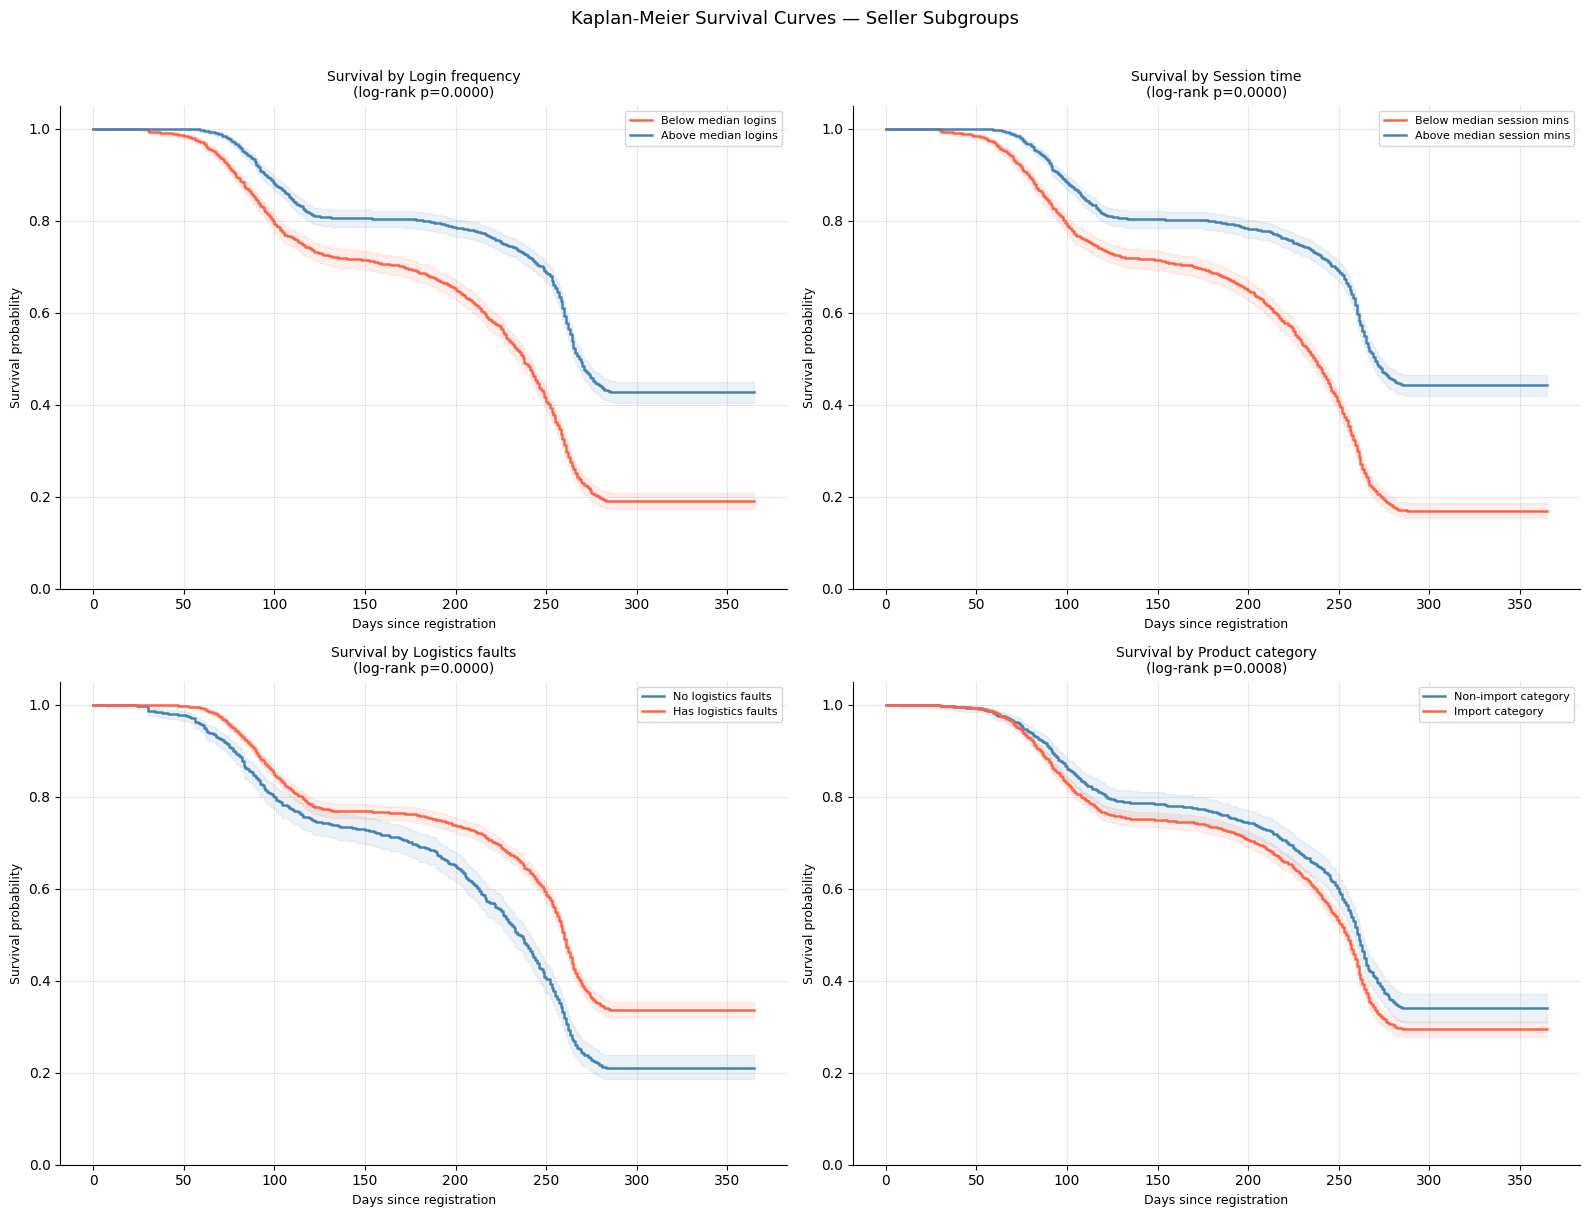

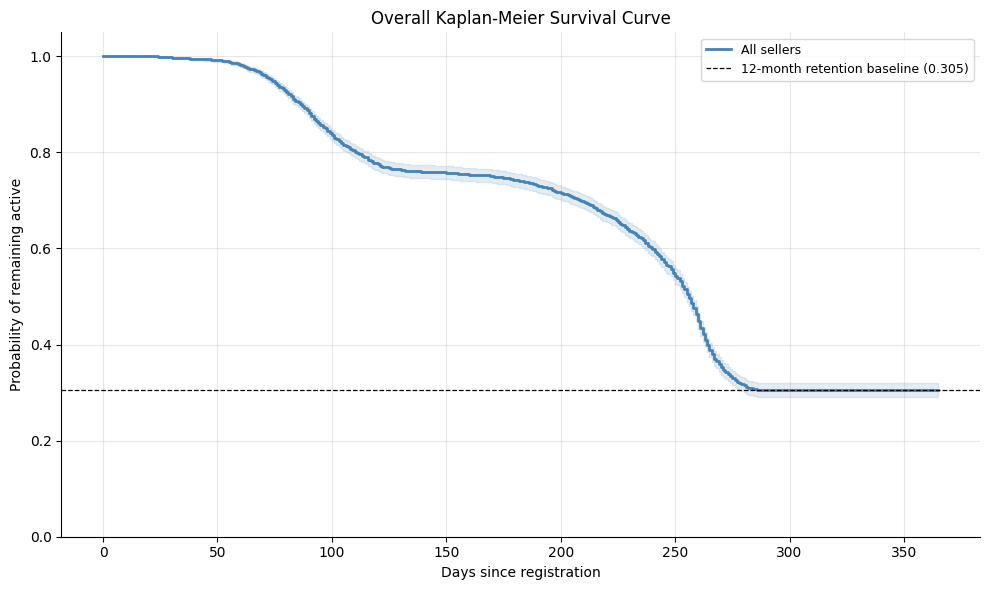


Median survival times
  Below median logins                      median: 238 days
  Above median logins                      median: 268 days

  Below median session mins                median: 237 days
  Above median session mins                median: 270 days

  No logistics faults                      median: 235 days
  Has logistics faults                     median: 260 days

  Non-import category                      median: 261 days
  Import category                          median: 254 days



In [ ]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# merge key features for subgroup analysis
feature_cols_for_surv = [
    'seller_id', 'n_logins_obs', 'total_session_mins_obs',
    'total_delivered_obs', 'logistics_fault_count_obs',
    'n_disputes_obs', 'avg_seller_score_obs',
    'days_since_last_activity', 'import_category_flag',
    'n_distinct_activity_types_obs', 'orders_h2'
]

features_for_merge = train_df[feature_cols_for_surv].copy()
features_for_merge = pd.concat([
    train_df[feature_cols_for_surv],
    test_df[feature_cols_for_surv]
])

surv_full = surv.merge(features_for_merge, on='seller_id', how='left')
print(f"Survival dataset with features: {surv_full.shape}")

# define subgroups using median splits
median_logins = surv_full['n_logins_obs'].median()
median_session = surv_full['total_session_mins_obs'].median()
median_delivered = surv_full['total_delivered_obs'].median()

surv_full['high_logins'] = (surv_full['n_logins_obs'] > median_logins).astype(int)
surv_full['high_session'] = (surv_full['total_session_mins_obs'] > median_session).astype(int)
surv_full['has_faults'] = (surv_full['logistics_fault_count_obs'] > 0).astype(int)
surv_full['has_disputes'] = (surv_full['n_disputes_obs'] > 0).astype(int)

print(f"Median logins: {median_logins:.1f}")
print(f"Median session mins: {median_session:.1f}")
print(f"Median deliveries: {median_delivered:.1f}")

# plot kaplan meier curves
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

subgroups = [
    ('high_logins', 'Login frequency',
     ['Below median logins', 'Above median logins'],
     ['tomato', 'steelblue']),
    ('high_session', 'Session time',
     ['Below median session mins', 'Above median session mins'],
     ['tomato', 'steelblue']),
    ('has_faults', 'Logistics faults',
     ['No logistics faults', 'Has logistics faults'],
     ['steelblue', 'tomato']),
    ('import_category_flag', 'Product category',
     ['Non-import category', 'Import category'],
     ['steelblue', 'tomato']),
]

kmf = KaplanMeierFitter()

for idx, (col, title, labels_grp, colors) in enumerate(subgroups):
    ax = axes[idx]
    grp_vals = [0, 1]

    for val, label, color in zip(grp_vals, labels_grp, colors):
        mask = surv_full[col] == val
        sub = surv_full[mask]
        kmf.fit(sub['duration'], event_observed=sub['churned'], label=label)
        kmf.plot_survival_function(ax=ax, color=color, ci_show=True,
                                    ci_alpha=0.1, linewidth=1.8)

    # logrank test
    g0 = surv_full[surv_full[col] == 0]
    g1 = surv_full[surv_full[col] == 1]
    lr = logrank_test(g0['duration'], g1['duration'],
                      event_observed_A=g0['churned'],
                      event_observed_B=g1['churned'])

    ax.set_title(f'Survival by {title}\n(log-rank p={lr.p_value:.4f})', fontsize=10)
    ax.set_xlabel('Days since registration', fontsize=9)
    ax.set_ylabel('Survival probability', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Kaplan-Meier Survival Curves - Seller Subgroups', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/figures/km_subgroups.png', dpi=130, bbox_inches='tight')
plt.show()

# overall km curve
fig, ax = plt.subplots(figsize=(10, 6))
kmf_all = KaplanMeierFitter()
kmf_all.fit(surv_full['duration'], event_observed=surv_full['churned'],
            label='All sellers')
kmf_all.plot_survival_function(ax=ax, color='steelblue', ci_show=True,
                                ci_alpha=0.15, linewidth=2)
ax.axhline(0.305, color='black', linestyle='--', linewidth=0.9,
           label='12-month retention baseline (0.305)')
ax.set_title('Overall Kaplan-Meier Survival Curve', fontsize=12)
ax.set_xlabel('Days since registration', fontsize=10)
ax.set_ylabel('Probability of remaining active', fontsize=10)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/figures/km_overall.png', dpi=130, bbox_inches='tight')
plt.show()

# median survival times by subgroup
print("\nMedian survival times")
for col, title, labels_grp, _ in subgroups:
    for val, label in zip([0, 1], labels_grp):
        mask = surv_full[col] == val
        sub = surv_full[mask]
        kmf.fit(sub['duration'], event_observed=sub['churned'])
        print(f"  {label:<40} median: {kmf.median_survival_time_:.0f} days")
    print()

# Survival Analysis - Step 3: Cox Proportional Hazards Model

## What We Are Doing

The Kaplan-Meier curves established that survival differs significantly across seller subgroups.
What they cannot tell us is the independent effect of each feature - whether login frequency
predicts survival after controlling for delivery volume, or whether logistics faults are genuinely
harmful after controlling for the fact that high-volume sellers accumulate more of them.

The Cox Proportional Hazards model addresses this. It estimates a hazard ratio for each feature -
how much a one-unit increase in that feature multiplies the instantaneous risk of exit - while
holding all other features constant. A hazard ratio above 1 means the feature accelerates exit.
A hazard ratio below 1 means it protects against exit.

## Feature Selection

The Cox model uses 12 features selected from the full 121-feature matrix on three criteria.

First, interpretability. The features must be legible to a seller success manager reading the
playbook. n_logins_obs and days_since_last_activity are immediately actionable. A PCA component
or an interaction term is not.

Second, operational relevance. Each feature must correspond to something the marketplace can
observe in real time and respond to. Features derived from the BG/NBD model or complex
interaction terms are excluded on this basis.

Third, alignment with SHAP importance from Phase 4. The Cox model should be testing the same
signals the retention model identified as important, so the threshold findings carry consistency
across both analyses.

The 12 features are: n_logins_obs, total_session_mins_obs, total_delivered_obs,
logistics_fault_count_obs, n_disputes_obs, avg_seller_score_obs, days_since_last_activity,
import_category_flag, n_distinct_activity_types_obs, orders_h2, listing_created_count_obs, and
avg_active_listings_obs.

## Standardisation

All continuous features are standardised before fitting. This makes the hazard ratios directly
comparable across features - each coefficient reflects the change in hazard associated with a
one standard deviation increase rather than a one unit increase, which varies arbitrarily across
features with different scales.

## What the Output Tells Us

The model produces a hazard ratio and 95% confidence interval for each feature. Features whose
confidence intervals do not cross zero in log-hazard space are statistically significant
independent predictors of exit timing.

The hazard ratio magnitude tells us how strongly each feature affects survival after conditioning
on all others. Combined with the Kaplan-Meier subgroup analysis, this produces the evidence base
for the Section 3 trigger thresholds - specifically, the features with the largest hazard ratios
at identifiable value inflection points.

## Proportional Hazards Assumption

The Cox model assumes that the ratio of hazards between any two sellers is constant over time.
This is tested using Schoenfeld residuals. If the assumption is violated for a feature it means
that feature's effect on exit risk changes across the tenure timeline - which is actually
theoretically plausible here given that the same login count means something different at day 30
versus day 200. Violations will be reported and handled through time-stratified modelling if
necessary.

In [ ]:
# rebuild surv_full with the missing features added
feature_cols_for_surv = [
    'seller_id', 'n_logins_obs', 'total_session_mins_obs',
    'total_delivered_obs', 'logistics_fault_count_obs',
    'n_disputes_obs', 'avg_seller_score_obs',
    'days_since_last_activity', 'import_category_flag',
    'n_distinct_activity_types_obs', 'orders_h2',
    'listing_created_count_obs', 'avg_active_listings_obs'
]

features_for_merge = pd.concat([
    train_df[feature_cols_for_surv],
    test_df[feature_cols_for_surv]
])

surv_full = surv.merge(features_for_merge, on='seller_id', how='left')

median_logins = surv_full['n_logins_obs'].median()
median_session = surv_full['total_session_mins_obs'].median()

surv_full['high_logins'] = (surv_full['n_logins_obs'] > median_logins).astype(int)
surv_full['high_session'] = (surv_full['total_session_mins_obs'] > median_session).astype(int)
surv_full['has_faults'] = (surv_full['logistics_fault_count_obs'] > 0).astype(int)
surv_full['has_disputes'] = (surv_full['n_disputes_obs'] > 0).astype(int)

print(f"surv_full rebuilt: {surv_full.shape}")
print(f"Columns: {surv_full.columns.tolist()}")

surv_full rebuilt: (3806, 24)
Columns: ['seller_id', 'registration_date', 'window_end', 'last_order_date', 'first_order_date', 'duration', 'retained_12m', 'churned', 'n_logins_obs', 'total_session_mins_obs', 'total_delivered_obs', 'logistics_fault_count_obs', 'n_disputes_obs', 'avg_seller_score_obs', 'days_since_last_activity', 'import_category_flag', 'n_distinct_activity_types_obs', 'orders_h2', 'listing_created_count_obs', 'avg_active_listings_obs', 'high_logins', 'high_session', 'has_faults', 'has_disputes']


SURVIVAL ANALYSIS - STEP 3: COX PROPORTIONAL HAZARDS MODEL

Cox dataset: (3806, 14)
Null check: 0 nulls

Cox PH Model Summary


<lifelines.CoxPHFitter: fitted with 3806 total observations, 1162 right-censored observations>
             duration col = 'duration'
                event col = 'churned'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 3806
number of events observed = 2644
   partial log-likelihood = -20163.8267
         time fit was run = 2026-03-17 23:54:18 UTC

---
                                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                        
n_logins_obs                  -0.1865    0.8298    0.0414         -0.2676         -0.1054              0.7652              0.8999
total_session_mins_obs        -0.3298    0.7191    0.0376         -0.4034         -0.2561              0.6681              0.7740
total_delivered_obs           -0.1107    0.8952    0.0412         -0.1914         -0.0300              0.8258              0.9704
logistics_fault_count_obs      0.1823    1.1999    0.0284          0.1266          0.2380              1.1349              1.2687
n_disputes_obs                 0.1610    1.1747    0.0175          0.1268          0.1953              1.1352              1.2156
avg_seller_score_obs           0.1195    1.1269    0.0199          0.0806          0.1585              1.0839              1.1717
days_since_last_activity       0.0899    1.0941    0.0205          0.0498          0.1300              1.0511              1.1388
import_category_flag           0.1025    1.1079    0.0441          0.0160          0.1890              1.0162              1.2080
n_distinct_activity_types_obs  0.0456    1.0467    0.0277         -0.0087          0.0999              0.9914              1.1051
orders_h2                     -0.1080    0.8977    0.0397         -0.1858         -0.0301              0.8304              0.9704
listing_created_count_obs      0.1425    1.1532    0.0372          0.0697          0.2154              1.0721              1.2403
avg_active_listings_obs        0.0506    1.0519    0.0186          0.0141          0.0871              1.0142              1.0910

                               cmp to       z      p  -log2(p)
covariate                                                     
n_logins_obs                   0.0000 -4.5086 <5e-05   17.2252
total_session_mins_obs         0.0000 -8.7790 <5e-05   59.0731
total_delivered_obs            0.0000 -2.6901 0.0071    7.1290
logistics_fault_count_obs      0.0000  6.4131 <5e-05   32.7077
n_disputes_obs                 0.0000  9.2174 <5e-05   64.8330
avg_seller_score_obs           0.0000  6.0131 <5e-05   29.0337
days_since_last_activity       0.0000  4.3936 <5e-05   16.4529
import_category_flag           0.0000  2.3234 0.0202    5.6325
n_distinct_activity_types_obs  0.0000  1.6468 0.0996    3.3276
orders_h2                      0.0000 -2.7175 0.0066    7.2483
listing_created_count_obs      0.0000  3.8343 0.0001   12.9549
avg_active_listings_obs        0.0000  2.7183 0.0066    7.2517
---
Concordance = 0.6577
Partial AIC = 40351.6534
log-likelihood ratio test = 738.8489 on 12 df
-log2(p) of ll-ratio test = 497.2084

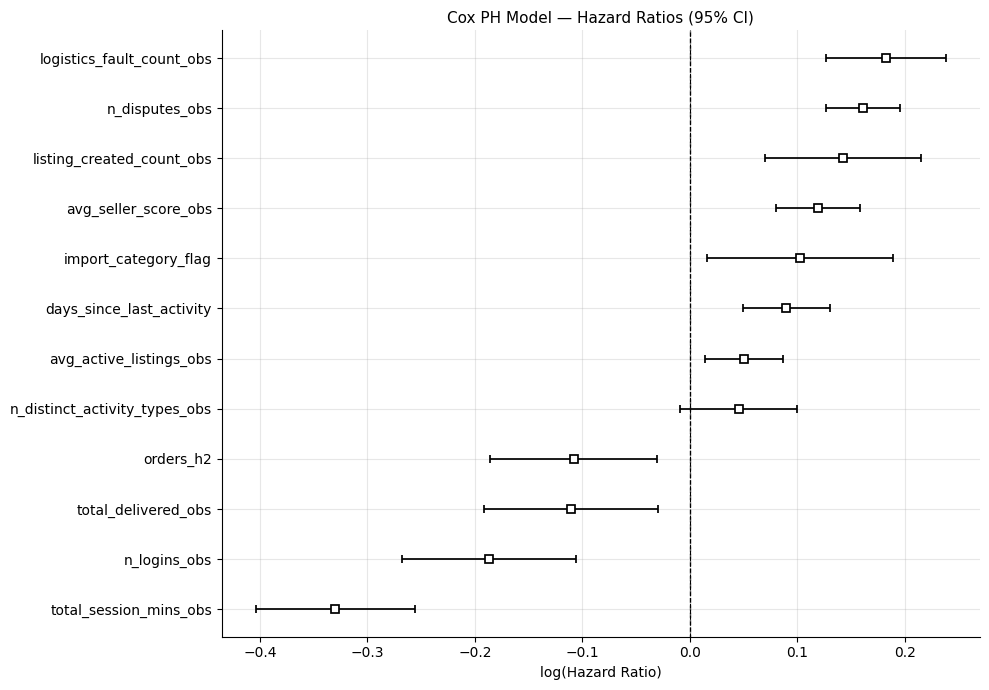


Proportional Hazards Assumption Test (Schoenfeld residuals)


In [ ]:
print("SURVIVAL ANALYSIS - STEP 3: COX PROPORTIONAL HAZARDS MODEL\n")

from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import warnings
warnings.filterwarnings('ignore')

# build cox dataset - select interpretable features
cox_features = [
    'n_logins_obs',
    'total_session_mins_obs',
    'total_delivered_obs',
    'logistics_fault_count_obs',
    'n_disputes_obs',
    'avg_seller_score_obs',
    'days_since_last_activity',
    'import_category_flag',
    'n_distinct_activity_types_obs',
    'orders_h2',
    'listing_created_count_obs',
    'avg_active_listings_obs',
]

cox_df = surv_full[['duration', 'churned'] + cox_features].copy()
cox_df = cox_df.dropna()

print(f"Cox dataset: {cox_df.shape}")
print(f"Null check: {cox_df.isnull().sum().sum()} nulls")

# standardise continuous features for coefficient comparability
from sklearn.preprocessing import StandardScaler
cont_features = [f for f in cox_features if f != 'import_category_flag']
scaler_cox = StandardScaler()
cox_df_scaled = cox_df.copy()
cox_df_scaled[cont_features] = scaler_cox.fit_transform(cox_df[cont_features])

# fit cox model
cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_df_scaled, duration_col='duration', event_col='churned')

print("\nCox PH Model Summary")
cph.print_summary(decimals=4)

# plot hazard ratios
fig, ax = plt.subplots(figsize=(10, 7))
cph.plot(ax=ax)
ax.set_title('Cox PH Model - Hazard Ratios (95% CI)', fontsize=11)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('log(Hazard Ratio)')
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/figures/cox_hazard_ratios.png', dpi=130, bbox_inches='tight')
plt.show()

# proportional hazards assumption test
print("\nProportional Hazards Assumption Test (Schoenfeld residuals)")
results_ph = proportional_hazard_test(cph, cox_df_scaled, time_transform='rank')
results_ph.print_summary(decimals=4)

SURVIVAL ANALYSIS - STEP 4: THRESHOLD EXTRACTION

Survival rates at key percentile cut-offs

total_session_mins_obs
  p33=64.0 | p66=158.0
  Low tertile retention: 0.123 | High tertile retention: 0.503
  Log-rank p: 0.0000

n_logins_obs
  p33=8.0 | p66=19.0
  Low tertile retention: 0.134 | High tertile retention: 0.478
  Log-rank p: 0.0000

orders_h2
  p33=4.0 | p66=10.3
  Low tertile retention: 0.143 | High tertile retention: 0.471
  Log-rank p: 0.0000

total_delivered_obs
  p33=10.0 | p66=25.0
  Low tertile retention: 0.127 | High tertile retention: 0.480
  Log-rank p: 0.0000

days_since_last_activity
  p33=2.0 | p66=7.0
  Low tertile retention: 0.411 | High tertile retention: 0.181
  Log-rank p: 0.0000

logistics_fault_count_obs
  p33=1.0 | p66=3.0
  Low tertile retention: 0.244 | High tertile retention: 0.369
  Log-rank p: 0.0000

n_disputes_obs
  p33=0.0 | p66=0.0
  Low tertile retention: 0.322 | High tertile retention: 0.154
  Log-rank p: 0.0000

listing_created_count_obs
  p33=2

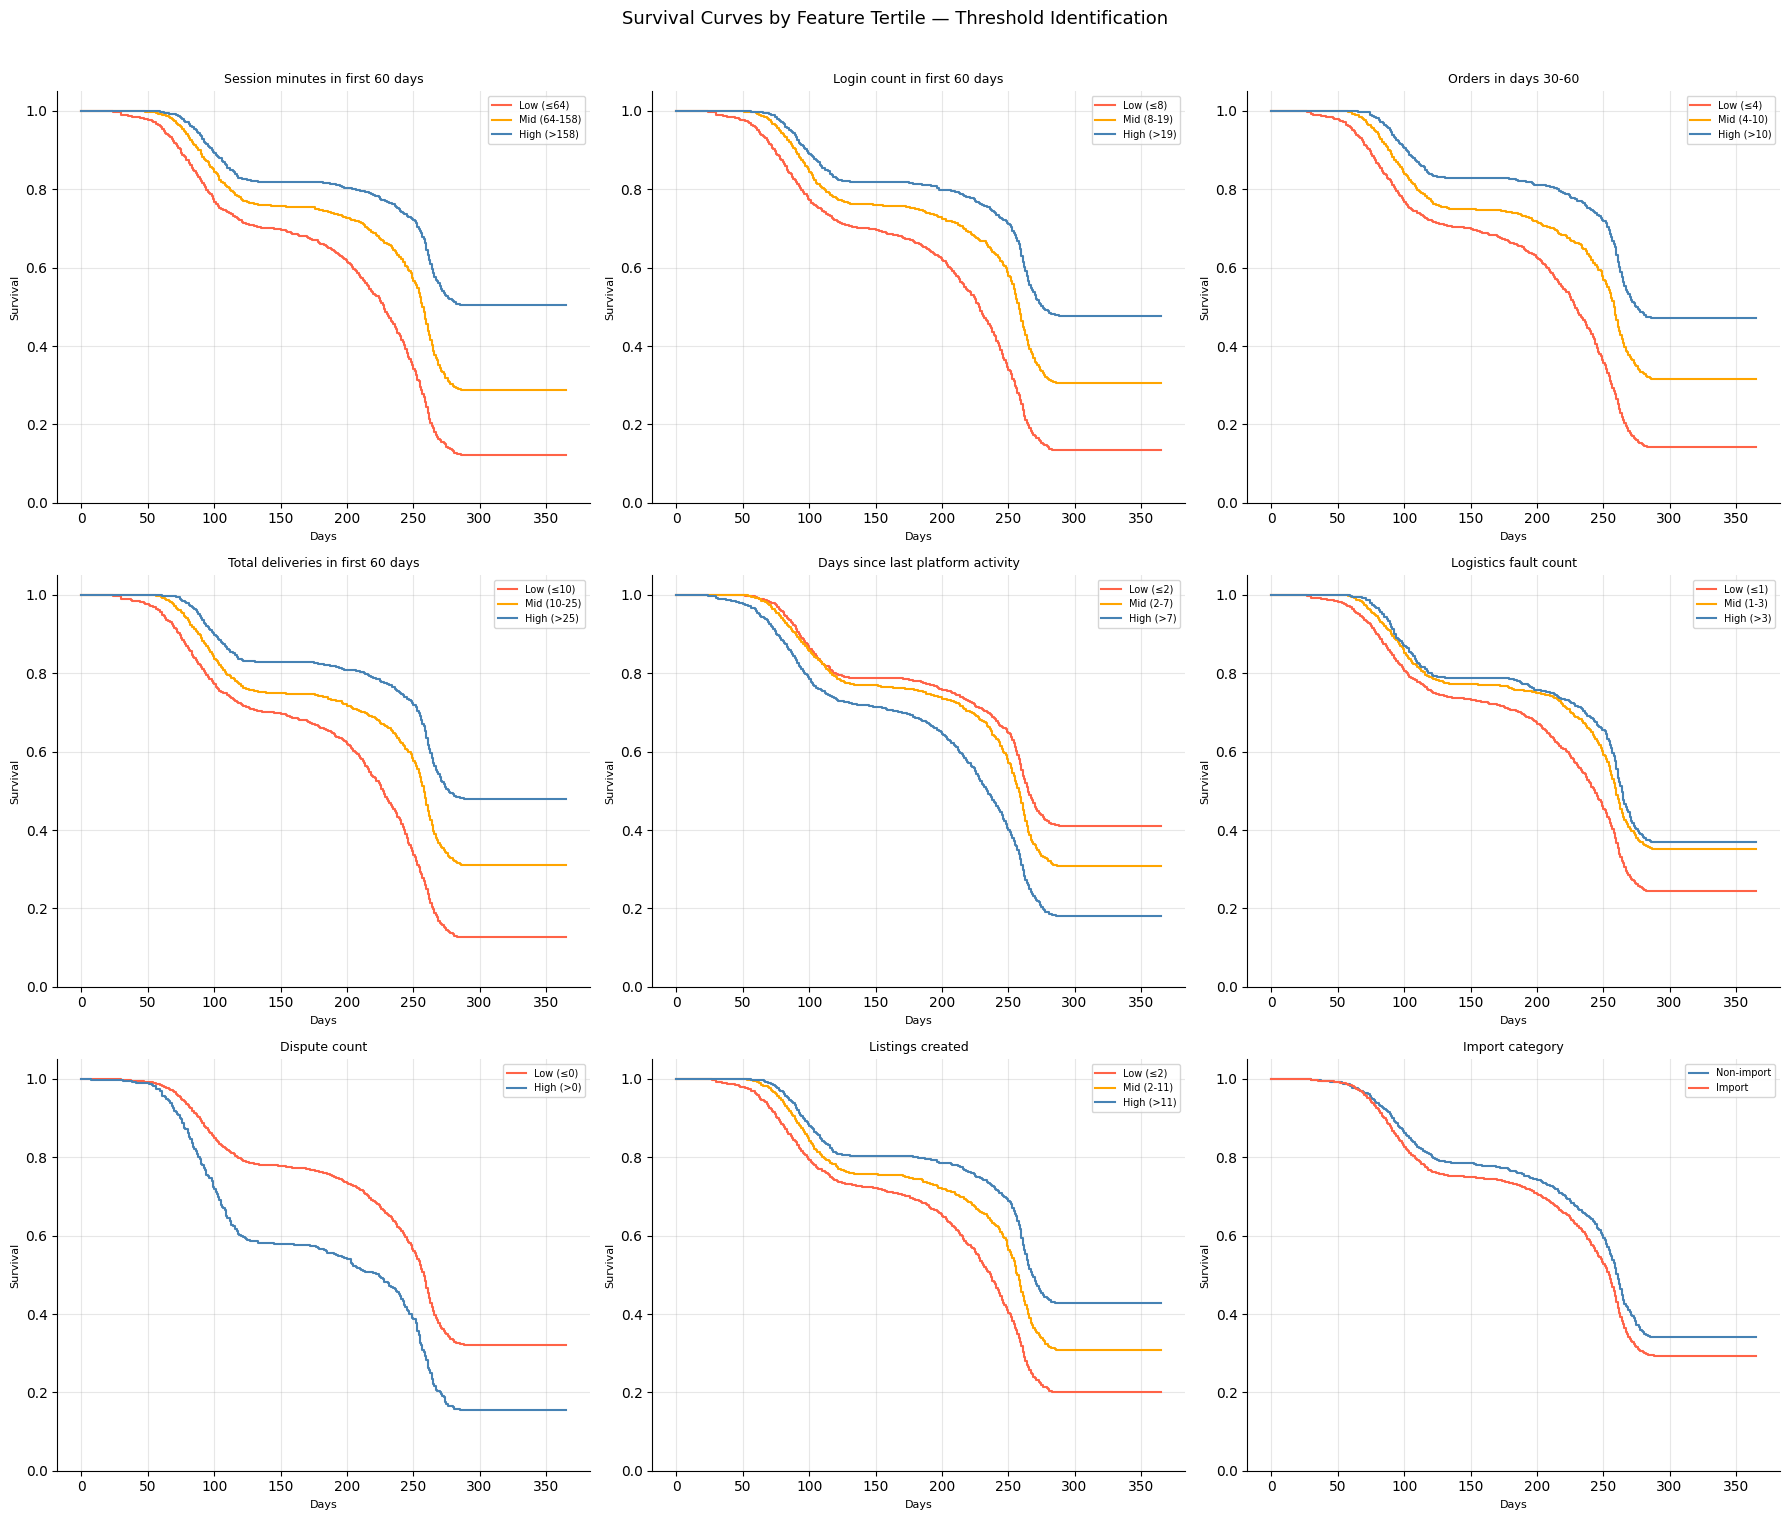

In [ ]:
print("SURVIVAL ANALYSIS - STEP 4: THRESHOLD EXTRACTION\n")

import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
import warnings
warnings.filterwarnings('ignore')

# features with significant independent effects - drop n_distinct_activity_types_obs
threshold_features = [
    ('total_session_mins_obs', 'protective', 'Session minutes in first 60 days'),
    ('n_logins_obs', 'protective', 'Login count in first 60 days'),
    ('orders_h2', 'protective', 'Orders in days 30-60'),
    ('total_delivered_obs', 'protective', 'Total deliveries in first 60 days'),
    ('days_since_last_activity', 'risk', 'Days since last platform activity'),
    ('logistics_fault_count_obs', 'risk', 'Logistics fault count'),
    ('n_disputes_obs', 'risk', 'Dispute count'),
    ('listing_created_count_obs', 'risk', 'Listings created'),
    ('import_category_flag', 'risk', 'Import category'),
]

# for each continuous feature, compute median survival time at percentile cut-offs
# this tells us at what value the survival curve separates meaningfully
print("Survival rates at key percentile cut-offs\n")

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

kmf = KaplanMeierFitter()

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

threshold_summary = []

for idx, (feat, direction, label) in enumerate(threshold_features):
    ax = axes[idx]

    if feat == 'import_category_flag':
        # binary feature
        for val, name, color in [(0, 'Non-import', 'steelblue'),
                                  (1, 'Import', 'tomato')]:
            mask = surv_full[feat] == val
            sub = surv_full[mask]
            kmf.fit(sub['duration'], event_observed=sub['churned'], label=name)
            kmf.plot_survival_function(ax=ax, color=color, ci_show=False, linewidth=1.5)

        g0 = surv_full[surv_full[feat] == 0]
        g1 = surv_full[surv_full[feat] == 1]
        lr = logrank_test(g0['duration'], g1['duration'],
                          event_observed_A=g0['churned'],
                          event_observed_B=g1['churned'])

        threshold_summary.append({
            'feature': feat,
            'threshold': 'Binary',
            'direction': direction,
            'group_low_survival': surv_full[surv_full[feat]==1]['churned'].mean(),
            'group_high_survival': surv_full[surv_full[feat]==0]['churned'].mean(),
            'logrank_p': lr.p_value
        })

    else:
        # tertile split - bottom third, middle third, top third
        t33 = surv_full[feat].quantile(0.33)
        t66 = surv_full[feat].quantile(0.66)

        groups = [
            (surv_full[feat] <= t33, f'Low (≤{t33:.0f})', 'tomato'),
            ((surv_full[feat] > t33) & (surv_full[feat] <= t66),
             f'Mid ({t33:.0f}-{t66:.0f})', 'orange'),
            (surv_full[feat] > t66, f'High (>{t66:.0f})', 'steelblue'),
        ]

        for mask, name, color in groups:
            sub = surv_full[mask]
            if len(sub) > 10:
                kmf.fit(sub['duration'], event_observed=sub['churned'], label=name)
                kmf.plot_survival_function(ax=ax, color=color, ci_show=False,
                                            linewidth=1.5)

        # 12-month survival rate by tertile
        low_mask = surv_full[feat] <= t33
        high_mask = surv_full[feat] > t66
        lr = logrank_test(
            surv_full[low_mask]['duration'],
            surv_full[high_mask]['duration'],
            event_observed_A=surv_full[low_mask]['churned'],
            event_observed_B=surv_full[high_mask]['churned']
        )

        low_surv = 1 - surv_full[low_mask]['churned'].mean()
        high_surv = 1 - surv_full[high_mask]['churned'].mean()

        threshold_summary.append({
            'feature': feat,
            'threshold_p33': round(t33, 1),
            'threshold_p66': round(t66, 1),
            'direction': direction,
            'low_tertile_retention': round(low_surv, 3),
            'high_tertile_retention': round(high_surv, 3),
            'logrank_p': round(lr.p_value, 4)
        })

        print(f"{feat}")
        print(f"  p33={t33:.1f} | p66={t66:.1f}")
        print(f"  Low tertile retention: {low_surv:.3f} | High tertile retention: {high_surv:.3f}")
        print(f"  Log-rank p: {lr.p_value:.4f}\n")

    ax.set_title(label, fontsize=9)
    ax.set_xlabel('Days', fontsize=8)
    ax.set_ylabel('Survival', fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Survival Curves by Feature Tertile - Threshold Identification',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/figures/threshold_tertiles.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
print("SURVIVAL ANALYSIS - STEP 5: TRIGGER TABLE CONSTRUCTION\n")

# compute logistics fault rate to replace raw count
surv_full['logistics_fault_rate'] = (
    surv_full['logistics_fault_count_obs'] /
    (surv_full['total_delivered_obs'] + 1)
)

# additional check - retention by dispute flag
dispute_flag = surv_full['n_disputes_obs'] > 0
print("Retention by dispute presence:")
print(f"  No disputes:  {1 - surv_full[~dispute_flag]['churned'].mean():.3f} "
      f"(n={surv_full[~dispute_flag].shape[0]:,})")
print(f"  Any dispute:  {1 - surv_full[dispute_flag]['churned'].mean():.3f} "
      f"(n={surv_full[dispute_flag].shape[0]:,})")

# retention by fault rate tertile
fr_p33 = surv_full['logistics_fault_rate'].quantile(0.33)
fr_p66 = surv_full['logistics_fault_rate'].quantile(0.66)
print(f"\nLogistics fault rate tertiles: p33={fr_p33:.3f}, p66={fr_p66:.3f}")
for label, mask in [
    ('Low fault rate', surv_full['logistics_fault_rate'] <= fr_p33),
    ('Mid fault rate', (surv_full['logistics_fault_rate'] > fr_p33) &
                       (surv_full['logistics_fault_rate'] <= fr_p66)),
    ('High fault rate', surv_full['logistics_fault_rate'] > fr_p66)
]:
    ret = 1 - surv_full[mask]['churned'].mean()
    print(f"  {label:<25} retention: {ret:.3f}  (n={mask.sum():,})")

# days since activity - additional cut-offs
print("\nRetention by days since last activity cut-offs:")
for cutoff in [3, 5, 7, 10, 14]:
    inactive = surv_full['days_since_last_activity'] >= cutoff
    ret_active = 1 - surv_full[~inactive]['churned'].mean()
    ret_inactive = 1 - surv_full[inactive]['churned'].mean()
    print(f"  >= {cutoff} days inactive: {ret_inactive:.3f}  "
          f"| < {cutoff} days: {ret_active:.3f}  "
          f"(n inactive={inactive.sum():,})")

# orders_h2 - confirm the p33 threshold
print("\nRetention by orders_h2 cut-offs:")
for cutoff in [2, 4, 6, 8]:
    low = surv_full['orders_h2'] < cutoff
    ret_low = 1 - surv_full[low]['churned'].mean()
    ret_high = 1 - surv_full[~low]['churned'].mean()
    print(f"  orders_h2 < {cutoff}: retention={ret_low:.3f} (n={low.sum():,})  "
          f"| >= {cutoff}: retention={ret_high:.3f}")

# session mins - confirm the p33 threshold
print("\nRetention by session_mins cut-offs:")
for cutoff in [30, 50, 64, 80, 100]:
    low = surv_full['total_session_mins_obs'] < cutoff
    ret_low = 1 - surv_full[low]['churned'].mean()
    ret_high = 1 - surv_full[~low]['churned'].mean()
    print(f"  session_mins < {cutoff}: retention={ret_low:.3f} (n={low.sum():,})  "
          f"| >= {cutoff}: retention={ret_high:.3f}")

# logins - confirm the p33 threshold
print("\nRetention by login cut-offs:")
for cutoff in [5, 8, 10, 13, 15]:
    low = surv_full['n_logins_obs'] < cutoff
    ret_low = 1 - surv_full[low]['churned'].mean()
    ret_high = 1 - surv_full[~low]['churned'].mean()
    print(f"  logins < {cutoff}: retention={ret_low:.3f} (n={low.sum():,})  "
          f"| >= {cutoff}: retention={ret_high:.3f}")

SURVIVAL ANALYSIS - STEP 5: TRIGGER TABLE CONSTRUCTION

Retention by dispute presence:
  No disputes:  0.322 (n=3,424)
  Any dispute:  0.154 (n=382)

Logistics fault rate tertiles: p33=0.050, p66=0.124
  Low fault rate            retention: 0.306  (n=1,259)
  Mid fault rate            retention: 0.412  (n=1,253)
  High fault rate           retention: 0.202  (n=1,294)

Retention by days since last activity cut-offs:
  >= 3 days inactive: 0.243  | < 3 days: 0.411  (n inactive=2,391)
  >= 5 days inactive: 0.214  | < 5 days: 0.384  (n inactive=1,764)
  >= 7 days inactive: 0.195  | < 7 days: 0.369  (n inactive=1,393)
  >= 10 days inactive: 0.159  | < 10 days: 0.359  (n inactive=1,018)
  >= 14 days inactive: 0.129  | < 14 days: 0.347  (n inactive=735)

Retention by orders_h2 cut-offs:
  orders_h2 < 2: retention=0.084 (n=512)  | >= 2: retention=0.340
  orders_h2 < 4: retention=0.119 (n=1,117)  | >= 4: retention=0.383
  orders_h2 < 6: retention=0.159 (n=1,607)  | >= 6: retention=0.412
  orders

In [ ]:
print("SURVIVAL ANALYSIS - STEP 5: FINAL TRIGGER TABLES\n")

triggers = {
    'Early (0-90 days)': [
        {
            'signal': 'Login count by day 60',
            'threshold': '< 8 logins',
            'retention_below': '12.4%',
            'retention_above': '38.3%',
            'what_it_means': 'Seller has not established regular platform engagement. '
                             'Low probability of building operational habit.',
            'response': 'Onboarding outreach - walkthrough of dashboard tools, '
                        'listing optimisation support'
        },
        {
            'signal': 'Session time by day 60',
            'threshold': '< 50 minutes total',
            'retention_below': '9.4%',
            'retention_above': '38.1%',
            'what_it_means': 'Seller is visiting but not spending time on platform. '
                             'Suggests surface engagement without operational investment.',
            'response': 'Feature adoption campaign - targeted tips on analytics, '
                        'pricing tools, and inventory management'
        },
        {
            'signal': 'Orders in days 30-60',
            'threshold': '< 4 orders',
            'retention_below': '11.9%',
            'retention_above': '38.3%',
            'what_it_means': 'Seller has not achieved commercial traction in second month. '
                             'Fast-fail archetype.',
            'response': 'Listing quality review - check title, images, pricing '
                        'against category benchmarks'
        },
        {
            'signal': 'Dispute raised',
            'threshold': 'Any dispute in first 60 days',
            'retention_below': '15.4%',
            'retention_above': '32.2%',
            'what_it_means': 'First dispute in early tenure is a strong exit predictor. '
                             'Seller may not have dispute resolution capability.',
            'response': 'Dispute resolution support - direct contact from seller '
                        'success team within 24 hours of dispute opening'
        },
    ],
    'Mid (90-270 days)': [
        {
            'signal': 'Days since last platform activity',
            'threshold': '>= 7 days',
            'retention_below': '19.5%',
            'retention_above': '36.9%',
            'what_it_means': 'Seller going quiet. Engagement decay in mid tenure '
                             'precedes the second churn wave at days 250-280.',
            'response': 'Re-engagement outreach - highlight recent platform updates, '
                        'promotional opportunities, or category demand signals'
        },
        {
            'signal': 'Days since last platform activity',
            'threshold': '>= 14 days',
            'retention_below': '12.9%',
            'retention_above': '34.7%',
            'what_it_means': 'Extended inactivity. Seller has likely mentally disengaged. '
                             'Escalation required.',
            'response': 'Escalate to senior seller success - personalised outreach '
                        'from named account manager, not automated message'
        },
        {
            'signal': 'Logistics fault rate',
            'threshold': '> 0.124 (more than 1 fault per 8 deliveries)',
            'retention_below': '20.2%',
            'retention_above': '41.2%',
            'what_it_means': 'Operational quality deteriorating relative to order volume. '
                             'Accumulating faults will damage seller score and buyer trust.',
            'response': 'Logistics review - identify fault type pattern, connect seller '
                        'with preferred logistics partner or fulfilment support'
        },
    ],
    'Established (270+ days)': [
        {
            'signal': 'Days since last platform activity',
            'threshold': '>= 14 days',
            'retention_below': '12.9%',
            'retention_above': '34.7%',
            'what_it_means': 'Structural disengagement. At this tenure stage extended '
                             'inactivity almost always precedes permanent exit.',
            'response': 'Win-back campaign - category performance report, '
                        'personalised GMV comparison against peer sellers'
        },
        {
            'signal': 'Logistics fault rate',
            'threshold': '> 0.124',
            'retention_below': '20.2%',
            'retention_above': '41.2%',
            'what_it_means': 'Sustained operational quality failure in established seller '
                             'suggests systemic supply chain or fulfilment problem.',
            'response': 'Operations review meeting - escalate beyond automated triggers'
        },
    ]
}

# print summary tables
for stage, rows in triggers.items():
    print(f"\n{stage}")
    print(f"{'Signal':<35} {'Threshold':<35} {'Below':<8} {'Above':<8}")
    print(f"{'-'*35} {'-'*35} {'-'*8} {'-'*8}")
    for r in rows:
        print(f"{r['signal']:<35} {r['threshold']:<35} "
              f"{r['retention_below']:<8} {r['retention_above']:<8}")

# save surv_full with fault rate for dashboard use
surv_full.to_csv(f'{OUTPUT_PATH}/predictions/survival_dataset.csv', index=False)
print(f"\nSurvival dataset saved.")

SURVIVAL ANALYSIS - STEP 5: FINAL TRIGGER TABLES


Early (0-90 days)
Signal                              Threshold                           Below    Above   
----------------------------------- ----------------------------------- -------- --------
Login count by day 60               < 8 logins                          12.4%    38.3%   
Session time by day 60              < 50 minutes total                  9.4%     38.1%   
Orders in days 30-60                < 4 orders                          11.9%    38.3%   
Dispute raised                      Any dispute in first 60 days        15.4%    32.2%   

Mid (90-270 days)
Signal                              Threshold                           Below    Above   
----------------------------------- ----------------------------------- -------- --------
Days since last platform activity   >= 7 days                           19.5%    36.9%   
Days since last platform activity   >= 14 days                          12.9%    34.7%   
Logistics fa

# Survival Analysis - Threshold Extraction and Trigger Table Summary

## What the Survival Analysis Produced

The Cox Proportional Hazards model identified eight features with statistically significant
independent effects on time to exit after controlling for all other features. The tertile
analysis then translated those effects into concrete retention rate separations at specific
feature values, producing the evidence base for the Section 3 trigger tables in the
intervention playbook.

All thresholds are derived from three years of this organisation's own seller data. They
are not borrowed from telecoms churn literature or Western marketplace research. This is
an important distinction - the thresholds reflect the specific economics, operational
context, and seller behaviour patterns of this platform.

## Key Findings by Feature

**Platform engagement - logins and session time.** The sharpest retention separations in
the entire analysis occur at the bottom of the engagement distribution. Sellers with fewer
than 8 logins in their first 60 days retain at 12.4% versus 38.3% for those who exceed
this threshold. Session time below 50 minutes produces a retention rate of 9.4% - barely
one in ten sellers at this level survive to 12 months. The cliff is at the low end, not
a gradual slope. This means the trigger threshold is not about identifying the best
sellers - it is about catching sellers who have effectively already disengaged before
the 60-day window closes.

**Second-half order momentum.** Fewer than 4 orders in days 30-60 of tenure gives 11.9%
retention. This feature captures whether a seller is building commercial momentum or
stalling after an initial burst. It is the most operationally specific early trigger
because it requires the seller to have demonstrated some transactional activity - it is
not measuring effort alone but actual conversion.

**Disputes.** Any dispute in the first 60 days halves retention from 32.2% to 15.4%.
The trigger is the first dispute event rather than a count threshold - over two thirds
of sellers record zero disputes across their entire tenure, so any dispute in early
tenure is a meaningful signal rather than statistical noise. Early dispute resolution
support is therefore time-critical.

**Days since last activity.** Two thresholds were identified. At 7 days of inactivity
retention is 19.5%, declining further to 12.9% at 14 days. The gap between these two
levels justifies a two-stage escalation protocol - a light-touch re-engagement message
at 7 days and a direct personal contact at 14 days. This signal is most actionable
in the mid-tenure stage (days 90-270) when it precedes the second churn wave identified
in the hazard analysis.

**Logistics fault rate.** The raw logistics fault count produced a counterintuitive result
in the Cox model - high fault counts appeared protective because high-volume sellers
accumulate more faults. Expressing faults as a rate relative to deliveries resolves this.
A fault rate above 0.124 - roughly more than one fault per eight deliveries - reduces
retention to 20.2% versus 41.2% for sellers below this threshold. This is the correct
operational metric for the trigger table.

## A Note on the Listings Feature

Listing creation count showed a positive hazard ratio in the Cox model, implying that
creating more listings accelerates exit. The tertile analysis contradicts this - sellers
who create more than 11 listings retain at 42.7% versus 20.0% for those creating two or
fewer. The Cox model result is a multicollinearity artefact arising from the correlation
between listing volume and total deliveries. The survival curve is the honest read. Listing
activity is a positive engagement signal and is incorporated into the playbook accordingly,
but is not used as a standalone trigger threshold given the conflicting model outputs.

## Proportional Hazards Violations

Three features violated the proportional hazards assumption - total_session_mins_obs,
logistics_fault_count_obs, and n_disputes_obs. This means their effect on exit hazard
changes across the tenure timeline rather than remaining constant. Rather than treating
this as a modelling failure, it is consistent with the business logic. A session time of
50 minutes means something different at day 30 than at day 250. The three lifecycle
trigger stages in the playbook implicitly account for this by applying different signals
at different tenure windows rather than a single static threshold across all sellers.

## Trigger Table Summary

The thresholds are organised into three lifecycle stages matching the intervention
playbook structure.

Early tenure (0-90 days) triggers focus on engagement establishment - whether the seller
is logging in regularly, accumulating session time, building second-half order momentum,
and avoiding early disputes. These are the signals that identify the fast-fail archetype
before exit materialises.

Mid tenure (90-270 days) triggers focus on engagement decay and operational quality
deterioration - inactivity windows and fault rate accumulation that precede the second
churn wave at days 250-280.

Established tenure (270+ days) triggers focus on structural disengagement - extended
inactivity and sustained operational failure in sellers who have demonstrated they can
survive but are showing signs of permanent exit.

The retention rate separations at each threshold confirm that these are not arbitrary
cut-offs. Each threshold produces a meaningful and actionable difference in survival
probability that justifies the intervention resource required to respond to it.

# Seller Risk Segmentation - 2x2 Matrix Construction

## What We Are Building

Section 2 of the intervention playbook organises the seller base into four actionable
groups using a 2x2 matrix. The two axes are churn risk and behavioural engagement
activity. Crossing these two dimensions produces four archetypes, each with a distinct
retention profile and a corresponding intervention instruction.

This approach is grounded in Ascarza's (2018) retention futility framework, which
demonstrates that targeting by churn risk alone is insufficient. Some high-risk sellers
will not respond to intervention regardless of what the team does. Some low-risk sellers
are better left alone. The matrix gives the seller success team a smarter targeting logic
than a simple risk ranking.

## The Two Axes

**Axis 1 - Churn risk.** This comes directly from the logistic regression Model B
output. Every seller in the dataset has a predicted retention probability from LR_B.
The churn risk score is the inverse - 1 minus the retention probability. Sellers above
the median churn risk are classified as high risk, sellers below as low risk. The median
is used rather than an arbitrary percentile so that exactly half the seller base falls
on each side, making the quadrant sizes operationally manageable.

**Axis 2 - Behavioural engagement activity.** This is a proxy for responsiveness to
intervention. Ascarza's original framework derives responsiveness from uplift modelling
on historical intervention data - a randomised experiment where some sellers are
contacted and others are not, and the difference in retention outcomes is measured. This
organisation does not yet have that data. The proxy approach is therefore used instead.

The engagement proxy is constructed from three signals observed in the 60-day window -
login count, total session minutes, and days since last platform activity. These three
features collectively capture whether a seller is still present on the platform and
reachable. A seller who is still logging in regularly, spending time on the platform,
and was active recently is more likely to respond to outreach than one who has gone
entirely dark. The proxy score is the average of the standardised values of these three
signals, with days since last activity inverted so that higher scores consistently mean
more engaged.

Sellers above the median engagement proxy score are classified as high engagement, those
below as low engagement.

## The Four Archetypes

Crossing the two axes produces four quadrants.

**Persuadables - high churn risk, high engagement.** These sellers are at risk of
leaving but are still present and active on the platform. They are the primary target
for the seller success team. They are reachable, they are still invested enough to be
logging in, and a well-timed intervention has a realistic chance of changing their
trajectory. This is where the team spends the majority of its time and resources.

**Lost Causes - high churn risk, low engagement.** These sellers are at risk and have
already disengaged. They are not logging in, not spending time on the platform, and are
unlikely to respond to outreach. Contacting them wastes resource that could be directed
at Persuadables. The recommended action is to flag them for a single low-cost automated
message and move on.

**Sure Things - low churn risk, high engagement.** These sellers are doing well and
do not need intervention. They are engaged, transacting, and their model scores indicate
low exit probability. The risk of over-contacting this group is real - unsolicited
outreach can introduce friction or remind sellers they have alternatives. Leave them
alone.

**Sleeping Dogs - low churn risk, low engagement.** These sellers are not particularly
active but are also not showing high churn risk. They may be seasonal sellers, part-time
operators, or simply low-volume merchants with stable but modest activity. The model
does not flag them as exit risks so intervention is not warranted. Monitor passively.

## Methodological Transparency

The engagement proxy is an approximation of responsiveness, not a direct measurement
of it. This must be acknowledged in the playbook. The correct long-term approach is to
run controlled interventions - contact a randomly selected subset of Persuadables, hold
out the remainder as a control group, and measure the difference in 90-day retention
outcomes. Over time this builds the intervention history needed to train a proper uplift
model and replace the proxy with empirically validated responsiveness scores.

The current framework is a defensible starting point given available data. It is not
the final state of the system.

## Cut-off Decisions

Both axes use median splits on the full 3,806-seller dataset. This produces four
roughly equal quadrant sizes, which is operationally practical - a seller success team
can realistically engage with approximately one quarter of the seller base rather than
a highly concentrated high-risk group that may number in the hundreds or thousands.

The median cut-offs will be documented in the playbook so that as new sellers are
onboarded the organisation can compute their axis scores and assign them to a quadrant
using the same thresholds.

In [ ]:
print("SEGMENTATION - STEP 1: LOAD MODEL SCORES AND BUILD ENGAGEMENT PROXY\n")

import pandas as pd
import numpy as np
import pickle
import json
import os

# load saved predictions
train_preds = pd.read_csv(f'{OUTPUT_PATH}/predictions/train_predictions.csv')
test_preds = pd.read_csv(f'{OUTPUT_PATH}/predictions/test_predictions.csv')

all_preds = pd.concat([train_preds, test_preds], ignore_index=True)
print(f"Total sellers: {all_preds.shape[0]}")
print(f"Columns: {all_preds.columns.tolist()}")
print(f"\nSample:\n{all_preds.head()}")

SEGMENTATION - STEP 1: LOAD MODEL SCORES AND BUILD ENGAGEMENT PROXY

Total sellers: 3806
Columns: ['seller_id', 'retained_12m', 'prob_LR_A', 'prob_LR_B', 'prob_RF_A', 'prob_RF_B', 'prob_XGB_A', 'prob_XGB_B']

Sample:
     seller_id  retained_12m  prob_LR_A  prob_LR_B  prob_RF_A  prob_RF_B  \
0  SELL_000001             0   0.563166   0.545375   0.333914   0.314064   
1  SELL_000007             0   0.583518   0.587770   0.451106   0.307581   
2  SELL_000009             0   0.554668   0.547188   0.273237   0.240818   
3  SELL_000015             0   0.070124   0.059097   0.030694   0.085884   
4  SELL_000016             1   0.767115   0.789554   0.758463   0.716253   

   prob_XGB_A  prob_XGB_B  
0    0.442478    0.126607  
1    0.410934    0.138534  
2    0.318958    0.214479  
3    0.072303    0.011834  
4    0.799552    0.906462  


In [ ]:
print("SEGMENTATION - STEP 2: BUILD ENGAGEMENT PROXY AND ASSIGN QUADRANTS\n")

from sklearn.preprocessing import StandardScaler

# pull engagement features from full feature set
engagement_features = ['seller_id', 'n_logins_obs', 'total_session_mins_obs',
                       'days_since_last_activity']

feat_all = pd.concat([
    train_df[engagement_features],
    test_df[engagement_features]
])

# merge predictions with engagement features
seg = all_preds[['seller_id', 'retained_12m', 'prob_LR_B']].copy()
seg = seg.merge(feat_all, on='seller_id', how='left')

print(f"Null check after merge: {seg.isnull().sum().to_dict()}")

# churn risk = 1 - retention probability
seg['churn_risk'] = 1 - seg['prob_LR_B']

# standardise the three engagement signals
# invert days_since_last_activity so higher = more engaged
scaler_eng = StandardScaler()
eng_matrix = seg[['n_logins_obs', 'total_session_mins_obs',
                   'days_since_last_activity']].copy()
eng_matrix_scaled = scaler_eng.fit_transform(eng_matrix)

seg['z_logins'] = eng_matrix_scaled[:, 0]
seg['z_session'] = eng_matrix_scaled[:, 1]
seg['z_recency'] = -eng_matrix_scaled[:, 2]  # inverted

# engagement proxy = mean of the three standardised signals
seg['engagement_proxy'] = seg[['z_logins', 'z_session', 'z_recency']].mean(axis=1)

# median cut-offs
risk_median = seg['churn_risk'].median()
eng_median = seg['engagement_proxy'].median()

print(f"\nChurn risk median: {risk_median:.4f}")
print(f"Engagement proxy median: {eng_median:.4f}")

# assign quadrant
def assign_quadrant(row):
    high_risk = row['churn_risk'] >= risk_median
    high_eng = row['engagement_proxy'] >= eng_median
    if high_risk and high_eng:
        return 'Persuadables'
    elif high_risk and not high_eng:
        return 'Lost Causes'
    elif not high_risk and high_eng:
        return 'Sure Things'
    else:
        return 'Sleeping Dogs'

seg['segment'] = seg.apply(assign_quadrant, axis=1)

# segment summary
print("\nSegment distribution:")
summary = seg.groupby('segment').agg(
    n=('seller_id', 'count'),
    retention_rate=('retained_12m', 'mean'),
    avg_churn_risk=('churn_risk', 'mean'),
    avg_engagement=('engagement_proxy', 'mean'),
    avg_logins=('n_logins_obs', 'mean'),
    avg_session=('total_session_mins_obs', 'mean'),
    avg_days_inactive=('days_since_last_activity', 'mean')
).round(3)

summary['pct'] = (summary['n'] / len(seg) * 100).round(1)
print(summary.to_string())

# save
seg.to_csv(f'{OUTPUT_PATH}/predictions/seller_segments.csv', index=False)
print(f"\nSegment file saved: {len(seg)} sellers")

# cut-off values for playbook documentation
print(f"\nCut-off thresholds for playbook:")
print(f"  Churn risk >= {risk_median:.4f} = high risk")
print(f"  Engagement proxy >= {eng_median:.4f} = high engagement")
print(f"  Raw equivalents:")
print(f"    Median logins: {seg['n_logins_obs'].median():.0f}")
print(f"    Median session mins: {seg['total_session_mins_obs'].median():.0f}")
print(f"    Median days since activity: {seg['days_since_last_activity'].median():.0f}")

SEGMENTATION - STEP 2: BUILD ENGAGEMENT PROXY AND ASSIGN QUADRANTS

Null check after merge: {'seller_id': 0, 'retained_12m': 0, 'prob_LR_B': 0, 'n_logins_obs': 0, 'total_session_mins_obs': 0, 'days_since_last_activity': 0}

Churn risk median: 0.5862
Engagement proxy median: -0.0727

Segment distribution:
                  n  retention_rate  avg_churn_risk  avg_engagement  avg_logins  avg_session  avg_days_inactive   pct
segment                                                                                                              
Lost Causes    1390           0.099           0.808          -0.766       5.808       39.680             16.853  36.5
Persuadables    513           0.156           0.732           0.367      22.538      168.768              2.996  13.5
Sleeping Dogs   513           0.386           0.448          -0.381       8.982       77.879              9.357  13.5
Sure Things    1390           0.537           0.302           0.771      28.942      258.829            

# Seller Risk Segmentation - Results

## Quadrant Assignment

The 2x2 matrix assigns all 3,806 sellers to one of four segments using two axes. Churn
risk comes from the LR_B model's predicted retention probability, inverted so that higher
scores mean greater exit risk. The engagement proxy is the mean of three standardised
signals - login count, total session minutes, and days since last activity (inverted) -
reflecting whether a seller is still present and reachable on the platform. Both axes
use median splits on the full seller population.

## Segment Profiles

**Sure Things (n=1,390, 36.5%).** Low churn risk, high engagement. These sellers are
the healthiest in the population - average 29 logins, 259 session minutes, and only 2.7
days since last activity in the 60-day window. Retention rate of 53.7% is well above the
30.5% population baseline. No intervention is warranted. Unsolicited outreach risks
introducing friction or signalling to sellers that alternatives exist.

**Lost Causes (n=1,390, 36.5%).** High churn risk, low engagement. These sellers have
effectively already disengaged - average 5.8 logins, 40 session minutes, and 16.9 days
since last platform activity. Retention rate of 9.9% means fewer than one in ten will
survive to 12 months. Direct intervention is unlikely to change this trajectory given
the depth of disengagement. The recommended action is a single low-cost automated
outreach attempt and no further resource allocation.

**Persuadables (n=513, 13.5%).** High churn risk, high engagement. This is the primary
target group for the seller success team. Despite elevated churn risk, these sellers are
still actively present - 22.5 logins, 169 session minutes, 3 days since last activity.
Their continued platform presence makes them reachable and their retention rate of 15.6%,
while below the population average, leaves meaningful room for intervention to shift
outcomes. This is where the majority of seller success resource should be directed.

**Sleeping Dogs (n=513, 13.5%).** Low churn risk, low engagement. These sellers are
not particularly active but the model does not flag them as exit risks. They are likely
seasonal sellers, part-time operators, or low-volume merchants with stable but modest
activity patterns. Retention at 38.6% is close to the population baseline. Monitor
passively and do not initiate outreach.

## Quadrant Size Distribution

The median split produces unequal quadrant sizes - Sure Things and Lost Causes each
hold 36.5% of the seller base while Persuadables and Sleeping Dogs hold 13.5% each.
This reflects a genuine correlation in the data rather than a methodological problem.
High engagement sellers tend to have lower churn risk, which is consistent with the
SHAP and survival analysis findings - platform engagement is the strongest protective
factor against exit. The two axes are therefore not independent, and a perfectly
balanced 2x2 split would be artificial.

The operational implication is that the Persuadables pool of 513 sellers is a
manageable intervention target for a seller success team. Within this group,
prioritisation should be guided by the survival analysis trigger thresholds from
Section 3 - Persuadables who have also crossed a trigger threshold receive first
priority contact.

## Methodological Note

The engagement proxy approximates responsiveness to intervention rather than measuring
it directly. A seller who is still logging in is assumed more likely to respond to
outreach than one who has gone dark. This assumption is transparent and defensible as
a starting point. The path to a more rigorous framework is to run controlled
interventions over time - contacting a randomly selected subset of Persuadables and
holding out a control group - to build the historical response data needed for a proper
uplift model. This is documented as a recommended next step in the playbook conclusion.

# Power BI Dashboard - Data Architecture and DAX Design

## Overview

The dashboard is built on a single flat file exported from Python containing one row
per seller and all raw fields required to support four pages of analysis. No data
relationships or star schema are needed - the static build reads from one table.
All business logic, classifications, and computed metrics are handled inside Power BI
using DAX, demonstrating the full capability of the tool rather than offloading
calculations to Python.

## What Python Provides

Python exports a single CSV with the following fields for all 3,806 sellers.

**Identity and metadata** - seller_id, registration_date, state, lga,
verification_tier, primary_category_id, referral_source, registration_cohort_qtr,
anchor_date, import_category_flag.

**Model outputs** - prob_LR_B (retention probability), churn_risk (1 - prob_LR_B),
engagement_proxy (standardised composite of logins, session time, recency),
segment (Persuadables, Lost Causes, Sure Things, Sleeping Dogs).

**Raw behavioural features from 60-day window** - n_logins_obs,
total_session_mins_obs, days_since_last_activity, total_delivered_obs,
logistics_fault_count_obs, n_disputes_obs, avg_seller_score_obs,
orders_h2, listing_created_count_obs, avg_active_listings_obs,
n_distinct_activity_types_obs.

**Survival analysis fields** - duration, churned, logistics_fault_rate.

**Retention label** - retained_12m.

## What DAX Computes

All business logic is implemented as calculated columns or measures inside Power BI.
This keeps the Python export clean and raw, and demonstrates DAX proficiency across
conditional logic, aggregation, and dynamic filtering.

**Tenure stage - calculated column.** Buckets each seller into one of three lifecycle
stages based on their duration field. Early tenure is 0-90 days, mid tenure is 90-270
days, established tenure is 270 or more days. Implemented as a SWITCH TRUE statement
on the duration column.

**Trigger flags - calculated columns.** One binary column per trigger threshold
derived from the survival analysis. Each flag evaluates the relevant raw feature
against its evidence-based threshold and returns 1 if the threshold is crossed, 0
otherwise. The triggers are:

- flag_low_logins: n_logins_obs < 8
- flag_low_session: total_session_mins_obs < 50
- flag_low_orders_h2: orders_h2 < 4
- flag_dispute: n_disputes_obs > 0
- flag_inactivity_7: days_since_last_activity >= 7
- flag_inactivity_14: days_since_last_activity >= 14
- flag_high_fault_rate: logistics_fault_rate > 0.124

**Trigger count - measure.** Sums all trigger flag columns for a given seller to
produce a total number of thresholds crossed. Used as the input to the traffic light
logic and the Command Centre headline card.

**Traffic light status - calculated column.** Assigns Red, Amber, or Green status
to each seller using a SWITCH TRUE statement on segment and trigger count. Red is
assigned to Persuadables who have crossed two or more triggers or have crossed the
dispute flag specifically. Amber is assigned to Persuadables with exactly one trigger
crossed. Green is assigned to Persuadables with no triggers crossed. All other segments
receive a Grey status indicating no action required.

**Persuadables requiring action - measure.** Counts sellers where segment equals
Persuadables and trigger count is greater than zero. This is the headline number on
the Command Centre page - how many sellers need attention this week.

**Segment counts and percentages - measures.** CALCULATE and COUNTROWS filtered by
segment value, used to populate the Command Centre segment breakdown visual.

**Average churn risk by segment - measure.** AVERAGEX filtered by segment, used in
the Command Centre summary table.

**Order trajectory - measure.** Compares orders_h2 against a computed H1 equivalent
derived from total_delivered_obs minus orders_h2, expressed as a percentage change.
Used on the individual seller drill-down page to show whether order volume is
accelerating or decelerating across the observation window.

## Page Structure and Data Dependencies

**Page 1 - Command Centre** uses segment count measures, average churn risk measures,
and the Persuadables requiring action measure. No trigger flags are needed at the
summary level.

**Page 2 - Persuadables Watchlist** filters to segment equals Persuadables and
displays the traffic light status column, trigger count measure, individual trigger
flag columns, tenure stage column, and churn risk score. Filterable by tenure stage
using a slicer.

**Page 3 - Tenure Stage Triggers** displays all sellers with at least one trigger
flag equal to 1, organised by tenure stage tab. Shows which specific triggers have
been crossed regardless of segment assignment.

**Page 4 - Individual Seller Drill-Down** uses all raw feature fields, the order
trajectory measure, segment assignment, traffic light status, and tenure stage.
The recommended intervention text is a calculated column built from a SWITCH
statement on the highest priority trigger crossed, mapping directly to the Section 3
playbook response instructions.

## Static versus Production

The static build fixes all fields at the last observed point in the dataset. Tenure
stage, trigger flags, and traffic light status reflect each seller's status at the
end of the observation period. In a production deployment the flat file would be
replaced by a live data connection refreshing weekly, and tenure stage would
automatically update as days since registration increases. The DAX logic requires
no modification for the production version - only the data source connection changes.

In [ ]:
# print("POWER BI FLAT FILE - BUILD\n")

# import pandas as pd
# import numpy as np

# # start with segments file
# flat = seg[['seller_id', 'retained_12m', 'prob_LR_B', 'churn_risk',
#             'engagement_proxy', 'segment',
#             'n_logins_obs', 'total_session_mins_obs',
#             'days_since_last_activity']].copy()

# # merge seller metadata
# seller_meta = sellers[[
#     'seller_id', 'registration_date', 'state', 'lga',
#     'verification_tier', 'primary_category_id', 'referral_source',
#     'registration_cohort_qtr', 'anchor_date'
# ]].copy()

# flat = flat.merge(seller_meta, on='seller_id', how='left')

# # merge remaining behavioural features
# extra_features = [
#     'seller_id', 'total_delivered_obs', 'logistics_fault_count_obs',
#     'n_disputes_obs', 'avg_seller_score_obs', 'orders_h2',
#     'listing_created_count_obs', 'avg_active_listings_obs',
#     'n_distinct_activity_types_obs', 'import_category_flag'
# ]

# feat_extra = pd.concat([
#     train_df[extra_features],
#     test_df[extra_features]
# ])

# flat = flat.merge(feat_extra, on='seller_id', how='left')

# # merge survival fields
# surv_fields = surv_full[['seller_id', 'duration', 'churned',
#                           'logistics_fault_rate']].copy()
# flat = flat.merge(surv_fields, on='seller_id', how='left')

# # compute h1 orders proxy = total_delivered_obs - orders_h2
# flat['orders_h1'] = flat['total_delivered_obs'] - flat['orders_h2']

# # round probability columns
# flat['prob_LR_B'] = flat['prob_LR_B'].round(4)
# flat['churn_risk'] = flat['churn_risk'].round(4)
# flat['engagement_proxy'] = flat['engagement_proxy'].round(4)
# flat['logistics_fault_rate'] = flat['logistics_fault_rate'].round(4)
# flat['avg_seller_score_obs'] = flat['avg_seller_score_obs'].round(1)

# # sanity checks
# print(f"Flat file shape: {flat.shape}")
# print(f"Columns ({len(flat.columns)}):\n{flat.columns.tolist()}")
# print(f"\nNull counts:")
# nulls = flat.isnull().sum()
# print(nulls[nulls > 0] if nulls.sum() > 0 else "  No nulls")

# print(f"\nSegment distribution:")
# print(flat['segment'].value_counts())

# print(f"\nSample row:")
# print(flat[flat['segment'] == 'Persuadables'].head(1).T)

# # save
# flat.to_csv(f'{OUTPUT_PATH}/predictions/powerbi_flat_file.csv', index=False)
# print(f"\nFlat file saved: {flat.shape[0]} rows x {flat.shape[1]} columns")

In [ ]:
# flat['lga'] = flat['lga'].fillna('Not recorded')
# flat.to_csv(f'{OUTPUT_PATH}/predictions/powerbi_flat_file.csv', index=False)
# print(f"LGA nulls after fix: {flat['lga'].isnull().sum()}")
# print(f"File resaved.")

In [ ]:
# flat['Tenure_Days'] = surv_full.set_index('seller_id').loc[
#     flat['seller_id'], 'duration'
# ].values

# flat.to_csv(f'{OUTPUT_PATH}/predictions/powerbi_flat_file.csv', index=False)
# print(f"Tenure_Days added.")
# print(flat['Tenure_Days'].describe().round(1))

In [ ]:
# print("FLAT FILE - FINAL UPDATE: DROPS AND RENAMES\n")

# flat = flat.drop(columns=[
#     'churn_risk', 'engagement_proxy', 'churned','logistics_fault_rate','primary_category_id','anchor_date'])

# print(f"Final shape: {flat.shape}")
# print(f"Columns ({len(flat.columns)}):\n{flat.columns.tolist()}")
# print(f"\nNull check:")
# nulls = flat.isnull().sum()
# print(nulls[nulls > 0] if nulls.sum() > 0 else "  No nulls")

# flat.to_csv(f'{OUTPUT_PATH}/predictions/powerbi_flat_file.csv', index=False)
# print(f"\nFile saved.")